# Modeling Work-Disability Onset in Systemic Lupus Erythematosus (v5)

**30-month work-disability risk from routine clinic visits under competing risks, with 20 pre-specified variables:
models trained and thresholded at the visit level, then evaluated per patient by accumulating their visit alarms.**

| | |
|---|---|
| **Outcome** | First work-disability onset after an employed visit: a visit **on disability benefits** (*disabled*), or a sick leave **after which the patient does not return to employment**, dated at the start of the sick leave |
| **Competing events** | Other exit from work (retired, homemaker, student, looking for work, other) and death; administrative censoring at the last visit or **age 65** |
| **Target** | Cumulative incidence of work disability by $\tau$ = 30 months (6–48 months from the same fit) |
| **Variables** | **20 pre-specified variables** (21 columns): SLEDAI-2K with two components (arthritis, mucocutaneous), its 12-month slope and flares; SDI and its 2-year accrual; steroid dose, its 12-month change and cumulative exposure; mycophenolate and methotrexate doses; rituximab and belimumab exposure; previous sick leave with a return to work, previous work disability, time in the current job spell; age, disease duration, education. **No variable selection** |
| **Main model** | The toy-sweep LSTM (32 units, next-visit pretraining, early stopping, 5-seed ensemble, competing-risk head), compared with a competing-risk LogReg, RSF, cause-specific Cox, GRU, a causal Transformer and an LSTM + LogReg stack |
| **Validation** | Repeated (5 × 5-fold) patient-grouped CV with cross-fitting inside each training fold; competing-risk IPCW metrics |
| **Visit level** | Models trained on landmark visits; alarm threshold learned per training fold at visit level (sensitivity 85 %, specificity ≥ 50 %) |
| **Patient level** | Visit alarms accumulated per patient over a **30-month window** for everyone. **TP**: an alarm in the 30 months before onset. **TN**: no alarm in the event-free patient's window: the 30 months before retirement / homemaker at ≥ 60, or, for everyone else, the latest 30 months that were followed by ≥ 30 months without onset or exit. Reported for all patients and **by final status** (employed at last visit; retired / homemaker ≥ 60; other), and by age band |
| **Reporting** | Per model and level: C-index, Brier, calibration slope / intercept, sensitivity, specificity, PPV, NPV, balanced accuracy with 95 % patient-bootstrap CIs (patient level: also PPV / NPV at the cohort's event share), and calibration plots |

### What changed from v4

| Area | v4 | v5 |
|---|---|---|
| Variables | 77 candidates, **stability selection** inside every training fold (70 % threshold, core set forced) | **20 pre-specified variables**, the same in every fold and model; adds *previous sick leave followed by a return to employment*, rituximab and belimumab (last 12 months), steroid-dose change over 12 months, flares in the last 12 months |
| LSTM grid | sweep winner, + skip, + employment-state pretraining, all 77 inputs | sweep winner, + skip, + employment-state pretraining (the all-inputs variant has no meaning with one fixed set) |
| Thresholds | visit threshold + patient thresholds per flag rule (any / timely / persistent / cumulative / EWMA × 3 operating points) | **visit threshold only**; the patient level uses the visit alarms as they are |
| Patient truth | event patients flagged in the 30 months before onset; event-free patients judged over their whole follow-up (never flagged) | every patient judged over **one 30-month window**: before onset (events), before retirement / homemaker at ≥ 60, or the latest fully observed 30 months (everyone else event-free); results also **by final status** and **age band**; PPV / NPV also at the cohort's event share |
| Reporting | mean (SD) over repeats, many tables | **one table per model and level** (value, 95 % patient-cluster bootstrap CI) and **calibration plots at both levels** |
| Files | `cv_state_model_v4.pkl`, `figs/v4_*` | `cv_state_model_v5.pkl`, `figs/v5_*`, `metric_tables_model_v5.csv` |

Unchanged: cohort, outcome, competing risks and censoring, landmarks, discrete-time targets, models and their training
recipes, recalibration, cross-fitting and the repeated CV.

**Contents**

1. Motivation
2. Cohort, data and outcome
3. Competing events and censoring
4. Landmark framework and training target
5. Pre-specified variables
6. Models
7. Calibration
8. Validation
9. Decisions: visit alarms and patient-level evaluation
10. Known limitations and open problems
11. Code

The code runs top to bottom. Every cross-validated fit is checkpointed in `cv_state_model_v5.pkl`, so an interrupted
run resumes where it stopped. **Runtime:** roughly 5–8 h on a laptop CPU **plugged in and awake**, most of it in the
sequence models (LSTM: 3 configurations × 3 cross-fitting fits + a 5-seed final fit per outer fold; GRU and Transformer
≈ 1–2 h each); the Stack costs nothing. Remove `"GRU"` / `"Transformer"` from `CV_MODELS` to skip them. Setting the
environment variable `SLE_SMOKE=1` runs a quick 1 × 3-fold version for testing only. The patient level is computed from
the stored fold predictions, so changing its definition (Section 11.6) does not require re-running the CV.

## 1. Motivation

Systemic lupus erythematosus (SLE) is a chronic, relapsing–remitting autoimmune disease that disproportionately
affects working-age adults. Over time, its cumulative effects on physical capacity, cognitive function and the
ability to manage the disease itself can erode a patient's capacity to sustain paid employment. Formal work
disability is the endpoint of this process; by the time it is recorded, the underlying functional decline has
typically been accumulating for years, during which patients are seen at routine clinic visits where disease
activity, organ damage and other clinical variables are measured.

**Hypothesis.** These routine data carry a latent signal in each patient's trajectory that identifies those at
high risk of functional decline well before work disability occurs. Functional decline, unlike its endpoint, is
often modifiable, so earlier identification widens the window for vocational support, treatment intensification
or rehabilitation. An early-warning tool built entirely from data already collected at routine visits (disease
activity, damage, treatment burden, visit-to-visit gaps) could flag rising risk early enough for intervention to
matter. Its usefulness depends on the statistical model being correctly specified for the data-generating
process it is asked to predict, and on its decisions being evaluated at the level at which they are used: the
patient.

## 2. Cohort, data and outcome

### 2.1 Study population and data structure

Let $i = 1,\dots,N$ index patients. Patient $i$ contributes clinic visits at calendar times
$t_{i,0} < t_{i,1} < \dots < t_{i,n_i}$, with time-varying covariates $X_{i,j} \in \mathbb{R}^p$ (Section 5) and a
recorded employment status $r_{i,j}$, grouped into four states:
**W** employed, **S** sick leave, **D** disabled, **O** other exit (retired, homemaker, student, looking for work,
other).

**Cohort entry.** A patient enters at their **first employed visit before age 65** (the index visit). Earlier visits
are kept as history for the sequence models and the causal history features.

### 2.2 Visit timing and calendar time

Visits are irregular: gaps range from about 2 months (active disease) to about 6 months (remission), so **the
sampling density is itself informative**. Every outcome window is defined in **calendar time**, never in visit
counts. The sequence models see the gap since the previous visit and let their memory decay with it (Section 6.1).
Calendar year is no longer a candidate feature (it proxies length of follow-up and would extrapolate).

### 2.3 Outcome: work-disability onset

> **Definition 1 (onset, cause 1).** Starting from an employed visit, the first of:
> (a) a visit with $r_{i,j}$ = *disabled*, i.e. the patient is **on disability benefits** — onset at that visit; or
> (b) a sick-leave run after which the patient **does not return to employment** — followed by a *disabled* visit, by
> an other exit, or still open at the last visit — onset at the **first visit of the sick-leave run**, whatever its
> length.
> A sick-leave run followed by an employed visit is **not** an event, however long it lasted; the patient stays at risk.

Rule (b) treats leaving work *through* sick leave as health-related work loss, whatever label the next visit carries.
v3 also counted any sick-leave run of ≥ 12 months, even one that ended back at work; v4 drops that rule
(`SICK_LONG_RUN_IS_EVENT = False`), which removes 12 onsets (11 patients). `SICK_UNRESOLVED_IS_EVENT` switches off the
open-at-last-visit rule for a sensitivity analysis. The extract has no separate benefits variable: the *disabled*
employment status is the record of disability benefits.

**Recurrent employed runs.** A patient can return to work after a sick leave or an exit. Every employed visit is a
landmark, and its event is the **next** end of follow-up after it (Section 4).

**Prediction target.** For a patient employed at visit $j$, the cumulative incidence of onset by horizon $\tau$,
with other exits and death as competing events:
$$F_{i,j}(\tau) = \Pr\!\left(T_{i,j} \le \tau,\ \text{cause} = 1 \;\middle|\; \mathcal{H}_{i,j},\; \text{employed at } j\right),$$
where $\mathcal{H}_{i,j}$ is everything recorded up to and including visit $j$. Decisions use $\tau$ = 30 months;
the models learn $F$ for every $\tau$ up to 48 months.


## 3. Competing events and censoring

From a landmark, follow-up ends at the first of:

| End of follow-up | Treated as | Date |
|---|---|---|
| Work-disability onset (Definition 1) | **cause 1** (event of interest) | *disabled* visit, or start of the sick-leave run |
| Other exit straight from work: retired, homemaker, student, looking for work, other | **cause 2** (competing) | first non-working visit |
| Death while at risk: last visit employed and death ≤ 12 months later (`DEATH_LINK_DAYS`) | **cause 3** (competing) | date of death |
| Age 65 (`AGE_CAP_YEARS`) | censored | 65th birthday |
| Last visit, or death > 12 months after it | censored (administrative / loss to follow-up) | last visit |

Counts in this extract (Section 11.2): 153 patients with an onset (161 onsets), 201 with an other exit (235 exits),
20 deaths while at risk.

* **Why competing risks.** An other exit or death removes the possibility of work disability. Censoring them (v2)
  estimates the cause-specific hazard of a hypothetical world without exits; the cumulative incidence is the
  real-world risk a clinician faces. It also changes evaluation: a patient who retires at 10 months is a *resolved*
  negative for "disability by 30 months", not an unknown.
* **Why the age cap.** Ordinary retirement dominates exits after 60–65 and says nothing about lupus; capping at 65
  keeps cause 2 about working-age exits.
* **Death.** Death while employed is rare (20 patients). Only deaths close to the last visit are counted, because
  employment status between a distant last visit and death is unknown. The 12-month trim of v2 is gone: death is now
  modelled rather than trimmed.
* **Last contact (`LCDT`).** Not used to extend follow-up: employment status at `LCDT` is unknown.
* **Informative censoring.** Censoring weights come from a Kaplan–Meier fit of the censoring times (IPCW,
  Section 8), with every observed cause ending follow-up. That assumes censoring is independent of the outcome, a
  simplification (Section 10).


## 4. Landmark framework and training target

> **Definition 2 (landmark).** Every employed visit $j$ of patient $i$ before age 65, except the last observed visit,
> is a landmark. Its follow-up time is $\tilde T_{i,j} = \min(T_{i,j}, U_{i,j})$ with cause
> $\delta_{i,j} \in \{0, 1, 2, 3\}$ (Section 3).

**Discrete-time competing-risk target.** Follow-up after a landmark is cut into $K$ = 16 intervals of 3 months up to
48 months. For interval $k$ the target is the class $y_{i,j,k} \in \{0, 1, 2, 3\}$ — no event, or the cause of the
event in that interval. Interval $k$ counts ($m_{i,j,k} = 1$) if the landmark was still under observation through it;
a censoring time in the second half of an interval counts that interval as survived. The models output per-interval
cause probabilities $h_{c,i,j,k}$, and
$$F_{i,j}(\tau) = \sum_{k \le \tau/3} S_{i,j}(k-1)\, h_{1,i,j,k}, \qquad S_{i,j}(k) = \prod_{l \le k} \Big(1 - \sum_{c=1}^{3} h_{c,i,j,l}\Big),$$
so one fit gives the cumulative incidence at every horizon, never decreasing with the horizon.

* Landmarks of one patient are **nested, dependent observations**. Each is weighted $1/n_i$ ($n_i$ = the
  patient's landmark count), so patients with many visits do not dominate.
* Binary 30-month metrics use **competing-risk IPCW**. A landmark's 30-month outcome is known if it had an onset
  within 30 months (case, weight $1/\hat G(T^-)$), a competing event within 30 months (control, $1/\hat G(T^-)$), or
  was followed beyond 30 months with neither (control, $1/\hat G(30)$). Earlier-censored landmarks get weight 0.


## 5. Pre-specified variables

Every variable is computed from the current and **earlier** visits only. Columns that summarise a patient's whole
follow-up (`DS_*`, `ever_disabled`, `end_state`) encode the future and are never used.

### 5.1 The 20 variables (21 columns)

They are fixed in advance from clinical knowledge; **no variable is selected using the outcome**. Every model uses
exactly this set.

| Domain | Variables |
|---|---|
| Disease activity | SLEDAI-2K; **components**: arthritis, mucocutaneous (rash, alopecia, mucosal ulcers); **trajectory**: SLEDAI-2K slope over the last 12 months; **change**: number of flares (SLEDAI-2K rise > 3 vs the previous visit) in the last 12 months |
| Damage | SDI total; **change**: SDI points gained over the last 2 years |
| Treatment | steroid dose (mg/day); **change**: dose now minus the dose at the earliest visit of the last 12 months; cumulative steroid exposure (g); mycophenolate dose; methotrexate dose; rituximab in the last 12 months; belimumab in the last 12 months |
| Employment history | **previous sick leave followed by a return to employment** (known at the visit of the return); previous work disability (then back at work); years in the current employment spell |
| Case-mix | age; disease duration; education (higher vs not, with a "not recorded" indicator, ~1/3 of patients) |

**Rituximab and belimumab** are recorded as a drug record at the visit (`RIT` / `BIOG_RIT`, `BEL` / `BIOG_BEL`: 78 and
90 patients ever). Their dose fields are sparse and mix routes and units (IV mg, mg/kg, SC mg), so exposure in the last
12 months is used instead of dose. Both are rare at landmark visits (≈ 0.6 % and 2 %).

### 5.2 Inputs of the sequence models

The same 21 columns, plus $\log(1 + \Delta_{i,j})$ with $\Delta_{i,j}$ the years since the previous visit, and the
**employment state of the visit** (employed / sick leave / disabled / other exit, one-hot), read at every visit of the
patient's history.

### 5.3 Scaling

Skewed, zero-inflated and count variables (doses, cumulative steroid, steroid change, SDI and its accrual, flare counts,
disease duration, SLEDAI-2K and its slope, years in the employment spell) get a **signed log1p** before
standardisation; every standardised value is **clipped at ±5 SD**; remaining missing values are median-imputed. All
scalers are fitted on the training fold's landmarks.

## 6. Models

### 6.1 Main model: the toy-sweep LSTM with a competing-risk head

**Why this model.** The toy sweep (`Clean versions/Toy LSTM sweep/`) compared, on validation patients only, the
capacity, depth, skip connection, GRU-D time decay, pretraining, employment-state inputs, head type, class weighting
and patient weights of a light LSTM, then its variable set. The winner is a plain 32-unit LSTM with self-supervised
pretraining and a 5-seed ensemble (it was chosen with a stability-selected variable set; v5 feeds it the pre-specified variables). Pretraining was the only option that also helped
on validation; the others were within seed noise (≈ 0.01 AUROC) or worse.

**One pass per patient.** The LSTM reads every visit of patient $i$ in order, including visits before the index
visit and while not employed, and emits a prediction at every landmark. Optionally (`max_visits`), each landmark sees
only its last $k$ visits (ablation, Section 11.16).

**Inputs.** At visit $j$: $\tilde x_{i,j} = \big(z_{i,j},\ \log(1 + \Delta_{i,j}),\ e_{i,j}\big)$, with $z$ the
pre-specified variables (scaled), $\Delta$ the years since the previous visit and $e$ the one-hot employment state. The gap is
an input, not a decay of the memory (the sweep's GRU-D decay did not beat the plain LSTM).
$$h_{i,j} = \mathrm{LSTM}(\tilde x_{i,j},\, h_{i,j-1}), \qquad \text{hidden size } 32.$$

**Self-supervised pretraining.** Before seeing any disability label, the encoder learns to predict the next visit's
SLEDAI-2K, SDI and steroid dose (squared error) from $h_{i,j}$ and the gap to the next visit, for 10 epochs, on every
patient outside the held-out ones (the test fold, and the inner held-out part in cross-fitting), never-employed
patients included. Each seed pretrains its own encoder.

**Competing-risk head.** Per interval $k$, a softmax over the four classes:
$$\big(h_{0}, h_{1}, h_{2}, h_{3}\big)_{i,j,k} = \operatorname{softmax}\big(W_{k} \operatorname{dropout}(h_{i,j}) + b_k\big).$$
With a single cause this is the sweep's sigmoid hazard head; here the other-exit and death classes turn it into
discrete-time cause-specific hazards, so the output is the cumulative incidence (Section 4). The biases start at the
training class rates.

**Training (visit level).** Interval cross-entropy over landmark visits, weighted by $w_{i,j} m_{i,j,k}$ ($1/n_i$ patient weights, no class weights), AdamW
(learning rate $3\cdot10^{-3}$, weight decay $10^{-2}$), gradient clipping at 1, batches of 64 patients. 20 % of the
fit's patients (stratified by event status) are held out for **early stopping** on the validation loss (up to 60
epochs, patience 8; the best weights are kept). Every seed draws its own validation split. The outer-fold fit
averages the per-interval class probabilities of **5 seeds**; cross-fitting fits use 1 seed.

### 6.1.1 Visit-level improvements tested for the LSTM

Improvements that keep the architecture (one LSTM layer over the visit history, the competing-risk head, the training
recipe) were compared in `Clean versions/LSTM visit-level tuning/` with this notebook's code, on the outer folds of CV
repeat 0. In every training fold, 20 % of the patients were held out as a validation set that no fit saw. The choice
criterion was the pooled validation visit-level IPCW AUROC (30-month onset); 3 seeds per variant.

| Variant | Validation AUROC | vs base (95 % patient-bootstrap CI) | Test AUROC (not used for the choice) |
|---|---|---|---|
| + skip connection (current-visit features into the head) | 0.655 | +0.011 (−0.005, 0.027) | 0.664 |
| + next employment state in pretraining | 0.650 | +0.005 (−0.009, 0.022) | 0.674 |
| + both | 0.647 | +0.003 (−0.015, 0.020) | 0.670 |
| 64 hidden units | 0.645 | +0.001 (−0.017, 0.016) | 0.675 |
| + GRU-D memory decay with the visit gap | 0.645 | +0.001 (−0.009, 0.011) | 0.667 |
| **base (sweep winner)** | 0.645 | — | 0.667 |
| all 77 candidates as inputs | 0.643 | −0.002 (−0.051, 0.048) | 0.697 |
| core + candidates selected in ≥ 50 % of half-samples | 0.634 | −0.011 (−0.037, 0.015) | 0.664 |

No variant beat the base clearly: every interval includes zero, and the validation sets (≈ 30 onset patients per
fold) cannot separate differences of about 0.02. Variants that combine options did not add up. Rather than fix one
noisy winner, the LSTM's grid holds the base and the variants whose validation interval was widest to the upside
(skip connection, employment-state pretraining), and the repeated CV picks among them **inside each training
fold** on cross-fitted visit-level pAUROC, which uses every training patient (Section 8). v4's all-inputs variant
is dropped: v5 has one fixed variable set.

### 6.2 Comparators

All comparators use the same landmarks, targets, censoring, pre-specified variables, $1/n_i$ weights, calibration and
decision rules:

* **Competing-risk LogReg**: pooled **multinomial** logistic regression on landmark × interval rows (none /
  disability / other exit / death), interval dummies as the baseline hazards, cubic splines for age, SLEDAI-2K and
  disease duration, L2 penalty tuned per fold; outputs the cumulative incidence.
* **Random survival forest** and **cause-specific Cox PH**: work disability with other exits and deaths censored,
  capped at 48 months. They estimate $1 - S_1(t)$, not a cumulative incidence; recalibration against the
  competing-risk label puts them on the same scale.
* **GRU** and **Transformer**: identical to the LSTM (inputs, pretraining, head, early stopping, 5 seeds) except the
  encoder: a GRU cell, or a 1-layer causal Transformer (2 heads, feed-forward 64, learning rate $10^{-3}$, elapsed
  years since the first visit as an extra input).
* **Stack**: in every outer fold, the mean logit of the calibrated LSTM and LogReg risks (OOF and test), recalibrated
  and thresholded like any model. Not refitted, so it adds no runtime.


## 7. Calibration

A model's raw risk at horizon $\tau$ is recalibrated by an **IPCW-weighted logistic model** on its logit (or on the
log of the score, for the RSF), against the competing-risk label "onset by $\tau$" (an other exit or death before
$\tau$ counts as a resolved negative). This also puts the cause-specific RSF and Cox on the cumulative-incidence scale and
corrects the sequence models' patient-weighted event rate:
$$\hat F(\tau) = \sigma\big(a_\tau + b_\tau \cdot z(\text{raw})\big).$$
It is fitted, one per horizon, on the **cross-fitted out-of-fold** predictions of the whole training fold
(Section 8). A non-positive slope would invert the ranking, so it is never used: the slope is then kept at 1 and
only the event rate is matched.

Compared with v1 (unchanged in v2–v5):
* no 15 % calibration slice is held out of model fitting, so every training patient trains the model *and*
  informs calibration and thresholds;
* the prior-shift correction and the min-max rescale are removed. The first was a no-op at the sample's own
  prevalence, and the second turned probabilities into a 0–1 score that was no longer a probability. Every
  reported risk is now a calibrated probability.

## 8. Validation

Landmarks of one patient share an identity, a history and future onsets, so **every split is at the patient
level**, stratified by whether the patient ever has an onset.

* **Repeated K-fold:** $K = 5$ folds, repeated $R = 5$ times with independent partitions. Every model sees
  identical folds, so comparisons are paired.
* **Inside each training fold (cross-fitting):**
  1. the training fold is split into 3 patient-grouped inner folds, and every candidate configuration predicts
     each inner held-out part from the other two, giving out-of-fold (OOF) risks for **every** training patient;
  2. the configuration with the best OOF **high-sensitivity partial AUROC** (IPCW, sensitivity ≥ 80 %) is chosen
     (LogReg, Cox and the LSTM; GRU and Transformer have one fixed configuration, so for them cross-fitting only feeds
     calibration and thresholds);
  3. recalibration (Section 7) and the **visit alarm threshold** (Section 9.1) are learned on the calibrated OOF risks;
  4. the chosen configuration is refitted on the whole training fold and scores the test fold.

  Nothing is ever fitted on test patients.
* **Reporting:** the per-model tables of Section 9.3 (mean over repeats, 95 % patient-cluster bootstrap CI). Within each repeat the 5 test folds cover every landmark once. Metrics are computed on that pooled
  out-of-fold set and reported as **mean (SD) across repeats**. The SD describes split-to-split variability, not a
  standard error. Visit-level metrics use competing-risk IPCW: AUROC, the high-sensitivity partial AUROC, a
  patient-weighted AUROC, PR-AUC, Brier score, calibration slope and intercept, and time-dependent AUROC at
  6–48 months; Uno's C at 30 months is cause-specific (competing events censored), since it has no competing-risk
  form in `scikit-survival`.
* **Stack:** built fold by fold from the members' stored OOF and test risks (steps 4–5 on the averaged logits), so it
  is validated exactly like a fitted model.
* A final refit on all landmarks exists only for the risk-sensitivity curves and SHAP. No reported number comes
  from it.

## 9. Decisions: visit alarms and patient-level evaluation

### 9.1 Visit level: training and the alarm threshold

Every model is trained on landmark visits (Section 4), and its configuration is chosen on visit-level cross-fitted
pAUROC. The alarm threshold is also set at the visit level, inside each training fold, on the calibrated cross-fitted
risks of the training patients (IPCW-weighted):

> $c_\text{sens}$ = the **highest** threshold that keeps ≥ **85 %** of landmarks with an onset within 30 months
> alarmed; $c_\text{spec}$ = the lowest threshold with specificity ≥ **50 %**; $c = \max(c_\text{sens}, c_\text{spec})$.

A landmark **alarms** (the patient is labelled high risk at that visit) when its calibrated 30-month risk is
$\ge c$. The test fold is scored with its training fold's $c$.

### 9.2 Patient level: accumulating the visits

Nothing is fitted or tuned at the patient level. Each held-out patient's visit alarms are collected over **one
30-month window**, the horizon the models predict, so every patient gets the same chance of a false alarm, whatever
the length of their follow-up:

| Patient | Window | Correct | Wrong |
|---|---|---|---|
| **Work-disability onset** | the 30 months before onset | **TP**: ≥ 1 alarm | **FN**: no alarm |
| **Event-free, retired / homemaker at the last visit, left work for it at ≥ 60** | the 30 months before that exit | **TN**: no alarm | **FP**: ≥ 1 alarm |
| **Event-free, employed at the last visit** | the latest 30 months of landmarks each followed by ≥ 30 months with no onset and no exit | **TN** | **FP** |
| **Event-free, other final status** (other exits, retirement before 60, deaths) | as for the employed | **TN** | **FP** |

A still-employed patient's eventual outcome is unknown, but the model's claim is about **30 months**, and that claim is
verified for every visit followed by 30 months of observed employment without onset. Patients whose window has no
landmark are not evaluated (event patients with no landmark in the 30 months before onset; event-free patients never
followed ≥ 30 months after a landmark; retirees last seen employed more than 30 months before retiring).

**Reported:** all evaluable patients; then each **final-status stratum** separately (all event patients vs that
stratum's event-free patients); and sensitivity, specificity and C-index **by age band** at the end of the window
(< 40, 40–49, 50–59, ≥ 60), which shows whether the models separate patients beyond ranking them by age.

**Patient probability** (for the C-index, Brier score and calibration): the patient's highest calibrated 30-month risk
in the window, mapped to the probability of being an event patient by a logistic recalibration fitted in each training
fold on the training patients' cross-fitted risks.

**PPV and NPV at the cohort's event share.** The evaluated sample's share of event patients is not the clinic's, so
PPV and NPV are also computed from sensitivity and specificity at the cohort's share of patients with an onset
(Bayes' rule). Small strata also get an exact (Clopper–Pearson) CI for specificity.

### 9.3 The tables

For each model, first at the visit level and then at the patient level:

| Metric | Visit level | Patient level |
|---|---|---|
| Concordance index | IPCW AUROC of the 30-month risk (the 30-month C-index for the competing-risk label) | AUROC of the patient probability |
| Brier score, calibration slope and intercept | calibrated 30-month risk vs onset within 30 months (IPCW) | patient probability vs event patient |
| Sensitivity, specificity, PPV, NPV, balanced accuracy | landmark alarms (IPCW) | the rules of 9.2 (+ PPV / NPV at the cohort's event share) |

Values are the mean over the CV repeats of the pooled test folds. **95 % CIs** come from a **patient-cluster
bootstrap** (1,000 resamples of patients, all their landmarks together, the same resample in every repeat). Each level
also gets a **calibration plot** (deciles of risk at the visit level, quintiles at the patient level).

## 10. Known limitations and open problems

* **Patient-level negatives.** Only about 18 event-free retirees (≥ 60) have a landmark in the 30 months before
  retiring, so that stratum's specificity has a wide interval (an exact CI is given). The employed and other strata are
  larger, but a still-employed patient's window is the latest fully observed one, which ends 30 months before their last
  visit. Several retirees were last seen employed long before their recorded retirement, so their exit date is
  approximate.
* **Weak per-visit signal bounds patient-level accuracy.** In v4, an AUROC of about 0.68 at the visit level could not
  reach 85 % sensitivity with 50 % specificity per patient. More informative inputs (patient-reported function, fatigue,
  pain, depression, work productivity; none in this extract) are the real lever.
* **Pre-specified variables.** Fixing the set avoids selection optimism and makes the models comparable. But it may
  omit informative variables that v4's selection kept (e.g. sick-leave counts, visit frequency, labs), so v5 and v4
  numbers are not a like-for-like comparison of models.
* **Rituximab and belimumab** are rare at landmark visits (≈ 0.6 % and 2 %) and recorded without usable doses, so
  their coefficients are imprecise.
* **Outcome definition.** Leaving work through a sick leave that does not end in a return to employment is counted as
  work disability even when the next label is "homemaker" or "retired". A sick leave still open at the last visit also
  counts. *Disabled* is taken as the record of disability benefits.
* **Censoring assumptions.** IPCW uses a marginal Kaplan–Meier censoring model. Censoring that depends on covariates
  would call for a covariate-adjusted censoring model.
* **Death** counts as a competing event only within 12 months of the last at-risk visit; there are 20 such deaths, too
  few for the death class of the competing-risk head to be learned well.
* **Mixed estimands among comparators.** The RSF and cause-specific Cox estimate $1 - S_1(t)$; recalibration maps
  them onto the cumulative-incidence scale, but their ranking ignores competing exits.
* **Bootstrap intervals** reflect which patients were evaluated, not the variability from refitting the models
  (the SD over CV repeats in the per-repeat CSV shows the latter).
* **Calibration of the ensemble.** Recalibration is fitted on single-seed cross-fitted risks and applied to the 5-seed
  ensemble, whose risks are slightly less extreme.
* **Within-patient dependence and informative visit timing.** Grouped CV and $1/n_i$ weights address evaluation and
  balance, not the dependence in the training likelihood; landmarks over-represent periods of poor health.
* **Predictive, not causal.** Risks describe outcomes under the treatment patterns in the data, not the effect of
  changing treatment.

---
# 11. Code

## 11.1 Configuration and shared utilities

Every tunable constant (outcome definition, horizons, the visit alarm threshold rule, the patient-level definition, CV and
model settings), the censoring-aware (IPCW) metrics, the recalibration model, the target-sensitivity threshold rule,
training-fold preprocessing and the plotting helpers.

In [1]:
"""Configuration and shared utilities (v5).

The first block holds every tunable constant of the pipeline. The rest of the cell holds the competing-risk,
censoring-aware (IPCW) metrics, the recalibration model, the target-sensitivity threshold rule, training-fold
preprocessing (skew transform + standardisation + clipping) and the plotting helpers used by every model section."""
import os, io, copy, time, pickle, random, warnings, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from lifelines import KaplanMeierFitter

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
try:
    from IPython.display import display
except ImportError:
    display = print
OUT_DIR = "figs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================================ CONFIGURATION
# ---------------------------------------------------------------------------- data
RAW_PATH = "lupus_merged_visit_level.csv"
MONTH_DAYS = 365.25 / 12

# ---------------------------------------------------------------------------- outcome / censoring (Sections 2-3)
# Competing-risk outcome. From an employed visit, follow-up ends at the first of three causes:
#   cause 1 = work disability : a 'disabled' visit (on disability benefits), or a sick-leave run after which the patient
#                               does NOT return to employment (followed by disabled / another exit / no further visit);
#                               dated at the first visit of the sick-leave run. A sick leave that ends back at work is
#                               not an event, however long it lasted (v3 counted runs >= 12 months).
#   cause 2 = other exit      : retired / homemaker / student / looking for work / other, straight from employment
#   cause 3 = death           : death while still at risk (last visit employed, death within DEATH_LINK_DAYS of it)
# and is administratively censored (cause 0) at the last visit or at AGE_CAP_YEARS, whichever comes first.
SICK_LEAVE_DISABILITY_DAYS = 365   # a sick-leave run lasting >= this many days is work disability ...
SICK_LONG_RUN_IS_EVENT = False     # ... even when it ends in a return to work (v4: off -- only no-return runs count)
SICK_UNRESOLVED_IS_EVENT = True    # a sick-leave run still open at the last visit (no return seen) is disability
DEATH_LINK_DAYS = 365              # death counts as cause 3 if it occurs <= 12 months after the last (at-risk) visit;
                                   # later deaths are censored at the last visit (status in between unknown)
AGE_CAP_YEARS = 65                 # administrative censoring at age 65 (ordinary retirement); no landmarks at >= 65
WORKING_STATES = {"employed"}      # EMP is lower-case in this extract
SICK_STATES = {"sick leave"}
DISABLED_STATES = {"disabled"}
OTHER_EXIT_STATES = {"retired", "homemaker", "student", "looking for work", "other"}   # cause 2
CAUSE_NAMES = {0: "censored", 1: "work disability", 2: "other exit", 3: "death"}
N_CAUSES = 3
N_CLASSES = N_CAUSES + 1           # per-interval outcome classes of the competing-risk models: none + 3 causes

# ---------------------------------------------------------------------------- discrete-time survival target (Section 4)
INTERVAL_MONTHS = 3                 # width of one discrete-time interval
MAX_HORIZON_MONTHS = 48             # the models learn the hazard up to 48 months ...
PRIMARY_HORIZON_MONTHS = 30         # ... decisions and headline metrics use 30 months
EVAL_HORIZONS_MONTHS = [6, 12, 18, 24, 30, 36, 42, 48]
N_INTERVALS = MAX_HORIZON_MONTHS // INTERVAL_MONTHS
INTERVAL_EDGES_DAYS = np.array([round(k * INTERVAL_MONTHS * MONTH_DAYS) for k in range(N_INTERVALS + 1)])
HORIZON_DAYS = round(PRIMARY_HORIZON_MONTHS * MONTH_DAYS)
MAX_HORIZON_DAYS = int(INTERVAL_EDGES_DAYS[-1])
HORIZON_DAYS_GRID = [round(h * MONTH_DAYS) for h in EVAL_HORIZONS_MONTHS]
HORIZON_INTERVALS = [h // INTERVAL_MONTHS for h in EVAL_HORIZONS_MONTHS]
PRIMARY_COL = EVAL_HORIZONS_MONTHS.index(PRIMARY_HORIZON_MONTHS)   # column of the 30-month risk in risk matrices

# ---------------------------------------------------------------------------- variables (Section 5)
# v5: the variables are PRE-SPECIFIED (FEATURE_GROUPS, Section 11.2); there is no data-driven variable selection.

# ---------------------------------------------------------------------------- decisions (Section 9)
# Models are trained and thresholded at the VISIT level. A landmark alarms when its calibrated 30-month risk is >= the
# threshold learned on the training fold's cross-fitted risks (IPCW-weighted):
TARGET_SENSITIVITY = 0.85           # the highest threshold keeping >= 85% of onset-within-30-mo landmarks alarmed ...
MIN_SPECIFICITY = 0.50              # ... unless specificity falls below 50% (then the floor wins)
# Patient level (Section 11.6): the visit alarms accumulated over each patient's visits; nothing is tuned there.
NEG_EXIT_STATES = {"retired", "homemaker"}   # final-status stratum: event-free, retired / homemaker at the last visit,
NEG_MIN_AGE = 60                    # having left work for it at >= 60 (window: the 30 months before that exit)
BUDGET_GRID = [0.05, 0.10, 0.15, 0.20, 0.30]   # visit alert budgets reported in the sensitivity-vs-alert-rate table
SENS_PAUC_MIN_TPR = 0.80            # hyperparameters are chosen on IPCW partial AUROC over sensitivity >= 80%
IPCW_MIN_G = 0.05                   # floor on the censoring survival probability in IPCW weights

# ---------------------------------------------------------------------------- cross-validation (Section 8)
SMOKE = os.environ.get("SLE_SMOKE") == "1"   # quick end-to-end test (not for results)
CV_N_SPLITS = 3 if SMOKE else 5
CV_N_REPEATS = 1 if SMOKE else 5
CV_INNER_SPLITS = 3                 # cross-fitting folds inside each training fold (calibration, thresholds, tuning)
CV_SEED = 240
BOOT_N = 100 if SMOKE else 1000     # patient-cluster bootstrap resamples for the 95% CIs of the metric tables
# "Stack" is not fitted: it averages the logits of the STACK_MEMBERS' calibrated risks fold by fold (Section 11.15),
# so it must come after its members. Drop "GRU" / "Transformer" to save ~1.5-2.5 h each.
CV_MODELS = ["LogReg", "RSF", "CoxPH", "GRU", "LSTM", "Transformer", "Stack"]
STACK_MEMBERS = ("LSTM", "LogReg")
CV_STATE_PATH = "cv_state_model_v5_smoke.pkl" if SMOKE else "cv_state_model_v5.pkl"
CV_COLORS = {"LogReg": "#2c7da0", "RSF": "#e67e22", "CoxPH": "#2ecc71", "GRU": "#d95f02", "LSTM": "#6b2d5c",
             "Transformer": "#8e44ad", "Stack": "#34495e"}

LOGREG_C_GRID = [0.0003, 0.001, 0.003, 0.01]
COX_PENALIZER_GRID = [0.1, 1.0, 10.0]
RSF_PARAMS = dict(n_estimators=50 if SMOKE else 300, min_samples_leaf=5, min_samples_split=10,
                  max_features="sqrt", max_samples=0.5, low_memory=True, n_jobs=-1)
RSF_TIME_BIN_DAYS = 30

# Sequence models (Section 6.1): the toy-sweep winner (Clean versions/Toy LSTM sweep, FINAL_base_SL12) -- a light
# 1-layer, 32-unit encoder over the fold's selected features + visit gap + employment state, next-visit pretraining,
# early stopping on 20% of the fit's patients, 5-seed ensemble -- with a competing-risk (softmax) discrete-time head.
SEQ_CONFIG = dict(
    hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64,
    lr=3e-3, weight_decay=1e-2, grad_clip=1.0, batch_patients=64,
    max_epochs=3 if SMOKE else 60,      # early stopping on the validation loss ...
    patience=1 if SMOKE else 8,         # ... after this many epochs without improvement (best weights kept)
    val_frac=0.20,                      # share of the fit's patients held out for early stopping
    pretrain=True, pretrain_epochs=1 if SMOKE else 10,   # self-supervised next-visit pretraining (per seed)
    n_seeds=1 if SMOKE else 5,          # seeds averaged in the outer-fold fit
    n_seeds_inner=1,                    # seeds per cross-fitting fit (calibration / thresholds only)
    max_visits=None,                    # None = whole history; k = only the last k visits before each landmark
)
# LSTM: the sweep winner plus the two variants that were not worse on validation patients in the v4 tuning study
# ("LSTM visit-level tuning/"; v4's all-inputs variant is dropped: v5 has one fixed variable set); the configuration is
# chosen inside each training fold on cross-fitted visit-level high-sensitivity pAUROC (Section 8). GRU and
# Transformer: one fixed configuration each.
SEQ_GRIDS = {
    "LSTM": {"h32_pretrain": dict(hidden=32),
             "h32_pretrain_skip": dict(hidden=32, skip=True),              # current-visit features also feed the head
             "h32_pretrain_state": dict(hidden=32, state_pretrain=True)},  # + next employment state in pretraining
    "GRU": {"h32_pretrain": dict(hidden=32)},
    "Transformer": {"d32_pretrain": dict(hidden=32, lr=1e-3)},
}

SEED = 240
random.seed(SEED); np.random.seed(SEED)
print(f"v5 config | primary horizon {PRIMARY_HORIZON_MONTHS} mo ({HORIZON_DAYS} d), hazard learned to "
      f"{MAX_HORIZON_MONTHS} mo in {N_INTERVALS} x {INTERVAL_MONTHS}-mo intervals | CV {CV_N_REPEATS} x "
      f"{CV_N_SPLITS}-fold (inner {CV_INNER_SPLITS}) | visit alarm threshold: sensitivity "
      f"{TARGET_SENSITIVITY:.0%}, specificity >= {MIN_SPECIFICITY:.0%} | "
      f"patient windows: 30 months" + (" | SMOKE TEST MODE" if SMOKE else ""))


# ============================================================================ IPCW METRICS
class CensoringKM:
    """G(t) = P(censoring time > t), estimated by Kaplan-Meier with the event indicator flipped. `cause` is the
    competing-risk code (0 = censored, 1-3 = an observed cause): every observed cause ends follow-up, so only cause 0
    is censoring."""

    def __init__(self, time_days, cause):
        kmf = KaplanMeierFitter().fit(np.asarray(time_days, float), (np.asarray(cause, int) == 0).astype(int))
        self.t = kmf.survival_function_.index.values.astype(float)
        self.s = kmf.survival_function_.values.ravel()

    def before(self, t):          # G(t-)
        i = np.searchsorted(self.t, np.asarray(t, float), side="left") - 1
        return self.s[np.clip(i, 0, None)]

    def at(self, t):              # G(t)
        i = np.searchsorted(self.t, np.asarray(t, float), side="right") - 1
        return self.s[np.clip(i, 0, None)]


def ipcw_label_weight(time_days, cause, horizon_days, G):
    """(label, weight) for 'work-disability onset within horizon' under competing risks (the cumulative-incidence
    target). Cases (cause 1 by the horizon) get 1 / G(T-). Controls are of two kinds: followed past the horizon with no
    event, 1 / G(horizon); or a COMPETING event (other exit, death) by the horizon -- they can no longer have the
    outcome -- 1 / G(T-). Rows censored before the horizon are unresolved: label 0, weight 0."""
    t = np.asarray(time_days, float)
    c = np.asarray(cause, int)
    case = (c == 1) & (t <= horizon_days)
    comp = (c >= 2) & (t <= horizon_days)
    ctrl = t > horizon_days
    w = np.zeros(len(t))
    w[case | comp] = 1.0 / np.maximum(G.before(t[case | comp]), IPCW_MIN_G)
    w[ctrl] = 1.0 / np.maximum(G.at(np.full(ctrl.sum(), horizon_days)), IPCW_MIN_G)
    return case.astype(int), w


def _logit(p):
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def w_auroc(y, p, w, max_fpr=None):
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(y[k], p[k], sample_weight=w[k], max_fpr=max_fpr)


def w_pauc_high_sens(y, p, w, min_tpr=SENS_PAUC_MIN_TPR):
    """Standardised (McClish) partial AUROC over the HIGH-SENSITIVITY part of the ROC curve (TPR >= min_tpr): the
    region a sensitivity-first alert rule operates in. Swapping the classes and negating the score turns
    'TPR >= a' into 'FPR <= 1 - a', which roc_auc_score's max_fpr handles."""
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(1 - y[k], -p[k], sample_weight=w[k], max_fpr=1 - min_tpr)


def w_calibration(y, p, w):
    """(slope, intercept): slope of logit(p) in a weighted logistic recalibration; calibration-in-the-large intercept
    with the slope fixed at 1."""
    k = w > 0
    y, lp, w = y[k], _logit(p[k]), w[k]
    if len(np.unique(y)) < 2:
        return np.nan, np.nan
    slope = LogisticRegression(C=1e6, max_iter=2000).fit(lp[:, None], y, sample_weight=w).coef_[0, 0]
    f = lambda a: np.average(1 / (1 + np.exp(-(a + lp))), weights=w) - np.average(y, weights=w)
    try:
        icpt = brentq(f, -20, 20)
    except ValueError:
        icpt = np.nan
    return float(slope), float(icpt)


def w_confusion(y, y_pred, w):
    """IPCW-weighted (tp, fp, fn, tn)."""
    y_pred = np.asarray(y_pred, bool)
    return (float(w[(y == 1) & y_pred].sum()), float(w[(y == 0) & y_pred].sum()),
            float(w[(y == 1) & ~y_pred].sum()), float(w[(y == 0) & ~y_pred].sum()))


def binary_metrics(y, p, w, y_pred, w_patient=None):
    """Discrimination / calibration of probability p and classification metrics of decisions y_pred, all IPCW."""
    tp, fp, fn, tn = w_confusion(y, y_pred, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    slope, icpt = w_calibration(y, p, w)
    k = w > 0
    out = {
        "auroc": w_auroc(y, p, w),
        "pauc_sens": w_pauc_high_sens(y, p, w),
        "auprc": average_precision_score(y[k], p[k], sample_weight=w[k]) if len(np.unique(y[k])) > 1 else np.nan,
        "brier": float(np.average((p[k] - y[k]) ** 2, weights=w[k])),
        "cal_slope": slope, "cal_intercept": icpt,
        "sensitivity": div(tp, tp + fn), "specificity": div(tn, tn + fp),
        "ppv": div(tp, tp + fp), "npv": div(tn, tn + fn),
        "alerts_per_100": 100.0 * float(np.mean(y_pred)),
        "prevalence_ipcw": float(np.average(y[k], weights=w[k])),
    }
    if w_patient is not None:                 # every patient counts equally (IPCW x 1/landmarks)
        out["auroc_pt_weighted"] = w_auroc(y, p, w * w_patient)
    return out


def uno_c_index(time_days, event, risk, horizon_days):
    """Uno's IPCW C-index truncated at the horizon (censoring distribution from the same rows)."""
    from sksurv.metrics import concordance_index_ipcw
    s = np.array(list(zip(np.asarray(event).astype(bool), np.asarray(time_days, float))),
                 dtype=[("event", "bool"), ("time", "float")])
    try:
        return float(concordance_index_ipcw(s, s, np.asarray(risk, float), tau=horizon_days)[0])
    except Exception:
        return np.nan


def ipcw_net_benefit(y, p, w, thresholds):
    n = w.sum()
    nb, nb_all = [], []
    prev = np.sum(w * y) / n
    for t in thresholds:
        a = p >= t
        tp, fp = np.sum(w * (a & (y == 1))), np.sum(w * (a & (y == 0)))
        nb.append(tp / n - fp / n * t / (1 - t))
        nb_all.append(prev - (1 - prev) * t / (1 - t))
    return np.array(nb), np.array(nb_all)


# ============================================================================ THRESHOLD RULES
def _weighted_quantile(x, w, q):
    """Smallest x whose weighted CDF reaches q."""
    o = np.argsort(x)
    x, w = np.asarray(x, float)[o], np.asarray(w, float)[o]
    c = np.cumsum(w) / w.sum()
    return float(x[min(np.searchsorted(c, q, side="left"), len(x) - 1)])


def target_sensitivity_threshold(s_pos, s_neg, w_pos=None, w_neg=None, target=TARGET_SENSITIVITY,
                                 min_spec=MIN_SPECIFICITY):
    """Threshold for 'alert if score >= threshold' that keeps sensitivity at `target` while flagging as little as
    possible, subject to a specificity floor:
        t_sens = the HIGHEST threshold with sensitivity >= target   (sensitivity-first)
        t_spec = the LOWEST threshold with specificity >= min_spec  (the floor)
        threshold = max(t_sens, t_spec)
    When both can be met, this is the most specific threshold that still reaches the target sensitivity. When they
    cannot, the specificity floor wins and sensitivity falls below the target. Optional weights (IPCW at visit
    level) make both quantiles weighted."""
    s_pos, s_neg = np.asarray(s_pos, float), np.asarray(s_neg, float)
    w_pos = np.ones(len(s_pos)) if w_pos is None else np.asarray(w_pos, float)
    w_neg = np.ones(len(s_neg)) if w_neg is None else np.asarray(w_neg, float)
    # sensitivity(t) = weighted share of positives with s >= t  >= target  <=>  t <= (1 - target) quantile
    t_sens = _weighted_quantile(s_pos, w_pos, 1.0 - target - 1e-12) if len(s_pos) else np.inf
    # specificity(t) = weighted share of negatives with s < t  >= min_spec  <=>  t > min_spec quantile
    t_spec = np.nextafter(_weighted_quantile(s_neg, w_neg, min_spec), np.inf) if len(s_neg) else -np.inf
    return float(max(t_sens, t_spec)), float(t_sens), float(t_spec)


def visit_target_threshold(y, p, w):
    """Visit-level version of the target-sensitivity rule on IPCW-weighted resolved rows."""
    k = w > 0
    pos, neg = k & (y == 1), k & (y == 0)
    return target_sensitivity_threshold(p[pos], p[neg], w[pos], w[neg])[0]


# ============================================================================ PREPROCESSING / RECALIBRATION
# Skewed, zero-inflated or count features: signed log1p before standardising, so a few extreme visits (steroid pulses,
# long sick leaves, high cumulative doses) do not dominate the linear models or the recurrent gates.
LOG1P_FEATURES = {
    "STERAVER_0", "STPULSE_0", "AMDOSE_0", "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE_0", "IS_METHOTREXATE_DOSE_0",
    "CUM_STEROID_G", "STEROID_DELTA", "SICK_DAYS_2Y", "PRIOR_SICK_LEAVE_VISITS", "N_SICK_EPISODES", "VISITS_1Y",
    "DAYS_SINCE_LAST_VISIT", "score_n", "SDI_ACCRUAL_2Y", "SDI_MSK", "SDI_NEUROPSYCH", "SDI_CARDIOVASC", "SDI_RENAL",
    "SDI_PULM", "SDI_PVASC", "SDI_GI", "SDI_SKIN", "SDI_OCULAR", "SDI_MALIG", "FLARE_MILD_MOD_1Y", "FLARE_SEVERE_1Y",
    "disease_duration_yrs", "YRS_IN_WORK_RUN", "SLEDAI2_I", "SLEDAI_MAX_1Y", "SLEDAI_SLOPE_1Y",
    "STEROID_CHANGE_1Y", "FLARES_1Y",
}
CLIP_Z = 5.0                        # standardised values are clipped at +-5 SD


def _signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


class TabularPrep:
    """Signed log1p of the skewed columns (LOG1P_FEATURES), median imputation, standardisation and clipping at
    +-CLIP_Z, fitted on training rows only (anything still missing after the carry-forward in the data cell).
    `cols` names the columns of X."""

    def __init__(self, cols):
        self.cols = list(cols)
        self.log_idx = [j for j, c in enumerate(self.cols) if c in LOG1P_FEATURES]

    def fit(self, X):
        X = self._log(X)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            self.med = np.nanmedian(X, axis=0)
        self.med = np.where(np.isnan(self.med), 0.0, self.med)
        self.sc = StandardScaler().fit(self._fill(X))
        return self

    def _log(self, X):
        X = np.array(X, float, copy=True)
        X[:, self.log_idx] = _signed_log1p(X[:, self.log_idx])
        return X

    def _fill(self, X):
        r, c = np.where(np.isnan(X))
        X[r, c] = self.med[c]
        return X

    def transform(self, X):
        return np.clip(self.sc.transform(self._fill(self._log(X))), -CLIP_Z, CLIP_Z)

    def transform_value(self, j, value):
        """Column j of a single value in original units -> the model scale (risk-sensitivity curves)."""
        v = _signed_log1p(value) if j in self.log_idx else value
        return float(np.clip((v - self.sc.mean_[j]) / self.sc.scale_[j], -CLIP_Z, CLIP_Z))


def norm_weights(w):
    w = np.asarray(w, float)
    return w / w.mean()


class Calibrator:
    """IPCW-weighted logistic recalibration of a raw risk (the logit of a probability, or the log of a score), fitted
    on cross-fitted out-of-fold predictions. A non-positive slope is never used: it would invert the ranking, so the
    slope is then kept at 1 and only the event rate is matched."""

    def fit(self, raw, y, w, is_prob):
        self.is_prob = is_prob
        z = self._z(raw)
        self.mu, self.sd = float(z.mean()), float(z.std()) or 1.0
        zs = (z - self.mu) / self.sd
        k = w > 0
        self.a, self.b = 0.0, 1.0
        if len(np.unique(y[k])) == 2:
            lr = LogisticRegression(C=100.0, max_iter=2000).fit(zs[k, None], y[k], sample_weight=w[k])
            self.a, self.b = float(lr.intercept_[0]), float(lr.coef_[0, 0])
            if self.b <= 0:
                self.b = 1.0
                target = np.average(y[k], weights=w[k])
                self.a = brentq(lambda a: np.average(1 / (1 + np.exp(-(a + zs[k]))), weights=w[k]) - target, -30, 30)
        return self

    def _z(self, raw):
        raw = np.asarray(raw, float)
        return _logit(raw) if self.is_prob else np.log(np.clip(raw, 1e-9, None))

    def transform(self, raw):
        zs = (self._z(raw) - self.mu) / self.sd
        return np.clip(1 / (1 + np.exp(-(self.a + self.b * zs))), 1e-6, 1 - 1e-6)


# ============================================================================ PLOTS (all IPCW-weighted)
def _weighted_rates(y, p, w, thresholds):
    """Weighted sensitivity, specificity, PPV and NPV of 'p >= t' at every threshold t."""
    k = w > 0
    y, p, w = y[k], p[k], w[k]
    out = {n: [] for n in ("sens", "spec", "ppv", "npv")}
    for t in thresholds:
        tp, fp, fn, tn = w_confusion(y, p >= t, w)
        out["sens"].append(tp / (tp + fn) if tp + fn > 0 else np.nan)
        out["spec"].append(tn / (tn + fp) if tn + fp > 0 else np.nan)
        out["ppv"].append(tp / (tp + fp) if tp + fp > 0 else np.nan)
        out["npv"].append(tn / (tn + fn) if tn + fn > 0 else np.nan)
    return {n: np.array(v) for n, v in out.items()}


def plot_decision_curve(name, y, p, w, color="#2c7da0", thr=None, save=None, max_pt=0.3):
    pts = np.linspace(0.005, max_pt, 80)
    nb, nb_all = ipcw_net_benefit(y, p, w, pts)
    prev = float(np.average(y[w > 0], weights=w[w > 0]))
    plt.figure(figsize=(8, 5))
    plt.plot(pts, nb, color=color, lw=2, label=name)
    plt.plot(pts, nb_all, color="gray", ls="--", alpha=0.7, label="Alert everyone")
    plt.axhline(0, color="black", lw=1, label="Alert no one")
    if thr is not None:
        plt.axvline(thr, color="#c0392b", ls=":", lw=1.5, label=f"Target-sensitivity threshold ({thr:.3f})")
    plt.ylim(-0.5 * prev, prev * 1.3)
    plt.xlabel("Threshold probability (30-month risk)"); plt.ylabel("Net benefit (IPCW)")
    plt.title(f"Decision curve -- {name}"); plt.legend(fontsize=9); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_distribution_and_calibration(name, p, y, w, thr, save=None):
    k = w > 0
    fig, ax1 = plt.subplots(figsize=(10, 6))
    hi = float(np.quantile(p[k], 0.995))
    bins = np.linspace(0, hi, 40)
    ax1.hist(p[k & (y == 1)], bins=bins, weights=w[k & (y == 1)], density=True, alpha=0.5, color="#e74c3c",
             label="Onset within 30 mo")
    ax1.hist(p[k & (y == 0)], bins=bins, weights=w[k & (y == 0)], density=True, alpha=0.35, color="#3498db",
             label="No onset by 30 mo")
    ax1.axvline(thr, color="black", ls="--", label=f"Visit target threshold {thr:.3f}")
    ax1.set_xlabel("Calibrated 30-month risk"); ax1.set_ylabel("Density (IPCW-weighted)")
    ax2 = ax1.twinx()
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    ax2.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color="green", label="Observed (IPCW)")
    ax2.plot([0, hi], [0, hi], "k:", alpha=0.3)
    ax2.set_ylabel("Observed 30-month onset rate")
    ax1.legend(loc="upper right"); ax2.legend(loc="center right")
    plt.title(f"30-month risk: distribution and calibration -- {name}")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_performance_grid(name, y, p, w, thr, save=None):
    k = w > 0
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    axes[0].plot(fpr, tpr, color="#444444", lw=2, label=f"AUROC = {w_auroc(y, p, w):.3f}")
    axes[0].plot([0, 1], [0, 1], color="gray", ls="--", alpha=0.6)
    axes[0].axhspan(TARGET_SENSITIVITY, 1, color="#c0392b", alpha=0.06, label=f"Sensitivity >= {TARGET_SENSITIVITY:.0%}")
    axes[0].axvline(1 - MIN_SPECIFICITY, color="#c0392b", ls=":", lw=1, label=f"Specificity = {MIN_SPECIFICITY:.0%}")
    axes[0].set_title("(a) ROC (IPCW)"); axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity")
    axes[0].legend(loc="lower right", fontsize=8)
    prec, rec, _ = precision_recall_curve(y[k], p[k], sample_weight=w[k])
    prev = float(np.average(y[k], weights=w[k]))
    axes[1].plot(rec, prec, color="#6b2d5c", lw=2,
                 label=f"PR-AUC = {average_precision_score(y[k], p[k], sample_weight=w[k]):.3f}")
    axes[1].axhline(prev, color="gray", ls="--", alpha=0.6, label=f"Prevalence ({prev:.3f})")
    axes[1].set_title("(b) Precision-recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    ts = np.linspace(0, float(np.quantile(p[k], 0.99)), 120)
    r = _weighted_rates(y, p, w, ts)
    axes[2].plot(ts, r["sens"], color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(ts, r["spec"], color="#8c564b", lw=2, label="Specificity")
    axes[2].axvline(thr, color="#444444", ls="--", label=f"Threshold {thr:.3f}")
    axes[2].axhline(TARGET_SENSITIVITY, color="#c0392b", ls=":", lw=1)
    axes[2].axhline(MIN_SPECIFICITY, color="#8c564b", ls=":", lw=1)
    axes[2].set_title("(c) Sensitivity-specificity trade-off"); axes[2].set_xlabel("Threshold"); axes[2].legend(fontsize=8)
    axes[3].plot(ts, r["ppv"], color="#546e7a", lw=2, label="PPV")
    axes[3].plot(ts, r["npv"], color="#7e57c2", lw=2, label="NPV")
    axes[3].axvline(thr, color="#444444", ls="--")
    axes[3].set_title("(d) PPV-NPV trade-off"); axes[3].set_xlabel("Threshold"); axes[3].legend(fontsize=8)
    plt.suptitle(f"{name} -- visit-level performance, pooled test folds (IPCW, 30-month onset)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_confusion(name, y, alert, w, n_repeats=1, save=None):
    tp, fp, fn, tn = [v / max(n_repeats, 1) for v in w_confusion(y, alert, w)]
    cm = np.array([[tn, fp], [fn, tp]])
    pct = cm / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(5.5, 4.6))
    sns.heatmap(pct, annot=np.array([[f"{cm[i, j]:,.0f}\n({pct[i, j]:.0%})" for j in range(2)] for i in range(2)]),
                fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, linewidths=1, linecolor="white",
                xticklabels=["No alert", "Alert"], yticklabels=["No onset", "Onset <= 30 mo"],
                annot_kws={"fontsize": 12, "fontweight": "bold"})
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{name} -- visit decisions at the target threshold\n(IPCW-weighted landmark counts per repeat)")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_sensitivity(name, curves, save=None, ncols=4):
    """Small-multiples risk-sensitivity plot (one panel per feature) + ranked table of the risk swing."""
    names = list(curves)
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, names):
        c = curves[col]
        if c["binary"]:
            x = np.arange(len(c["grid"]))
            ax.bar(x, c["mean"], color="#9ecae1", edgecolor="#444444", width=0.55)
            ax.errorbar(x, c["mean"], yerr=[np.clip(c["mean"] - c["q25"], 0, None),
                                            np.clip(c["q75"] - c["mean"], 0, None)],
                        fmt="none", ecolor="black", capsize=5)
            ax.set_xticks(x); ax.set_xticklabels([f"{g:g}" for g in c["grid"]])
        else:
            ax.fill_between(c["grid"], c["q25"], c["q75"], color="#9ecae1", alpha=0.45, label="IQR across landmarks")
            ax.plot(c["grid"], c["mean"], color="#08519c", lw=2.5, label="Mean predicted risk")
            ax.axvline(c["median"], color="gray", ls=":", alpha=0.8, label="Observed median")
        ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=10, fontweight="bold")
    for ax in axes[len(names):]:
        ax.set_visible(False)
    for r in range(nrows):
        axes[r * ncols].set_ylabel("30-month risk")
    plt.suptitle(f"Risk sensitivity -- {name} (feature varied over its 5th-95th percentile, others as observed)",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    summary = pd.DataFrame([{"Feature": DISPLAY_NAMES.get(col, col), "Risk @ low": c["mean"][0],
                             "Risk @ high": c["mean"][-1], "Risk swing (max-min)": np.ptp(c["mean"])}
                            for col, c in curves.items()]).sort_values("Risk swing (max-min)", ascending=False)
    print(f"\nRisk-sensitivity summary -- {name} (mean 30-month risk; ranked by swing)")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return summary

v5 config | primary horizon 30 mo (913 d), hazard learned to 48 mo in 16 x 3-mo intervals | CV 5 x 5-fold (inner 3) | visit alarm threshold: sensitivity 85%, specificity >= 50% | patient windows: 30 months


## 11.2 Data, landmark set and competing-risk outcomes

Derives the 20 pre-specified variables (21 columns), work-disability onsets (Definition 1), competing exits and
deaths, the age-65 cap, and the landmark set with its competing-risk discrete-time targets and $1/n_i$ weights
(Sections 2–5). Prints the patient funnel and how landmark follow-up ends, by cause.

In [2]:
"""Visit-level variables, competing-risk outcomes, censoring and the landmark set (v5).

VARIABLES. Every variable is causal: it uses the current and EARLIER visits of the patient only. Clinical scores and
damage items are carried forward from the last recorded value. Anything still missing is median-imputed inside each
training fold. DS_* columns summarise a patient's whole follow-up (including the future) and are never used.
v5 uses 20 PRE-SPECIFIED variables (FEATURE_GROUPS; 21 columns with the education-missing indicator) in every model and
fold -- no variable selection. FEATURE_CANDIDATES keeps its v4 name but now holds exactly that fixed set. The loader
still derives v4's other features (unused). New in v5: PRIOR_SICK_RETURN (a previous sick leave followed by a return to
employment), RITUXIMAB_1Y / BELIMUMAB_1Y (a drug record in the last 12 months; dose fields unusable), STEROID_CHANGE_1Y
and FLARES_1Y. The sequence encoders also read the visit gap and the visit's employment state (EMP_* one-hot).

FLARES. SLEDAI-2K flares are defined against the previous visit:  mild/moderate = increase > 3 (and <= 10),
severe = increase > 10. v5 uses their total over the last 12 months (FLARES_1Y).

OUTCOME (Sections 2.3 and 3). Per-visit employment state:  W = employed, S = sick leave, D = disabled, O = other exit.
From an employed visit, the FIRST of these ends follow-up:
  cause 1  work disability -- a 'disabled' visit, i.e. on disability benefits (dated there); or a sick-leave run after
           which the patient does NOT return to employment (followed by disabled / another exit / no further visit),
           dated at the FIRST visit of the run. A sick-leave run followed by employment is not an event, however long
           (v3 also counted runs >= 12 months; SICK_LONG_RUN_IS_EVENT restores that).
  cause 2  other exit      -- retired / homemaker / student / looking for work / other, straight from employment
  cause 3  death           -- the patient died while still at risk (last visit employed, death <= 12 months later)
  cause 0  censored        -- last visit, age 65 (AGE_CAP_YEARS), or a death > 12 months after the last visit

LANDMARKS (Section 4). Every employed visit before age 65, except the patient's last visit, is a landmark, including
employed visits after a return to work. Censored landmarks are KEPT whatever their follow-up. Each landmark row is
weighted 1 / (landmarks contributed by that patient).
"""

# v5: PRE-SPECIFIED variables, fixed in advance (Section 5): 20 variables, 21 columns (education comes with a
# "not recorded" indicator). Every model and fold uses exactly these.
FEATURE_GROUPS = {
    "Disease activity": ["SLEDAI2_I", "SLEDAI_ARTHRITIS", "SLEDAI_MUCO_ANY", "SLEDAI_SLOPE_1Y", "FLARES_1Y"],
    "Damage": ["score_n", "SDI_ACCRUAL_2Y"],
    "Treatment": ["STERAVER_0", "STEROID_CHANGE_1Y", "CUM_STEROID_G", "IS_MYCOPHENOLATE_DOSE_0",
                  "IS_METHOTREXATE_DOSE_0", "RITUXIMAB_1Y", "BELIMUMAB_1Y"],
    "Employment history": ["PRIOR_SICK_RETURN", "PRIOR_DISABILITY", "YRS_IN_WORK_RUN"],
    "Case-mix": ["age_at_record", "disease_duration_yrs", "EDU_HIGHER", "EDU_MISSING"],
}
FEATURE_CANDIDATES = [c for cols in FEATURE_GROUPS.values() for c in cols]   # the fixed set (name kept from v4)
FEATURE_GROUP_OF = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
FLARE_MILD_INCREASE = 3              # SLEDAI-2K increase vs previous visit: > 3  -> mild/moderate flare
FLARE_SEVERE_INCREASE = 10           #                                         > 10 -> severe flare

TREATMENT_DOSE_MAP = {"STERAVER": "STERAVER_0", "STPULSE": "STPULSE_0", "AMDOSE": "AMDOSE_0",
                      "IS_IMURAN_DOSE": "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE": "IS_MYCOPHENOLATE_DOSE_0",
                      "IS_METHOTREXATE_DOSE": "IS_METHOTREXATE_DOSE_0"}
# SLEDAI-2K activity domains and SDI damage domains added in v3 (source column -> feature)
SLEDAI_DOMAIN_MAP = {"SLEDAI_DOM_CONSTITUTIONAL_ANY": "SLEDAI_CONST_ANY", "SLEDAI_DOM_HEMATOLOGIC_ANY": "SLEDAI_HEME_ANY",
                     "SLEDAI_DOM_RENAL_ANY": "SLEDAI_RENAL_ANY", "SLEDAI_DOM_MUCOCUTANEOUS_ANY": "SLEDAI_MUCO_ANY",
                     "SLEDAI_LOW_COMPLEMENT": "LOW_COMPLEMENT", "SLEDAI_INCREASED_DNA_BINDING": "DSDNA_POS"}
SDI_DOMAIN_MAP = {"SDI_DOM_RENAL": "SDI_RENAL", "SDI_DOM_PULMONARY": "SDI_PULM",
                  "SDI_DOM_PERIPHERAL_VASCULAR": "SDI_PVASC", "SDI_DOM_GASTROINTESTINAL": "SDI_GI",
                  "SDI_DOM_SKIN": "SDI_SKIN", "SDI_DOM_OCULAR": "SDI_OCULAR", "SDI_DOM_DIABETES": "SDI_DIABETES",
                  "SDI_DOM_MALIGNANCY": "SDI_MALIG"}

DISPLAY_NAMES = {
    "SLEDAI2_I": "SLEDAI-2K", "score_n": "SDI damage score", "age_at_record": "Age",
    "disease_duration_yrs": "Disease duration (yrs)", "DAYS_SINCE_LAST_VISIT": "Days since last visit",
    "STERAVER_0": "Steroid dose (mg/day)", "ON_STEROID": "On steroids", "STPULSE_0": "Pulse steroids",
    "AMDOSE_0": "Antimalarial dose", "ON_ANTIMALARIAL": "On antimalarial", "IS_IMURAN_DOSE_0": "Azathioprine dose",
    "ON_AZA": "On azathioprine", "IS_MYCOPHENOLATE_DOSE_0": "Mycophenolate dose", "ON_MMF": "On mycophenolate",
    "IS_METHOTREXATE_DOSE_0": "Methotrexate dose", "ON_MTX": "On methotrexate", "ON_BIOLOGIC": "On a biologic",
    "SEX_FEMALE": "Sex: female", "EDU_HIGHER": "Education: higher", "EDU_MISSING": "Education: not recorded",
    "RACE_BLACK": "Race: Black", "RACE_CHINESE": "Race: Chinese", "RACE_FILIPINO": "Race: Filipino",
    "RACE_OTHER": "Race: other/mixed/Indigenous",
    "SLEDAI_MAX_1Y": "SLEDAI-2K peak, last 12 mo", "SLEDAI_SLOPE_1Y": "SLEDAI-2K slope, last 12 mo (pts/yr)",
    "PROP_ON_STEROID_1Y": "Share of last-12-mo visits on steroids",
    "CUM_STEROID_G": "Cumulative steroid exposure (g)", "SDI_ACCRUAL_2Y": "SDI points gained, last 2 yrs",
    "STEROID_DELTA": "Steroid dose change since last visit", "VISITS_1Y": "Clinic visits, last 12 mo",
    "FLARE_MILD_MOD": "Mild/moderate flare (SLEDAI-2K +4 to +10)", "FLARE_SEVERE": "Severe flare (SLEDAI-2K > +10)",
    "FLARE_MILD_MOD_1Y": "Mild/moderate flares, last 12 mo", "FLARE_SEVERE_1Y": "Severe flares, last 12 mo",
    "PRIOR_SICK_LEAVE_VISITS": "Prior sick-leave visits", "N_SICK_EPISODES": "Prior sick-leave episodes",
    "YRS_SINCE_SICK_LEAVE": "Years since last sick leave", "SICK_DAYS_2Y": "Sick-leave days, last 2 yrs",
    "PRIOR_NOT_EMPLOYED_FRAC": "Share of prior visits not employed", "PRIOR_DISABILITY": "Prior work disability",
    "YRS_IN_WORK_RUN": "Years in current employment run",
    "SLEDAI_ARTHRITIS": "SLEDAI: arthritis", "SLEDAI_CNS_ANY": "SLEDAI: any CNS item",
    "SLEDAI_CONST_ANY": "SLEDAI: constitutional (fever)", "SLEDAI_HEME_ANY": "SLEDAI: haematologic",
    "SLEDAI_RENAL_ANY": "SLEDAI: renal", "SLEDAI_MUCO_ANY": "SLEDAI: mucocutaneous",
    "SDI_MSK": "SDI musculoskeletal damage", "SDI_NEUROPSYCH": "SDI neuropsychiatric damage",
    "SDI_CARDIOVASC": "SDI cardiovascular damage", "SDI_RENAL": "SDI renal damage", "SDI_PULM": "SDI pulmonary damage",
    "SDI_PVASC": "SDI peripheral vascular damage", "SDI_GI": "SDI gastrointestinal damage",
    "SDI_SKIN": "SDI skin damage", "SDI_OCULAR": "SDI ocular damage", "SDI_DIABETES": "SDI: diabetes",
    "SDI_MALIG": "SDI: malignancy",
    "SDI_COGNIMP": "SDI: cognitive impairment", "SDI_AVASCNEC": "SDI: avascular necrosis",
    "SDI_DEARTHRIT": "SDI: deforming arthritis", "SDI_OSTEOPOR": "SDI: osteoporotic fracture",
    "SDI_RUPTEND": "SDI: tendon rupture", "SDI_CVA": "SDI: cerebrovascular accident",
    "LOG_ESR": "ESR (log, last value)", "LOG_HS_CRP": "hs-CRP (log, last value)",
    "LOG_SCR": "Serum creatinine (log, last value)", "ESR_MISSING": "ESR never measured",
    "HS_CRP_MISSING": "hs-CRP never measured", "ESR_AGE_YRS": "Years since last ESR",
    "HS_CRP_AGE_YRS": "Years since last hs-CRP", "C3": "C3 (last value)", "C4": "C4 (last value)",
    "LOW_COMPLEMENT": "SLEDAI: low complement", "DSDNA_POS": "SLEDAI: increased anti-dsDNA",
    "APL_POS_EVER": "Antiphospholipid antibody ever positive",
    "EMP_WORKING": "Visit state: employed", "EMP_SICK": "Visit state: sick leave",
    "EMP_DISABLED": "Visit state: disabled", "EMP_OTHER": "Visit state: other exit",
    "FLARES_1Y": "SLEDAI-2K flares (rise > 3), last 12 mo", "STEROID_CHANGE_1Y": "Steroid dose change, last 12 mo",
    "RITUXIMAB_1Y": "Rituximab, last 12 mo", "BELIMUMAB_1Y": "Belimumab, last 12 mo",
    "PRIOR_SICK_RETURN": "Prior sick leave with return to work",
}


def _rolling_by_patient(df, col, window, how):
    """Per-patient, time-based rolling statistic over `window` ending at and INCLUDING each visit."""
    s = df.set_index("ASSDT").groupby("PTNO", sort=False)[col].rolling(window, min_periods=1)
    return pd.Series(getattr(s, how)().values, index=df.index)


def _years_since_last_true(df, flag, cap):
    """Years since the most recent visit (at or before this one) where `flag` is True; `cap` if never."""
    last = df["ASSDT"].where(flag).groupby(df["PTNO"]).ffill()
    return ((df["ASSDT"] - last).dt.days / 365.25).fillna(cap).clip(upper=cap)


def load_visits(path=RAW_PATH):
    df = pd.read_csv(path, low_memory=False)
    audit = {"raw_rows": len(df), "raw_patients": df["PTNO"].nunique(dropna=True)}
    for c in ["ASSDT", "DATEOFDX", "DEATHDT", "BIRTHDT"]:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    df = df.dropna(subset=["PTNO", "ASSDT"]).drop_duplicates(["PTNO", "ASSDT"], keep="first")
    df = df.sort_values(["PTNO", "ASSDT"]).reset_index(drop=True)
    df["EMP"] = df["EMP"].astype(str).str.strip().str.lower()
    audit["usable_rows"], audit["usable_patients"] = len(df), df["PTNO"].nunique()
    g = df.groupby("PTNO", sort=False)

    # ---- simple derivations -----------------------------------------------------------------------------
    df["age_at_record"] = df["AGE_AT_VISIT_YEARS"]
    df["score_n"] = df["SDI_TOTAL"]
    df["disease_duration_yrs"] = (df["ASSDT"] - df["DATEOFDX"]).dt.days / 365.25
    for src, dst in TREATMENT_DOSE_MAP.items():            # empty dose = not on the drug
        df[dst] = pd.to_numeric(df[src], errors="coerce").fillna(0.0)
    df["ON_STEROID"] = (df["STERAVER_0"] > 0).astype(float)
    df["ON_ANTIMALARIAL"] = (df["AMDOSE_0"] > 0).astype(float)
    df["ON_AZA"] = (df["IS_IMURAN_DOSE_0"] > 0).astype(float)
    df["ON_MMF"] = (df["IS_MYCOPHENOLATE_DOSE_0"] > 0).astype(float)
    df["ON_MTX"] = (df["IS_METHOTREXATE_DOSE_0"] > 0).astype(float)
    df["ON_BIOLOGIC"] = pd.to_numeric(df["HAS_BIOLOGIC_REC"], errors="coerce").fillna(0.0).clip(0, 1)
    # rituximab / belimumab: a record of the drug at this visit. Their dose fields are sparse and mix routes and units
    # (IV mg, mg/kg, SC mg), so exposure is used (summarised over the last 12 months below), not dose.
    for name, cols in [("RIT_NOW", ["RIT", "BIOG_RIT"]), ("BEL_NOW", ["BEL", "BIOG_BEL"])]:
        df[name] = np.column_stack([pd.to_numeric(df[c], errors="coerce").eq(1) for c in cols]).any(axis=1).astype(float)

    # ---- employment state of the visit (encoder input; at landmarks it is always 'employed') ------------------
    df["EMP_WORKING"] = df["EMP"].isin(WORKING_STATES).astype(float)
    df["EMP_SICK"] = df["EMP"].isin(SICK_STATES).astype(float)
    df["EMP_DISABLED"] = df["EMP"].isin(DISABLED_STATES).astype(float)
    df["EMP_OTHER"] = df["EMP"].isin(OTHER_EXIT_STATES).astype(float)

    # ---- sociodemographics (patient-constant: propagate any recorded value to every visit) ---------------
    race = df["RACE_LABEL"]
    df["SEX_FEMALE"] = np.where(df["SEX"].isna(), np.nan, (df["SEX"] == "F").astype(float))
    for col, lab in [("RACE_BLACK", ["Black"]), ("RACE_CHINESE", ["Chinese"]), ("RACE_FILIPINO", ["Filipino"]),
                     ("RACE_OTHER", ["Other", "Mixed", "Native North American"])]:
        df[col] = np.where(race.isna(), np.nan, race.isin(lab).astype(float))
    df["EDU_HIGHER"] = df["DS_MAX_EDU"].astype(float)
    demo = ["SEX_FEMALE", "RACE_BLACK", "RACE_CHINESE", "RACE_FILIPINO", "RACE_OTHER", "EDU_HIGHER"]
    df[demo] = g[demo].transform(lambda s: s.ffill().bfill())
    df["EDU_MISSING"] = df["EDU_HIGHER"].isna().astype(float)   # ~1/3 of patients: missingness kept as a signal

    # ---- clinical scores, activity / damage domains: last observation carried forward ---------------------
    sledai_recorded = df["SLEDAI2_I"].notna()
    locf = ["SLEDAI2_I", "SLEDAI_ARTHRITIS", "COGNIMP", "AVASCNEC", "DEARTHRIT", "OSTEOPOR", "RUPTEND", "CERVASAC",
            "SDI_DOM_MUSCULOSKELETAL", "SDI_DOM_NEUROPSYCHIATRIC", "SDI_DOM_CARDIOVASCULAR", "SLEDAI_DOM_CNS_ANY",
            *SLEDAI_DOMAIN_MAP, *SDI_DOMAIN_MAP]
    for c in locf:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df[locf] = g[locf].ffill()
    df["SDI_COGNIMP"] = (df["COGNIMP"] > 0).astype(float).where(df["COGNIMP"].notna())
    df["SDI_AVASCNEC"] = (df["AVASCNEC"] > 0).astype(float)
    df["SDI_DEARTHRIT"] = (df["DEARTHRIT"] > 0).astype(float)
    df["SDI_OSTEOPOR"] = (df["OSTEOPOR"] > 0).astype(float)
    df["SDI_RUPTEND"] = (df["RUPTEND"] > 0).astype(float).where(df["RUPTEND"].notna())
    df["SDI_CVA"] = (df["CERVASAC"] > 0).astype(float).where(df["CERVASAC"].notna())
    df["SDI_MSK"] = df["SDI_DOM_MUSCULOSKELETAL"]
    df["SDI_NEUROPSYCH"] = df["SDI_DOM_NEUROPSYCHIATRIC"]
    df["SDI_CARDIOVASC"] = df["SDI_DOM_CARDIOVASCULAR"]
    df["SLEDAI_CNS_ANY"] = df["SLEDAI_DOM_CNS_ANY"].astype(float)
    for src, dst in {**SLEDAI_DOMAIN_MAP, **SDI_DOMAIN_MAP}.items():
        df[dst] = df[src].astype(float)

    # ---- disease-activity history (collapsed in v3 to peak and slope over the last 12 months) ----------------
    sled = df["SLEDAI2_I"].fillna(0.0)
    sdi = df["SDI_TOTAL"].fillna(0.0)
    t_yrs = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days / 365.25
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"], "y": sled, "sdi": sdi,
                        "on_ster": df["ON_STEROID"], "t": t_yrs, "ty": t_yrs * sled, "tt": t_yrs ** 2, "one": 1.0})
    df["SLEDAI_MAX_1Y"] = _rolling_by_patient(tmp, "y", "365D", "max")
    df["SDI_ACCRUAL_2Y"] = sdi - _rolling_by_patient(tmp, "sdi", "730D", "min")
    gap_days = g["ASSDT"].diff().dt.days.fillna(0.0)
    prev_dose = g["STERAVER_0"].shift(1).fillna(0.0)
    df["CUM_STEROID_G"] = (prev_dose * gap_days / 1000.0).groupby(df["PTNO"]).cumsum()
    df["PROP_ON_STEROID_1Y"] = _rolling_by_patient(tmp, "on_ster", "365D", "mean")
    df["STEROID_DELTA"] = df["STERAVER_0"] - prev_dose
    n1y = _rolling_by_patient(tmp, "one", "365D", "sum")
    st, sy, sty, stt = (_rolling_by_patient(tmp, c, "365D", "sum") for c in ("t", "y", "ty", "tt"))
    den = n1y * stt - st ** 2
    slope = np.where((n1y >= 2) & (den > 1e-9), (n1y * sty - st * sy) / np.where(den > 1e-9, den, 1.0), 0.0)
    df["SLEDAI_SLOPE_1Y"] = np.clip(slope, -20.0, 20.0)     # points / year; 2 close visits can give huge slopes
    df["VISITS_1Y"] = n1y
    # v5: biologic exposure in the last 12 months; steroid dose now minus the dose at the earliest visit in that window
    tmp["rit"], tmp["bel"], tmp["ster"] = df["RIT_NOW"], df["BEL_NOW"], df["STERAVER_0"]
    df["RITUXIMAB_1Y"] = _rolling_by_patient(tmp, "rit", "365D", "max")
    df["BELIMUMAB_1Y"] = _rolling_by_patient(tmp, "bel", "365D", "max")
    first_1y = (tmp.set_index("ASSDT").groupby("PTNO", sort=False)["ster"]
                .rolling("365D", min_periods=1).apply(lambda x: x[0], raw=True))
    df["STEROID_CHANGE_1Y"] = df["STERAVER_0"].values - first_1y.values

    # ---- SLEDAI-2K flares vs the previous visit: mild/moderate = increase > 3 (<= 10), severe = increase > 10 ----
    # Only a visit where SLEDAI-2K was actually recorded can flare (a carried-forward value cannot rise).
    delta = sled - sled.groupby(df["PTNO"]).shift(1)
    df["FLARE_SEVERE"] = (sledai_recorded & (delta > FLARE_SEVERE_INCREASE)).astype(float)
    df["FLARE_MILD_MOD"] = (sledai_recorded & (delta > FLARE_MILD_INCREASE)
                            & (delta <= FLARE_SEVERE_INCREASE)).astype(float)
    tmp["fl_mild"], tmp["fl_sev"] = df["FLARE_MILD_MOD"], df["FLARE_SEVERE"]
    df["FLARE_MILD_MOD_1Y"] = _rolling_by_patient(tmp, "fl_mild", "365D", "sum")
    df["FLARE_SEVERE_1Y"] = _rolling_by_patient(tmp, "fl_sev", "365D", "sum")
    df["FLARES_1Y"] = df["FLARE_MILD_MOD_1Y"] + df["FLARE_SEVERE_1Y"]

    # ---- labs: carried forward, + "never measured" flag + years since last measurement ----------------------
    for raw, name in [("ESR", "ESR"), ("HS_CRP", "HS_CRP"), ("SCR", "SCR")]:
        v = np.log1p(pd.to_numeric(df[raw], errors="coerce").clip(lower=0))
        df[f"{name}_OBS"] = v.notna().astype(float)
        df[f"LOG_{name}"] = v.groupby(df["PTNO"]).ffill()
    for name in ["ESR", "HS_CRP"]:
        df[f"{name}_MISSING"] = df[f"LOG_{name}"].isna().astype(float)
        df[f"{name}_AGE_YRS"] = _years_since_last_true(df, df[f"{name}_OBS"] > 0, cap=5.0)
    for c in ["C3", "C4"]:                                  # measured at ~97% of visits
        df[c] = pd.to_numeric(df[c], errors="coerce").groupby(df["PTNO"]).ffill()
    # antiphospholipid antibodies (lupus anticoagulant, anticardiolipin): positive at this or any earlier visit
    apl = ((pd.to_numeric(df["LA"], errors="coerce") == 1) | (pd.to_numeric(df["ACL_N"], errors="coerce") == 1)
           | (pd.to_numeric(df["ACA"], errors="coerce") >= 1)).astype(float)
    df["APL_POS_EVER"] = apl.groupby(df["PTNO"]).cummax()

    df = df.copy()                                          # de-fragment after the many column inserts above
    g = df.groupby("PTNO", sort=False)

    # ---- employment history, strictly BEFORE this visit ----------------------------------------------------
    sick = df["EMP"].isin(SICK_STATES).astype(float)
    notemp = (~df["EMP"].isin(WORKING_STATES)).astype(float)
    df["PRIOR_SICK_LEAVE_VISITS"] = sick.groupby(df["PTNO"]).cumsum() - sick
    k = g.cumcount()
    df["PRIOR_NOT_EMPLOYED_FRAC"] = ((notemp.groupby(df["PTNO"]).cumsum() - notemp) / k.where(k > 0)).fillna(0.0)
    prev_sick = sick.groupby(df["PTNO"]).shift(1).fillna(0.0)
    sick_start = ((sick == 1) & (prev_sick == 0)).astype(float)
    df["N_SICK_EPISODES"] = sick_start.groupby(df["PTNO"]).cumsum() - sick_start
    last_sick_before = (df["ASSDT"].where(sick == 1).groupby(df["PTNO"]).ffill().groupby(df["PTNO"]).shift(1))
    df["YRS_SINCE_SICK_LEAVE"] = ((df["ASSDT"] - last_sick_before).dt.days / 365.25).fillna(10.0).clip(upper=10.0)
    # sick-leave days in the last 2 years: the gap after a sick-leave visit is credited at the NEXT visit, i.e. only
    # once it is known (capped at 1 year per gap)
    tmp["sick_gap"] = prev_sick * gap_days.clip(upper=365)
    df["SICK_DAYS_2Y"] = _rolling_by_patient(tmp, "sick_gap", "730D", "sum")
    # prior work disability (the v4 definition, known only once it has happened): a 'disabled' visit, or a sick-leave
    # run that ended in anything but a return to work (known at the first visit after the run); plus, only if
    # SICK_LONG_RUN_IS_EVENT, a sick-leave run that has lasted >= threshold
    run_days = np.zeros(len(df))
    ended_no_return = np.zeros(len(df))
    returned = np.zeros(len(df))                           # v5: first visit back at work after a sick-leave run
    for _, idx in g.indices.items():
        start = None
        for i in idx:
            if sick.iat[i] == 1:
                start = df["ASSDT"].iat[i] if start is None else start
                run_days[i] = (df["ASSDT"].iat[i] - start).days
            else:
                if start is not None and df["EMP"].iat[i] not in WORKING_STATES:
                    ended_no_return[i] = 1.0
                elif start is not None:
                    returned[i] = 1.0
                start = None
    long_run = (run_days >= SICK_LEAVE_DISABILITY_DAYS) if SICK_LONG_RUN_IS_EVENT else np.zeros(len(df), bool)
    disabled_now = (df["EMP"].isin(DISABLED_STATES) | long_run | (ended_no_return > 0)).astype(float)
    df["PRIOR_DISABILITY"] = ((disabled_now.groupby(df["PTNO"]).cumsum() - disabled_now) > 0).astype(float)
    # v5: a previous sick leave followed by a return to employment (known from the visit of the return on)
    df["PRIOR_SICK_RETURN"] = pd.Series(returned, index=df.index).groupby(df["PTNO"]).cummax()
    # years in the current uninterrupted employment run (0 when not employed)
    working = df["EMP"].isin(WORKING_STATES)
    run_id = (working != working.groupby(df["PTNO"]).shift(1)).groupby(df["PTNO"]).cumsum()
    run_start = df["ASSDT"].groupby([df["PTNO"], run_id]).transform("min")
    df["YRS_IN_WORK_RUN"] = np.where(working, (df["ASSDT"] - run_start).dt.days / 365.25, 0.0)
    return df, audit


# ============================================================================ OUTCOME / LANDMARKS
def _resolve_nonworking(states, dates, j, n):
    """Outcome of the non-working spell starting at visit j. Returns (kind, date, next_index):
    kind in {'disability', 'other_exit', 'unresolved_sick', None (returned to work), 'skip' (unknown state)}."""
    s = states[j]
    if s == "D":
        return "disability", dates[j], None
    if s == "O":
        return "other_exit", dates[j], None
    if s != "S":
        return "skip", None, j + 1
    r = j
    while r + 1 < n and states[r + 1] == "S":
        r += 1
    if SICK_LONG_RUN_IS_EVENT and (dates[r] - dates[j]).days >= SICK_LEAVE_DISABILITY_DAYS:
        return "disability", dates[j], None
    if r + 1 >= n:                                    # still on sick leave at the last visit: no return seen
        return ("disability" if SICK_UNRESOLVED_IS_EVENT else "unresolved_sick"), dates[j], None
    if states[r + 1] in ("W", "U"):
        return None, None, r + 1                      # back to work (or unknown): still at risk
    return "disability", dates[j], None               # sick leave not followed by a return to work


def _follow_up_from(i, states, dates, last_date, cap_date, death_date):
    """(end date, cause, exit type) for follow-up starting at visit i. Causes: 1 work disability, 2 other exit,
    3 death, 0 censored (last visit, age cap, or an unresolved sick leave when that is not an event)."""
    n = len(states)
    j = i + 1
    while j < n:
        if states[j] == "W":
            j += 1
            continue
        kind, d, nxt = _resolve_nonworking(states, dates, j, n)
        if kind in ("disability", "other_exit", "unresolved_sick"):
            if d > cap_date:
                return cap_date, 0, "age_cap"
            return d, {"disability": 1, "other_exit": 2}.get(kind, 0), kind
        j = nxt
    if death_date is not None:                        # still at risk at the last visit, died soon after
        return (death_date, 3, "death") if death_date <= cap_date else (cap_date, 0, "age_cap")
    if cap_date < last_date:
        return cap_date, 0, "age_cap"
    return last_date, 0, "end_of_follow_up"


def _state_of(emp):
    if emp in WORKING_STATES:
        return "W"
    if emp in SICK_STATES:
        return "S"
    if emp in DISABLED_STATES:
        return "D"
    if emp in OTHER_EXIT_STATES:
        return "O"
    return "U"


def build_landmarks(visits):
    rows, patients = [], []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        p = visits.iloc[idx]
        states = [_state_of(e) for e in p["EMP"].values]
        dates = list(p["ASSDT"])
        ages = p["age_at_record"].values
        dead = (p["STATUS"].iloc[-1] == "D")
        birth = p["BIRTHDT"].dropna()
        cap_date = birth.iloc[0] + pd.DateOffset(years=AGE_CAP_YEARS) if len(birth) else pd.Timestamp.max
        ddt = p["DEATHDT"].dropna()
        death_date = None
        if dead and len(ddt) and (ddt.iloc[0] - dates[-1]).days <= DEATH_LINK_DAYS:
            death_date = max(ddt.iloc[0], dates[-1])         # a death date before the last visit is a data error
        work = [i for i, s in enumerate(states) if s == "W" and (np.isnan(ages[i]) or ages[i] < AGE_CAP_YEARS)]
        rec = {"pid": pid, "ever_employed": bool(work), "dead": dead, "n_landmarks": 0}
        if work:                                              # patient-level follow-up from the index visit (for KM)
            d_end, cause, typ = _follow_up_from(work[0], states, dates, dates[-1], cap_date, death_date)
            rec.update(index_date=dates[work[0]], km_time_days=(d_end - dates[work[0]]).days,
                       km_event=int(cause == 1), km_cause=cause, km_exit=typ)
        for i in work:
            if i == len(states) - 1:
                continue                                      # last visit: no forward information
            d_end, cause, typ = _follow_up_from(i, states, dates, dates[-1], cap_date, death_date)
            t = (d_end - dates[i]).days
            if t <= 0:
                continue
            rows.append({"pid": pid, "visit_row": int(idx[i]), "visit_date": dates[i], "time_days": t,
                         "event": int(cause == 1), "cause": cause, "exit_type": typ,
                         "event_date": d_end if cause == 1 else pd.NaT})
            rec["n_landmarks"] += 1
        patients.append(rec)
    land = pd.DataFrame(rows)
    pts = pd.DataFrame(patients).set_index("pid")
    land["weight"] = 1.0 / land.groupby("pid")["pid"].transform("size")
    # binary 30-month label (cumulative-incidence target): 1 = onset within 30 mo; 0 = followed > 30 mo without onset
    # or a competing event (other exit / death) within 30 mo; NaN = censored earlier
    h = land["time_days"] <= HORIZON_DAYS
    land["label30"] = np.where((land["cause"] == 1) & h, 1.0,
                               np.where(~h | (land["cause"] >= 2), 0.0, np.nan))
    for c in FEATURE_CANDIDATES + ["FLARE_MILD_MOD", "FLARE_SEVERE"]:   # + the flare flags, for description
        land[c] = visits[c].values[land["visit_row"].values]
    land = land.reset_index(drop=True)
    return land, pts


def discrete_time_targets(time_days, cause):
    """(Y, M) arrays of shape (n, N_INTERVALS). Interval k covers (edge_k, edge_k+1] days after the landmark.
    Y[i, k] = the cause (1-3) of the event in interval k, else 0. M = 1 for the intervals landmark i was observed for:
    every interval survived, the interval containing an event of ANY cause, and a censoring interval when censoring
    falls in its second half (counted as survived); everything after: M = 0."""
    t = np.asarray(time_days, float)[:, None]
    c = np.asarray(cause, int)[:, None]
    lo, hi = INTERVAL_EDGES_DAYS[:-1][None, :], INTERVAL_EDGES_DAYS[1:][None, :]
    mid = (lo + hi) / 2
    survived = t > hi
    in_k = (t > lo) & (t <= hi)
    ev_here = (c > 0) & in_k
    cens_here = (c == 0) & in_k & (t >= mid)
    Y = np.where(ev_here, c, 0).astype(np.int64)
    M = (survived | ev_here | cens_here).astype(np.float32)
    return Y, M


def add_segments(df):
    """Consecutive landmarks of a patient belong to one follow-up segment unless the earlier one's follow-up ended
    (onset or exit) before the later one -- e.g. a return to work after disability or retirement. `py` is the
    person-time each landmark stands for (gap to the next landmark of the segment)."""
    assert (df.groupby("pid", sort=False)["visit_date"].diff().dropna().dt.days > 0).all(), "land must be date-sorted"
    end = df["visit_date"] + pd.to_timedelta(df["time_days"], unit="D")
    new = (df["pid"] != df["pid"].shift()) | (end.shift() < df["visit_date"])
    df["segment"] = new.cumsum().values
    nxt = df.groupby("segment")["visit_date"].shift(-1)
    gap = (nxt - df["visit_date"]).dt.days
    df["py"] = np.where(gap.notna(), gap, np.minimum(df["time_days"], 120)) / 365.25
    return df


visits, load_audit = load_visits()
land, patients_df = build_landmarks(visits)
land = add_segments(land)
Y_CR, M_CR = discrete_time_targets(land["time_days"].values, land["cause"].values)
land["pt_event"] = land.groupby("pid")["event"].transform("max").astype(int)   # CV stratification (patient level)
land["in_window"] = ((land["event"] == 1) & (land["time_days"] <= HORIZON_DAYS)).astype(int)   # <= 30 mo pre-onset
X_ALL = land[FEATURE_CANDIDATES].values.astype(float)
T_ALL = land["time_days"].values.astype(float)
C_ALL = land["cause"].values.astype(int)         # competing-risk cause (0 censored, 1 disability, 2 other exit, 3 death)
E_ALL = (C_ALL == 1).astype(int)                 # work disability (cause-specific models, stratification, lead times)
PID_ALL = land["pid"].values


def print_cohort_funnel(audit, pts, land):
    n_emp = int(pts["ever_employed"].sum())
    n_land = int((pts["n_landmarks"] > 0).sum())
    W = 92
    print("=" * W)
    print("PATIENT FUNNEL")
    print("-" * W)
    for lab, n in [("Patients in raw file", audit["raw_patients"]),
                   ("With usable visit rows (PTNO + ASSDT)", audit["usable_patients"]),
                   (f"Ever employed before age {AGE_CAP_YEARS} (index = first employed visit)", n_emp),
                   ("Contribute >= 1 landmark (employed visit with follow-up)", n_land)]:
        print(f"{lab:<66}{n:>8}{n / audit['raw_patients']:>12.1%}")
    print("=" * W)
    lab = land["label30"]
    print(f"Landmark rows: {len(land):,} from {land['pid'].nunique():,} patients "
          f"(median {land.groupby('pid').size().median():.0f} per patient); {len(FEATURE_CANDIDATES)} pre-specified "
          f"variable columns")
    print("How landmark follow-up ends (rows | patients | distinct events):")
    for c in range(N_CAUSES + 1):
        d = land[land["cause"] == c]
        n_ev = d.groupby("pid")["time_days"].size().size if c == 0 else \
            int((d["visit_date"] + pd.to_timedelta(d["time_days"], unit="D")).groupby(d["pid"]).nunique().sum())
        print(f"  cause {c} {CAUSE_NAMES[c]:<16}: {len(d):>6,} rows | {d['pid'].nunique():>5} patients"
              + ("" if c == 0 else f" | {n_ev:>4} distinct events"))
    print("  exit types:", land["exit_type"].value_counts().to_dict())
    print(f"  patient first follow-up (from index): {pts['km_exit'].value_counts().to_dict()}")
    print(f"  30-month label: positive {int((lab == 1).sum()):,} | negative {int((lab == 0).sum()):,} (of which "
          f"competing event by 30 mo {int(((lab == 0) & (land['cause'] >= 2) & (land['time_days'] <= HORIZON_DAYS)).sum()):,}) "
          f"| censored before 30 mo {int(lab.isna().sum()):,}")
    print(f"  observed interval-steps: {int(M_CR.sum()):,} (disability {int((Y_CR == 1).sum()):,}, other exit "
          f"{int((Y_CR == 2).sum()):,}, death {int((Y_CR == 3).sum()):,})")
    print(f"  SLEDAI-2K flares at landmark visits: mild/moderate {int(land['FLARE_MILD_MOD'].sum()):,}, "
          f"severe {int(land['FLARE_SEVERE'].sum()):,} "
          f"(all visits: {int(visits['FLARE_MILD_MOD'].sum()):,} / {int(visits['FLARE_SEVERE'].sum()):,})")


print_cohort_funnel(load_audit, patients_df, land)


def onset_routes(visits, land):
    """How each distinct work-disability onset happened: a 'disabled' visit straight from work, or a sick-leave run
    followed by disabled / another exit / no further visit."""
    ev = land[land["cause"] == 1].drop_duplicates(["pid", "event_date"])
    out = []
    for pid, d in ev[["pid", "event_date"]].itertuples(index=False):
        p = visits.iloc[visits.groupby("PTNO", sort=False).indices[pid]]
        j = int(np.flatnonzero(p["ASSDT"].values == np.datetime64(d))[0])
        if _state_of(p["EMP"].iat[j]) == "D":
            out.append("disabled visit straight from work")
            continue
        r = j
        while r + 1 < len(p) and _state_of(p["EMP"].iat[r + 1]) == "S":
            r += 1
        nxt = "no further visit" if r + 1 >= len(p) else p["EMP"].iat[r + 1]
        out.append(f"sick leave -> {nxt}")
    return pd.Series(out).value_counts()


print("\nHow each distinct onset happened (Definition 1):")
print(onset_routes(visits, land).to_string())
miss = land[FEATURE_CANDIDATES].isna().mean().sort_values(ascending=False)
print("\nPre-specified variables still missing at landmark visits after carry-forward (median-imputed inside each fold):")
print(miss[miss > 0].map(lambda v: f"{v:.1%}").to_string())


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:178: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[dst] = df[src].astype(float)
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:178: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[dst] = df[src].astype(float)
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:178: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["SLEDAI_SLOPE_1Y"] = np.clip(slope, -20.0, 20.0)     # points / year; 2 close visits can give huge slopes
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:198: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["VISITS_1Y"] = n1y
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:201: PerformanceWarning: DataFrame is highly fragmented.  This i

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:215: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FLARE_SEVERE_1Y"] = _rolling_by_patient(tmp, "fl_sev", "365D", "sum")
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:216: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FLARES_1Y"] = df["FLARE_MILD_MOD_1Y"] + df["FLARE_SEVERE_1Y"]
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70195/1208512921.py:221: PerformanceWarning: DataFrame is highly fragmented

PATIENT FUNNEL
--------------------------------------------------------------------------------------------
Patients in raw file                                                  1898      100.0%
With usable visit rows (PTNO + ASSDT)                                 1898      100.0%
Ever employed before age 65 (index = first employed visit)            1112       58.6%
Contribute >= 1 landmark (employed visit with follow-up)              1059       55.8%
Landmark rows: 17,338 from 1,059 patients (median 11 per patient); 21 pre-specified variable columns
How landmark follow-up ends (rows | patients | distinct events):
  cause 0 censored        : 12,860 rows |   777 patients
  cause 1 work disability :  1,782 rows |   153 patients |  161 distinct events
  cause 2 other exit      :  2,381 rows |   201 patients |  235 distinct events
  cause 3 death           :    315 rows |    20 patients |   20 distinct events
  exit types: {'end_of_follow_up': 10867, 'other_exit': 2381, 'age_cap': 1993, 'd

disabled visit straight from work    104
sick leave -> disabled                24
sick leave -> no further visit        23
sick leave -> student                  4
sick leave -> homemaker                3
sick leave -> retired                  1
sick leave -> looking for work         1
sick leave -> other                    1

Pre-specified variables still missing at landmark visits after carry-forward (median-imputed inside each fold):
EDU_HIGHER              12.1%
SLEDAI2_I                0.0%
disease_duration_yrs     0.0%
age_at_record            0.0%


## 11.3 Follow-up diagnostics and Kaplan–Meier decay

How follow-up ends and how long it lasts. The **Kaplan–Meier curve of work-disability-free survival** from the
first employed visit shows the cohort's decay over time: 95 % CI, numbers at risk, survival marked at 12 / 30 / 48
months, and the Aalen–Johansen curve that treats other exits as competing. It sits next to the **life-table hazard
of onset**, which shows whether risk is front-loaded or constant. The section ends with how many landmarks are
censored before 30 months (all kept).

1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)
----------------------------------------------------------------------------------------------------
                    N  median   q1    q3   max    %
km_exit                                            
end_of_follow_up  644    74.6 33.1 131.3 390.3 60.8
other_exit        200    42.4 11.9  92.1 302.6 18.9
disability        140    37.5 12.7  90.0 311.9 13.2
age_cap            57   177.0 65.8 259.3 348.2  5.4
death              18    56.6 32.4 110.4 287.8  1.7

Median potential follow-up (reverse Kaplan-Meier): 77.7 months
Patients followed < 30 months without an onset: 249 (kept through the censoring-aware target)


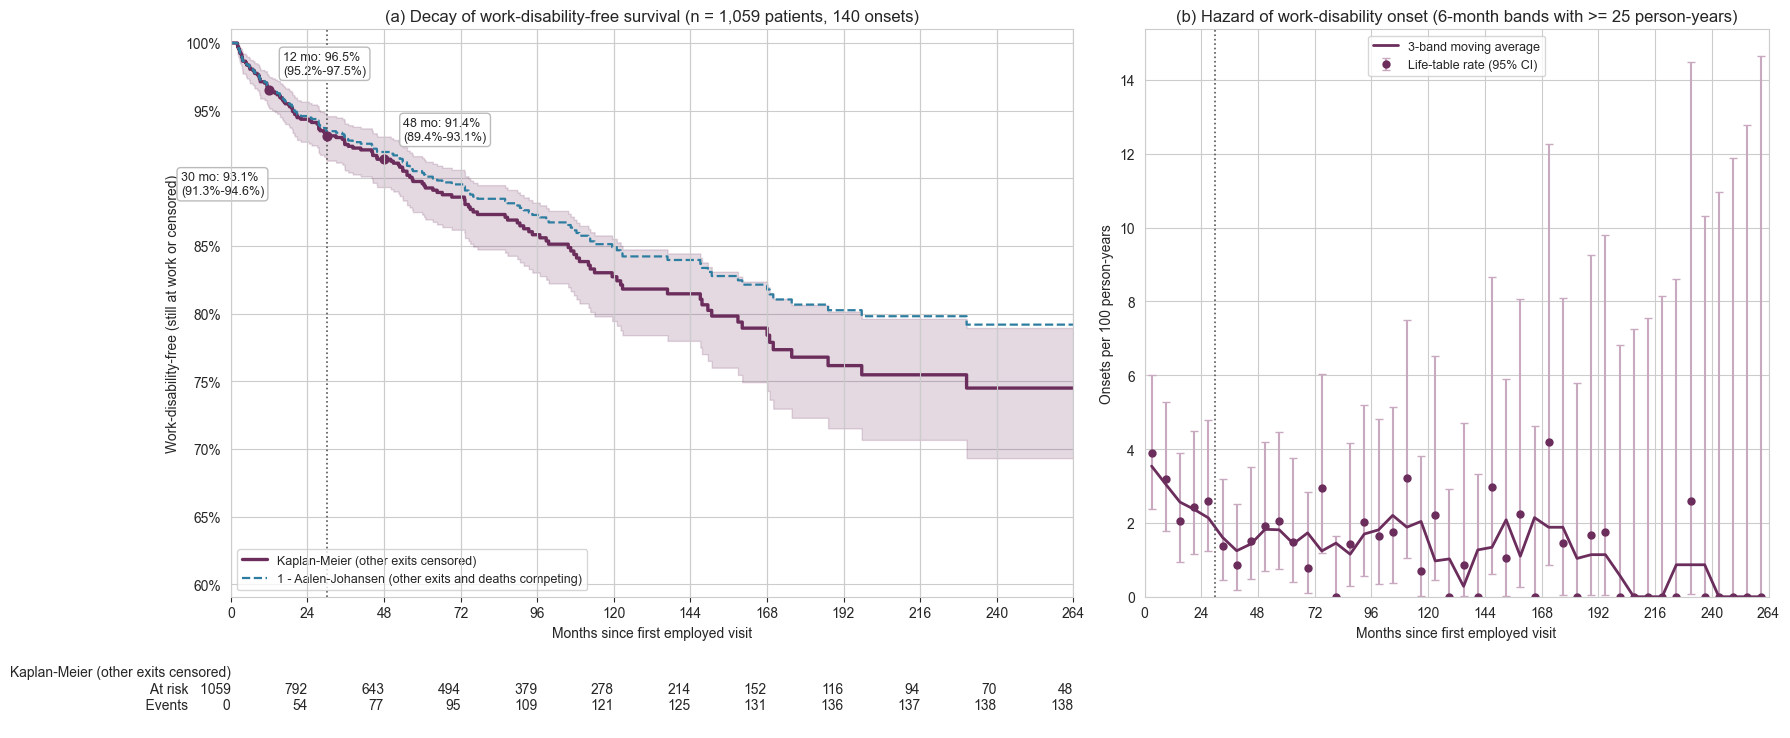

Work-disability-free at 30 months: KM 93.1% (cumulative incidence 6.9%); with other exits and deaths as competing events, cumulative incidence 6.5%
Onset rate per 100 person-years by band:
   band  events     py  rate   lo    hi
    0-6      20 514.55  3.89 2.37  6.00
   6-12      15 470.01  3.19 1.79  5.26
  12-18       9 437.43  2.06 0.94  3.91
  18-24      10 409.46  2.44 1.17  4.49
  24-30      10 384.46  2.60 1.25  4.78
  30-36       5 365.68  1.37 0.44  3.19
  36-42       3 348.48  0.86 0.18  2.52
  42-48       5 331.23  1.51 0.49  3.52
  48-54       6 312.40  1.92 0.70  4.18
  54-60       6 292.76  2.05 0.75  4.46
  60-66       4 272.01  1.47 0.40  3.77
  66-72       2 254.30  0.79 0.10  2.84
  72-78       7 238.63  2.93 1.18  6.04
  78-84       0 223.04  0.00 0.00  1.65
  84-90       3 210.56  1.42 0.29  4.16
  90-96       4 196.95  2.03 0.55  5.20
 96-102       3 182.49  1.64 0.34  4.80
102-108       3 170.51  1.76 0.36  5.14
108-114       5 155.87  3.21 1.04  7.49
114-120    

In [3]:
"""
Follow-up diagnostics and Kaplan-Meier decay of work-disability-free survival (v5).

Time zero = first employed visit; event = first work-disability onset (dated as in the landmark builder). The
Kaplan-Meier curve censors the competing causes (other exit, death) as well as the last visit and age 65; the
Aalen-Johansen curve treats other exits and deaths as competing events (the cumulative incidence the v4 models target).

1. How index follow-up ends, and for how long patients are followed.
2. Kaplan-Meier figure:
   (a) work-disability-free survival S(t) with its 95% CI, the number at risk underneath, and S(t) marked at 12,
       30 and 48 months -- the decay of the employed cohort. 1 - Aalen-Johansen is overlaid: it treats other exits
       and deaths as competing events instead of censoring them (the lower, 'real-world' cumulative incidence).
   (b) the hazard behind that decay: life-table onset rate per 100 person-years in 6-month bands, with exact
       Poisson 95% CIs, i.e. whether the risk of onset is front-loaded or constant over follow-up.
3. Landmark-level follow-up: how it ends, and how many landmarks are censored before 30 months (kept via IPCW).
"""
from lifelines import KaplanMeierFitter, AalenJohansenFitter
from lifelines.plotting import add_at_risk_counts

km_df = patients_df[patients_df["ever_employed"] & (patients_df["km_time_days"] > 0)].copy()
km_df["t_months"] = km_df["km_time_days"] / MONTH_DAYS
W = 100

# ------------------------------------------------------------------ 1. follow-up by how it ends
print("=" * W)
print("1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)")
print("-" * W)
fu = km_df.groupby("km_exit")["t_months"].agg(N="size", median="median", q1=lambda s: s.quantile(.25),
                                             q3=lambda s: s.quantile(.75), max="max")
fu["%"] = 100 * fu["N"] / len(km_df)
print(fu.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
rkm = KaplanMeierFitter().fit(km_df["t_months"], 1 - km_df["km_event"])
print(f"\nMedian potential follow-up (reverse Kaplan-Meier): {rkm.median_survival_time_:.1f} months")
print(f"Patients followed < {PRIMARY_HORIZON_MONTHS} months without an onset: "
      f"{int(((km_df['t_months'] < PRIMARY_HORIZON_MONTHS) & (km_df['km_event'] == 0)).sum())} "
      f"(kept through the censoring-aware target)")

# ------------------------------------------------------------------ 2. Kaplan-Meier decay + hazard
kmf = KaplanMeierFitter(label="Kaplan-Meier (other exits censored)").fit(km_df["t_months"], km_df["km_event"])
ev_code = km_df["km_cause"].astype(int).values          # 1 disability, 2 other exit, 3 death, 0 censored
with warnings.catch_warnings():                      # tied times are jittered by lifelines (seeded)
    warnings.simplefilter("ignore")
    ajf = AalenJohansenFitter(calculate_variance=False, seed=SEED).fit(
        pd.Series(km_df["t_months"].values), pd.Series(ev_code), event_of_interest=1)

x_max = float(np.ceil(km_df["t_months"].quantile(0.95) / 12) * 12)
ticks = list(np.arange(0, x_max + 1, 24))
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
kmf.plot_survival_function(ax=ax, color="#6b2d5c", lw=2.4, ci_show=True, ci_alpha=0.18)
aj_s = 1 - ajf.cumulative_density_.iloc[:, 0]
ax.step(aj_s.index, aj_s.values, where="post", color="#2c7da0", lw=1.6, ls="--",
        label="1 - Aalen-Johansen (other exits and deaths competing)")
for m, off in [(12, (10, 12)), (PRIMARY_HORIZON_MONTHS, (-105, -42)), (48, (14, 14))]:
    s = float(kmf.survival_function_at_times(m).iloc[0])
    lo, hi = kmf.confidence_interval_survival_function_.asof(m).values
    ax.scatter([m], [s], color="#6b2d5c", zorder=5, s=40)
    ax.annotate(f"{m} mo: {s:.1%}\n({lo:.1%}-{hi:.1%})", (m, s), textcoords="offset points",
                xytext=off, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb"))
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
med = kmf.median_survival_time_
if np.isfinite(med):
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.text(med, 0.51, f"median {med:.0f} mo", fontsize=9, color="gray")
ax.set_xlim(0, x_max); ax.set_xticks(ticks)
ax.set_ylim(max(0.0, float(kmf.survival_function_.values.min()) - 0.1), 1.01)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Work-disability-free (still at work or censored)")
ax.set_title(f"(a) Decay of work-disability-free survival (n = {len(km_df):,} patients, "
             f"{int(km_df['km_event'].sum())} onsets)")
ax.legend(loc="lower left", fontsize=9)
add_at_risk_counts(kmf, ax=ax, rows_to_show=["At risk", "Events"], xticks=ticks)

# (b) life-table hazard in 6-month bands
band = 6.0
edges = np.arange(0, x_max + band, band)
T, E = km_df["t_months"].values, km_df["km_event"].values
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    exposure_py = np.clip(np.minimum(T, hi) - lo, 0, None).sum() / 12.0
    d = int(((E == 1) & (T > lo) & (T <= hi)).sum())
    if exposure_py < 25:                             # too little person-time for a readable rate
        continue
    ci_lo = stats.chi2.ppf(0.025, 2 * d) / 2 if d > 0 else 0.0
    ci_hi = stats.chi2.ppf(0.975, 2 * d + 2) / 2
    rows.append({"band_mid": (lo + hi) / 2, "events": d, "py": exposure_py, "rate": 100 * d / exposure_py,
                 "lo": 100 * ci_lo / exposure_py, "hi": 100 * ci_hi / exposure_py})
hz = pd.DataFrame(rows)
ax = axes[1]
ax.errorbar(hz["band_mid"], hz["rate"], yerr=[hz["rate"] - hz["lo"], hz["hi"] - hz["rate"]], fmt="o",
            color="#6b2d5c", ecolor="#c9a9c0", capsize=3, ms=5, label="Life-table rate (95% CI)")
if len(hz) >= 3:
    sm = hz["rate"].rolling(3, center=True, min_periods=1).mean()
    ax.plot(hz["band_mid"], sm, color="#6b2d5c", lw=2, label="3-band moving average")
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
ax.set_xlim(0, x_max); ax.set_xticks(ticks); ax.set_ylim(0, None)
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Onsets per 100 person-years")
ax.set_title("(b) Hazard of work-disability onset (6-month bands with >= 25 person-years)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/v5_km_work_disability_decay.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

s30 = float(kmf.survival_function_at_times(PRIMARY_HORIZON_MONTHS).iloc[0])
aj30 = float(ajf.cumulative_density_.asof(PRIMARY_HORIZON_MONTHS).iloc[0])
print(f"Work-disability-free at {PRIMARY_HORIZON_MONTHS} months: KM {s30:.1%} (cumulative incidence {1 - s30:.1%}); "
      f"with other exits and deaths as competing events, cumulative incidence {aj30:.1%}")
print("Onset rate per 100 person-years by band:")
print(hz.assign(band=lambda d: [f"{m - band / 2:.0f}-{m + band / 2:.0f}" for m in d["band_mid"]])
      [["band", "events", "py", "rate", "lo", "hi"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))

# ------------------------------------------------------------------ 3. landmark-level censoring
print("\n" + "=" * W)
print(f"3. LANDMARKS BY HOW FOLLOW-UP ENDS, and share censored before {PRIMARY_HORIZON_MONTHS} months")
print("-" * W)
lt = land.assign(before_h=(land["cause"] == 0) & (land["time_days"] <= HORIZON_DAYS))
tab = lt.groupby("exit_type").agg(landmarks=("pid", "size"), patients=("pid", "nunique"),
                                  median_fu_mo=("time_days", lambda s: s.median() / MONTH_DAYS),
                                  censored_before_30mo=("before_h", "sum"))
print(tab.to_string(float_format=lambda v: f"{v:.1f}"))
G_diag = CensoringKM(T_ALL, C_ALL)
print(f"Censoring survival G(30 mo) = {float(G_diag.at([HORIZON_DAYS])[0]):.2f}: controls are up-weighted by about "
      f"{1 / max(float(G_diag.at([HORIZON_DAYS])[0]), IPCW_MIN_G):.1f}x in every IPCW metric.")
print("=" * W)

## 11.4 Table 1 — baseline characteristics by outcome group

In [4]:
"""
Table 1 -- baseline characteristics by outcome group (v5).

Groups (patient level, mutually exclusive, first match wins):
  Became Disabled   : a work-disability onset after some landmark
  Other Exits       : follow-up of some landmark ended in retirement / homemaker / student / job-seeking / other
  Deceased          : died
  Remained Employed : none of the above (censored at last visit)
Plus an 'Overall' column across every patient who contributes a landmark.

Baseline = the INDEX (first employed) visit row -- v1 took groupby().first(), i.e. the first non-null value of each
column from any visit, which could mix values from different visits. Follow-up, disease course and treatment are
aggregated over each patient's full visit record. Continuous -> mean (SD) | median [IQR], Kruskal-Wallis;
categorical -> n (%), chi-square.
"""


def _patient_outcome_group(land, pts):
    g = land.groupby("pid")
    ev = g["event"].max()
    other = g["exit_type"].apply(lambda s: (s == "other_exit").any())
    out = pd.Series("Remained Employed", index=ev.index)
    out[pts.loc[ev.index, "dead"].values] = "Deceased"
    out[other] = "Other Exits"
    out[ev == 1] = "Became Disabled"
    return out.rename("outcome_group")


def _first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_table1_baseline(land, pts, visits):
    outcome = _patient_outcome_group(land, pts)
    v = visits[visits["PTNO"].isin(outcome.index)]
    g = v.groupby("PTNO")
    idx_rows = v[v["ASSDT"] == v["PTNO"].map(pts["index_date"])].set_index("PTNO")
    last_rows = g.last()
    ever = lambda col: g[col].apply(lambda s: int((pd.to_numeric(s, errors="coerce").fillna(0) > 0).any()))
    b = pd.DataFrame(index=outcome.index)
    # ---- sociodemographics (patient-constant: first recorded value across all visits)
    b["sex"] = g["SEX"].apply(_first_nonnull)
    b["race"] = g["RACE_LABEL"].apply(_first_nonnull)
    b["ethnicity"] = g["DS_ETHNICITY"].apply(_first_nonnull)
    b["education"] = g["DS_MAX_EDU"].apply(_first_nonnull)
    b["age_index"] = idx_rows["age_at_record"]
    b["disease_duration_yrs"] = idx_rows["disease_duration_yrs"]
    # ---- follow-up
    b["n_visits"] = g.size()
    b["followup_years"] = (last_rows["ASSDT"] - idx_rows["ASSDT"]).dt.days / 365.25
    b["mean_gap_days"] = g["DAYS_SINCE_LAST_VISIT"].mean()
    b["n_landmarks"] = land.groupby("pid").size()
    # ---- disease activity, flares and damage
    b["sledai_baseline"] = idx_rows["SLEDAI2_I"]
    b["sledai_mean"] = g["SLEDAI2_I"].mean()
    b["ever_flare_mild"] = g["FLARE_MILD_MOD"].max().astype(int)
    b["ever_flare_severe"] = g["FLARE_SEVERE"].max().astype(int)
    b["sdi_baseline"] = idx_rows["score_n"]
    b["sdi_last"] = last_rows["score_n"]
    # ---- employment history at index / during follow-up
    b["prior_sick_leave"] = (idx_rows["PRIOR_SICK_LEAVE_VISITS"] > 0).astype(int)
    b["ever_sick_leave"] = g["EMP"].apply(lambda s: int(s.isin(SICK_STATES).any()))
    # ---- treatment, ever during follow-up
    b["ever_steroid"] = g["ON_STEROID"].max().astype(int)
    b["steroid_dose_mean"] = g["STERAVER"].mean()
    b["ever_steroid_pulse"] = ever("STPDOSE")
    b["ever_antimalarial"] = g["ON_ANTIMALARIAL"].max().astype(int)
    b["ever_immunosuppressive"] = g["HAS_IMMUNOSUPPRESSIVE_REC"].max()
    b["ever_cyclophosphamide"] = ever("IS_CYCLOPHOSPHAMIDE_DOSE")
    b["ever_mycophenolate"] = ever("IS_MYCOPHENOLATE_DOSE")
    b["ever_methotrexate"] = ever("IS_METHOTREXATE_DOSE")
    b["ever_biologic"] = g["HAS_BIOLOGIC_REC"].max()
    b["ever_rituximab"] = ever("BIOG_RIT")
    b["ever_belimumab"] = ever("BIOG_BEL")
    return b.join(outcome, how="inner")


def _fmt_cont(s):
    s = s.dropna().astype(float)
    if not len(s):
        return "n=0"
    return f"{s.mean():.1f} ({s.std():.1f}) | {s.median():.1f} [{s.quantile(.25):.1f}-{s.quantile(.75):.1f}]"


def _fmt_cat(s, level):
    s = s.dropna()
    n = int((s == level).sum())
    return f"{n} ({100 * n / len(s):.1f}%)" if len(s) else "0"


def _pval(test):
    try:
        return f"{test():.3f}"
    except ValueError:
        return "n/a"


def make_table1(b, groups=("Remained Employed", "Became Disabled", "Deceased", "Other Exits")):
    groups = [x for x in groups if x in set(b["outcome_group"])]
    rows = [{"Variable": "N", "Overall": str(len(b)), **{x: str((b.outcome_group == x).sum()) for x in groups},
             "p": ""}]
    section = lambda t: rows.append({"Variable": f"**{t}**", "Overall": "", **{x: "" for x in groups}, "p": ""})

    def cont(col, label):
        arrs = [a for a in (b.loc[b.outcome_group == x, col].dropna().astype(float) for x in groups) if len(a)]
        rows.append({"Variable": f"{label}, mean (SD) | median [IQR]", "Overall": _fmt_cont(b[col]),
                     **{x: _fmt_cont(b.loc[b.outcome_group == x, col]) for x in groups},
                     "p": _pval(lambda: stats.kruskal(*arrs).pvalue)})

    def cat(col, label, levels=None, names=None):
        p = _pval(lambda: stats.chi2_contingency(pd.crosstab(b[col], b["outcome_group"]))[1])
        levels = levels or sorted(b[col].dropna().unique().tolist(), key=str)
        if len(levels) > 1:
            rows.append({"Variable": f"{label}, n (%)", "Overall": "", **{x: "" for x in groups}, "p": p})
        for lv in levels:
            nm = (names or {}).get(lv, lv)
            rows.append({"Variable": f"    {nm}" if len(levels) > 1 else f"{label}, n (%)",
                         "Overall": _fmt_cat(b[col], lv),
                         **{x: _fmt_cat(b.loc[b.outcome_group == x, col], lv) for x in groups},
                         "p": "" if len(levels) > 1 else p})

    section("Sociodemographics")
    cont("age_index", "Age at index (years)")
    cat("sex", "Sex")
    cat("race", "Race")
    cat("ethnicity", "Ethnicity")
    cat("education", "Education (DS_MAX_EDU)", names={0.0: "Lower", 1.0: "Higher"})
    cont("disease_duration_yrs", "Disease duration at index (years)")
    section("Follow-up")
    cont("n_visits", "Number of visits")
    cont("followup_years", "Follow-up from index (years)")
    cont("mean_gap_days", "Mean time between visits (days)")
    cont("n_landmarks", "Landmark visits")
    section("Disease activity, flares and damage")
    cont("sledai_baseline", "SLEDAI-2K at index")
    cont("sledai_mean", "SLEDAI-2K, mean across follow-up")
    cat("ever_flare_mild", "Any mild/moderate flare (SLEDAI-2K +4 to +10)", levels=[1])
    cat("ever_flare_severe", "Any severe flare (SLEDAI-2K > +10)", levels=[1])
    cont("sdi_baseline", "SDI at index")
    cont("sdi_last", "SDI at last visit")
    section("Employment history")
    cat("prior_sick_leave", "Sick leave before index", levels=[1])
    cat("ever_sick_leave", "Any sick leave during follow-up", levels=[1])
    section("Treatment (ever during follow-up)")
    cat("ever_steroid", "Ever on steroids", levels=[1])
    cont("steroid_dose_mean", "Average daily steroid dose, mg (visits with a value)")
    cat("ever_steroid_pulse", "Ever received steroid pulse", levels=[1])
    cat("ever_antimalarial", "Ever on antimalarial", levels=[1])
    cat("ever_immunosuppressive", "Ever on immunosuppressive therapy", levels=[1])
    cat("ever_cyclophosphamide", "    Ever cyclophosphamide", levels=[1])
    cat("ever_mycophenolate", "    Ever mycophenolate", levels=[1])
    cat("ever_methotrexate", "    Ever methotrexate", levels=[1])
    cat("ever_biologic", "Ever on biologic therapy", levels=[1])
    cat("ever_rituximab", "    Ever rituximab", levels=[1])
    cat("ever_belimumab", "    Ever belimumab", levels=[1])
    return pd.DataFrame(rows)[["Variable", "Overall"] + groups + ["p"]]


table1_base = build_table1_baseline(land, patients_df, visits)
table1 = make_table1(table1_base)
pd.set_option("display.max_rows", None)
display(table1)
table1.to_csv("table1_baseline_characteristics_model_v5.csv", index=False)

,Variable,Overall,Remained Employed,Became Disabled,Deceased,Other Exits,p
0,N,1059,686,153,33,187,
1,**Sociodemographics**,,,,,,
2,"Age at index (years), mean (SD) | median [IQR]",36.1 (10.9) | 34.5 [27.3-43.8],35.6 (10.5) | 33.7 [27.6-42.4],38.3 (11.2) | 38.5 [29.1-47.1],42.3 (12.1) | 42.4 [31.9-53.5],34.9 (11.4) | 33.7 [25.7-43.2],0.000
3,"Sex, n (%)",,,,,,0.019
4,F,933 (88.2%),602 (87.9%),141 (92.2%),24 (72.7%),166 (88.8%),
5,M,125 (11.8%),83 (12.1%),12 (7.8%),9 (27.3%),21 (11.2%),
6,"Race, n (%)",,,,,,0.000
7,Black,151 (14.7%),94 (14.4%),30 (19.6%),7 (21.2%),20 (10.8%),
8,Caucasian,611 (59.6%),354 (54.1%),101 (66.0%),20 (60.6%),136 (73.1%),
9,Chinese,111 (10.8%),86 (13.1%),10 (6.5%),3 (9.1%),12 (6.5%),


## 11.5 Pre-specified variables

Section 5. The fixed variable set used by every model in every fold (no selection), with a descriptive table at the
landmark visits.

In [5]:
"""
Pre-specified variables (v5): no data-driven selection.

v3 and v4 chose the variables by stability selection inside every training fold. v5 fixes them in advance
(FEATURE_GROUPS, Section 5), so no step of the pipeline chooses variables using the outcome, and every model -- the
sequence encoders included -- uses the same 21 columns. The table describes each variable at the landmark visits: the
share still missing after carry-forward (median-imputed inside each training fold), its distribution, and its mean in
landmarks with and without an onset within 30 months (resolved landmarks, unweighted; descriptive only).
"""
FEATURE_RATIONALE = {
    "age_at_record": "age drives both disability and retirement",
    "disease_duration_yrs": "longer disease, more cumulative burden",
    "EDU_HIGHER": "education shapes job type and physical demands",
    "EDU_MISSING": "education not recorded (~1/3 of patients)",
    "SLEDAI2_I": "current disease activity",
    "SLEDAI_ARTHRITIS": "SLEDAI component: arthritis limits physical work",
    "SLEDAI_MUCO_ANY": "SLEDAI component: rash / alopecia / ulcers (visible, common activity)",
    "SLEDAI_SLOPE_1Y": "trajectory: activity rising or falling over the last year",
    "FLARES_1Y": "change: flares (SLEDAI-2K rise > 3) in the last year",
    "score_n": "accumulated organ damage (SDI)",
    "SDI_ACCRUAL_2Y": "change: new damage in the last 2 years",
    "STERAVER_0": "current steroid dose",
    "STEROID_CHANGE_1Y": "change: steroid dose now vs the earliest visit in the last 12 months",
    "CUM_STEROID_G": "cumulative steroid exposure (damage, fatigue)",
    "IS_MYCOPHENOLATE_DOSE_0": "mycophenolate dose (severe / renal disease)",
    "IS_METHOTREXATE_DOSE_0": "methotrexate dose (musculoskeletal / skin disease)",
    "RITUXIMAB_1Y": "rituximab in the last 12 months (refractory disease; dose fields unusable)",
    "BELIMUMAB_1Y": "belimumab in the last 12 months (persistent activity; dose fields unusable)",
    "PRIOR_SICK_RETURN": "a previous sick leave that ended in a return to employment",
    "PRIOR_DISABILITY": "a previous work-disability episode, then back at work",
    "YRS_IN_WORK_RUN": "stability of the current employment spell",
}
assert set(FEATURE_RATIONALE) == set(FEATURE_CANDIDATES), set(FEATURE_RATIONALE) ^ set(FEATURE_CANDIDATES)
FIXED_SELECTION = {"features": list(FEATURE_CANDIDATES), "freq": pd.Series(1.0, index=FEATURE_CANDIDATES)}
SELECTION_ALL = FIXED_SELECTION                     # the final all-data refits use the same set


def variable_table():
    lab = land["label30"]
    rows = []
    for c in FEATURE_CANDIDATES:
        x = land[c].astype(float)
        binary = set(x.dropna().unique()) <= {0.0, 1.0}
        summ = f"{x.mean():.1%} yes" if binary else f"{x.median():.2f} [{x.quantile(.25):.2f}, {x.quantile(.75):.2f}]"
        rows.append({"Group": FEATURE_GROUP_OF[c], "Variable": DISPLAY_NAMES.get(c, c),
                     "Missing at landmarks": f"{x.isna().mean():.1%}", "Median [IQR] or % yes": summ,
                     "Mean, onset <= 30 mo": x[lab == 1].mean(), "Mean, no onset by 30 mo": x[lab == 0].mean(),
                     "Why included": FEATURE_RATIONALE[c]})
    return pd.DataFrame(rows).set_index("Variable")


print(f"{len(FEATURE_CANDIDATES)} pre-specified columns = {len(FEATURE_CANDIDATES) - 1} variables (education comes with "
      f"a 'not recorded' indicator); no variable selection.")
display(variable_table().round(3))
for c in ["RITUXIMAB_1Y", "BELIMUMAB_1Y", "PRIOR_SICK_RETURN"]:
    on = land[c] > 0
    print(f"{DISPLAY_NAMES[c]}: {on.mean():.1%} of landmarks, {land.loc[on, 'pid'].nunique()} patients")


21 pre-specified columns = 20 variables (education comes with a 'not recorded' indicator); no variable selection.


,Group,Missing at landmarks,Median [IQR] or % yes,"Mean, onset <= 30 mo","Mean, no onset by 30 mo",Why included
Variable,,,,,,
SLEDAI-2K,Disease activity,0.0%,"2.00 [0.00, 4.00]",5.141,3.502,current disease activity
SLEDAI: arthritis,Disease activity,0.0%,7.6% yes,0.166,0.073,SLEDAI component: arthritis limits physical work
SLEDAI: mucocutaneous,Disease activity,0.0%,16.6% yes,0.276,0.169,SLEDAI component: rash / alopecia / ulcers (vi...
"SLEDAI-2K slope, last 12 mo (pts/yr)",Disease activity,0.0%,"0.00 [-1.51, 0.24]",-0.740,-0.518,trajectory: activity rising or falling over th...
"SLEDAI-2K flares (rise > 3), last 12 mo",Disease activity,0.0%,"0.00 [0.00, 0.00]",0.369,0.258,change: flares (SLEDAI-2K rise > 3) in the las...
SDI damage score,Damage,0.0%,"1.00 [0.00, 3.00]",2.698,1.911,accumulated organ damage (SDI)
"SDI points gained, last 2 yrs",Damage,0.0%,"0.00 [0.00, 0.00]",0.441,0.207,change: new damage in the last 2 years
Steroid dose (mg/day),Treatment,0.0%,"0.00 [0.00, 7.50]",8.907,4.508,current steroid dose
"Steroid dose change, last 12 mo",Treatment,0.0%,"0.00 [0.00, 0.00]",0.913,-0.211,change: steroid dose now vs the earliest visit...


Rituximab, last 12 mo: 0.6% of landmarks, 27 patients
Belimumab, last 12 mo: 2.1% of landmarks, 46 patients
Prior sick leave with return to work: 5.4% of landmarks, 44 patients


## 11.6 Patient-level evaluation

Section 9.2: every patient's 30-month window (before onset; before retirement / homemaker at ≥ 60; or the latest fully
observed 30 months), the final-status strata and age bands, and the functions that turn visit alarms into
TP / FN / TN / FP and a patient probability. Printed: the evaluation funnel.

In [6]:
"""
Patient-level evaluation (v5): visit alarms accumulated over each patient's visits.

Nothing is trained or tuned at the patient level. Every model is trained on landmark visits and its alarm threshold is
learned at visit level inside each training fold (Section 9). A landmark ALARMS (the patient is labelled high risk at
that visit) when its calibrated 30-month risk is >= that threshold. Patients are scored while held out, from their
test-fold visit alarms, over a 30-MONTH WINDOW of landmarks -- the horizon the models predict -- for everyone:

  Event patients (a work-disability onset):
    window  the landmarks in the 30 months before an onset (any onset, if the patient has several)
    TP / FN an alarm / no alarm in that window. No landmark in it: not assessable.
  Event-free patients, stratified by FINAL STATUS (state at their last visit):
    "Retired / homemaker >= 60"  final visit retired or homemaker, having left employment for it at age >= 60:
                                 window = the landmarks in the 30 months before that exit
    "Employed at final visit"    window = the latest 30 months of landmarks that were each followed by >= 30 months
                                 of observed follow-up with no onset and no other exit (a fully observed negative
                                 window; how their employment eventually ends does not matter for a 30-month claim)
    "Other final status"         everyone else (other exits, retirement before 60, deaths): the same fully observed
                                 window as the employed
    TN / FP no alarm / an alarm in that window. No landmark in it: not assessable.
The primary table uses every evaluable patient; each final-status stratum also gets its own table (all event patients
vs that stratum's negatives), and specificity and the C-index are reported by age band (age at the end of the window).

Patient probability, for the C-index, Brier score and calibration: the patient's highest calibrated 30-month risk over
the window, mapped to the probability of being an event patient by a logistic recalibration fitted in each training
fold on the training patients' cross-fitted (OOF) risks. PPV and NPV are also given at the cohort's share of patients
with an onset (Bayes' rule on sensitivity and specificity), since the evaluated sample's event share is not the
clinic's. Everything here is computed from the stored fold predictions, so the definition can change without re-running
the cross-validation.
"""
STRATA = ["Employed at final visit", f"Retired / homemaker >= {NEG_MIN_AGE}", "Other final status"]
AGE_BANDS = [(0, 40, "< 40"), (40, 50, "40-49"), (50, 60, "50-59"), (60, 200, ">= 60")]


def _exit_to_final_state(p):
    """(date, age) of the first visit of the patient's final non-working run if it was entered straight from
    employment, else (None, None)."""
    states = [_state_of(e) for e in p["EMP"].values]
    j = len(states) - 1
    while j >= 0 and states[j] != "W":
        j -= 1
    if j < 0 or j == len(states) - 1:
        return None, None
    k = j + 1
    while k < len(states) and states[k] == "U":
        k += 1
    if k >= len(states):
        return None, None
    return p["ASSDT"].iat[k], float(p["age_at_record"].iat[k])


def build_patient_truth(visits, land):
    """One row per patient with landmarks: group ('event' / 'negative' / 'excluded'), final-status stratum, the reason
    for exclusion, and the window end (onset, exit, or the end of the fully observed negative window)."""
    lg = land.groupby("pid", sort=False)
    ev, has_win = lg["event"].max(), lg["in_window"].max()
    rows = []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        if pid not in ev.index:
            continue
        p = visits.iloc[idx]
        final = p["EMP"].iat[-1]
        rec = {"pid": pid, "group": "excluded", "stratum": None, "reason": None, "final_status": final,
               "exit_date": pd.NaT}
        if ev[pid] == 1:
            rec["stratum"] = "Event"
            if has_win[pid]:
                rec["group"] = "event"
            else:
                rec["reason"] = "onset with no landmark in the 30 months before"
            rows.append(rec)
            continue
        d_exit, a_exit = _exit_to_final_state(p)
        if final in NEG_EXIT_STATES and d_exit is not None and a_exit >= NEG_MIN_AGE:
            rec.update(stratum=STRATA[1], exit_date=d_exit)
        elif final in WORKING_STATES:
            rec["stratum"] = STRATA[0]
        else:
            rec["stratum"] = STRATA[2]
        rec["group"] = "negative"                        # confirmed below: needs a landmark in its window
        rows.append(rec)
    return pd.DataFrame(rows).set_index("pid")


PT_TRUTH = build_patient_truth(visits, land)
_stratum = PT_TRUTH["stratum"].reindex(PID_ALL).values
_exit = pd.to_datetime(PT_TRUTH["exit_date"].reindex(PID_ALL).values)
_vdate = pd.to_datetime(land["visit_date"].values)
_days_to_exit = np.asarray((_exit - _vdate).days, float)          # NaN if no retirement exit
# retirees: the 30 months before the exit
_win_retired = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= HORIZON_DAYS)
# everyone else event-free: the latest 30 months of landmarks each followed >= 30 months with no onset or exit
_resolved = (land["time_days"].values > HORIZON_DAYS) & (land["event"].values == 0)
_neg_other = np.isin(_stratum, [STRATA[0], STRATA[2]]) & _resolved
_last_resolved = pd.Series(np.where(_neg_other, _vdate.values, np.datetime64("NaT")),
                           dtype="datetime64[ns]").groupby(PID_ALL).transform("max").values
_win_observed = _neg_other & ((_last_resolved - _vdate.values) / np.timedelta64(1, "D") <= HORIZON_DAYS)
LAND_PT_WIN = np.where(_stratum == "Event", land["in_window"].values == 1, _win_retired | _win_observed)

_has_window = pd.Series(LAND_PT_WIN).groupby(PID_ALL).max()
_no_win = (PT_TRUTH["group"] == "negative") & ~_has_window.reindex(PT_TRUTH.index).fillna(False).astype(bool)
PT_TRUTH.loc[_no_win, "reason"] = np.where(PT_TRUTH.loc[_no_win, "stratum"] == STRATA[1],
                                          "retired >= 60: no landmark in the 30 months before the exit",
                                          "event-free: never followed >= 30 months after a landmark")
PT_TRUTH.loc[_no_win, "group"] = "excluded"
PT_Y = (PT_TRUTH["group"] == "event").astype(int)
# age at the end of each evaluable patient's window (its last deciding landmark)
PT_AGE = pd.Series(land["age_at_record"].values[LAND_PT_WIN]).groupby(PID_ALL[LAND_PT_WIN]).max()
PT_AGE_BAND = pd.cut(PT_AGE, [a for a, _, _ in AGE_BANDS] + [AGE_BANDS[-1][1]], right=False,
                     labels=[lab for _, _, lab in AGE_BANDS]).astype(str)
COHORT_EVENT_SHARE = float(land.groupby("pid")["event"].max().mean())   # share of landmark patients with an onset


def print_patient_funnel():
    t = PT_TRUTH
    ev = t[t.group == "event"]
    print(f"Patient-level evaluation set ({len(t)} patients with landmarks; cohort share with an onset "
          f"{COHORT_EVENT_SHARE:.1%}):")
    print(f"  event patients with a landmark in the 30 months before onset (TP / FN): {len(ev)}")
    print("  event-free patients with a 30-month window (TN / FP), by final status:")
    for s in STRATA:
        n = int(((t.group == "negative") & (t.stratum == s)).sum())
        print(f"    {s:<40}{n:>6}")
    print("  not evaluated:")
    for reason, n in t[t.group == "excluded"]["reason"].value_counts().items():
        print(f"    {reason:<62}{n:>6}")
    ages = pd.DataFrame({"age band": PT_AGE_BAND, "y": PT_Y.reindex(PT_AGE_BAND.index)})
    print("  evaluable patients by age at the end of their window (events / event-free): "
          + ", ".join(f"{b}: {int((g.y == 1).sum())} / {int((g.y == 0).sum())}"
                      for b, g in ages.groupby("age band", sort=False)))
    print(f"  landmarks that decide a patient's outcome: {int(LAND_PT_WIN.sum()):,}")


print_patient_funnel()


def patient_frame(rows, p, thr):
    """Collapses landmark `rows` (calibrated 30-month risks p and visit thresholds thr, aligned with rows) to one row
    per evaluable patient: y (1 = event patient), score (highest risk in the window), flag (any alarm in it), n_win,
    lead_mo (event patients: months from the earliest alarm in the window to onset), stratum and age band."""
    rows, p = np.asarray(rows), np.asarray(p, float)
    thr = np.broadcast_to(np.asarray(thr, float), p.shape)
    k = LAND_PT_WIN[rows]
    r = rows[k]
    d = pd.DataFrame({"pid": PID_ALL[r], "s": p[k], "a": p[k] >= thr[k], "t": T_ALL[r]})
    g = d.groupby("pid", sort=False)
    f = pd.DataFrame({"score": g["s"].max(), "flag": g["a"].max().astype(int), "n_win": g.size()})
    f["lead_mo"] = d[d["a"]].groupby("pid")["t"].max().reindex(f.index) / MONTH_DAYS
    f["y"] = PT_Y.loc[f.index].values
    f["stratum"] = PT_TRUTH.loc[f.index, "stratum"].values
    f["age_band"] = PT_AGE_BAND.loc[f.index].values
    return f


def fit_patient_calibrator(tr, p_oof):
    """Logistic recalibration of the patient score to 'event patient', on the training patients' OOF risks."""
    f = patient_frame(tr, p_oof, np.inf)
    return Calibrator().fit(f["score"].values, f["y"].values, np.ones(len(f)), True)


def patient_counts(f):
    y, a = f["y"].values, f["flag"].values
    return {"TP": int(((y == 1) & (a == 1)).sum()), "FN": int(((y == 1) & (a == 0)).sum()),
            "TN": int(((y == 0) & (a == 0)).sum()), "FP": int(((y == 0) & (a == 1)).sum())}


Patient-level evaluation set (1059 patients with landmarks; cohort share with an onset 14.4%):
  event patients with a landmark in the 30 months before onset (TP / FN): 145
  event-free patients with a 30-month window (TN / FP), by final status:
    Employed at final visit                    598
    Retired / homemaker >= 60                   17
    Other final status                          77
  not evaluated:
    event-free: never followed >= 30 months after a landmark         203
    retired >= 60: no landmark in the 30 months before the exit       11
    onset with no landmark in the 30 months before                     8
  evaluable patients by age at the end of their window (events / event-free): >= 60: 8 / 69, 50-59: 45 / 152, 40-49: 32 / 162, < 40: 60 / 309
  landmarks that decide a patient's outcome: 4,288


## 11.7 Sequential models (time-aware LSTM / GRU / Transformer)

Section 6.1. The main model is the toy-sweep winner; GRU and Transformer use the same recipe. A smoke test on 40 real
patients (half with an onset) runs at the end of the cell. It checks whole-history and windowed batching, pretraining,
the competing-risk head, early stopping and the seed ensemble in a few seconds.

In [7]:
"""Sequence models (v5): the toy-sweep winner as the main model, plus GRU and Transformer on the same recipe.

The main model is the configuration that won the toy LSTM sweep (`Toy LSTM sweep/`, FINAL_base_SL12), chosen there on
validation patients only (never on test folds):
  * Encoder: a 1-layer LSTM with 32 hidden units, dropout 0.3 on its output. One pass per patient over the WHOLE visit
    history (visits before the index visit and while not employed included), with a prediction at every landmark.
  * Inputs per visit: the 21 pre-specified variable columns (Section 11.5; the sweep used a stability-selected set),
    log(1 + years since the previous visit), and the visit's employment state (employed / sick leave / disabled / other
    exit, one-hot). Scaled with the training fold's landmark rows (skew transform + standardisation + clipping).
  * Self-supervised pretraining (the only option that helped on validation in the sweep): before seeing any disability
    label, the encoder learns to predict the next visit's SLEDAI-2K, SDI and steroid dose (squared error) from the
    history and the gap to that visit, for 10 epochs, on every patient outside the held-out ones. Pretraining is redone
    for every seed.
  * Head: one linear layer from the hidden state to 16 three-month intervals. The sweep's head was a sigmoid hazard per
    interval (work disability vs none); under v4's competing risks it becomes a softmax over {none, work disability,
    other exit, death} per interval, which is the same model when there is only one cause. Biases start at the training
    class rates. Output: the cumulative incidence of work disability,
        CIF_1(k) = sum_{j <= k} S(j - 1) h_1(j),   S(j) = prod_{l <= j} (1 - h_1(l) - h_2(l) - h_3(l)).
  * Training: interval cross-entropy weighted by 1 / landmarks-per-patient, AdamW (lr 3e-3, weight decay 1e-2),
    gradient clipping, batches of 64 patients, up to 60 epochs with EARLY STOPPING (patience 8) on 20% of the fit's
    patients held out as a validation set; the best-validation weights are kept.
  * Ensemble: 5 seeds (each with its own pretraining, initialisation and validation split) in the outer-fold fit; their
    per-interval class probabilities are averaged.
Options the sweep tested and rejected (not used): GRU-D time decay, skip connection, 2 layers, 16 / 64 units,
class weighting, dropping the patient weights, dropping the employment-state inputs, a binary 30-month head.
Not carried over from v3: raw per-visit encoder inputs, input decay of ESR / hs-CRP, the warm-started skip head, the
ranking loss and SWA.

GRU and Transformer: the identical recipe (inputs, pretraining, head, early stopping, 5 seeds) with a GRU cell or a
1-layer causal Transformer (2 heads, feed-forward 64, lr 1e-3, plus elapsed years since the first visit as an input).

Optional history window (max_visits): each landmark sees only its last k visits (Section 11.16 ablation).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

torch.set_num_threads(max(1, os.cpu_count() or 1))

VX_RAW = visits[FEATURE_CANDIDATES].values.astype(float)                  # encoder features, every visit
V_GAP = np.log1p(visits.groupby("PTNO")["ASSDT"].diff().dt.days.fillna(0.0).values / 365.25).astype(np.float32)
V_STATE = visits[["EMP_WORKING", "EMP_SICK", "EMP_DISABLED", "EMP_OTHER"]].values.astype(np.float32)
V_ELAPSED = ((visits["ASSDT"] - visits.groupby("PTNO")["ASSDT"].transform("min")).dt.days.values
             / 365.25 / 10.0).astype(np.float32)                           # decades since the first visit (Transformer)
PRETRAIN_COLS = ["SLEDAI2_I", "score_n", "STERAVER_0"]                   # next-visit targets of the pretraining
_tg = visits[PRETRAIN_COLS].values.astype(float)                          # label-free: standardised over all visits
_tg = np.where(np.isnan(_tg), np.nanmedian(_tg, 0), _tg)
V_PRETRAIN_TGT = ((_tg - _tg.mean(0)) / (_tg.std(0) + 1e-8)).astype(np.float32)
PATIENT_ROWS = visits.groupby("PTNO", sort=False).indices                 # pid -> visit row indices (date order)
_VROW_TO_POS = np.empty(len(visits), dtype=np.int64)
for _pid, _rows in PATIENT_ROWS.items():
    _VROW_TO_POS[_rows] = np.arange(len(_rows))
LAND_POS = _VROW_TO_POS[land["visit_row"].values]                         # landmark -> position in its patient
SEQ_KIND = {"LSTM": "lstm", "GRU": "gru", "Transformer": "transformer"}
N_STATE = V_STATE.shape[1]


def seq_cfg(model, cfg_name):
    return {**SEQ_CONFIG, **SEQ_GRIDS[model][cfg_name]}


def cif_from_probs(P):
    """(n, K, N_CLASSES) per-interval class probabilities -> (n, K) cumulative incidence of work disability."""
    S = np.cumprod(P[..., 0], axis=-1)
    S_prev = np.concatenate([np.ones_like(S[..., :1]), S[..., :-1]], axis=-1)
    return np.cumsum(S_prev * P[..., 1], axis=-1)


def cif_to_risk(cif):
    """(n, K) cumulative incidence -> (n, n_horizons) risk of onset by each evaluation horizon."""
    return cif[:, np.array(HORIZON_INTERVALS) - 1]


class SweepSeqNet(nn.Module):
    """Encoder over [selected features, log(1 + gap), employment state] at every visit; per-visit head with
    N_INTERVALS x N_CLASSES logits; pretraining head for the next visit's PRETRAIN_COLS."""

    def __init__(self, n_feat, kind="lstm", hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64, skip=False,
                 time_decay=False, state_pretrain=False, **_):
        super().__init__()
        self.kind, self.hidden, self.skip, self.state_pretrain = kind, hidden, skip, state_pretrain
        self.time_decay = time_decay and kind in ("lstm", "gru") and layers == 1
        n_in = n_feat + 1 + N_STATE
        if self.time_decay:                                                 # GRU-D style decay of the memory
            self.cell = nn.LSTMCell(n_in, hidden) if kind == "lstm" else nn.GRUCell(n_in, hidden)
            self.h_decay = nn.Linear(1, hidden)
        elif kind == "lstm":
            self.rnn = nn.LSTM(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        elif kind == "gru":
            self.rnn = nn.GRU(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        else:
            self.proj = nn.Linear(n_in + 1, hidden)                         # + elapsed time since the first visit
            layer = nn.TransformerEncoderLayer(hidden, n_heads, dim_feedforward=ff_dim, dropout=drop,
                                               batch_first=True, norm_first=True)
            self.encoder = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
            self.norm = nn.LayerNorm(hidden)
        self.drop = nn.Dropout(drop)
        self.head = nn.Linear(hidden + (n_feat if skip else 0), N_INTERVALS * N_CLASSES)
        self.pre_head = nn.Linear(hidden + 1, len(PRETRAIN_COLS) + (N_STATE if state_pretrain else 0))
        self.max_visits = None                                              # set by the fitter (history window)

    def encode(self, b):
        inp = torch.cat([b["x"], b["gap"].unsqueeze(-1), b["state"]], dim=-1)
        T = inp.shape[1]
        if self.kind == "transformer":
            h = self.proj(torch.cat([inp, b["elapsed"].unsqueeze(-1)], dim=-1))
            causal = torch.triu(torch.full((T, T), float("-inf")), diagonal=1)
            # padding sits AFTER every real visit, so the causal mask keeps it out of every real visit's context
            return self.norm(self.encoder(h, mask=causal))
        if self.time_decay:
            B = inp.shape[0]
            h, c = inp.new_zeros(B, self.hidden), inp.new_zeros(B, self.hidden)
            outs = []
            for t in range(T):
                g = torch.exp(-torch.relu(self.h_decay(b["gap"][:, t:t + 1])))   # memory fades with the visit gap
                if self.kind == "lstm":
                    h, c = self.cell(inp[:, t], (h * g, c * g))
                else:
                    h = self.cell(inp[:, t], h * g)
                outs.append(h)
            return torch.stack(outs, dim=1)                                 # padding comes after every real visit
        packed = pack_padded_sequence(inp, b["lengths"], batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        return pad_packed_sequence(out, batch_first=True, total_length=T)[0]

    def forward(self, b):
        """Per-interval class logits (B, T, N_INTERVALS, N_CLASSES) at every visit."""
        H = self.drop(self.encode(b))
        out = self.head(torch.cat([H, b["x"]], dim=-1) if self.skip else H)
        return out.view(*out.shape[:2], N_INTERVALS, N_CLASSES)

    def pretrain_out(self, b):
        H = self.drop(self.encode(b))
        gap_next = torch.cat([b["gap"][:, 1:], b["gap"].new_zeros(b["gap"].shape[0], 1)], dim=1).unsqueeze(-1)
        return self.pre_head(torch.cat([H, gap_next], dim=-1))


def make_seq_net(model, n_feat, cfg):
    return SweepSeqNet(n_feat, kind=SEQ_KIND[model], **cfg)


class SeqData:
    """Scaled encoder features for every visit, plus the landmark targets placed at their visits."""

    def __init__(self, prep, cols):
        self.cols = list(cols)
        self.VX = prep.transform(VX_RAW[:, [FEATURE_CANDIDATES.index(c) for c in self.cols]]).astype(np.float32)

    def batch(self, pids, lbp=None, max_visits=None):
        """Padded tensors for patients `pids`. Without lbp: whole visit histories (pretraining). With lbp (dict
        pid -> landmark rows): sequences stop at each patient's last landmark and the landmark targets come along
        (land_b / land_t give each landmark's position in the batch). With max_visits, every landmark becomes its own
        sequence of its last max_visits visits."""
        if lbp is None:
            seqs = [PATIENT_ROWS[p] for p in pids]
        elif max_visits is None:
            seqs = [PATIENT_ROWS[p][: LAND_POS[lbp[p]].max() + 1] for p in pids]
            li = np.concatenate([lbp[p] for p in pids])
            land_b = np.concatenate([np.full(len(lbp[p]), b) for b, p in enumerate(pids)])
            land_t = LAND_POS[li]
        else:
            li = np.concatenate([lbp[p] for p in pids])
            seqs = [PATIENT_ROWS[PID_ALL[l]][max(0, LAND_POS[l] - max_visits + 1): LAND_POS[l] + 1] for l in li]
            land_b = np.arange(len(li))
            land_t = np.array([len(r) - 1 for r in seqs])
        L = np.array([len(r) for r in seqs])
        T, B = L.max(), len(seqs)
        x = np.zeros((B, T, self.VX.shape[1]), np.float32); st = np.zeros((B, T, N_STATE), np.float32)
        gap = np.zeros((B, T), np.float32); el = np.zeros((B, T), np.float32)
        tg = np.zeros((B, T, len(PRETRAIN_COLS)), np.float32)
        for b, r in enumerate(seqs):
            n = len(r)
            x[b, :n], st[b, :n], gap[b, :n], el[b, :n], tg[b, :n] = \
                self.VX[r], V_STATE[r], V_GAP[r], V_ELAPSED[r] - V_ELAPSED[r[0]], V_PRETRAIN_TGT[r]
        out = dict(x=torch.from_numpy(x), state=torch.from_numpy(st), gap=torch.from_numpy(gap),
                   elapsed=torch.from_numpy(el), lengths=torch.from_numpy(L), tgt=torch.from_numpy(tg))
        if lbp is not None:
            out.update(y=torch.from_numpy(Y_CR[li]), m=torch.from_numpy(M_CR[li]),
                       w=torch.from_numpy(land["weight"].values[li].astype(np.float32)),
                       land_rows=li, land_b=land_b, land_t=land_t)
        return out


def land_by_pid(idx):
    idx = np.asarray(idx)
    return {p: np.asarray(r) for p, r in pd.Series(idx).groupby(PID_ALL[idx])}


def _batches(pids, size, rng):
    """Length-bucketed batches: sort by sequence length, chunk, shuffle the chunks (rng None: keep the order)."""
    order = sorted(pids, key=lambda p: len(PATIENT_ROWS[p]))
    chunks = [order[i:i + size] for i in range(0, len(order), size)]
    if rng is not None:
        rng.shuffle(chunks)
    return chunks


def pretrain(net, data, pids, cfg, seed):
    """Next-visit SLEDAI-2K / SDI / steroid dose (squared error), plus the next employment state (cross-entropy) if
    state_pretrain, over every visit of patients `pids`."""
    rng = np.random.RandomState(seed)
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    for _ in range(cfg["pretrain_epochs"]):
        net.train()
        for chunk in _batches(pids, cfg["batch_patients"], rng):
            b = data.batch(chunk)
            out = net.pretrain_out(b)[:, :-1]
            nc = len(PRETRAIN_COLS)
            valid = (torch.arange(out.shape[1]).unsqueeze(0) < (b["lengths"] - 1).unsqueeze(1)).float()
            loss = (((out[..., :nc] - b["tgt"][:, 1:]) ** 2).mean(-1) * valid).sum() / valid.sum().clamp(min=1)
            if net.state_pretrain:                                          # + next visit's employment state
                nxt = b["state"][:, 1:].argmax(-1)
                ce = F.cross_entropy(out[..., nc:].reshape(-1, N_STATE), nxt.reshape(-1), reduction="none")
                loss = loss + (ce.view_as(valid) * valid).sum() / valid.sum().clamp(min=1)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()


def _landmark_loss(net, data, b):
    logits = net(b)[b["land_b"], b["land_t"]]                              # (nL, K, N_CLASSES)
    ce = F.cross_entropy(logits.reshape(-1, N_CLASSES), b["y"].reshape(-1), reduction="none")
    wm = b["m"] * b["w"].unsqueeze(-1)
    return (ce.view_as(wm) * wm).sum() / wm.sum().clamp(min=1e-8)


def _validation_split(fit_idx, seed, frac):
    """Patients of fit_idx split into training / early-stopping validation, stratified by patient event status."""
    pts = pd.Series(land["pt_event"].values[fit_idx], index=PID_ALL[fit_idx]).groupby(level=0).max()
    rng = np.random.RandomState(seed)
    val = set()
    for _, g in pts.groupby(pts):
        val |= set(rng.choice(g.index.values, int(round(frac * len(g))), replace=False))
    is_val = np.isin(PID_ALL[fit_idx], list(val))
    return fit_idx[~is_val], fit_idx[is_val]


def train_one(data, fit_idx, model, cfg, seed, pre_pids):
    """One seed: (pretraining) -> head biases at the training class rates -> early-stopped fine-tuning."""
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    net = make_seq_net(model, data.VX.shape[1], cfg)
    net.max_visits = cfg["max_visits"]
    if cfg["pretrain"]:
        pretrain(net, data, pre_pids, cfg, seed)
    tr_idx, va_idx = _validation_split(fit_idx, seed, cfg["val_frac"])
    with torch.no_grad():                                                   # start at the training class rates
        wm = M_CR[tr_idx].ravel()
        cnt = np.array([(wm * (Y_CR[tr_idx].ravel() == c)).sum() for c in range(N_CLASSES)])
        bias = np.where(cnt > 0, np.log(np.maximum(cnt, 1e-12) / cnt[0]), -12.0)
        net.head.bias.view(N_INTERVALS, N_CLASSES).copy_(torch.as_tensor(bias, dtype=torch.float32).expand(N_INTERVALS, -1))
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    lb_tr, lb_va = land_by_pid(tr_idx), land_by_pid(va_idx)
    best, best_state, bad, n_ep = np.inf, None, 0, 0
    for ep in range(cfg["max_epochs"]):
        net.train()
        for chunk in _batches(list(lb_tr), cfg["batch_patients"], rng):
            loss = _landmark_loss(net, data, data.batch(chunk, lb_tr, net.max_visits))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()
        net.eval()
        with torch.no_grad():
            vl = float(np.mean([_landmark_loss(net, data, data.batch(ch, lb_va, net.max_visits)).item()
                                for ch in _batches(list(lb_va), 256, None)]))
        n_ep = ep + 1
        if vl < best - 1e-5:
            best, bad, best_state = vl, 0, {k: v.clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break
    net.load_state_dict(best_state)
    net.eval()
    net.n_epochs = n_ep
    return net


def predict_probs_seq(nets, data, idx):
    """Per-interval class probabilities (len(idx), N_INTERVALS, N_CLASSES) for landmark rows idx, averaged over the
    seed ensemble."""
    idx = np.asarray(idx)
    lbp = land_by_pid(idx)
    out = np.zeros((len(idx), N_INTERVALS, N_CLASSES))
    row_of = {r: i for i, r in enumerate(idx)}
    with torch.no_grad():
        for chunk in _batches(list(lbp), 128, None):
            b = data.batch(chunk, lbp, nets[0].max_visits)
            pos = np.array([row_of[r] for r in b["land_rows"]])
            for net in nets:
                net.eval()
                out[pos] += torch.softmax(net(b), dim=-1)[b["land_b"], b["land_t"]].numpy() / len(nets)
    return out


def make_seq_fitter(model):
    def fit(fit_idx, pred_idx, cfg_name, ctx):
        """The encoder scaler uses no labels and is shared by every fit inside one outer fold (fitted on the outer
        training fold's landmark visits). Pretraining excludes the held-out patients of every fit (the test fold, and
        the inner held-out part in cross-fitting); everything that sees disability labels uses fit_idx only."""
        cfg = seq_cfg(model, cfg_name)
        cols = seq_input_columns(cfg, ctx)
        if ctx.get("seq_cols") != cols:                                     # one scaler per input set and outer fold
            ctx["seq_cols"] = cols
            ci = [FEATURE_CANDIDATES.index(c) for c in cols]
            ctx["seq_prep"] = TabularPrep(cols).fit(X_ALL[ctx["outer_train"]][:, ci])
            ctx["seq_data"] = SeqData(ctx["seq_prep"], cols)
        data = ctx["seq_data"]
        held_out = set(ctx["exclude_pids"]) | (set(PID_ALL[pred_idx]) if ctx.get("inner") else set())
        pre_pids = [p for p in PATIENT_ROWS if p not in held_out]
        n_seeds = cfg["n_seeds_inner"] if ctx.get("inner") else cfg["n_seeds"]
        fit_idx = np.asarray(fit_idx)
        nets = [train_one(data, fit_idx, model, cfg, ctx["seed"] + 17 * s, pre_pids) for s in range(n_seeds)]
        ctx.setdefault("epochs", []).append([net.n_epochs for net in nets])
        return cif_to_risk(cif_from_probs(predict_probs_seq(nets, data, pred_idx))), nets, data
    return fit


def seq_input_columns(cfg, ctx):
    """Encoder inputs: the fold's variables (v5: the pre-specified set, shared with every model)."""
    return list(ctx["features"])


SEQ_FITTERS = {m: (make_seq_fitter(m), list(SEQ_GRIDS[m])) for m in ["GRU", "LSTM", "Transformer"]}


def smoke_test_seq(n_patients=40, seed=0):
    """A few seconds: one tiny fit per sequence model on real patients -- checks batching (whole history and history
    window), pretraining, the competing-risk head, early stopping and the LSTM's optional variants (skip connection,
    memory decay, employment-state pretraining) before the multi-hour CV."""
    rng = np.random.RandomState(seed)
    pids = rng.choice(np.unique(PID_ALL[E_ALL == 1]), n_patients // 2, replace=False)
    pids = np.r_[pids, rng.choice(np.unique(PID_ALL[E_ALL == 0]), n_patients // 2, replace=False)]
    idx = np.flatnonzero(np.isin(PID_ALL, pids))
    tiny = dict(max_epochs=2, patience=1, pretrain_epochs=1, n_seeds_inner=1, n_seeds=2)
    for m in SEQ_FITTERS:
        for mv in (None, 3):
            cfg_name = list(SEQ_GRIDS[m])[0]
            saved = SEQ_GRIDS[m][cfg_name]
            opts = dict(skip=True, state_pretrain=True, time_decay=mv is not None) \
                if m == "LSTM" else {}                                      # the LSTM's optional variants too
            SEQ_GRIDS[m][cfg_name] = {**saved, **tiny, **opts, "max_visits": mv}
            try:
                ctx = {"outer_train": idx, "exclude_pids": set(np.unique(PID_ALL)) - set(pids), "seed": seed,
                       "inner": False, "features": FEATURE_CANDIDATES, "sel_freq": SELECTION_ALL["freq"]}
                P = SEQ_FITTERS[m][0](idx, idx, cfg_name, ctx)[0]
            finally:
                SEQ_GRIDS[m][cfg_name] = saved
            assert P.shape == (len(idx), len(EVAL_HORIZONS_MONTHS)) and np.isfinite(P).all(), m
            assert (np.diff(P, axis=1) >= -1e-9).all() and (P >= 0).all() and (P <= 1).all(), \
                f"{m}: cumulative incidence must be in [0, 1] and non-decreasing in the horizon"
    print("smoke_test_seq: OK (LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, "
          "competing-risk head, early stopping, seed ensemble; CIF in [0, 1] and non-decreasing)")


smoke_test_seq()


smoke_test_seq: OK (LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, competing-risk head, early stopping, seed ensemble; CIF in [0, 1] and non-decreasing)


## 11.8 Repeated cross-validation

Section 8. Part 1 builds the folds; part 2 holds the tabular fitters; part 3 the cross-fitted, checkpointed runner
(tuning, calibration and the visit threshold learned inside each training fold) and the Stack; part 4 pooling, the
metric tables and calibration plots, and the final refits. `run_analysis(model)` is what each model section calls.

**Reporting order.** Every model is trained and thresholded on **landmark visits**, so the results come in two parts:

* **Part A — visit level (Sections 11.9–11.20).** Each model section starts with its **visit-level table** (C-index,
  Brier, calibration slope / intercept, sensitivity, specificity, PPV, NPV, balanced accuracy, 95 % CIs) and its
  **visit-level calibration plot**, followed by supplementary results (pAUROC, alert budgets, horizons, decision curve,
  ROC / PR, confusion matrix) and the risk-sensitivity curves of the final refit. Cross-model summary and calibration,
  horizons, the history-length ablation and SHAP follow.
* **Part B — patient level (Sections 11.21–11.23).** The same out-of-fold visit alarms **accumulated per patient**
  (Section 9.2): per-model **patient-level table** and **calibration plot**, then the summary and calibration of all
  models.

In [8]:
"""
Repeated cross-validation, part 1/4 -- folds.

Repeated, patient-grouped K-fold, stratified by patient event status: a patient and all their landmarks sit wholly in
one fold, and every model sees identical folds (paired comparisons). Repeat r uses random_state = CV_SEED + r.
"""
from sklearn.model_selection import StratifiedGroupKFold


def cv_make_folds(n_splits=None, n_repeats=None, seed=None):
    """[(repeat, fold, train_row_idx, test_row_idx), ...]. Rows of one patient never straddle train/test."""
    n_splits = CV_N_SPLITS if n_splits is None else n_splits
    n_repeats = CV_N_REPEATS if n_repeats is None else n_repeats
    seed = CV_SEED if seed is None else seed
    folds = []
    strat = land["pt_event"].values
    for r in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for k, (tr, te) in enumerate(sgkf.split(np.zeros(len(land)), strat, PID_ALL)):
            folds.append((r, k, tr, te))
    return folds


def cv_check_folds(folds):
    rows = []
    for r, k, tr, te in folds:
        assert not (set(PID_ALL[tr]) & set(PID_ALL[te])), f"patient in both train and test (repeat {r}, fold {k})"
        rows.append({"test_patients": len(set(PID_ALL[te])), "test_rows": len(te),
                     "test_rows_onset_30mo": int(land["in_window"].values[te].sum()),
                     "test_event_patients": int(pd.Series(land["pt_event"].values[te]).groupby(PID_ALL[te]).max().sum())})
    d = pd.DataFrame(rows)
    print(f"{len(folds)} folds ({CV_N_REPEATS} repeats x {CV_N_SPLITS}), no patient shared between train and test.")
    print(d.agg(["min", "median", "max"]).T.to_string())
    return d


cv_folds_report = cv_check_folds(cv_make_folds())

25 folds (5 repeats x 5), no patient shared between train and test.
                         min  median     max
test_patients          211.0   212.0   213.0
test_rows             3467.0  3468.0  3468.0
test_rows_onset_30mo   102.0   141.0   164.0
test_event_patients     30.0    30.0    32.0


In [9]:
"""
Repeated cross-validation, part 2/4 -- tabular fitters.

Each fitter trains on landmark rows `fit_idx` using the pre-specified variables (ctx["features"]) and returns, for
rows `pred_idx`, a RAW risk matrix (len(pred_idx), len(EVAL_HORIZONS_MONTHS)) -- the probability of onset by each
horizon (for RSF, one risk score repeated across horizons) -- plus the fitted model and its preprocessing.

  LogReg : discrete-time competing-risk (pooled MULTINOMIAL) logistic regression on landmark x 3-month-interval rows:
           per interval, the outcome is none / work disability / other exit / death; interval dummies = the baseline
           hazards, cubic splines for age / SLEDAI-2K / disease duration, L2 penalty. The output is the cumulative
           incidence of work disability -- the same estimand as the sequence models.
  CoxPH  : cause-specific Cox for work disability (other exits and deaths censored), capped at MAX_HORIZON_MONTHS.
  RSF    : random survival forest on the same capped, cause-specific target.
           Both output 1 - S_1(t), not a cumulative incidence; the per-horizon recalibration against the competing-risk
           label (Section 7) puts them on the same scale, and their ranking is what the comparison is about.
Preprocessing: training-fold skew transform + median imputation + standardisation + clipping (TabularPrep). No class
re-weighting: patient weights only (1 / landmarks, rescaled to mean 1), so the outputs are probabilities.
"""
from sklearn.preprocessing import SplineTransformer

SPLINE_COLS = ["age_at_record", "SLEDAI2_I", "disease_duration_yrs"]   # all three are pre-specified


def expand_person_interval(X, Y, M, w):
    """Landmark rows -> one row per observed (landmark, interval). Returns X_long, interval index, class, weight."""
    r, k = np.nonzero(M)
    return X[r], k, Y[r, k], w[r]


def _interval_onehot(k):
    Z = np.zeros((len(k), N_INTERVALS))
    Z[np.arange(len(k)), k] = 1.0
    return Z


def _full_proba(m, Z):
    """predict_proba of a multinomial model, with a zero column for any class absent from its training rows."""
    P = np.zeros((len(Z), N_CLASSES))
    P[:, m.classes_.astype(int)] = m.predict_proba(Z)
    return P


def _cols_idx(ctx):
    return [FEATURE_CANDIDATES.index(c) for c in ctx["features"]]


class PooledLogReg:
    def __init__(self, C, cols):
        self.C, self.cols = C, list(cols)

    def _design(self, X, k):
        splines = self.spl.transform(X[:, self.spl_idx])
        keep = np.delete(X, self.spl_idx, axis=1)
        return np.hstack([keep, splines, _interval_onehot(k)])

    def fit(self, X, Y, M, w):
        self.spl_idx = [self.cols.index(c) for c in SPLINE_COLS if c in self.cols]
        self.spl = SplineTransformer(n_knots=4, degree=3).fit(X[:, self.spl_idx])
        Xl, k, y, wl = expand_person_interval(X, Y, M, norm_weights(w))
        self.m = LogisticRegression(C=self.C, max_iter=3000).fit(self._design(Xl, k), y, sample_weight=wl)
        return self

    def predict_probs(self, X):
        n = len(X)
        k = np.tile(np.arange(N_INTERVALS), n)
        return _full_proba(self.m, self._design(np.repeat(X, N_INTERVALS, axis=0), k)).reshape(n, N_INTERVALS, N_CLASSES)

    def predict_risk(self, X):
        return cif_to_risk(cif_from_probs(self.predict_probs(X)))


def fit_logreg(fit_idx, pred_idx, cfg, ctx):
    ci = _cols_idx(ctx)
    prep = TabularPrep(ctx["features"]).fit(X_ALL[fit_idx][:, ci])
    m = PooledLogReg(C=cfg, cols=ctx["features"]).fit(prep.transform(X_ALL[fit_idx][:, ci]), Y_CR[fit_idx],
                                                     M_CR[fit_idx], land["weight"].values[fit_idx])
    return m.predict_risk(prep.transform(X_ALL[pred_idx][:, ci])), m, prep


def _capped_survival(idx):
    t = T_ALL[idx]
    e = np.where(t > MAX_HORIZON_DAYS, 0, E_ALL[idx])
    return np.minimum(t, MAX_HORIZON_DAYS), e


class CoxWrap:
    def __init__(self, cph, keep):
        self.cph, self.keep = cph, keep

    def predict_risk(self, X):
        Xp = pd.DataFrame(X, columns=self.all_cols)[self.keep]
        return 1.0 - self.cph.predict_survival_function(Xp, times=HORIZON_DAYS_GRID).T.values


def fit_cox(fit_idx, pred_idx, cfg, ctx):
    from lifelines import CoxPHFitter
    ci = _cols_idx(ctx)
    cols = ctx["features"]
    prep = TabularPrep(ctx["features"]).fit(X_ALL[fit_idx][:, ci])
    Xf = pd.DataFrame(prep.transform(X_ALL[fit_idx][:, ci]), columns=cols)
    keep = [c for c in cols if Xf[c].nunique() > 1]                    # a constant column cannot be estimated
    t, e = _capped_survival(fit_idx)
    df = Xf[keep].assign(duration=t, event=e, weight=norm_weights(land["weight"].values[fit_idx]))
    last, cph = None, None
    for pen in [cfg, cfg * 5, cfg * 25]:                               # back off if Newton fails to converge
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                cph = CoxPHFitter(penalizer=pen).fit(df, "duration", "event", weights_col="weight")
            break
        except Exception as exc:
            last, cph = exc, None
    if cph is None:
        raise last
    m = CoxWrap(cph, keep)
    m.all_cols = cols
    return m.predict_risk(prep.transform(X_ALL[pred_idx][:, ci])), m, prep


class RSFWrap:
    def __init__(self, m):
        self.m = m

    def predict_risk(self, X):
        return np.repeat(self.m.predict(X)[:, None], len(EVAL_HORIZONS_MONTHS), axis=1)


def fit_rsf(fit_idx, pred_idx, cfg, ctx):
    from sksurv.ensemble import RandomSurvivalForest
    ci = _cols_idx(ctx)
    prep = TabularPrep(ctx["features"]).fit(X_ALL[fit_idx][:, ci])
    t, e = _capped_survival(fit_idx)
    t = np.ceil(t / RSF_TIME_BIN_DAYS) * RSF_TIME_BIN_DAYS              # monthly bins: ~50x faster, same ranking
    ys = np.array(list(zip(e.astype(bool), t)), dtype=[("event", "bool"), ("time", "float")])
    rsf = RandomSurvivalForest(**RSF_PARAMS, random_state=CV_SEED)
    rsf.fit(prep.transform(X_ALL[fit_idx][:, ci]), ys, sample_weight=land["weight"].values[fit_idx])
    m = RSFWrap(rsf)
    return m.predict_risk(prep.transform(X_ALL[pred_idx][:, ci])), m, prep


TABULAR_FITTERS = {"LogReg": (fit_logreg, LOGREG_C_GRID), "CoxPH": (fit_cox, COX_PENALIZER_GRID),
                   "RSF": (fit_rsf, [None])}
MODEL_FITTERS = {**TABULAR_FITTERS, **SEQ_FITTERS}
RISK_IS_PROBABILITY = {m: m != "RSF" for m in MODEL_FITTERS}   # RSF returns a cumulative-hazard score
RISK_IS_PROBABILITY["Stack"] = True

In [10]:
"""
Repeated cross-validation, part 3/4 -- the runner (cross-fitted, checkpointed and resumable).

For every outer fold (repeat r, fold k):
  0. The pre-specified variables are used as they are (v5: no variable selection).
  1. The training fold is split into CV_INNER_SPLITS patient-grouped folds. Every candidate configuration is fitted
     on each inner-training part and predicts the inner-held-out part -> cross-fitted out-of-fold (OOF) risks for
     EVERY training patient. (v1 held 15% of the training patients out of fitting as a calibration slice.)
  2. The configuration with the best IPCW high-sensitivity partial AUROC (sensitivity >= SENS_PAUC_MIN_TPR) on the
     OOF 30-month risks is chosen (the sequence models have a single configuration).
  3. An IPCW-weighted logistic recalibration per horizon is fitted on the chosen configuration's OOF risks. (v1's
     prior-shift correction and min-max rescale are gone: neither changes a ranking or a threshold.)
  4. Thresholds, all from the calibrated OOF risks of the training patients:
       visit level   : the target-sensitivity threshold (85% / spec >= 50%, IPCW) and one per alert budget;
       (no patient-level threshold: the patient level accumulates these visit alarms, Section 11.6).
  5. The chosen configuration is refitted on the whole training fold and predicts the test fold; the test fold's
     decisions use the thresholds from step 4.
Nothing in 0-5 sees the test fold. Results pool the test folds of each repeat (every landmark predicted exactly once
per repeat) and report mean (SD) across repeats; no threshold or calibration is ever fitted on pooled predictions.
All IPCW labels are competing-risk labels (C_ALL): an other exit or death before 30 months is a resolved control.

STACK (Section 11.15). Not a fitted model: in every outer fold it averages the logits of the calibrated risks of
STACK_MEMBERS (LSTM and LogReg) -- for the training patients' cross-fitted OOF risks and for the test fold alike -- then
recalibrates and learns every threshold on the stacked OOF risks exactly as in steps 3-4. Two models whose errors are
only partly correlated usually rank better together than either alone.
"""
def _fold_selection(state, r, k, tr, seed):
    """v5: the pre-specified variables in every fold (no selection)."""
    return FIXED_SELECTION


def _fit_decisions(tr, te, oof_raw, raw_te, is_prob):
    """Steps 3-4 (and the test-fold scoring of step 5) from the training fold's OOF raw risks and the test fold's raw
    risks: per-horizon recalibration and the visit thresholds."""
    G_tr = CensoringKM(T_ALL[tr], C_ALL[tr])
    cals = []
    for j, hd in enumerate(HORIZON_DAYS_GRID):
        yh, wh = ipcw_label_weight(T_ALL[tr], C_ALL[tr], hd, G_tr)
        cals.append(Calibrator().fit(oof_raw[:, j], yh, wh, is_prob))
    P_oof = np.column_stack([cals[j].transform(oof_raw[:, j]) for j in range(len(EVAL_HORIZONS_MONTHS))])
    p_oof = P_oof[:, PRIMARY_COL]
    y30, w30 = ipcw_label_weight(T_ALL[tr], C_ALL[tr], HORIZON_DAYS, G_tr)
    visit_thr = {"target": visit_target_threshold(y30, p_oof, w30),
                 **{b: float(np.quantile(p_oof, 1 - b)) for b in BUDGET_GRID}}
    P_te = np.column_stack([cals[j].transform(raw_te[:, j]) for j in range(len(EVAL_HORIZONS_MONTHS))])
    return {"tr": tr, "te": te, "P": P_te, "raw": raw_te, "oof_P": P_oof.astype(np.float32), "visit_thr": visit_thr}


def run_fold(model, tr, te, seed, features, sel_freq=None):
    fitter, grid = MODEL_FITTERS[model]
    t0 = time.time()
    ctx = {"outer_train": tr, "exclude_pids": set(PID_ALL[te]), "seed": seed, "inner": True, "features": features,
           "sel_freq": sel_freq}
    G_tr = CensoringKM(T_ALL[tr], C_ALL[tr])
    inner = StratifiedGroupKFold(CV_INNER_SPLITS, shuffle=True, random_state=seed)
    oof = {cfg: np.full((len(tr), len(EVAL_HORIZONS_MONTHS)), np.nan) for cfg in grid}
    for a, b in inner.split(tr, land["pt_event"].values[tr], PID_ALL[tr]):
        for cfg in grid:
            oof[cfg][b] = fitter(tr[a], tr[b], cfg, ctx)[0]
    y30, w30 = ipcw_label_weight(T_ALL[tr], C_ALL[tr], HORIZON_DAYS, G_tr)
    scores = {cfg: w_pauc_high_sens(y30, oof[cfg][:, PRIMARY_COL], w30) for cfg in grid}
    best = max(grid, key=lambda c: -np.inf if np.isnan(scores[c]) else scores[c])
    ctx["inner"] = False
    raw_te = fitter(tr, te, best, ctx)[0]
    res = _fit_decisions(tr, te, oof[best], raw_te, RISK_IS_PROBABILITY[model])
    res.update(best=best, scores=scores, features=list(features), seconds=time.time() - t0,
               epochs=ctx.get("epochs", [])[-1] if ctx.get("epochs") else None)
    return res


def stack_fold(state, r, k, tr, te):
    """The 'Stack' model in outer fold (r, k): mean logit of the members' calibrated risks (OOF and test), then the
    usual recalibration and thresholds on the stacked OOF risks. None if a member has not run this fold yet."""
    members = [state["folds"].get((m, r, k)) for m in STACK_MEMBERS]
    if any(f is None for f in members):
        return None
    sig = lambda z: 1.0 / (1.0 + np.exp(-z))
    oof_raw = sig(np.mean([_logit(f["oof_P"]) for f in members], axis=0))
    raw_te = sig(np.mean([_logit(f["P"]) for f in members], axis=0))
    res = _fit_decisions(tr, te, oof_raw, raw_te, True)
    res.update(best="+".join(STACK_MEMBERS), scores={}, features=members[0]["features"], seconds=0.0)
    return res


def _cv_config():
    return {"features": list(FEATURE_CANDIDATES), "n_rows": len(land),
            "n_splits": CV_N_SPLITS, "n_repeats": CV_N_REPEATS, "seed": CV_SEED, "inner": CV_INNER_SPLITS,
            "intervals": INTERVAL_EDGES_DAYS.tolist(), "horizons": EVAL_HORIZONS_MONTHS, "budgets": BUDGET_GRID,
            "pauc_min_tpr": SENS_PAUC_MIN_TPR, "target": (TARGET_SENSITIVITY, MIN_SPECIFICITY),
            "logreg": LOGREG_C_GRID, "cox": COX_PENALIZER_GRID, "rsf": RSF_PARAMS, "seq": SEQ_CONFIG,
            "seq_grids": SEQ_GRIDS, "log1p": sorted(LOG1P_FEATURES),
            "outcome": (SICK_LEAVE_DISABILITY_DAYS, SICK_LONG_RUN_IS_EVENT, SICK_UNRESOLVED_IS_EVENT, DEATH_LINK_DAYS,
                        AGE_CAP_YEARS), "stack": STACK_MEMBERS,
            "flares": (FLARE_MILD_INCREASE, FLARE_SEVERE_INCREASE)}


def load_cv_state(path=CV_STATE_PATH):
    """Loads (resumes) the checkpointed CV state. Any difference in the shared settings (data, outcome, folds,
    selection, decisions...) is an error. A difference only in a sequence model's configuration grid drops the fits of
    that model (and of the Stack, if it is a member) and keeps every other model's fits."""
    if os.path.exists(path):
        with open(path, "rb") as f:
            state = pickle.load(f)
        old, new = dict(state["config"]), _cv_config()
        old_grids, new_grids = old.pop("seq_grids", {}), new.pop("seq_grids")
        if old != new:
            diff = [k for k in new if old.get(k) != new[k]]
            raise ValueError(f"{path} was produced with a different configuration ({diff}). Delete it or change "
                             f"CV_STATE_PATH.")
        changed = {m for m in new_grids if old_grids.get(m) != new_grids[m]}
        if changed & set(STACK_MEMBERS):
            changed.add("Stack")
        if changed:
            n = sum(k[0] in changed for k in state["folds"])
            state["folds"] = {k: v for k, v in state["folds"].items() if k[0] not in changed}
            state["config"] = _cv_config()
            with open(path, "wb") as f:
                pickle.dump(state, f)
            print(f"Configuration grid changed for {sorted(changed)}: their {n} fits were dropped and will be redone.")
        print(f"Resuming from {path}: {len(state['folds'])} model-fold fits already done.")
        return state
    return {"config": _cv_config(), "folds": {}, "selection": {}}


def run_repeated_cv(models=None, path=CV_STATE_PATH):
    """Fits every model in `models` on every outer fold (checkpointed after each fit; re-running resumes)."""
    models = list(CV_MODELS if models is None else models)
    state = load_cv_state(path)
    t_start = time.time()
    for r, k, tr, te in cv_make_folds():
        for m in models:
            if (m, r, k) in state["folds"]:
                continue
            seed = CV_SEED + 1000 * r + 10 * k
            sel = _fold_selection(state, r, k, tr, seed)
            try:
                if m == "Stack":
                    res = stack_fold(state, r, k, tr, te)
                    if res is None:
                        print(f"[Stack] repeat {r + 1} fold {k + 1}: waiting for {STACK_MEMBERS} -- run their "
                              f"sections first.")
                        continue
                else:
                    res = run_fold(m, tr, te, seed, sel["features"], sel["freq"])
            except Exception as exc:
                print(f"[{m}] repeat {r + 1} fold {k + 1}: FAILED -- {type(exc).__name__}: {exc}. Skipped "
                      f"(re-run the cell to retry).")
                continue
            state["folds"][(m, r, k)] = res
            with open(path, "wb") as f:
                pickle.dump(state, f)
            G = CensoringKM(T_ALL[tr], C_ALL[tr])
            y, w = ipcw_label_weight(T_ALL[te], C_ALL[te], HORIZON_DAYS, G)
            p = res["P"][:, PRIMARY_COL]
            tp, fp, fn, tn = w_confusion(y, p >= res["visit_thr"]["target"], w)
            ptc = patient_counts(patient_frame(te, p, res["visit_thr"]["target"]))
            pt_sens = ptc["TP"] / max(ptc["TP"] + ptc["FN"], 1)
            pt_spec = ptc["TN"] / max(ptc["TN"] + ptc["FP"], 1)
            print(f"[{m:<11}] repeat {r + 1}/{CV_N_REPEATS} fold {k + 1}/{CV_N_SPLITS} | AUROC {w_auroc(y, p, w):.3f} "
                  f"pAUC(sens>={SENS_PAUC_MIN_TPR:.0%}) {w_pauc_high_sens(y, p, w):.3f} | visit sens/spec "
                  f"{tp / max(tp + fn, 1e-9):.2f}/{tn / max(tn + fp, 1e-9):.2f} | patient sens/spec "
                  f"{pt_sens:.2f}/{pt_spec:.2f} (TN/FP {ptc['TN']}/{ptc['FP']}) | cfg "
                  f"{res['best']} | {len(res['features'])} feats | {res['seconds']:.0f}s")
    print(f"CV for {models}: {(time.time() - t_start) / 60:.1f} min this call; {len(state['folds'])} model-fold fits "
          f"in {path}.")
    return state

In [11]:
"""
Repeated cross-validation, part 4/4 -- pooling, the metric tables, calibration plots and the final refits. Every
Model N/7 section calls `run_analysis(model)`, which runs (or resumes) that model's CV and reports its VISIT-LEVEL
table; `report_patient_level` reports the PATIENT-LEVEL table of every model afterwards (Part B).

Within each repeat the K test folds cover every landmark exactly once, so their predictions and decisions are pooled
into one out-of-fold set -- each prediction made by a model that never saw that patient, each decision made with the
threshold learned in that fold's own training data.

THE TABLES (one per model and level):
  Concordance index    visit: IPCW AUROC of the 30-month risk against 'onset within 30 months' (the 30-month
                       time-dependent C-index, competing-risk label); patient: AUROC of the patient probability
  Brier, calibration   of the calibrated 30-month risk (visit, IPCW) / of the patient probability (patient). Slope:
                       logistic regression of the outcome on logit(p); intercept: calibration-in-the-large with the
                       slope fixed at 1
  Sens / spec / PPV / NPV / balanced accuracy
                       visit: landmark alarms at the fold's visit threshold (IPCW); patient: the rules of Section 11.6
  PPV / NPV at cohort prevalence (patient tables): from sensitivity and specificity at the cohort's share of patients
                       with an onset, since the evaluated sample's event share is not the clinic's
  Patient tables: all evaluable patients; then each final-status stratum (all event patients vs that stratum's
  negatives, specificity also with an exact Clopper-Pearson CI); then by age band at the end of the window.
  Value = mean over the CV repeats of the metric on the pooled test folds. 95% CI = percentile interval over BOOT_N
  PATIENT-CLUSTER bootstrap resamples (all landmarks of a resampled patient come along), applied identically to every
  repeat and averaged over repeats. It reflects sampling variability of the evaluated patients, not refitting.
"""
G_ALL = CensoringKM(T_ALL, C_ALL)
IPCW = {h: ipcw_label_weight(T_ALL, C_ALL, hd, G_ALL) for h, hd in zip(EVAL_HORIZONS_MONTHS, HORIZON_DAYS_GRID)}
ALL_ROWS = np.arange(len(land))
PT_CODE = pd.Index(PT_TRUTH.index)                    # one code per patient, shared by both levels
LAND_CODE = PT_CODE.get_indexer(PID_ALL)
# final status of each patient, for the colour of the calibration-plot histograms
FINAL_GROUPS = ["Disabled (work-disability onset)", "Employed at final visit", "Other final status"]
FINAL_GROUP_COLORS = dict(zip(FINAL_GROUPS, ["#c0392b", "#2c7da0", "#95a5a6"]))
FINAL_GROUP_OF_CODE = np.where(PT_TRUTH["stratum"].values == "Event", FINAL_GROUPS[0],
                               np.where(PT_TRUTH["stratum"].values == STRATA[0], FINAL_GROUPS[1], FINAL_GROUPS[2]))


# ------------------------------------------------------------------------------------------------ pooling
def pooled_repeat(state, model, r):
    """Pooled out-of-fold arrays of one completed repeat (None if incomplete), with the patient frame 'pt' (one row
    per evaluable patient, scored in its test fold)."""
    fs = [v for (m, rr, k), v in state["folds"].items() if m == model and rr == r]
    if len(fs) < CV_N_SPLITS:
        return None
    N = len(land)
    out = {"P": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan), "raw": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan),
           "visit_thr": {key: np.full(N, np.nan) for key in fs[0]["visit_thr"]}}
    pts = []
    for f in fs:
        te = f["te"]
        out["P"][te], out["raw"][te] = f["P"], f["raw"]
        for key, v in f["visit_thr"].items():
            out["visit_thr"][key][te] = v
        cal = fit_patient_calibrator(f["tr"], f["oof_P"][:, PRIMARY_COL])
        a = patient_frame(te, f["P"][:, PRIMARY_COL], f["visit_thr"]["target"])
        a["prob"] = cal.transform(a["score"].values)
        pts.append(a)
    out["pt"] = pd.concat(pts)
    return out


# ------------------------------------------------------------------------------------------------ table metrics
def _expit(z):
    return 1.0 / (1.0 + np.exp(-z))


def fast_calibration(y, p, w):
    """(slope, intercept) by weighted maximum likelihood -- the estimands of w_calibration, by Newton steps (fast
    enough to bootstrap). Slope: logistic regression of y on logit(p); intercept: logit(p) as an offset."""
    if w[y == 1].sum() <= 0 or w[y == 0].sum() <= 0:
        return np.nan, np.nan
    lp = _logit(p)
    # nearly constant predictions: the slope is not identified (reported as n/a); the intercept still is
    flat = np.sqrt(np.average((lp - np.average(lp, weights=w)) ** 2, weights=w)) < 0.05
    X = np.column_stack([np.ones_like(lp), lp])
    beta = np.array([0.0, 1.0])
    for _ in range(50):
        mu = _expit(X @ beta)
        h = w * mu * (1 - mu)
        step = np.linalg.solve(X.T @ (X * h[:, None]) + 1e-10 * np.eye(2), X.T @ (w * (y - mu)))
        beta += step
        if np.abs(step).max() < 1e-9:
            break
    a = 0.0
    for _ in range(100):
        mu = _expit(a + lp)
        step = np.sum(w * (y - mu)) / max(np.sum(w * mu * (1 - mu)), 1e-12)
        a += step
        if abs(step) < 1e-10:
            break
    slope = float(beta[1])
    if flat or not np.isfinite(slope) or abs(slope) > 50:            # 50: a diverged fit, not a calibration slope
        slope = np.nan
    return slope, float(a)


TABLE_ROWS = [("c_index", "Concordance Index", "Discrimination"),
              ("brier", "Brier Score", "Overall accuracy (lower=better)"),
              ("cal_slope", "Calibration Slope", "Ideal = 1.0"),
              ("cal_intercept", "Calibration Intercept", "Ideal = 0.0"),
              ("sensitivity", "Sensitivity", ""), ("specificity", "Specificity", ""), ("ppv", "PPV", ""),
              ("npv", "NPV", ""), ("bal_acc", "Balanced Accuracy", ""),
              ("ppv_cohort", "PPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset"),
              ("npv_cohort", "NPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset")]
TABLE_KEYS = [k for k, _, _ in TABLE_ROWS]
N_VISIT_ROWS = 9                                        # the visit tables stop at balanced accuracy


def table_metrics(y, p, w, alert):
    """The reported metrics of probabilities p and decisions `alert`, weighted by w (IPCW x bootstrap multiplicity)."""
    k = w > 0
    y, p, w, alert = y[k], p[k], w[k], alert[k]
    tp, fp, fn, tn = w_confusion(y, alert, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    sens, spec = div(tp, tp + fn), div(tn, tn + fp)
    both = w[y == 1].sum() > 0 and w[y == 0].sum() > 0
    slope, icpt = fast_calibration(y, p, w) if both else (np.nan, np.nan)
    pi = COHORT_EVENT_SHARE
    return np.array([roc_auc_score(y, p, sample_weight=w) if both else np.nan,
                     float(np.average((p - y) ** 2, weights=w)), slope, icpt,
                     sens, spec, div(tp, tp + fp), div(tn, tn + fn), 0.5 * (sens + spec),
                     div(sens * pi, sens * pi + (1 - spec) * (1 - pi)),
                     div(spec * (1 - pi), spec * (1 - pi) + (1 - sens) * pi)])


def _patient_subset(f, level):
    """Rows of patient frame f for `level`: 'patient' (all), 'stratum:<final status>' (every event patient + that
    stratum's negatives), 'age:<band>' (events and negatives in that age band)."""
    if level == "patient":
        return f
    kind, val = level.split(":", 1)
    if kind == "stratum":
        return f[(f["y"] == 1) | (f["stratum"] == val)]
    return f[f["age_band"] == val]


def level_arrays(model, preds, level):
    """Per completed repeat: (y, p, w, alert, patient code) at `level` ('visit', or a patient level: see
    _patient_subset)."""
    out = []
    for (m, r), pr in sorted(preds.items(), key=lambda kv: kv[0][1]):
        if m != model:
            continue
        if level == "visit":
            y, w = IPCW[PRIMARY_HORIZON_MONTHS]
            k = w > 0                                                     # resolved 30-month landmarks
            p = pr["P"][:, PRIMARY_COL]
            out.append((y[k], p[k], w[k], (p >= pr["visit_thr"]["target"])[k], LAND_CODE[k]))
        else:
            f = _patient_subset(pr["pt"], level)
            out.append((f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1,
                        PT_CODE.get_indexer(f.index)))
    return out


def metric_table(model, preds, level="visit", n_boot=None, seed=SEED):
    """Metric | Value (mean over repeats) | 95% patient-cluster bootstrap CI | info."""
    n_boot = BOOT_N if n_boot is None else n_boot
    arrs = level_arrays(model, preds, level)
    if not arrs:
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        point = np.nanmean([table_metrics(y, p, w, a) for y, p, w, a, _ in arrs], axis=0)
        codes = np.unique(np.concatenate([c for *_, c in arrs]))
        pos = [np.searchsorted(codes, c) for *_, c in arrs]
        rng = np.random.RandomState(seed)
        boots = np.empty((n_boot, len(TABLE_KEYS)))
        for b in range(n_boot):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            boots[b] = np.nanmean([table_metrics(y, p, w * cnt[ix], a) for (y, p, w, a, _), ix in zip(arrs, pos)],
                                  axis=0)
        lo, hi = np.nanpercentile(boots, 2.5, axis=0), np.nanpercentile(boots, 97.5, axis=0)
    n = N_VISIT_ROWS if level == "visit" else len(TABLE_KEYS)
    return pd.DataFrame({"Metric": [lab for _, lab, _ in TABLE_ROWS], "Value": point, "CI low": lo, "CI high": hi,
                         "Info": [info for _, _, info in TABLE_ROWS]}, index=TABLE_KEYS).iloc[:n]


def exact_spec_ci(model, preds, level):
    """Clopper-Pearson 95% CI for specificity from the per-repeat mean counts (small strata)."""
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    n = int((fr[0]["y"] == 0).sum())
    x = int(round(np.mean([((f["y"] == 0) & (f["flag"] == 0)).sum() for f in fr])))
    lo = stats.beta.ppf(0.025, x, n - x + 1) if x > 0 else 0.0
    hi = stats.beta.ppf(0.975, x + 1, n - x) if x < n else 1.0
    return x, n, lo, hi


def print_metric_table(tab, title, notes=()):
    W = 96
    print("=" * W)
    print(title)
    for n in notes:
        print(f"  {n}")
    print("-" * W)
    print(f"{'METRIC':<30} | {'VALUE':<10} | 95% CI / INFO")
    print("-" * W)
    for _, r in tab.iterrows():
        if not np.isfinite(r["Value"]):
            print(f"{r['Metric']:<30} | {'n/a':<10} | predictions nearly constant: not identified")
            continue
        print(f"{r['Metric']:<30} | {r['Value']:<10.4f} | [{r['CI low']:.3f}, {r['CI high']:.3f}]"
              + (f"  {r['Info']}" if r["Info"] else ""))
    print("=" * W)


SMOOTH_BOOT = 50 if SMOKE else 200                  # bootstrap resamples for the smoothed curve's 95% band
_SMOOTH_CACHE = {}


def rcs_basis(x, knots):
    """Restricted cubic spline basis (Harrell): x plus k - 2 cubic terms, linear beyond the outer knots."""
    t, k = np.asarray(knots, float), len(knots)
    pos3 = lambda v: np.clip(v, 0, None) ** 3
    scale = (t[-1] - t[0]) ** 2
    cols = [x]
    for j in range(k - 2):
        cols.append((pos3(x - t[j]) - pos3(x - t[k - 2]) * (t[k - 1] - t[j]) / (t[k - 1] - t[k - 2])
                     + pos3(x - t[k - 1]) * (t[k - 2] - t[j]) / (t[k - 1] - t[k - 2])) / scale)
    return np.column_stack(cols)


def smooth_calibration(model, preds, level, n_grid=200, seed=SEED):
    """Smoothed calibration curve over the WHOLE range of the predictions: a weighted logistic regression of the
    outcome on a restricted cubic spline of logit(p) (knots at the 5/35/65/95th percentiles, linear beyond the outer knots), IPCW-weighted at
    visit level, all repeats stacked. 95% band: SMOOTH_BOOT patient-cluster bootstrap resamples (the spline basis is
    kept, the logistic model is refitted). Returns (grid of p, fitted observed risk, band low, band high); cached."""
    key = (model, level)
    if key in _SMOOTH_CACHE:
        return _SMOOTH_CACHE[key]
    arrs = level_arrays(model, preds, level)
    y, p, w, code = (np.concatenate([a[i] for a in arrs]) for i in (0, 1, 2, 4))
    w = w / w.mean()
    x = _logit(p)
    knots = np.percentile(x, [5, 35, 65, 95])
    B = rcs_basis(x, knots)
    grid = np.linspace(p.min(), p.max(), n_grid)
    Bg = rcs_basis(_logit(grid), knots)
    fit = lambda ww: LogisticRegression(C=1e4, max_iter=2000).fit(B, y, sample_weight=ww).predict_proba(Bg)[:, 1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        curve = fit(w)
        codes, inv = np.unique(code, return_inverse=True)
        rng = np.random.RandomState(seed)
        boots = []
        for _ in range(SMOOTH_BOOT):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            ww = w * cnt[inv]
            if ww[y == 1].sum() > 0 and ww[y == 0].sum() > 0:
                boots.append(fit(ww))
    lo, hi = np.percentile(boots, 2.5, axis=0), np.percentile(boots, 97.5, axis=0)
    _SMOOTH_CACHE[key] = (grid, curve, lo, hi)
    return _SMOOTH_CACHE[key]


def plot_calibration(ax, model, preds, level, tab=None, color=None, n_bins=None, title=None):
    """Calibration plot: the smoothed calibration curve with its 95% band over the whole range of the predictions
    (smooth_calibration), plus bin averages as a check -- mean predicted vs observed (IPCW at visit level) by quantile
    bin, all repeats stacked, 95% bars from the per-repeat effective sample size. Histograms of the predictions by the
    patient's final status underneath."""
    arrs = level_arrays(model, preds, level)
    y, p, w = (np.concatenate([a[i] for a in arrs]) for i in range(3))
    grid, curve, c_lo, c_hi = smooth_calibration(model, preds, level)
    hi = min(1.0, float(p.max()) * 1.03)
    ax.fill_between(grid, np.clip(c_lo, 0, 1), np.clip(c_hi, 0, 1), color="black", alpha=0.15, lw=0,
                    label="Smoothed calibration, 95% band")
    ax.plot(grid, curve, color="black", lw=2.2, label="Smoothed calibration curve")
    n_bins = n_bins or (10 if level == "visit" else 5)
    b = pd.qcut(p, n_bins, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p * w, "yw": y * w, "w": w, "w2": w ** 2, "b": b}).groupby("b").sum()
    pred, obs = cd["pw"] / cd["w"], cd["yw"] / cd["w"]
    n_eff = cd["w"] ** 2 / cd["w2"] / len(arrs)
    half = 1.96 * np.sqrt(np.clip(obs * (1 - obs), 1e-9, None) / n_eff)
    ax.errorbar(pred, obs, yerr=[np.minimum(half, obs), np.minimum(half, 1 - obs)], fmt="o", color="#555555",
                ms=5, capsize=3, label=f"Bin averages ({n_bins} quantile bins, 95% CI)")
    ax.plot([0, hi], [0, hi], "k:", alpha=0.6, label="Perfect calibration")
    ax.set_xlim(0, hi); ax.set_ylim(0, hi)
    # histogram of the predictions by the patient's final status, each group scaled to its own total so their shapes
    # can be compared (disabled vs employed); other final statuses as an outline
    from matplotlib.patches import Patch
    grp = np.concatenate([FINAL_GROUP_OF_CODE[a[4]] for a in arrs])
    ins = ax.inset_axes([0, 0, 1, 0.22], sharex=ax)
    for g in FINAL_GROUPS:
        k = grp == g
        if k.any():
            ins.hist(p[k], bins=40, range=(0, hi), density=True, color=FINAL_GROUP_COLORS[g],
                     histtype="step" if g == FINAL_GROUPS[2] else "stepfilled",
                     alpha=0.9 if g == FINAL_GROUPS[2] else 0.45, lw=1.2)
    ins.axis("off")
    handles, labels = ax.get_legend_handles_labels()
    handles += [Patch(color=FINAL_GROUP_COLORS[g], alpha=0.45 if g != FINAL_GROUPS[2] else 0.9,
                      fill=g != FINAL_GROUPS[2]) for g in FINAL_GROUPS]
    labels += [f"{g} (histogram)" for g in FINAL_GROUPS]
    if tab is not None:
        r = tab.loc[["cal_slope", "cal_intercept"]]
        ax.text(0.97, 0.6, "\n".join(f"{x['Metric'].split()[-1].capitalize()} {x['Value']:.2f} "
                                      f"[{x['CI low']:.2f}, {x['CI high']:.2f}]" for _, x in r.iterrows()),
                transform=ax.transAxes, va="top", ha="right", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))
    lab = "30-month risk" if level == "visit" else "patient probability"
    ax.set_xlabel(f"Predicted {lab}")
    ax.set_ylabel("Observed onset rate (IPCW)" if level == "visit" else "Observed share of event patients")
    ax.set_title(title or f"{model} -- {'visit' if level == 'visit' else 'patient'}-level calibration")
    ax.legend(handles, labels, fontsize=8, loc="upper left")


def visit_notes(model, preds):
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    k = w > 0
    thr = np.mean([np.nanmean(pr["visit_thr"]["target"]) for (m, _), pr in preds.items() if m == model])
    n_rep = sum(m == model for m, _ in preds)
    return [f"{len(land):,} landmark visits of {land['pid'].nunique():,} patients; resolved at 30 months: "
            f"{int(k.sum()):,} ({int((y[k] == 1).sum()):,} with an onset within 30 months); IPCW-weighted",
            f"alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity "
            f"{TARGET_SENSITIVITY:.0%}, specificity floor {MIN_SPECIFICITY:.0%}); mean threshold {thr:.3f}",
            f"mean over {n_rep} CV repeat(s) of the pooled test folds; 95% CI: {BOOT_N} patient-cluster bootstrap "
            f"resamples"]


def patient_notes(model, preds, level="patient"):
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    c = pd.DataFrame([patient_counts(f) for f in fr]).mean()
    lead = pd.concat([f.loc[(f.y == 1) & (f.flag == 1), "lead_mo"] for f in fr])
    negs = fr[0].loc[fr[0]["y"] == 0, "stratum"].value_counts()
    return [f"{int(fr[0]['y'].sum())} event patients (TP / FN: an alarm in the 30 months before onset) vs "
            f"{int((fr[0]['y'] == 0).sum())} event-free patients (TN / FP: no alarm / an alarm in their 30-month "
            f"window): " + ", ".join(f"{k} {v}" for k, v in negs.items()),
            f"mean counts per repeat: TP {c['TP']:.1f}, FN {c['FN']:.1f}, TN {c['TN']:.1f}, FP {c['FP']:.1f}; "
            f"flagged event patients were first flagged a median {lead.median():.1f} months before onset",
            "patient probability = highest visit risk in the window, recalibrated on the training patients in each "
            "fold; alarms use the visit threshold (no patient-level threshold)",
            f"mean over {len(fr)} CV repeat(s); 95% CI: {BOOT_N} patient bootstrap resamples"]


# ------------------------------------------------------------------------------------------------ per-repeat metrics
def repeat_metrics(pr):
    """Visit-level (IPCW) and patient-level metrics of one pooled repeat (the per-repeat CSV)."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    p = pr["P"][:, PRIMARY_COL]
    alert = p >= pr["visit_thr"]["target"]
    out = binary_metrics(y, p, w, alert.astype(int), w_patient=land["weight"].values)
    out["uno_c"] = uno_c_index(T_ALL, E_ALL, p, HORIZON_DAYS)          # cause-specific (competing events censored)
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        yh, wh = IPCW[h]
        out[f"td_auroc_{h}"] = w_auroc(yh, pr["P"][:, j], wh)
        out[f"brier_{h}"] = float(np.average((pr["P"][wh > 0, j] - yh[wh > 0]) ** 2, weights=wh[wh > 0]))
        out[f"cal_slope_{h}"], out[f"cal_intercept_{h}"] = w_calibration(yh, pr["P"][:, j], wh)
    for b in BUDGET_GRID:
        a = p >= pr["visit_thr"][b]
        tp, fp, fn, tn = w_confusion(y, a, w)
        out[f"sens@{b:.0%}"] = tp / (tp + fn)
        out[f"spec@{b:.0%}"] = tn / (tn + fp)
    for level in ["patient"] + [f"stratum:{st}" for st in STRATA]:
        f = _patient_subset(pr["pt"], level)
        key = "pt" if level == "patient" else f"pt[{level.split(':', 1)[1]}]"
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            vals = table_metrics(f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1)
        out.update({f"{key}_{k}": v for k, v in zip(TABLE_KEYS, vals)})
        out.update({f"{key}_{k}": v for k, v in patient_counts(f).items()})
    return out


def collect_results(state, models=None):
    models = [m for m in (models or CV_MODELS) if any(k[0] == m for k in state["folds"])]
    rows, preds = [], {}
    for m in models:
        for r in range(CV_N_REPEATS):
            pr = pooled_repeat(state, m, r)
            if pr is None:
                continue
            preds[(m, r)] = pr
            rows.append({"model": m, "repeat": r, **repeat_metrics(pr)})
    return pd.DataFrame(rows), preds


def _fmt(s, nd=3):
    s = pd.Series(s, dtype=float).dropna()
    if not len(s):
        return "n/a"
    return f"{s.mean():.{nd}f} ({s.std():.{nd}f})" if len(s) > 1 else f"{s.mean():.{nd}f}"


def summarise(df, cols, labels=None, nd=3):
    out = []
    for m in [x for x in CV_MODELS if x in set(df["model"])]:
        d = df[df["model"] == m]
        out.append({"Model": m, "Repeats": len(d), **{(labels or {}).get(c, c): _fmt(d[c], nd) for c in cols}})
    return pd.DataFrame(out).set_index("Model")


def stacked(model, preds, col=PRIMARY_COL, horizon=PRIMARY_HORIZON_MONTHS):
    """All completed repeats of a model stacked: (p, y, w, visit alert at the target threshold, n repeats)."""
    y, w = IPCW[horizon]
    prs = [pr for (m, r), pr in preds.items() if m == model]
    return (np.concatenate([pr["P"][:, col] for pr in prs]), np.tile(y, len(prs)), np.tile(w, len(prs)),
            np.concatenate([pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"] for pr in prs]), len(prs))


# ------------------------------------------------------------------------------------------------ one model section
SUPP_VISIT_COLS = {"pauc_sens": f"pAUROC (sens>={SENS_PAUC_MIN_TPR:.0%})", "auroc_pt_weighted": "AUROC (patient-weighted)",
                   "uno_c": "Uno C (30 mo, cause-specific)", "auprc": "PR-AUC", "alerts_per_100": "Alerts / 100 visits"}


def report_cv_model(model, name=None):
    """Runs (or resumes) the repeated CV for one model; reports its visit-level table and calibration plot, then
    supplementary visit-level results. The patient-level tables are computed here and reported in Part B."""
    global cv_state
    name = name or model
    color = CV_COLORS[model]
    cv_state = run_repeated_cv(models=[model])
    res_df, preds = collect_results(cv_state, [model])
    if res_df.empty:
        print(f"No completed repeat for {model} yet -- re-run this cell.")
        return None
    tab = metric_table(model, preds, "visit")
    print_metric_table(tab, f"{name} -- VISIT LEVEL (30-month work-disability onset)", visit_notes(model, preds))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "visit", tab, title=f"{name} -- visit-level calibration (30-month risk)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_calibration_visit_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    print("\nSupplementary visit-level results, mean (SD) over repeats:")
    display(summarise(res_df, list(SUPP_VISIT_COLS), SUPP_VISIT_COLS))
    print("Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):")
    display(summarise(res_df, [f"sens@{b:.0%}" for b in BUDGET_GRID] + [f"spec@{b:.0%}" for b in BUDGET_GRID]))
    print("Time-dependent AUROC by horizon (months):")
    display(summarise(res_df, [f"td_auroc_{h}" for h in EVAL_HORIZONS_MONTHS],
                      {f"td_auroc_{h}": f"{h} mo" for h in EVAL_HORIZONS_MONTHS}))
    chosen = pd.Series([v["best"] for k, v in cv_state["folds"].items() if k[0] == model]).value_counts()
    print(f"Configuration chosen per fold (visit-level cross-fitted pAUROC): {chosen.to_dict()}")
    ep = [e for k, v in cv_state["folds"].items() if k[0] == model and v.get("epochs") for e in v["epochs"]]
    if ep:
        print(f"Early stopping, outer-fold fits: median {np.median(ep):.0f} epochs (range {min(ep)}-{max(ep)})")
    p, y, w, alert, n_rep = stacked(model, preds)
    thr_mean = float(np.mean([np.nanmean(pr["visit_thr"]["target"]) for (m, r), pr in preds.items() if m == model]))
    plot_decision_curve(name, y, p, w, color=color, thr=thr_mean)
    plot_performance_grid(name, y, p, w, thr_mean)
    plot_confusion(name, y, alert, w, n_repeats=n_rep)
    return {"model": model, "name": name, "res_df": res_df, "preds": preds, "p": p, "y": y, "w": w,
            "visit_table": tab, "patient_table": metric_table(model, preds, "patient"),
            "stratum_tables": {st: metric_table(model, preds, f"stratum:{st}") for st in STRATA},
            "age_tables": {lab: metric_table(model, preds, f"age:{lab}") for _, _, lab in AGE_BANDS}}


def age_band_table(res):
    """Compact per-age-band table: counts, C-index, sensitivity and specificity with bootstrap CIs."""
    rows = []
    f0 = next(pr["pt"] for (m, _), pr in res["preds"].items() if m == res["model"])
    for _, _, lab in AGE_BANDS:
        t, g = res["age_tables"][lab], f0[f0["age_band"] == lab]
        cell = lambda k: (f"{t.loc[k, 'Value']:.3f} [{t.loc[k, 'CI low']:.3f}, {t.loc[k, 'CI high']:.3f}]"
                          if np.isfinite(t.loc[k, "Value"]) else "n/a")
        rows.append({"Age at end of window": lab, "Event patients": int((g.y == 1).sum()),
                     "Event-free patients": int((g.y == 0).sum()), "Concordance Index": cell("c_index"),
                     "Sensitivity": cell("sensitivity"), "Specificity": cell("specificity")})
    return pd.DataFrame(rows).set_index("Age at end of window")


def report_patient_level(res):
    """Part B: one model's patient-level tables (visit alarms accumulated per patient) -- all evaluable patients, each
    final-status stratum, the age bands -- and the patient-level calibration plot."""
    model, name, preds = res["model"], res["name"], res["preds"]
    print_metric_table(res["patient_table"], f"{name} -- PATIENT LEVEL, all evaluable patients",
                       patient_notes(model, preds))
    for st in STRATA:
        level = f"stratum:{st}"
        x, n, lo, hi = exact_spec_ci(model, preds, level)
        n_ev = int(next(pr["pt"] for (m, _), pr in preds.items() if m == model)["y"].sum())
        print_metric_table(res["stratum_tables"][st], f"{name} -- PATIENT LEVEL, event patients vs event-free "
                           f"patients '{st}'", patient_notes(model, preds, level)[:2]
                           + [f"specificity, exact Clopper-Pearson 95% CI (TN {x} of {n}, mean per repeat): "
                              f"[{lo:.3f}, {hi:.3f}]",
                              f"Brier and calibration reflect this subset's event share ({n_ev / (n_ev + n):.0%}), "
                              f"not the population's: compare discrimination, sensitivity and specificity"])
    print(f"{name} -- patient level by age at the end of the window (sensitivity: event patients in the band; "
          f"specificity: event-free patients in the band):")
    display(age_band_table(res))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "patient", res["patient_table"],
                     title=f"{name} -- patient-level calibration (all evaluable patients)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_calibration_patient_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


# ------------------------------------------------------------------------------------------------ final refit
def _final_calibrator(model, preds):
    """30-month recalibration of the final all-data refit, fitted on the pooled out-of-fold RAW risks of repeat 0
    against the IPCW label (the final refit has no out-of-fold predictions of its own)."""
    pr = preds[(model, min(r for (m, r) in preds if m == model))]
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    return Calibrator().fit(pr["raw"][:, PRIMARY_COL], y, w, RISK_IS_PROBABILITY[model])


def final_refit(model, preds):
    """Refits `model` ONCE on all landmark rows with the pre-specified variables and the configuration chosen most
    often in CV. Used only for risk-sensitivity curves and SHAP; no reported metric comes from it."""
    if model not in MODEL_FITTERS:
        return None                                          # the Stack has no model of its own to refit
    t0 = time.time()
    chosen = [v["best"] for k, v in cv_state["folds"].items() if k[0] == model]
    best = max(set(chosen), key=chosen.count)
    ctx = {"outer_train": ALL_ROWS, "exclude_pids": set(), "seed": SEED, "inner": False,
           "features": SELECTION_ALL["features"], "sel_freq": SELECTION_ALL["freq"]}
    _, fitted, prep = MODEL_FITTERS[model][0](ALL_ROWS, ALL_ROWS[:5], best, ctx)
    print(f"{model}: final refit on all rows (config {best}, {len(ctx['features'])} features) in {time.time() - t0:.0f}s")
    return {"model": model, "fitted": fitted, "prep": prep, "ctx": ctx, "cal": _final_calibrator(model, preds)}


def predict_final(fr, rows, col=None, value=None):
    """Calibrated 30-month risk of the final refit for landmark `rows`, optionally with feature `col` forced to
    `value` (original units) -- for the sequence models at EVERY visit of the patients' histories."""
    cols = fr["ctx"]["features"]
    if fr["model"] in SEQ_FITTERS:
        data = fr["prep"]                                   # SeqData for sequence models
        cols = data.cols
        if col is not None and col in cols:                 # the value is set at every visit of the patients' histories
            data = copy.copy(data)
            vrows = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[rows])])
            data.VX = data.VX.copy(); j = cols.index(col)
            data.VX[vrows, j] = fr["ctx"]["seq_prep"].transform_value(j, value)
        raw = cif_to_risk(cif_from_probs(predict_probs_seq(fr["fitted"], data, rows)))[:, PRIMARY_COL]
    else:
        X = X_ALL[rows][:, [FEATURE_CANDIDATES.index(c) for c in cols]].copy()
        if col is not None:
            X[:, cols.index(col)] = value
        raw = fr["fitted"].predict_risk(fr["prep"].transform(X))[:, PRIMARY_COL]
    return fr["cal"].transform(raw)


def compute_risk_sensitivity(fr, features, n_grid=10, n_sample=400, seed=SEED):
    rng = np.random.RandomState(seed)
    rows = np.sort(rng.choice(len(land), size=min(n_sample, len(land)), replace=False))
    curves = {}
    for col in features:
        vals = land[col].dropna().values.astype(float)
        uniq = np.unique(vals)
        binary = len(uniq) <= 2
        grid = uniq if binary else np.unique(np.percentile(vals, np.linspace(5, 95, n_grid)))
        if not binary and len(grid) < 3:                    # mostly-zero features (e.g. doses)
            grid = np.unique(np.percentile(vals, np.linspace(5, 99.5, n_grid)))
        r = [predict_final(fr, rows, col, v) for v in grid]
        curves[col] = {"grid": grid, "mean": np.array([x.mean() for x in r]),
                       "q25": np.array([np.percentile(x, 25) for x in r]),
                       "q75": np.array([np.percentile(x, 75) for x in r]),
                       "binary": binary, "median": float(np.median(vals))}
    return curves


def run_analysis(model, name=None):
    """One model section: repeated CV (visit level), then the final refit's risk-sensitivity curves."""
    if model not in CV_MODELS:
        print(f"{model} is not in CV_MODELS -- section skipped.")
        return None
    res = report_cv_model(model, name)
    if res is None:
        return None
    fr = final_refit(model, res["preds"])
    if fr is None:
        return res
    curves = compute_risk_sensitivity(fr, SELECTION_ALL["features"], n_sample=150 if SMOKE else 400)
    plot_risk_sensitivity(name or model, curves, save=f"{OUT_DIR}/v5_risk_sensitivity_{model}.png")
    return {**res, "final": fr, "sensitivity": curves}


cv_state = load_cv_state()


Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


---
# Part A — Visit-level results

Every model is trained on landmark visits and evaluated first at the visit level: the 30-month risk at each landmark
against the competing-risk IPCW label, pooled over the test folds of each CV repeat. Each section opens with the
model's visit-level table and calibration plot.

## 11.9 Model 1/7 — Discrete-time competing-risk logistic regression


Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


CV for ['LogReg']: 0.0 min this call; 175 model-fold fits in cv_state_model_v5.pkl.


LogReg (discrete-time, competing risks) -- VISIT LEVEL (30-month work-disability onset)
  17,338 landmark visits of 1,059 patients; resolved at 30 months: 14,893 (681 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity 85%, specificity floor 50%); mean threshold 0.032
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.6992     | [0.648, 0.745]  Discrimination
Brier Score                    | 0.0396     | [0.033, 0.047]  Overall accuracy (lower=better)
Calibration Slope              | 0.9454     | [0.701, 1.177]  Ideal = 1.0
Calibration Intercept      

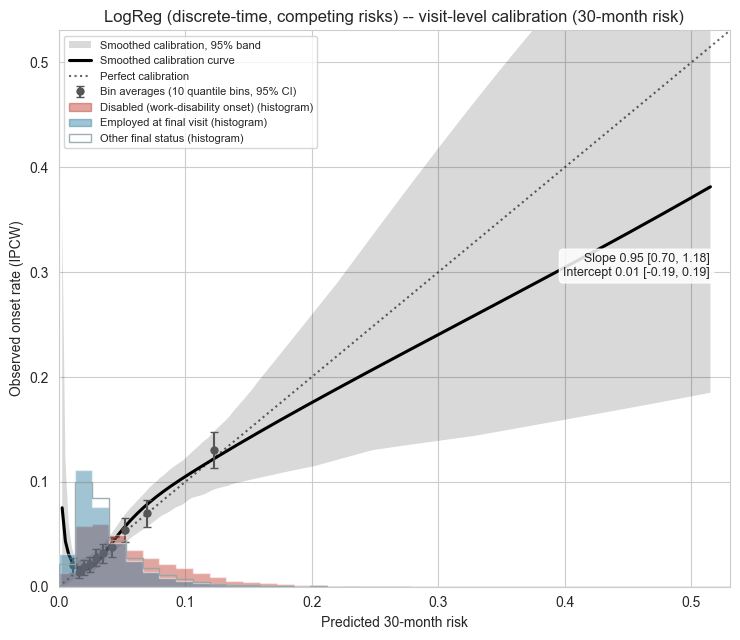


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits
Model,,,,,,
LogReg,5,0.573 (0.009),0.745 (0.006),0.701 (0.006),0.101 (0.005),47.250 (0.427)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LogReg,5,0.203 (0.015),0.332 (0.015),0.423 (0.010),0.487 (0.014),0.610 (0.012),0.947 (0.003),0.897 (0.002),0.849 (0.003),0.801 (0.003),0.706 (0.005)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LogReg,5,0.706 (0.006),0.703 (0.006),0.702 (0.006),0.700 (0.006),0.699 (0.006),0.695 (0.006),0.689 (0.007),0.684 (0.007)


Configuration chosen per fold (visit-level cross-fitted pAUROC): {0.003: 15, 0.0003: 4, 0.001: 4, 0.01: 2}


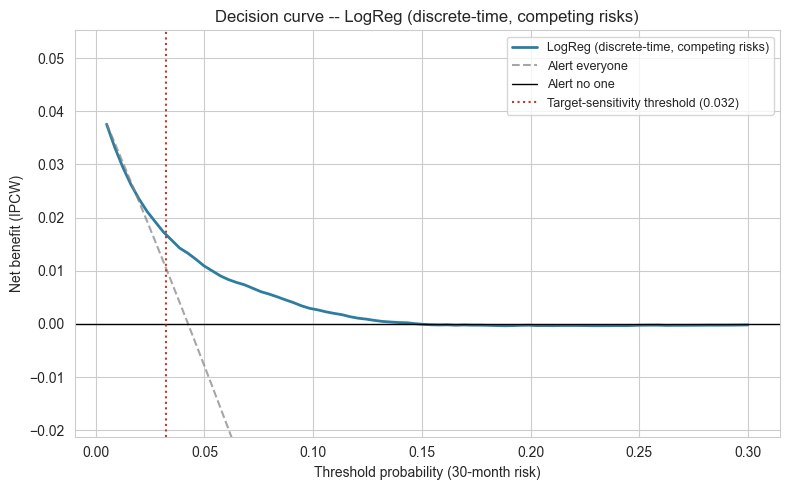

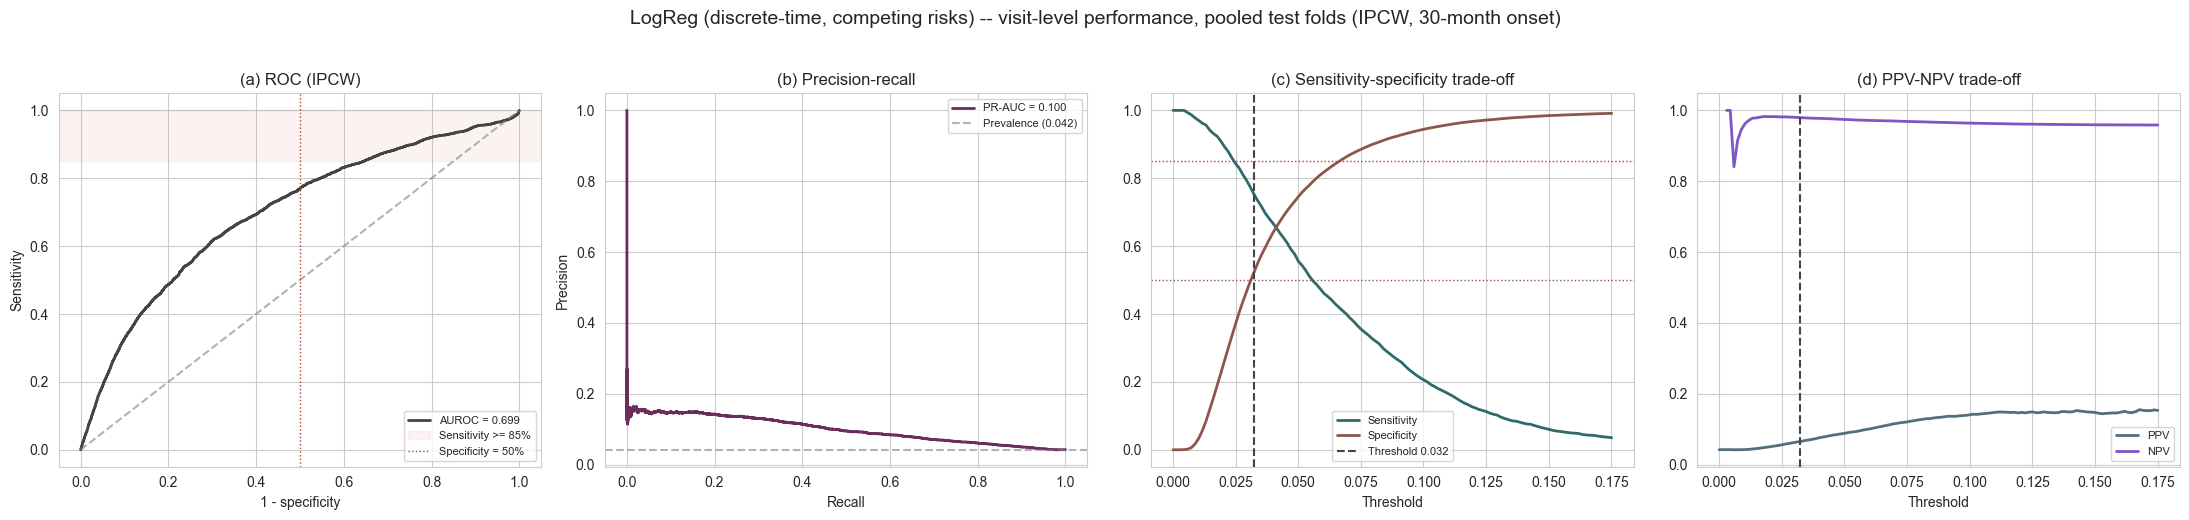

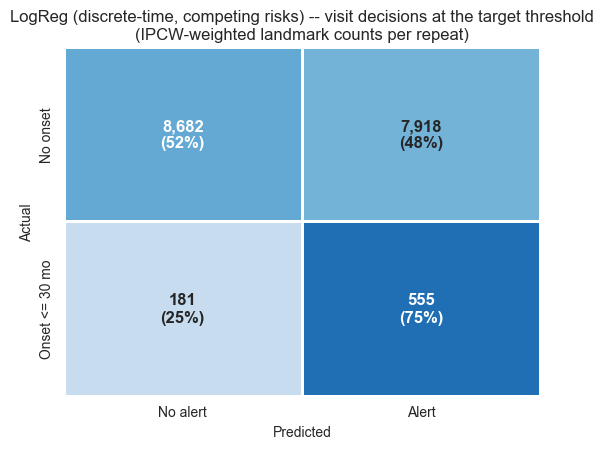

LogReg: final refit on all rows (config 0.003, 21 features) in 1s


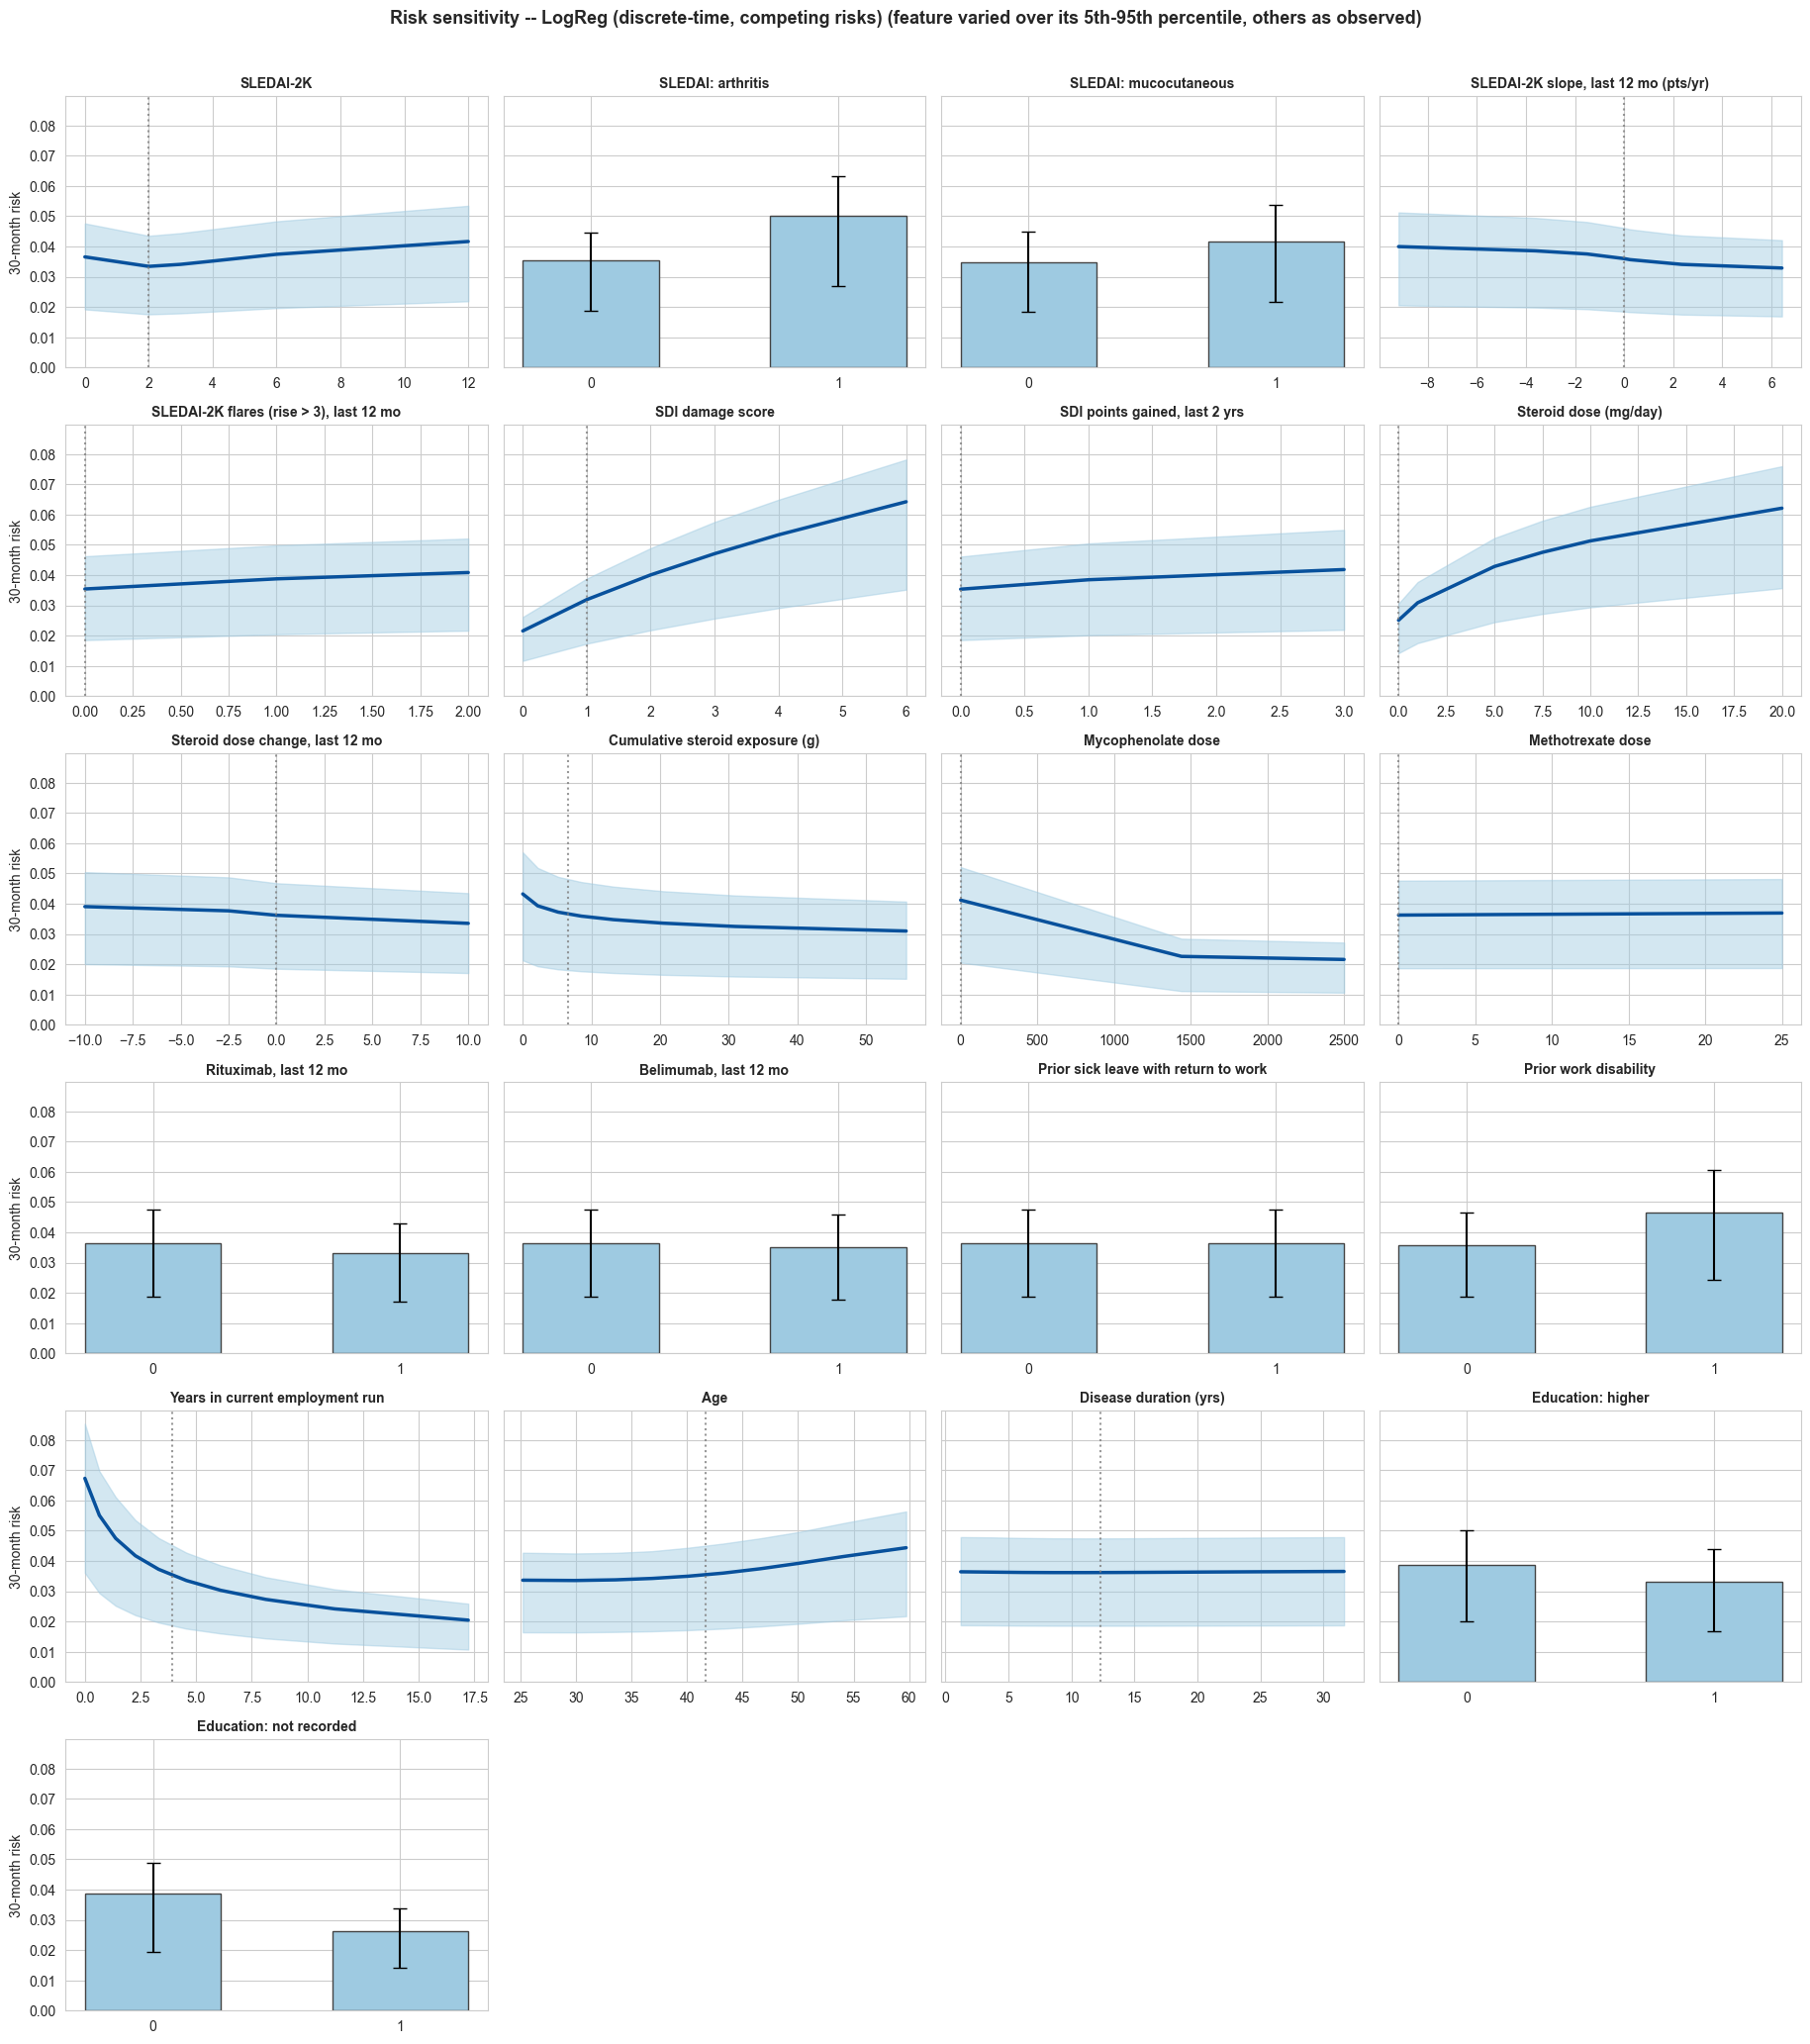


Risk-sensitivity summary -- LogReg (discrete-time, competing risks) (mean 30-month risk; ranked by swing)
                                Feature  Risk @ low  Risk @ high  Risk swing (max-min)
        Years in current employment run      0.0673       0.0204                0.0469
                       SDI damage score      0.0215       0.0642                0.0427
                  Steroid dose (mg/day)      0.0251       0.0621                0.0370
                     Mycophenolate dose      0.0412       0.0216                0.0196
                      SLEDAI: arthritis      0.0353       0.0502                0.0149
                Education: not recorded      0.0387       0.0262                0.0125
        Cumulative steroid exposure (g)      0.0432       0.0310                0.0123
                                    Age      0.0336       0.0444                0.0108
                  Prior work disability      0.0357       0.0464                0.0107
                       

In [12]:
"""Model 1/7 -- discrete-time competing-risk (pooled multinomial) logistic regression: cumulative incidence of work
disability with other exits and death competing. Splines for age, SLEDAI-2K and disease duration; L2 penalty C tuned
inside each training fold on cross-fitted high-sensitivity pAUROC."""
res_logreg = run_analysis("LogReg", "LogReg (discrete-time, competing risks)")

## 11.10 Model 2/7 — Random survival forest

Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


CV for ['RSF']: 0.0 min this call; 175 model-fold fits in cv_state_model_v5.pkl.


RSF -- VISIT LEVEL (30-month work-disability onset)
  17,338 landmark visits of 1,059 patients; resolved at 30 months: 14,893 (681 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity 85%, specificity floor 50%); mean threshold 0.036
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.6854     | [0.641, 0.726]  Discrimination
Brier Score                    | 0.0399     | [0.033, 0.047]  Overall accuracy (lower=better)
Calibration Slope              | 0.9726     | [0.728, 1.229]  Ideal = 1.0
Calibration Intercept          | 0.0102     | [-0.191, 0.194]  

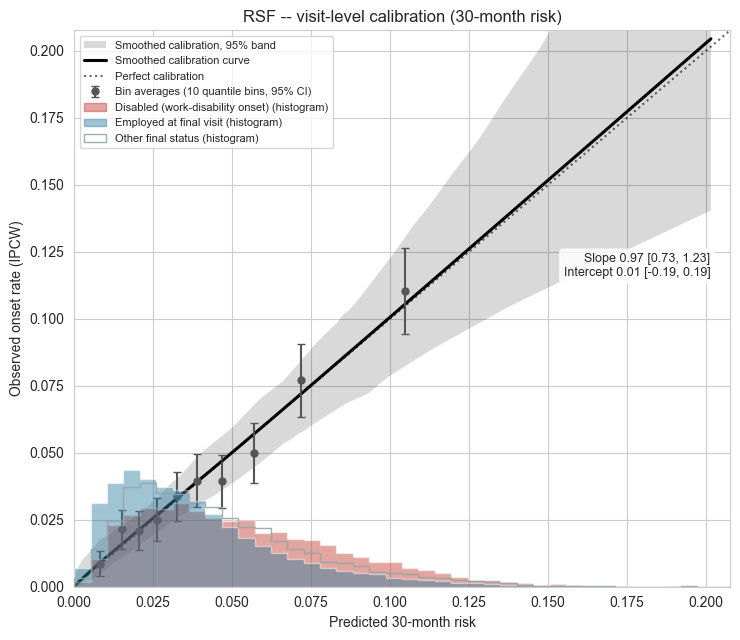


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits
Model,,,,,,
RSF,5,0.589 (0.008),0.726 (0.005),0.685 (0.005),0.086 (0.002),48.655 (0.833)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
RSF,5,0.163 (0.007),0.287 (0.007),0.367 (0.013),0.449 (0.008),0.550 (0.006),0.944 (0.005),0.898 (0.004),0.853 (0.003),0.809 (0.004),0.718 (0.006)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
RSF,5,0.710 (0.007),0.706 (0.006),0.697 (0.005),0.692 (0.005),0.685 (0.005),0.680 (0.005),0.670 (0.005),0.665 (0.006)


Configuration chosen per fold (visit-level cross-fitted pAUROC): {}


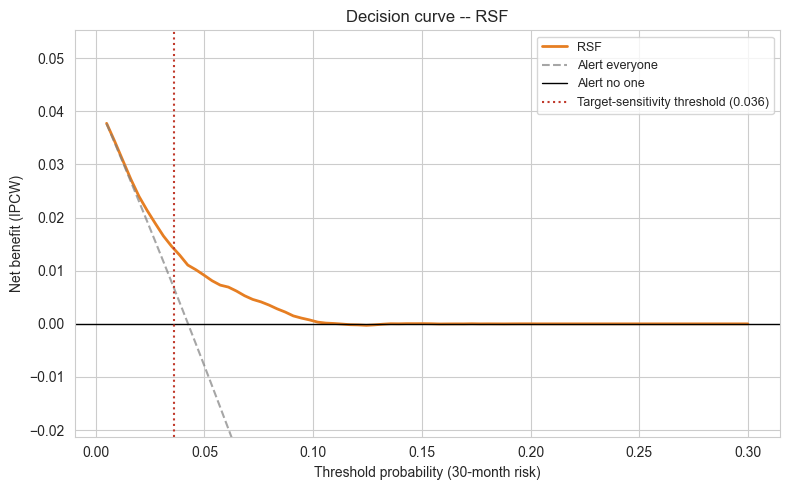

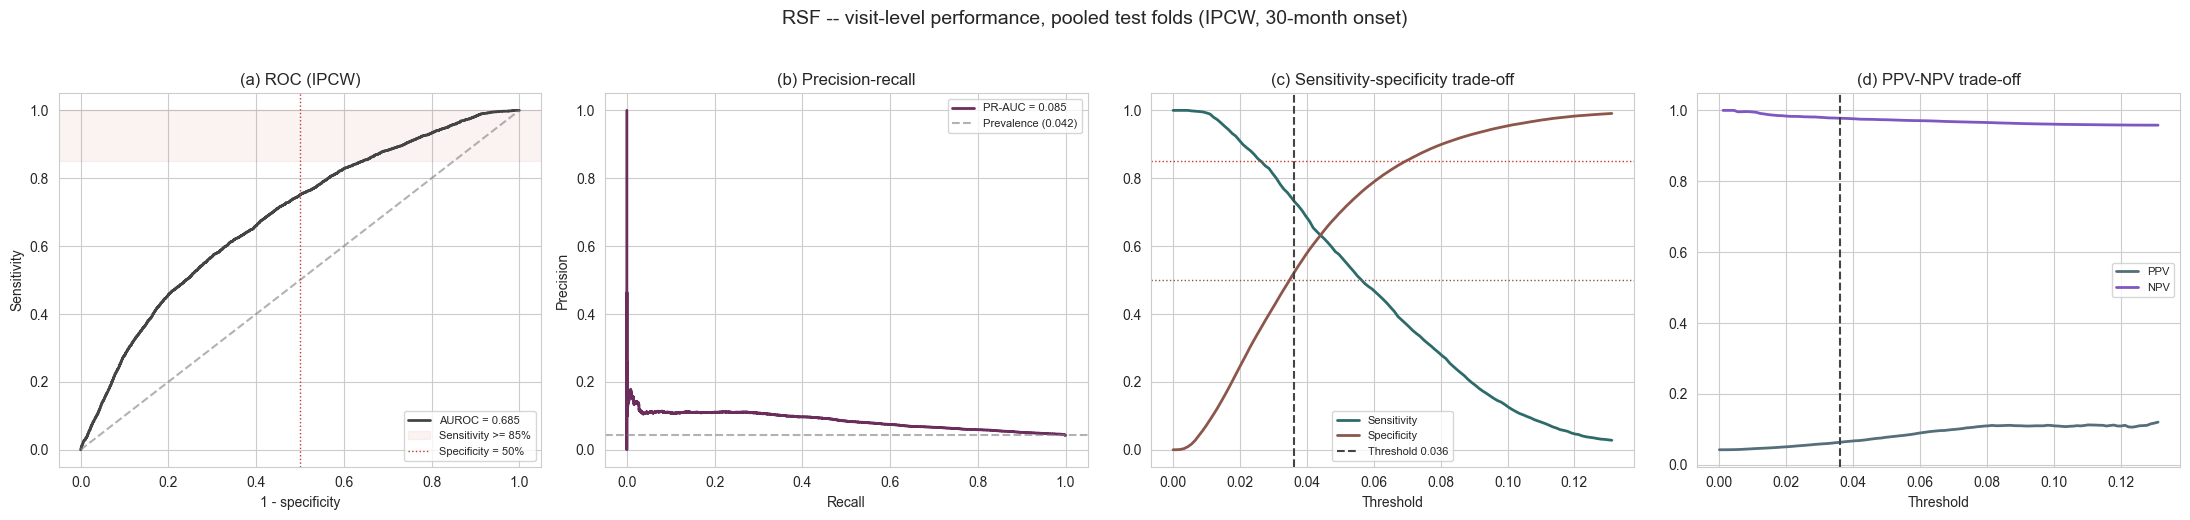

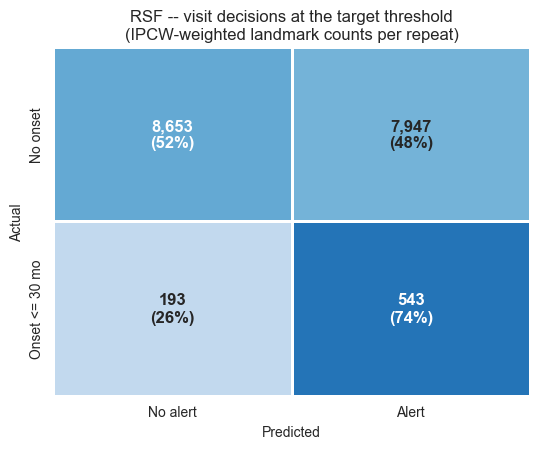

RSF: final refit on all rows (config None, 21 features) in 1s


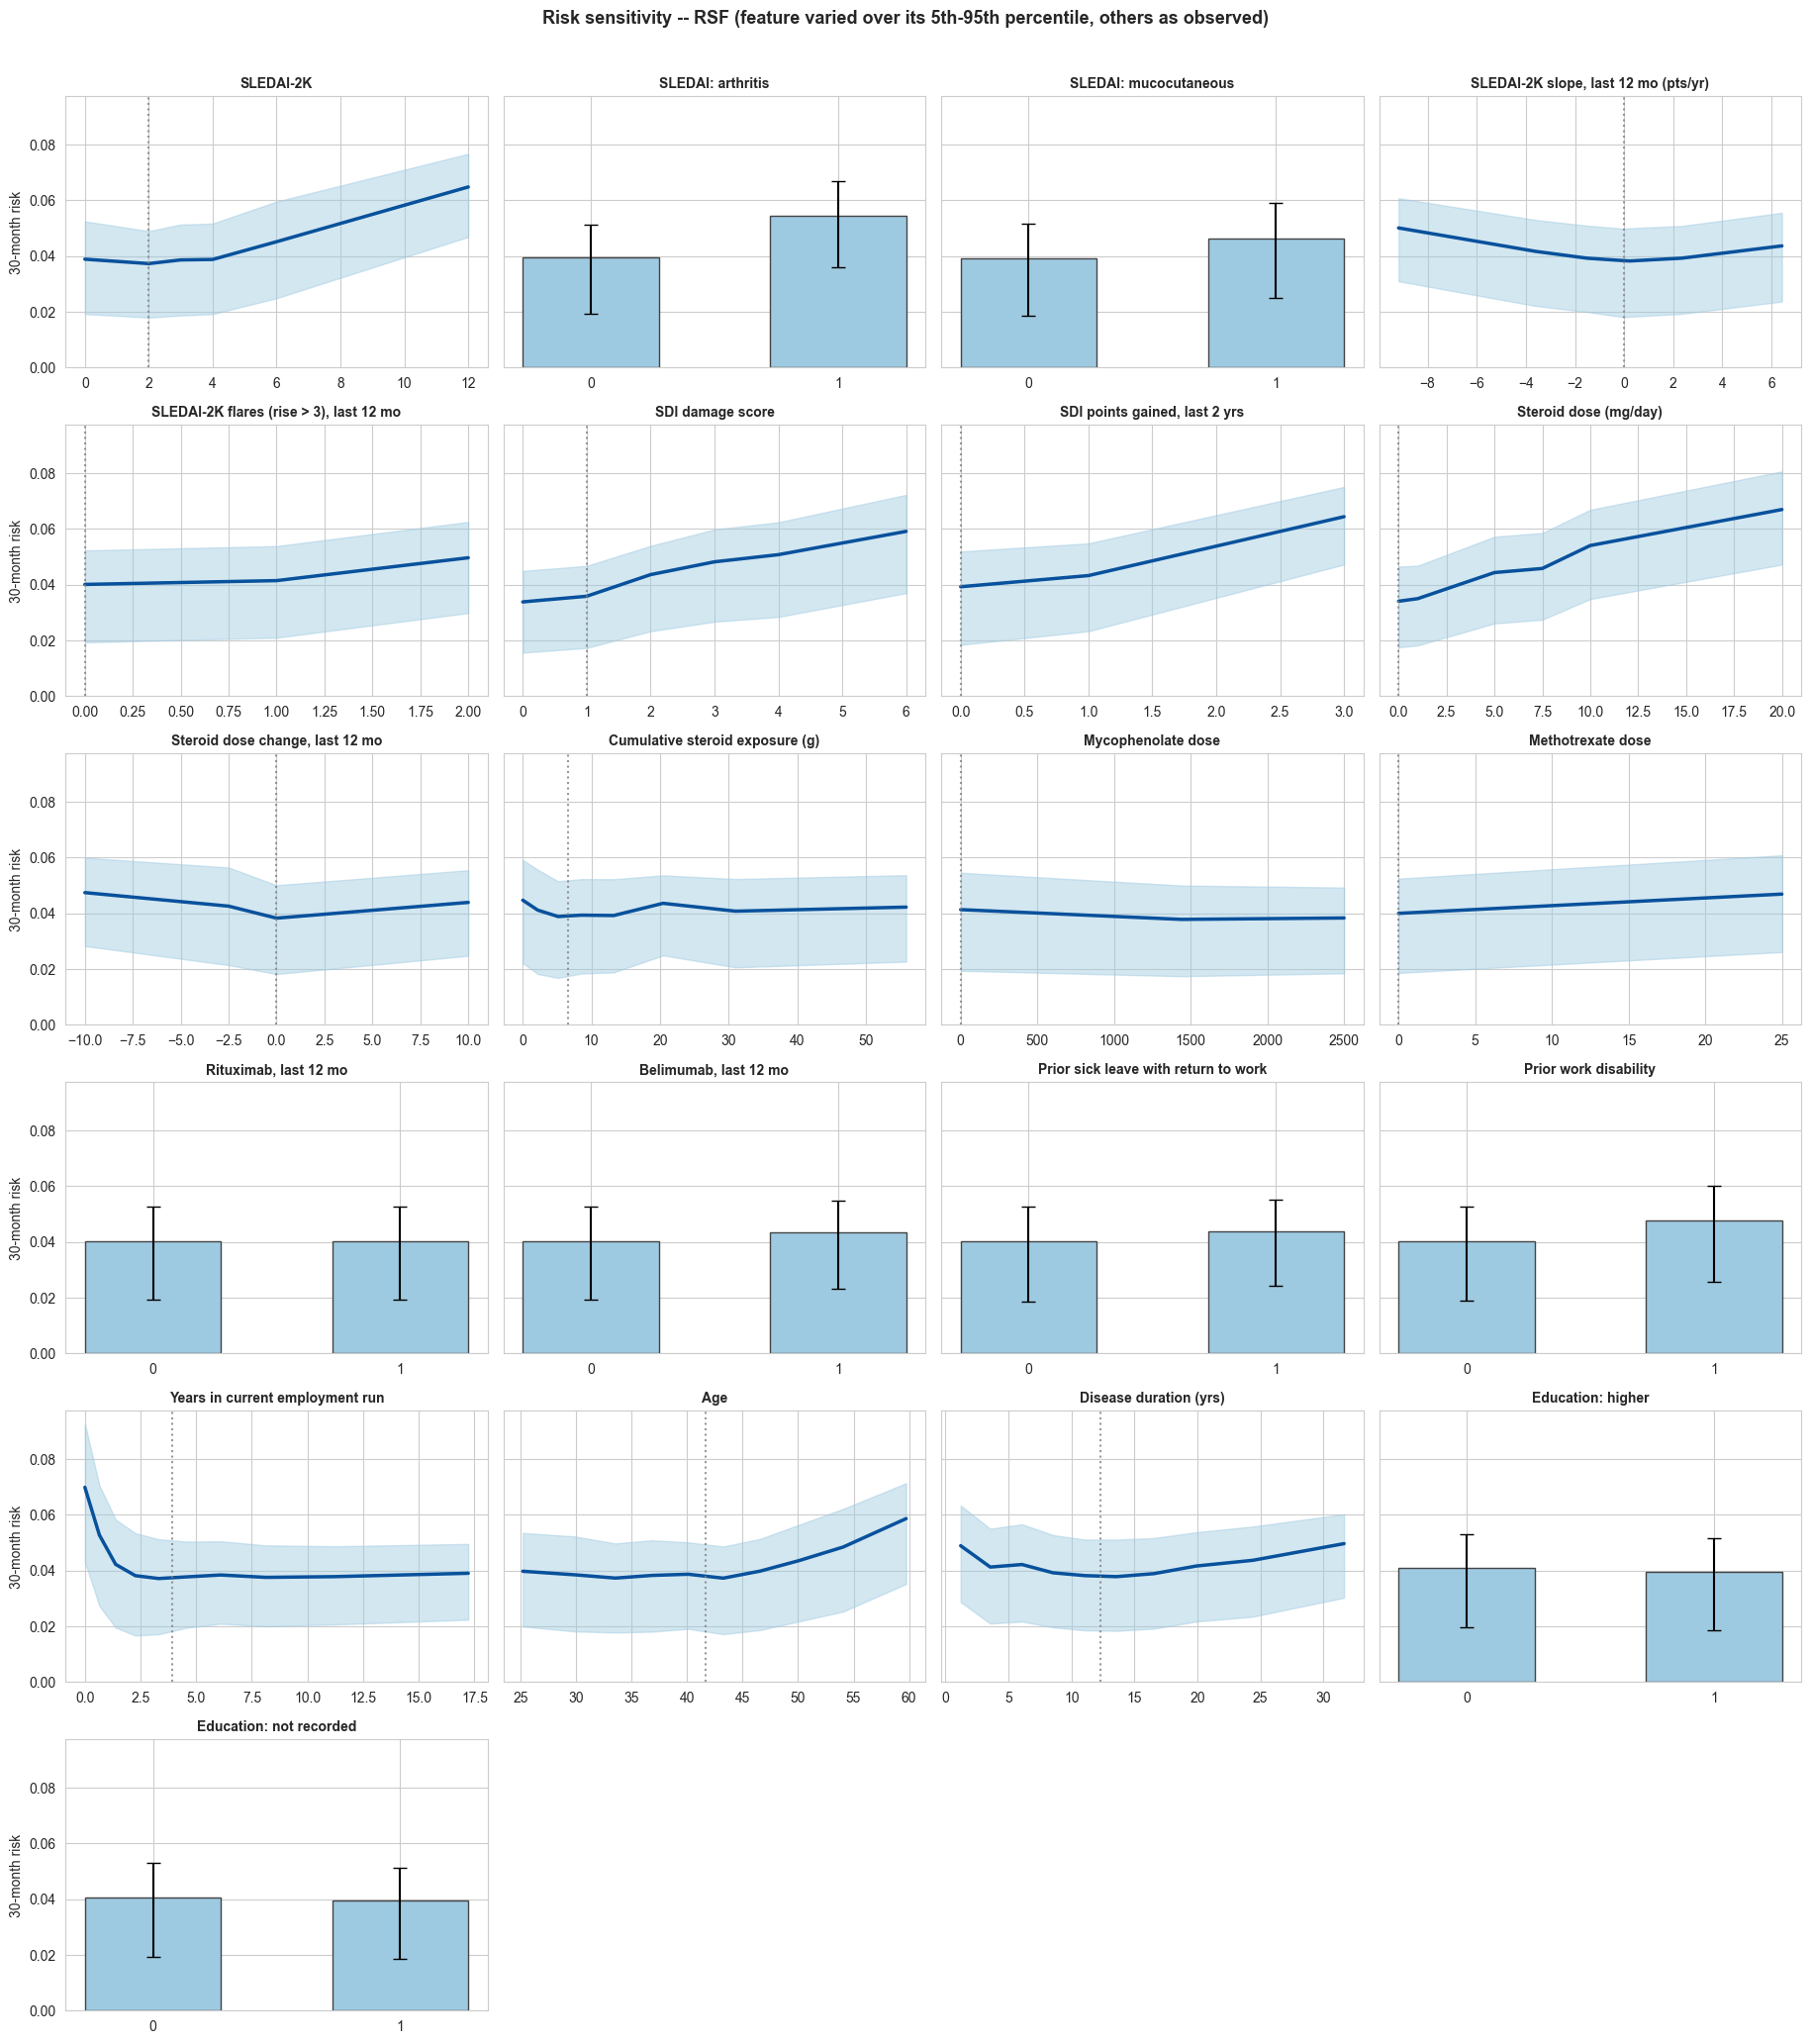


Risk-sensitivity summary -- RSF (mean 30-month risk; ranked by swing)
                                Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                  Steroid dose (mg/day)      0.0340       0.0669                0.0329
        Years in current employment run      0.0698       0.0390                0.0327
                              SLEDAI-2K      0.0388       0.0647                0.0275
                       SDI damage score      0.0338       0.0590                0.0253
          SDI points gained, last 2 yrs      0.0392       0.0643                0.0251
                                    Age      0.0397       0.0586                0.0213
                      SLEDAI: arthritis      0.0396       0.0544                0.0148
   SLEDAI-2K slope, last 12 mo (pts/yr)      0.0500       0.0436                0.0118
                 Disease duration (yrs)      0.0488       0.0496                0.0118
SLEDAI-2K flares (rise > 3), last 12 mo      0.0400       0

In [13]:
"""Model 2/7 -- random survival forest on the cause-specific (other exits and deaths censored), 48-month-capped
target (monthly time bins, patient-weighted subsampling). One fixed configuration."""
res_rsf = run_analysis("RSF", "RSF")

## 11.11 Model 3/7 — Cause-specific Cox proportional hazards

Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


CV for ['CoxPH']: 0.0 min this call; 175 model-fold fits in cv_state_model_v5.pkl.


CoxPH (cause-specific) -- VISIT LEVEL (30-month work-disability onset)
  17,338 landmark visits of 1,059 patients; resolved at 30 months: 14,893 (681 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity 85%, specificity floor 50%); mean threshold 0.032
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.6951     | [0.645, 0.737]  Discrimination
Brier Score                    | 0.0397     | [0.033, 0.047]  Overall accuracy (lower=better)
Calibration Slope              | 1.0670     | [0.795, 1.307]  Ideal = 1.0
Calibration Intercept          | 0.0181     

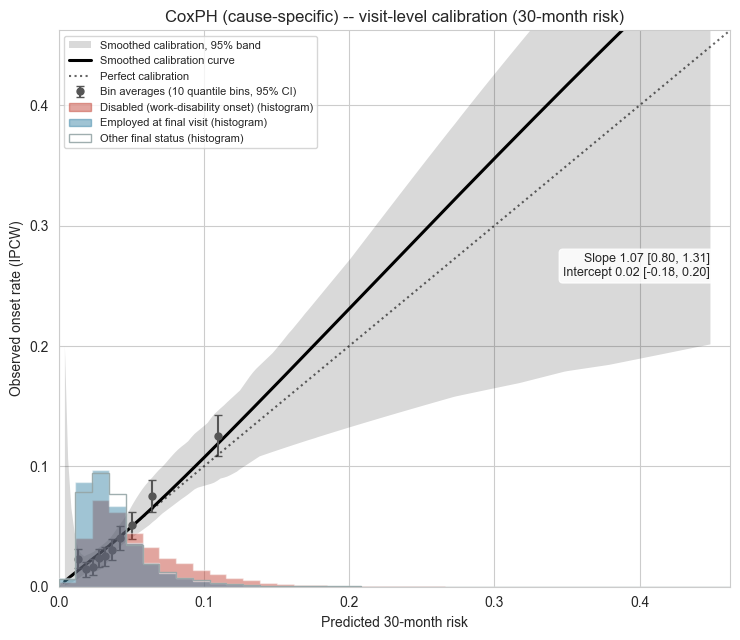


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits
Model,,,,,,
CoxPH,5,0.570 (0.010),0.734 (0.008),0.696 (0.005),0.098 (0.004),49.893 (0.886)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
CoxPH,5,0.153 (0.025),0.291 (0.019),0.387 (0.020),0.470 (0.021),0.589 (0.018),0.962 (0.004),0.917 (0.008),0.869 (0.010),0.819 (0.012),0.715 (0.009)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
CoxPH,5,0.704 (0.012),0.697 (0.007),0.700 (0.005),0.697 (0.005),0.695 (0.005),0.690 (0.004),0.681 (0.002),0.676 (0.003)


Configuration chosen per fold (visit-level cross-fitted pAUROC): {0.1: 18, 1.0: 4, 10.0: 3}


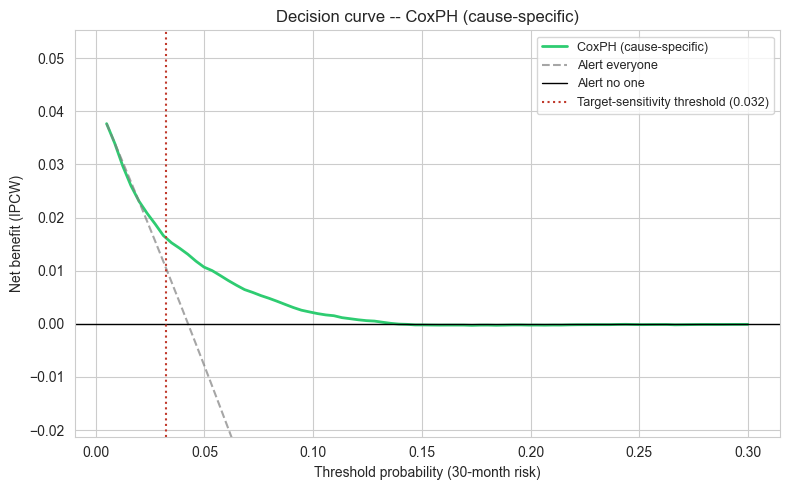

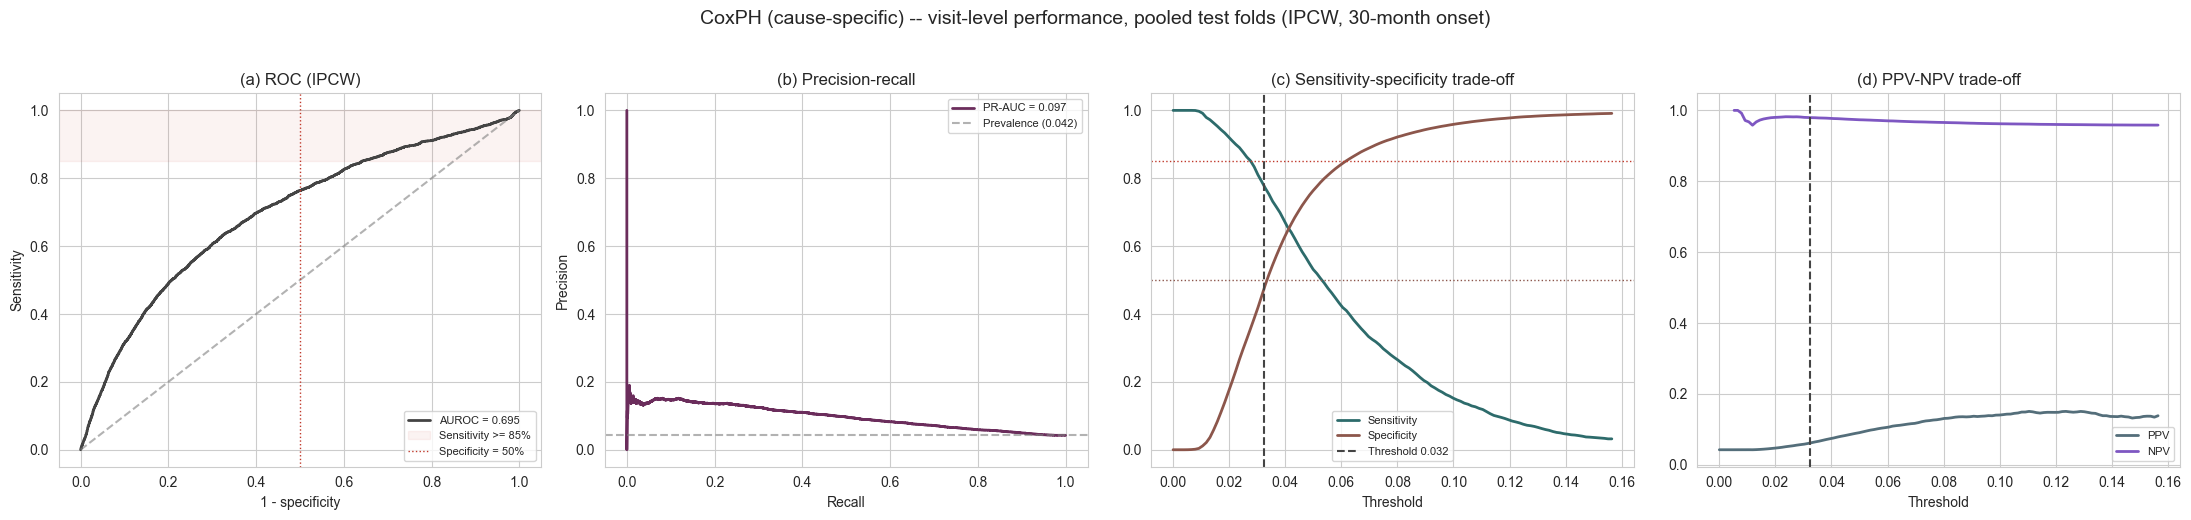

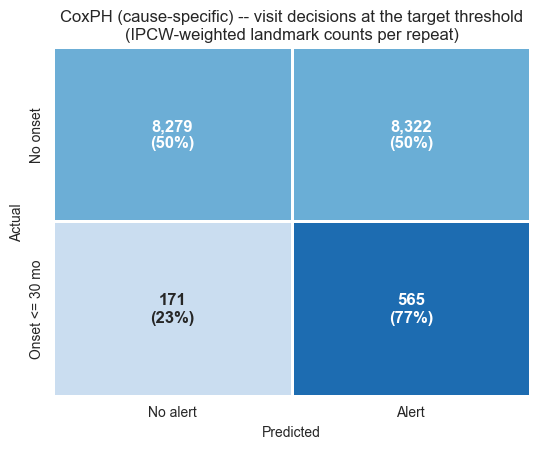

CoxPH: final refit on all rows (config 0.1, 21 features) in 0s


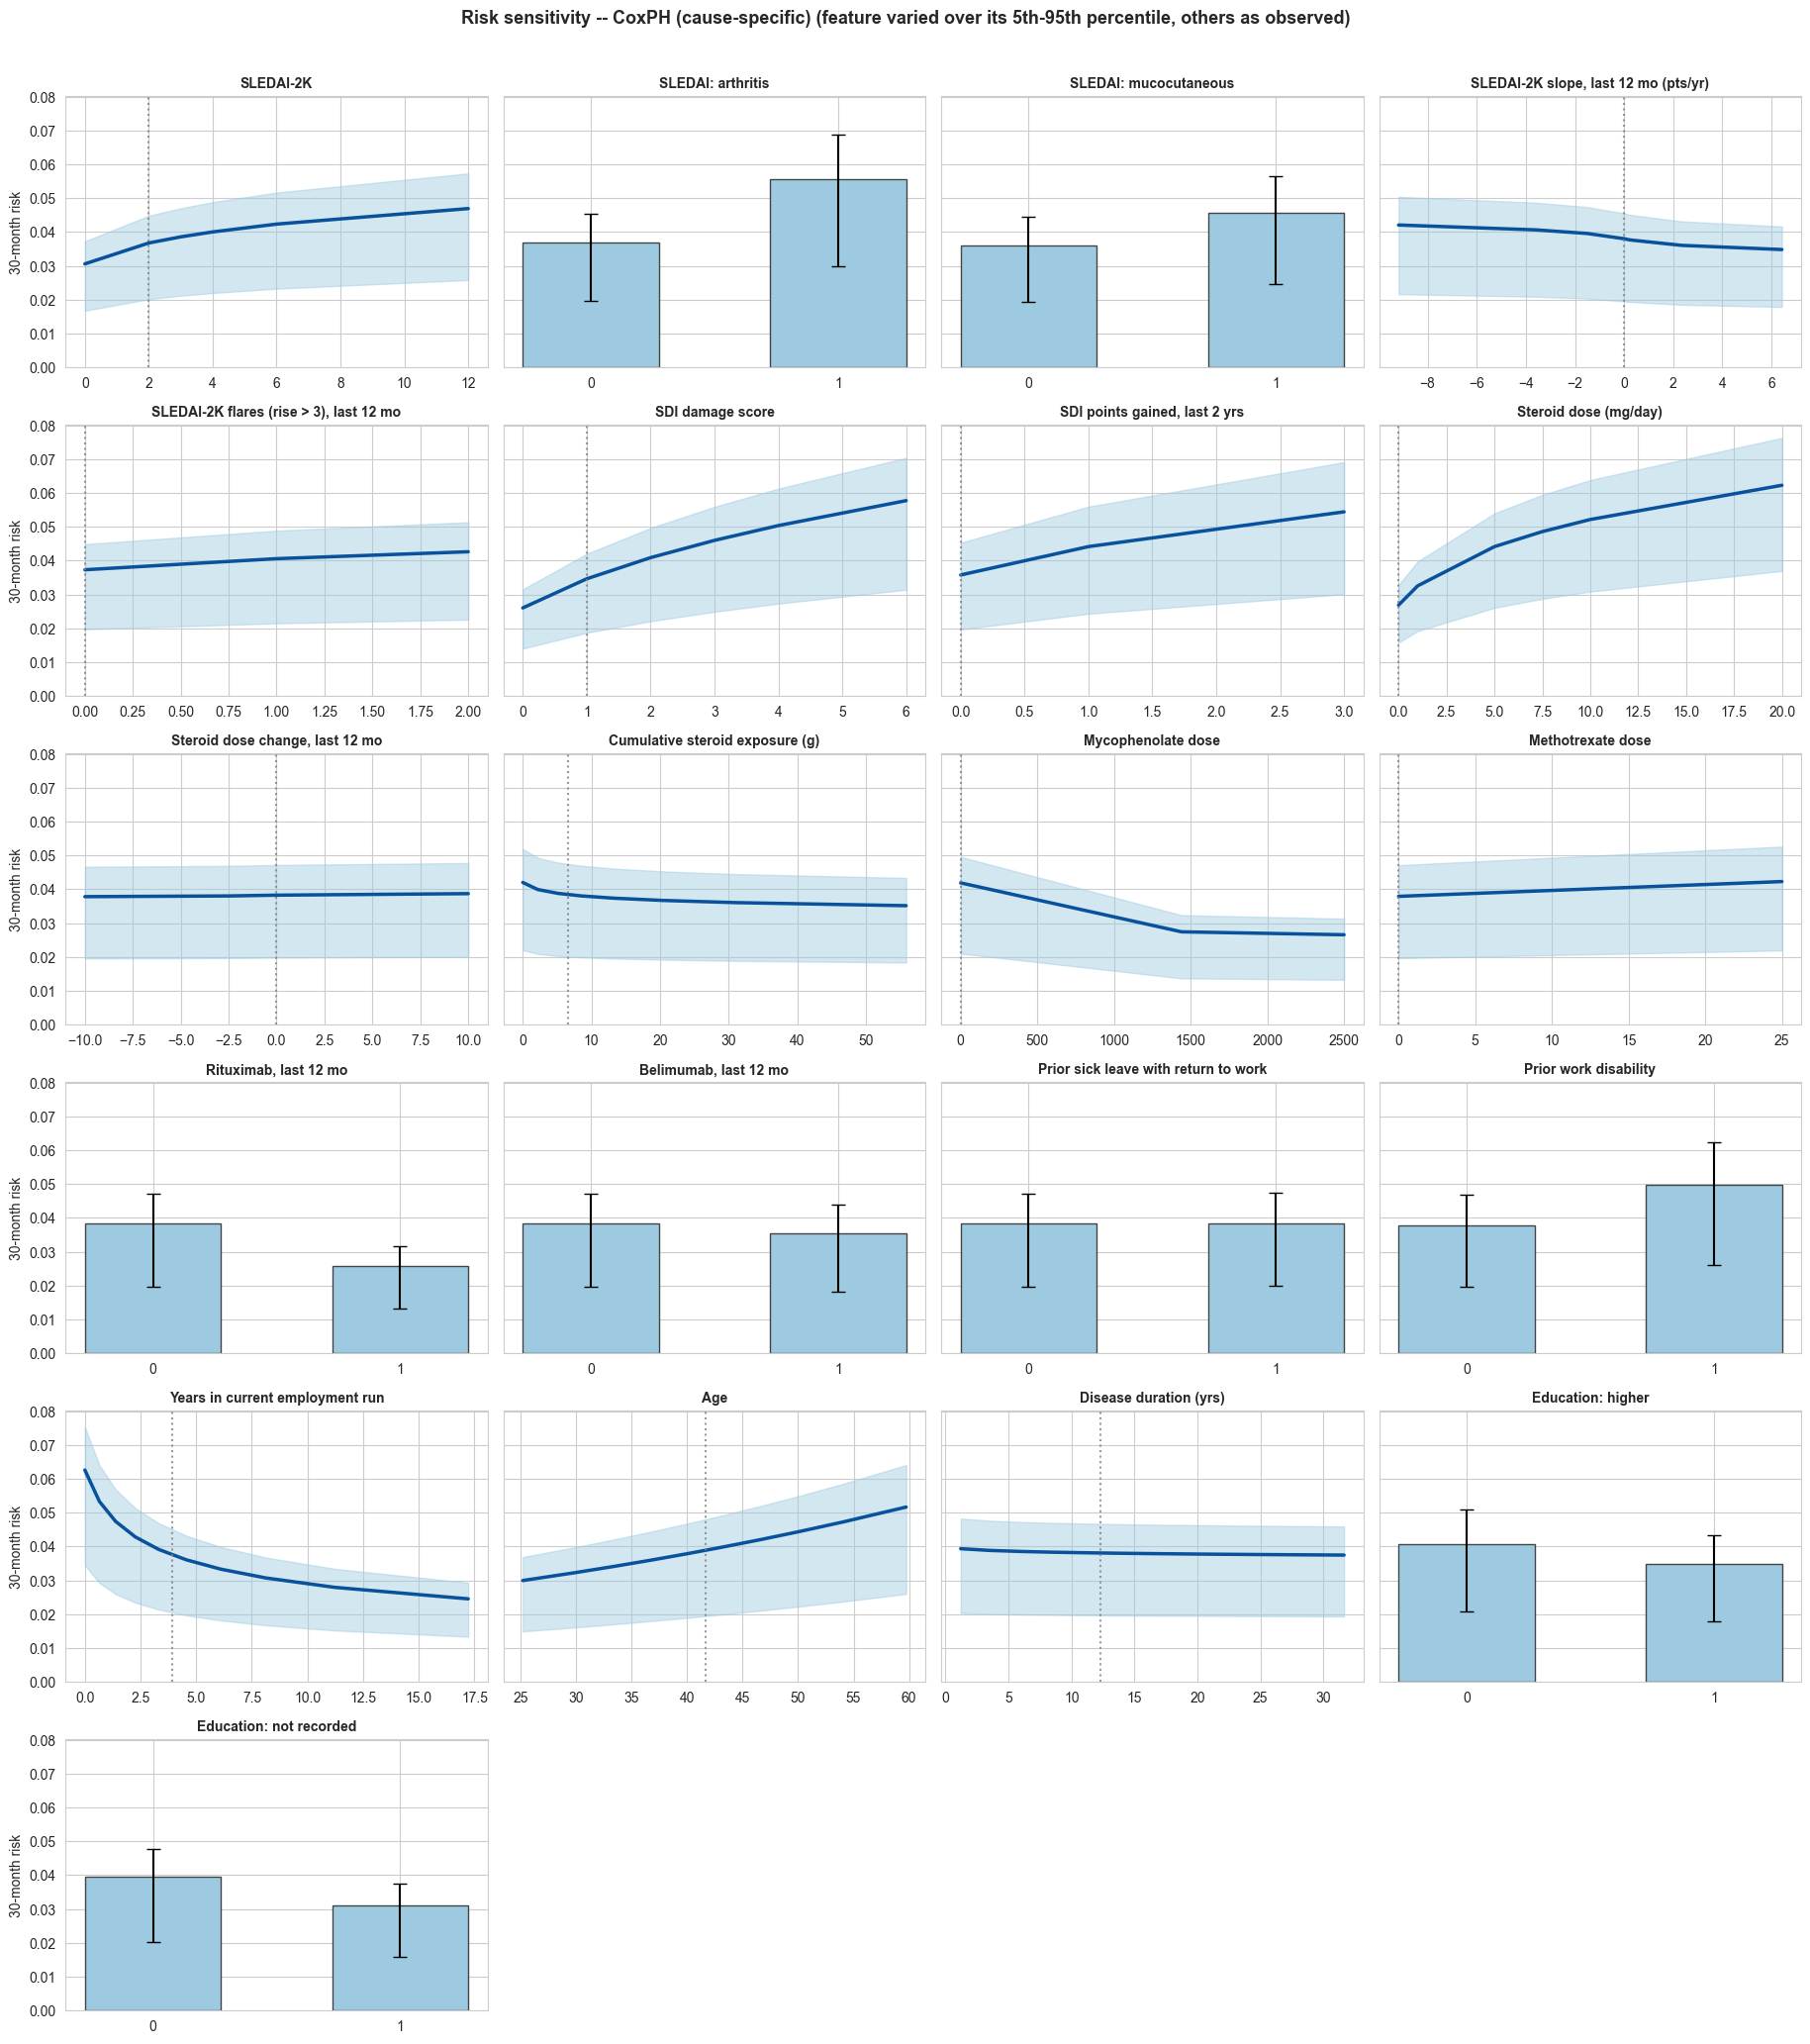


Risk-sensitivity summary -- CoxPH (cause-specific) (mean 30-month risk; ranked by swing)
                                Feature  Risk @ low  Risk @ high  Risk swing (max-min)
        Years in current employment run      0.0626       0.0246                0.0381
                  Steroid dose (mg/day)      0.0269       0.0623                0.0354
                       SDI damage score      0.0261       0.0577                0.0317
                                    Age      0.0300       0.0517                0.0217
                      SLEDAI: arthritis      0.0369       0.0557                0.0188
          SDI points gained, last 2 yrs      0.0358       0.0544                0.0186
                              SLEDAI-2K      0.0306       0.0469                0.0163
                     Mycophenolate dose      0.0419       0.0266                0.0153
                  Rituximab, last 12 mo      0.0383       0.0257                0.0126
                  Prior work disability 

,coef,exp(coef),p
covariate,,,
Steroid dose (mg/day),0.232,1.261,0.000
SDI damage score,0.198,1.219,0.000
Years in current employment run,-0.201,0.818,0.000
Age,0.122,1.130,0.000
Mycophenolate dose,-0.124,0.883,0.000
SLEDAI-2K,0.102,1.107,0.000
SLEDAI: arthritis,0.079,1.082,0.000
"SDI points gained, last 2 yrs",0.068,1.070,0.000
SLEDAI: mucocutaneous,0.064,1.066,0.000


In [14]:
"""Model 3/7 -- cause-specific Cox proportional hazards (other exits and deaths censored), follow-up capped at 48 months;
ridge penalizer tuned inside each training fold."""
res_cox = run_analysis("CoxPH", "CoxPH (cause-specific)")
if res_cox is not None:
    print("\nCox hazard ratios, final refit on all rows (standardised features; for description only):")
    display(res_cox["final"]["fitted"].cph.summary[["coef", "exp(coef)", "p"]]
            .rename(index=lambda c: DISPLAY_NAMES.get(c, c)).sort_values("p").round(3))

## 11.12 Model 4/7 — GRU

Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


CV for ['GRU']: 0.0 min this call; 175 model-fold fits in cv_state_model_v5.pkl.


GRU -- VISIT LEVEL (30-month work-disability onset)
  17,338 landmark visits of 1,059 patients; resolved at 30 months: 14,893 (681 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity 85%, specificity floor 50%); mean threshold 0.033
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.6945     | [0.641, 0.741]  Discrimination
Brier Score                    | 0.0396     | [0.033, 0.047]  Overall accuracy (lower=better)
Calibration Slope              | 1.1035     | [0.812, 1.376]  Ideal = 1.0
Calibration Intercept          | -0.0177    | [-0.218, 0.165]  

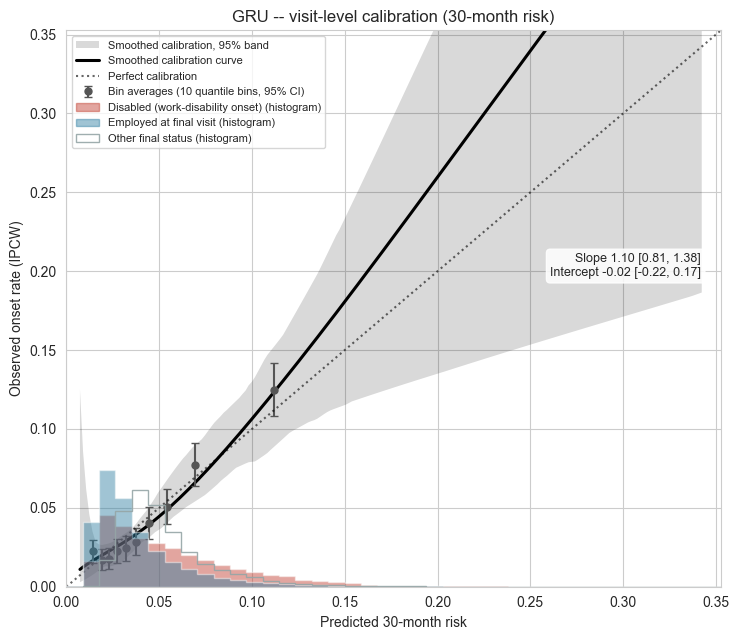


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits
Model,,,,,,
GRU,5,0.565 (0.011),0.725 (0.006),0.698 (0.007),0.100 (0.006),50.390 (3.699)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
GRU,5,0.207 (0.035),0.338 (0.023),0.437 (0.021),0.507 (0.021),0.627 (0.022),0.945 (0.011),0.895 (0.008),0.842 (0.010),0.790 (0.015),0.684 (0.023)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
GRU,5,0.689 (0.005),0.702 (0.005),0.703 (0.006),0.699 (0.007),0.695 (0.007),0.692 (0.008),0.686 (0.008),0.680 (0.008)


Configuration chosen per fold (visit-level cross-fitted pAUROC): {'h32_pretrain': 25}
Early stopping, outer-fold fits: median 18 epochs (range 14-25)


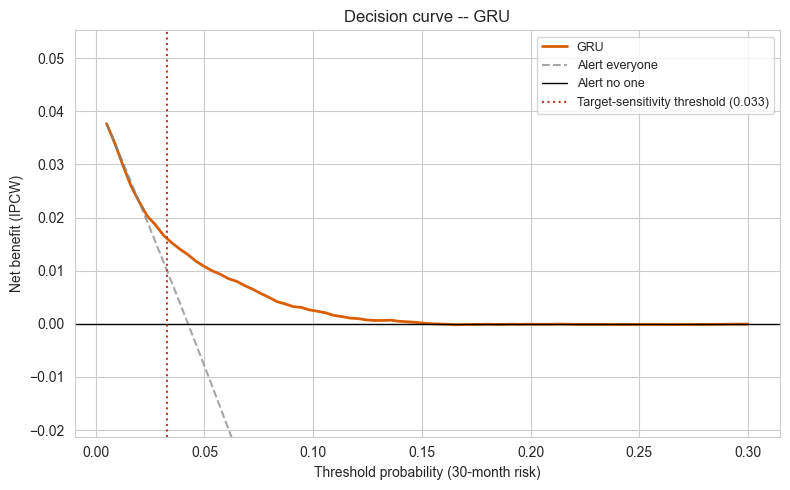

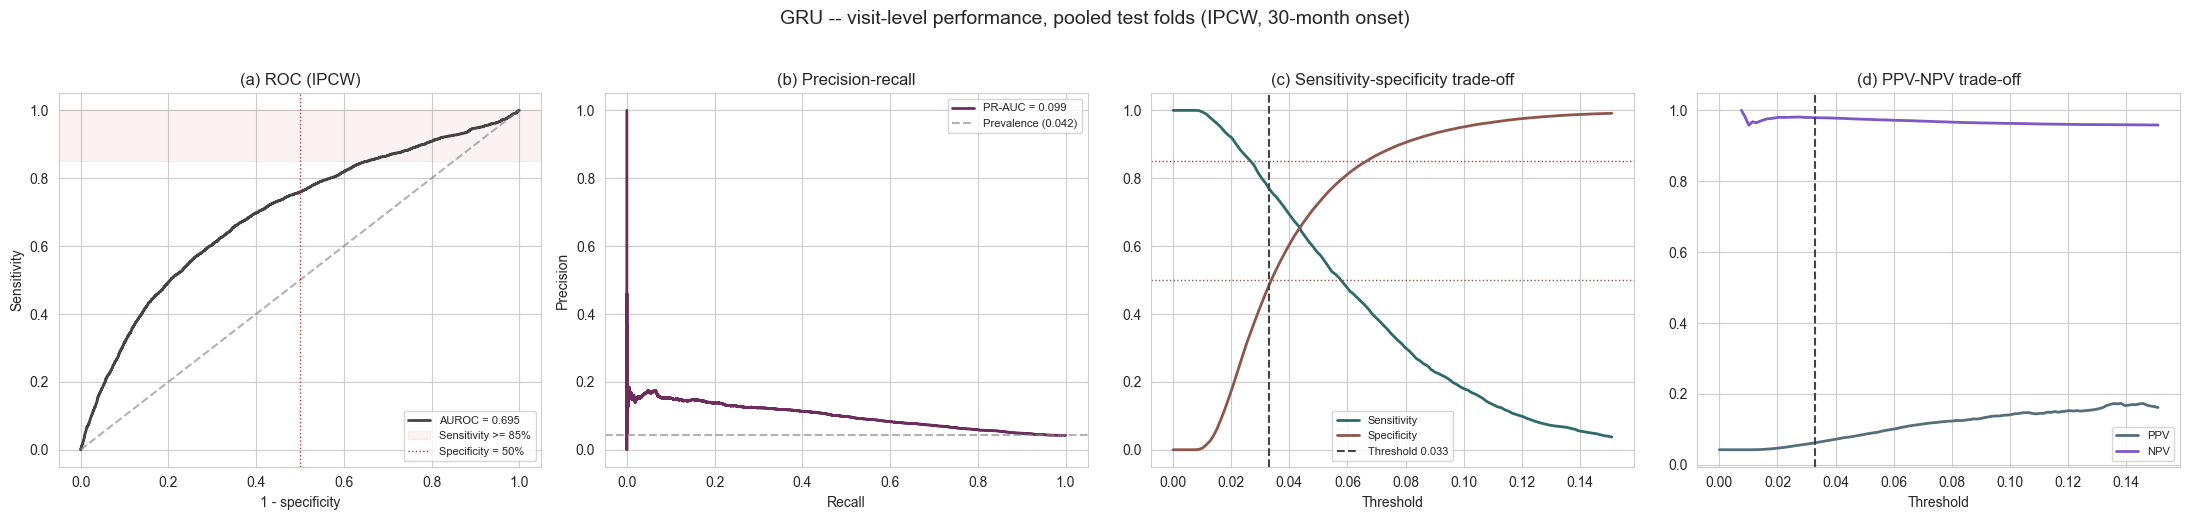

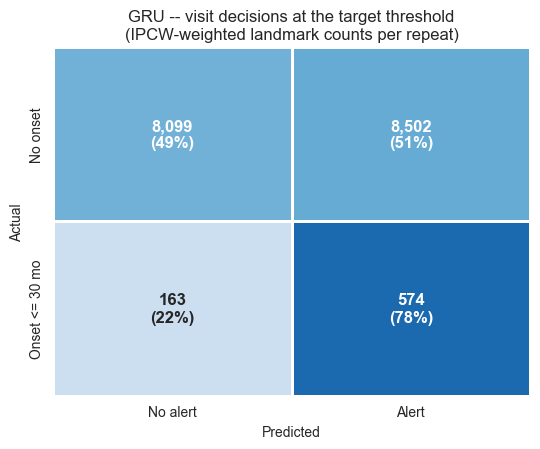

GRU: final refit on all rows (config h32_pretrain, 21 features) in 41s


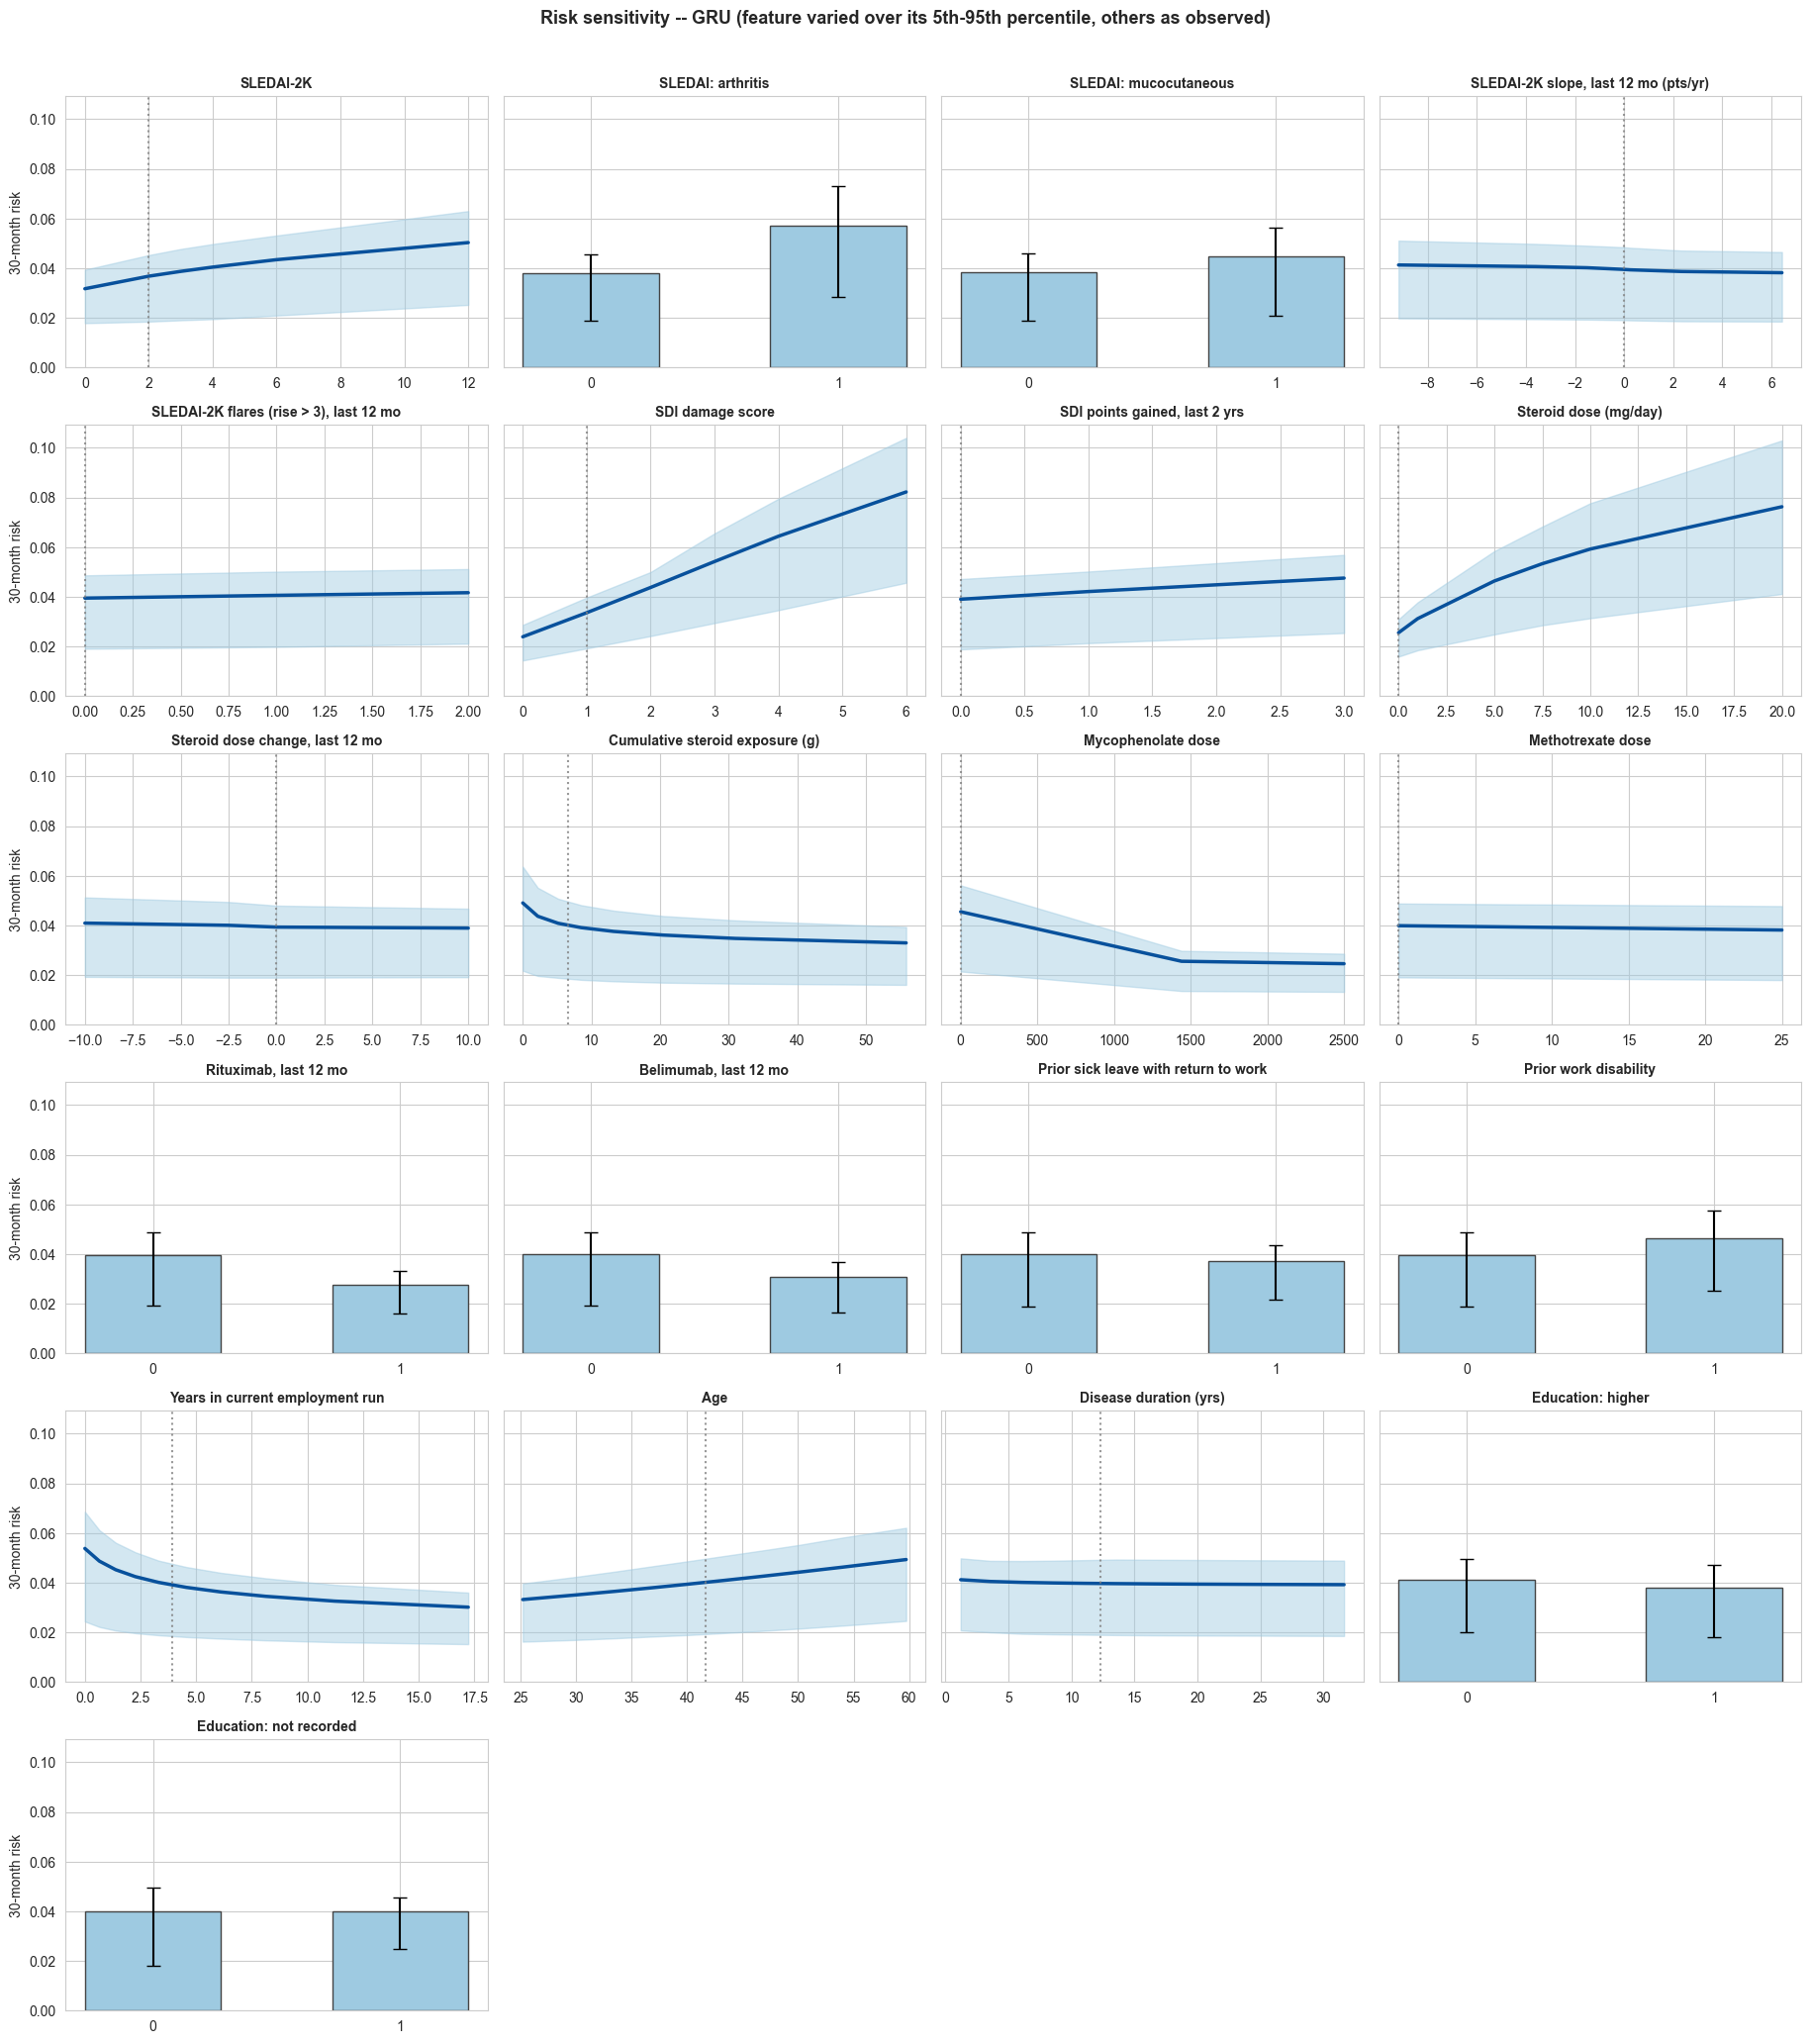


Risk-sensitivity summary -- GRU (mean 30-month risk; ranked by swing)
                                Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                       SDI damage score      0.0239       0.0822                0.0583
                  Steroid dose (mg/day)      0.0255       0.0762                0.0507
        Years in current employment run      0.0538       0.0301                0.0236
                     Mycophenolate dose      0.0455       0.0246                0.0209
                      SLEDAI: arthritis      0.0379       0.0571                0.0192
                              SLEDAI-2K      0.0317       0.0503                0.0186
                                    Age      0.0332       0.0493                0.0161
        Cumulative steroid exposure (g)      0.0490       0.0330                0.0161
                  Rituximab, last 12 mo      0.0397       0.0277                0.0120
                  Belimumab, last 12 mo      0.0398       0

In [15]:
"""Model 4/7 -- GRU (the main model's recipe -- inputs, pretraining, competing-risk head, early stopping, 5 seeds --
with a GRU cell)."""
res_gru = run_analysis("GRU", "GRU")

## 11.13 Model 5/7 — LSTM (main model, toy-sweep winner)

Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


CV for ['LSTM']: 0.0 min this call; 175 model-fold fits in cv_state_model_v5.pkl.


LSTM (main model, toy-sweep winner) -- VISIT LEVEL (30-month work-disability onset)
  17,338 landmark visits of 1,059 patients; resolved at 30 months: 14,893 (681 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity 85%, specificity floor 50%); mean threshold 0.031
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.6999     | [0.652, 0.744]  Discrimination
Brier Score                    | 0.0397     | [0.033, 0.047]  Overall accuracy (lower=better)
Calibration Slope              | 1.0544     | [0.820, 1.278]  Ideal = 1.0
Calibration Intercept          

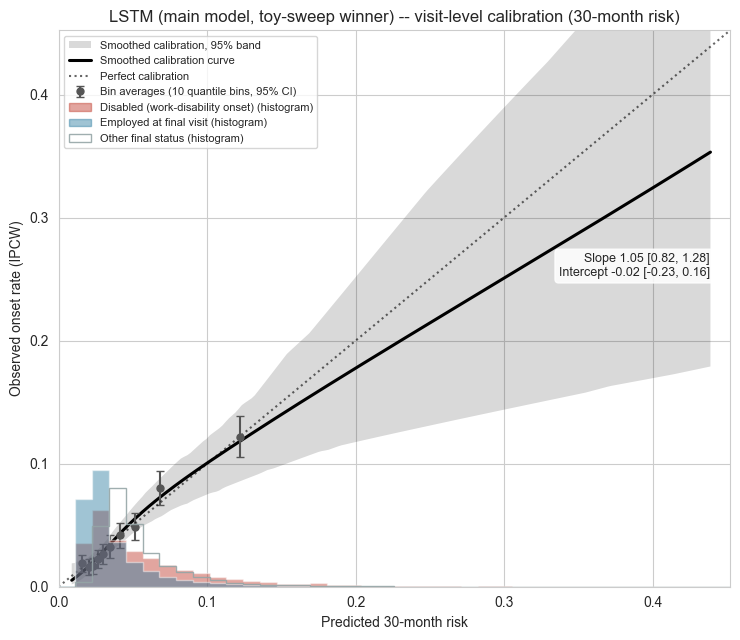


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits
Model,,,,,,
LSTM,5,0.581 (0.007),0.726 (0.008),0.704 (0.004),0.098 (0.006),49.111 (2.808)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM,5,0.204 (0.037),0.338 (0.032),0.442 (0.027),0.514 (0.017),0.624 (0.013),0.943 (0.011),0.891 (0.011),0.838 (0.007),0.787 (0.008),0.683 (0.014)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM,5,0.688 (0.008),0.703 (0.006),0.707 (0.005),0.703 (0.004),0.700 (0.004),0.698 (0.004),0.692 (0.004),0.686 (0.005)


Configuration chosen per fold (visit-level cross-fitted pAUROC): {'h32_pretrain_state': 12, 'h32_pretrain_skip': 7, 'h32_pretrain': 6}
Early stopping, outer-fold fits: median 17 epochs (range 13-23)


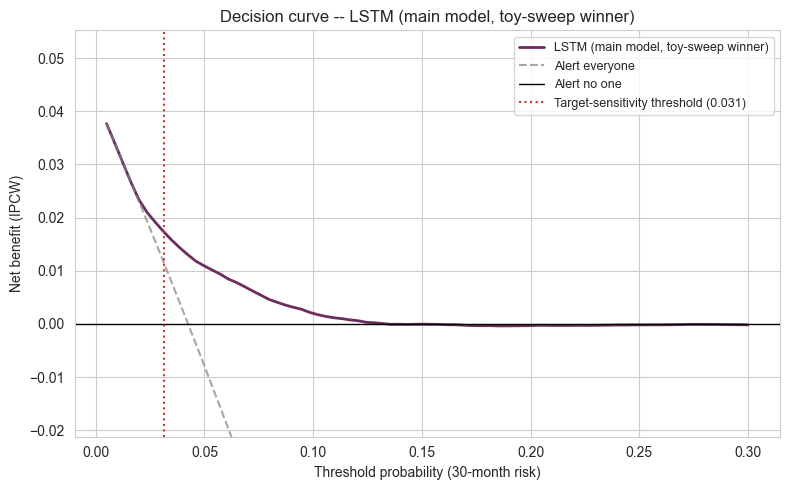

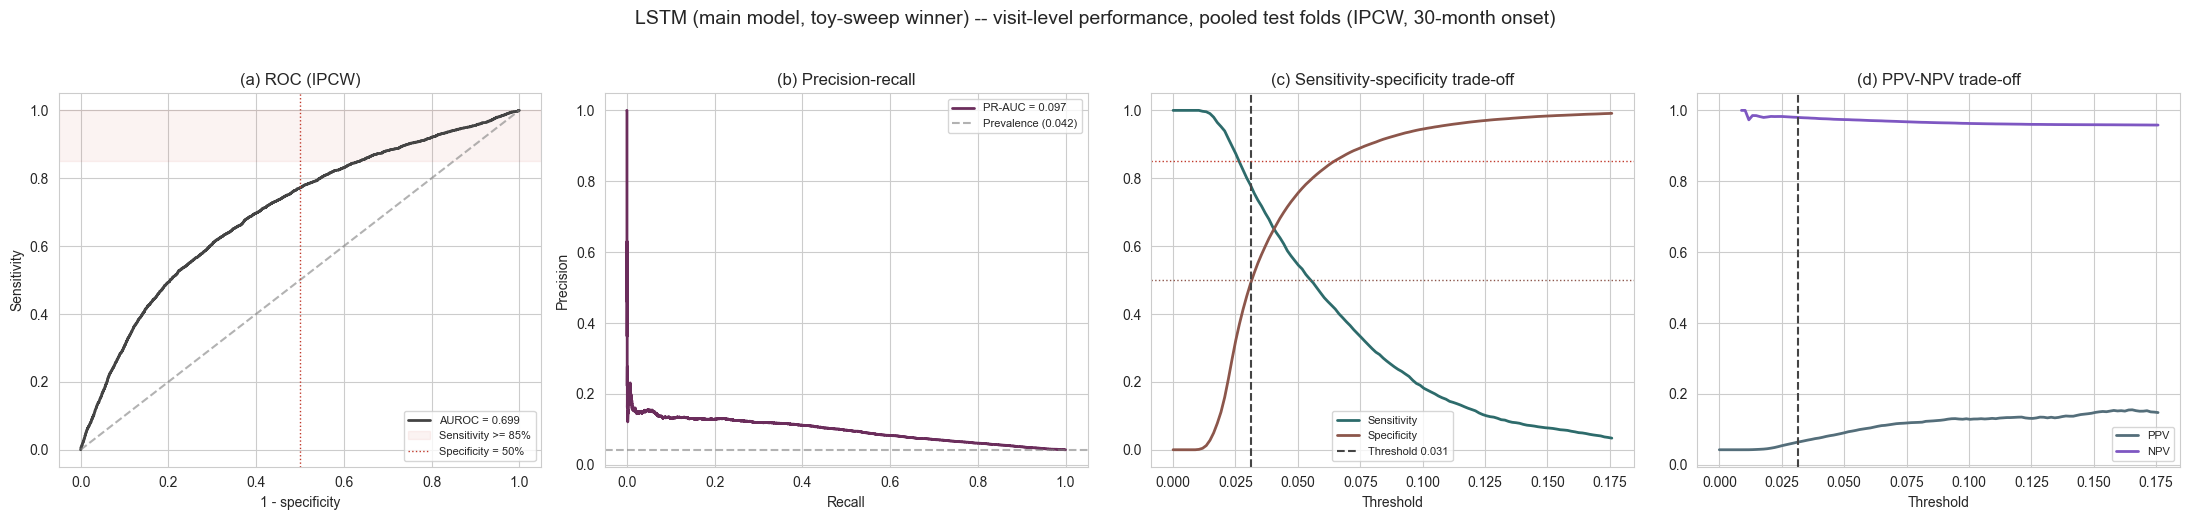

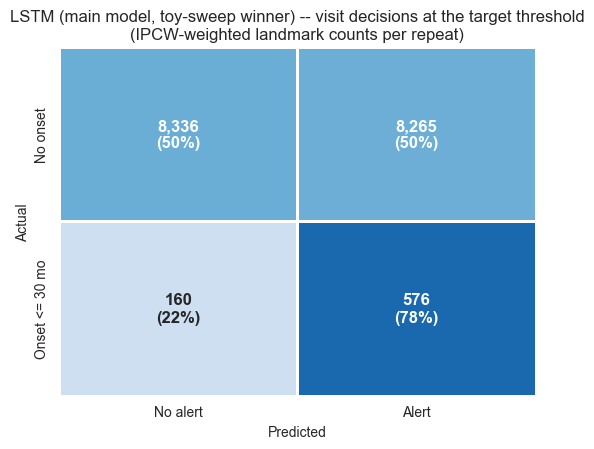

LSTM: final refit on all rows (config h32_pretrain_state, 21 features) in 46s


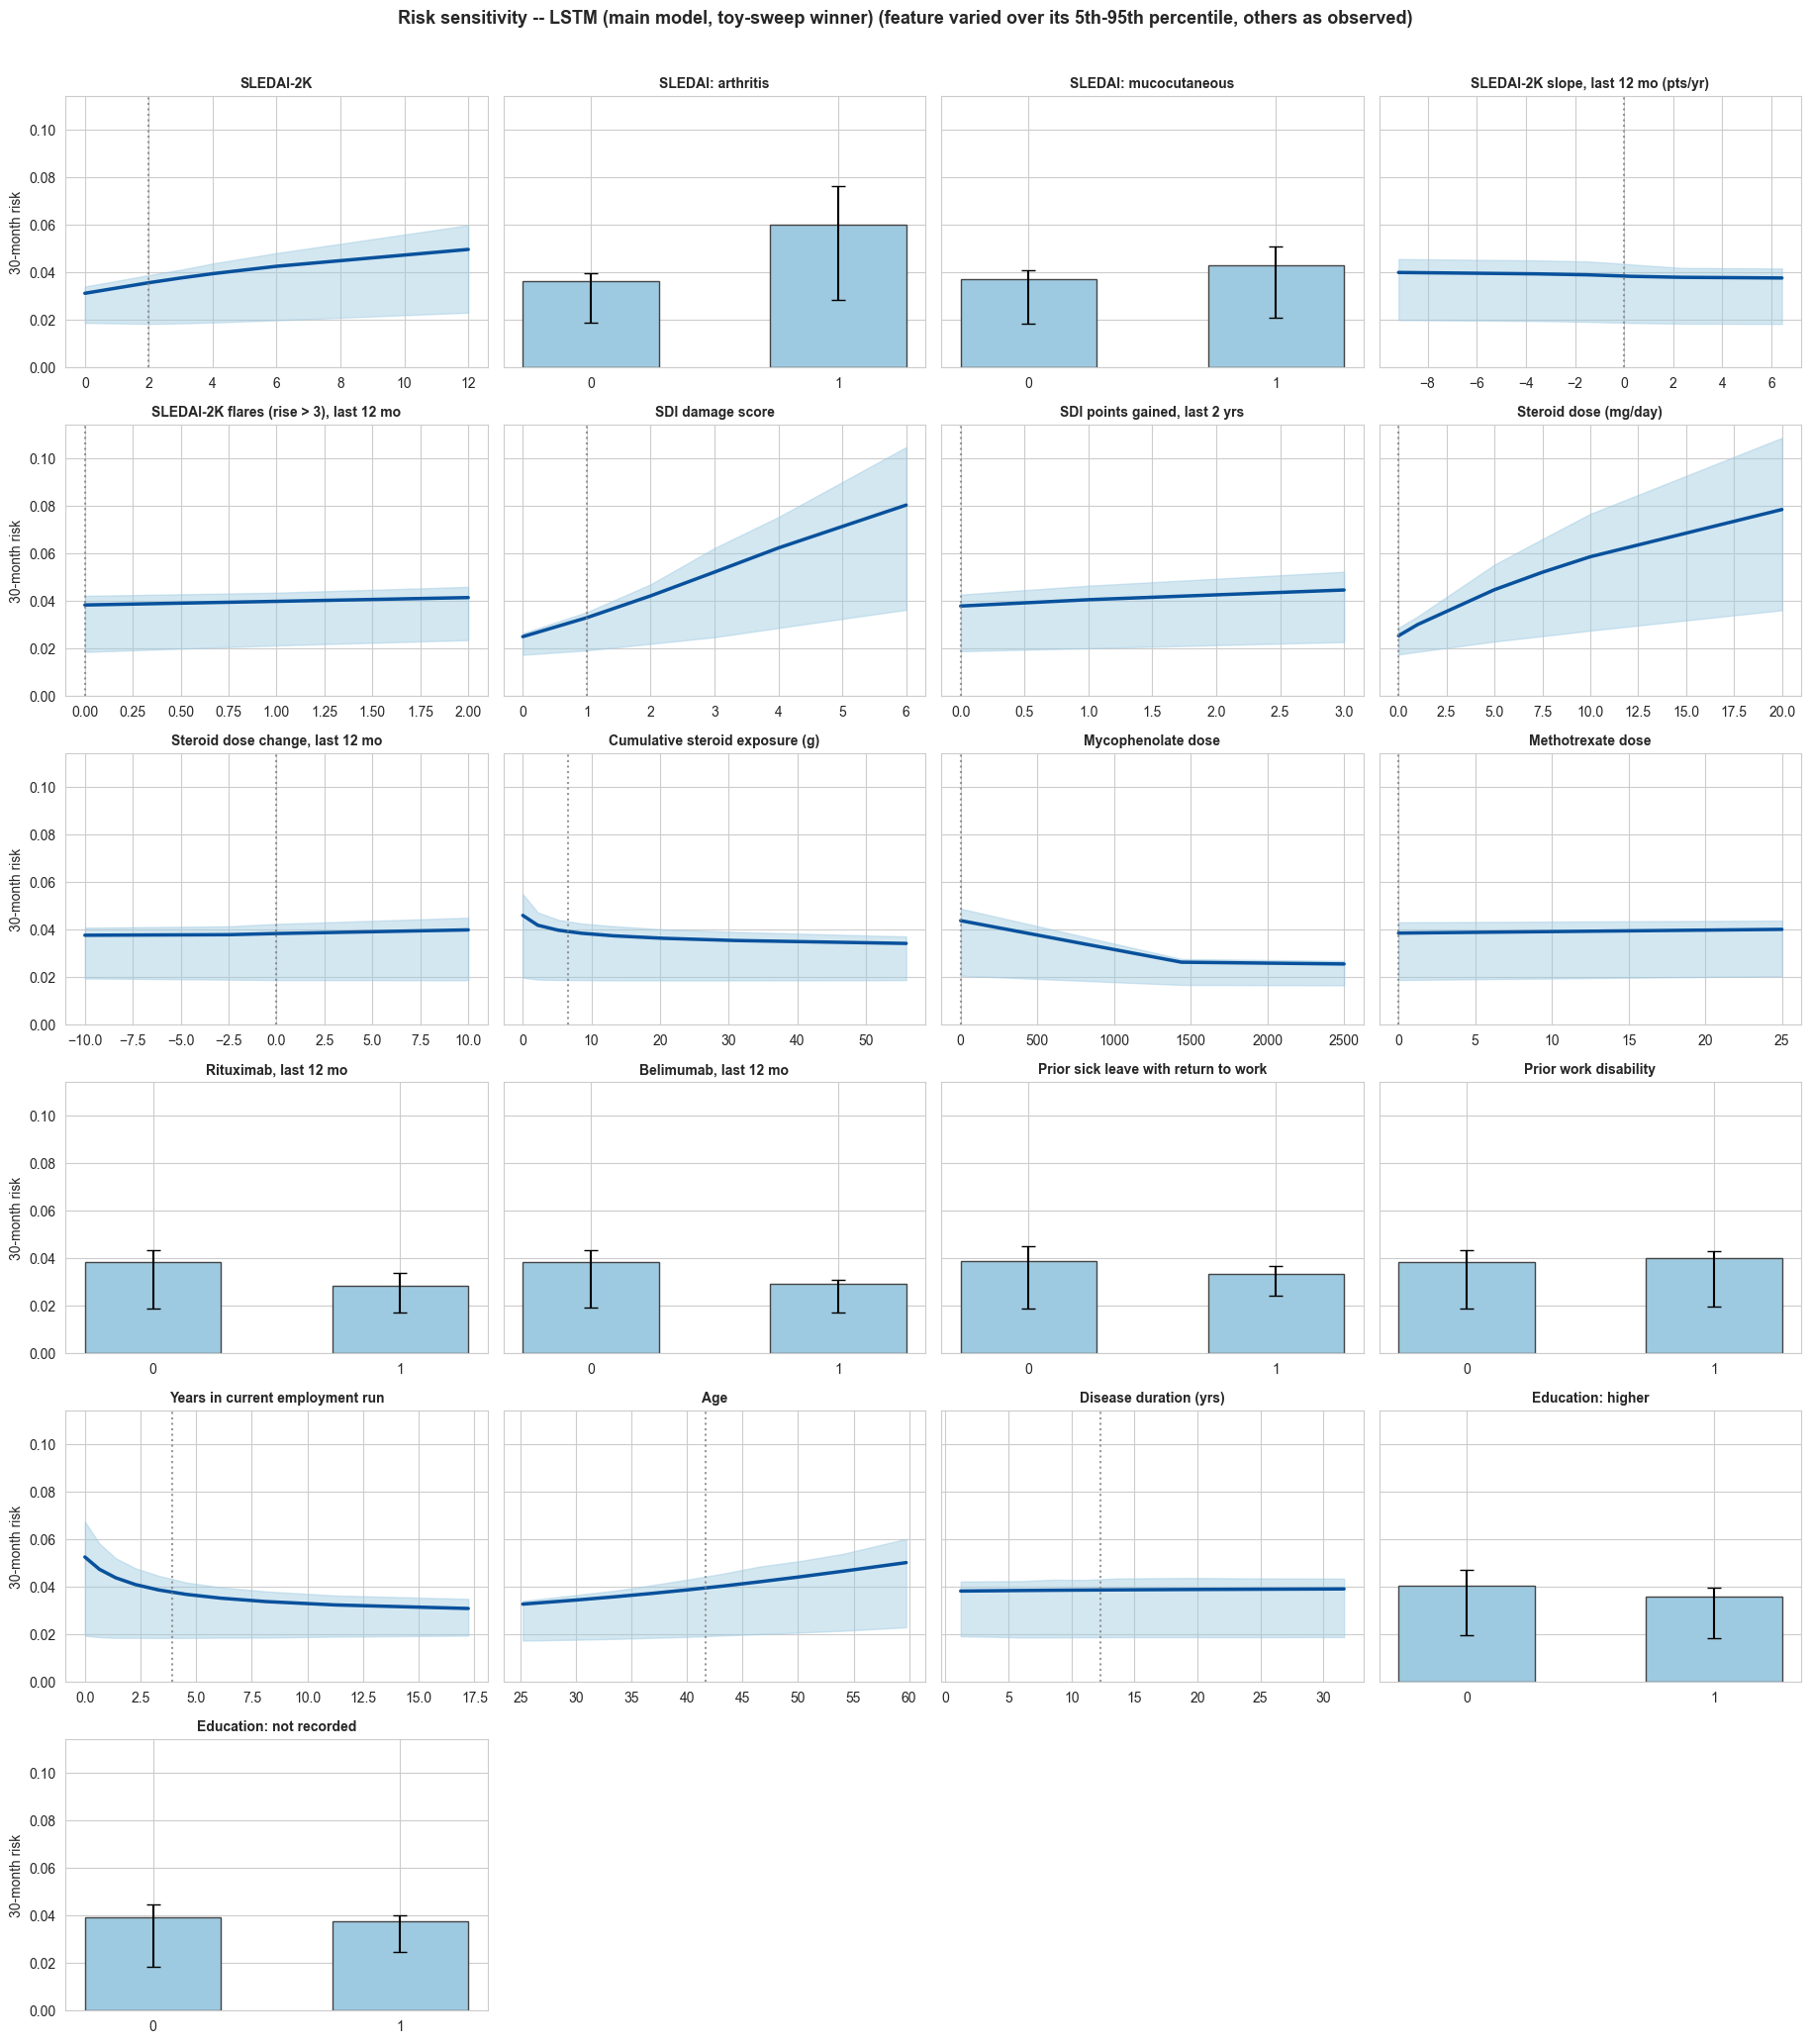


Risk-sensitivity summary -- LSTM (main model, toy-sweep winner) (mean 30-month risk; ranked by swing)
                                Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                       SDI damage score      0.0250       0.0804                0.0553
                  Steroid dose (mg/day)      0.0254       0.0785                0.0531
                      SLEDAI: arthritis      0.0365       0.0602                0.0237
        Years in current employment run      0.0526       0.0309                0.0217
                              SLEDAI-2K      0.0312       0.0497                0.0184
                     Mycophenolate dose      0.0438       0.0256                0.0182
                                    Age      0.0328       0.0502                0.0174
        Cumulative steroid exposure (g)      0.0460       0.0342                0.0118
                  Rituximab, last 12 mo      0.0386       0.0286                0.0100
                  Belimumab

In [16]:
"""Model 5/7 -- the main model (Section 6.1 / 11.7): the toy-sweep LSTM -- 32 units over the whole history of the
pre-specified variables + visit gap + employment state, next-visit pretraining, competing-risk head, early stopping,
5-seed ensemble in the outer-fold fit. Configuration (sweep winner, + skip connection, + employment-state pretraining)
chosen inside each training fold on cross-fitted visit-level pAUROC (Section 6.1.1)."""
res_lstm = run_analysis("LSTM", "LSTM (main model, toy-sweep winner)")

## 11.14 Model 6/7 — Causal Transformer

Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


CV for ['Transformer']: 0.0 min this call; 175 model-fold fits in cv_state_model_v5.pkl.


Transformer (causal) -- VISIT LEVEL (30-month work-disability onset)
  17,338 landmark visits of 1,059 patients; resolved at 30 months: 14,893 (681 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity 85%, specificity floor 50%); mean threshold 0.034
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.6834     | [0.629, 0.731]  Discrimination
Brier Score                    | 0.0397     | [0.033, 0.047]  Overall accuracy (lower=better)
Calibration Slope              | 1.1358     | [0.822, 1.427]  Ideal = 1.0
Calibration Intercept          | -0.0015    | 

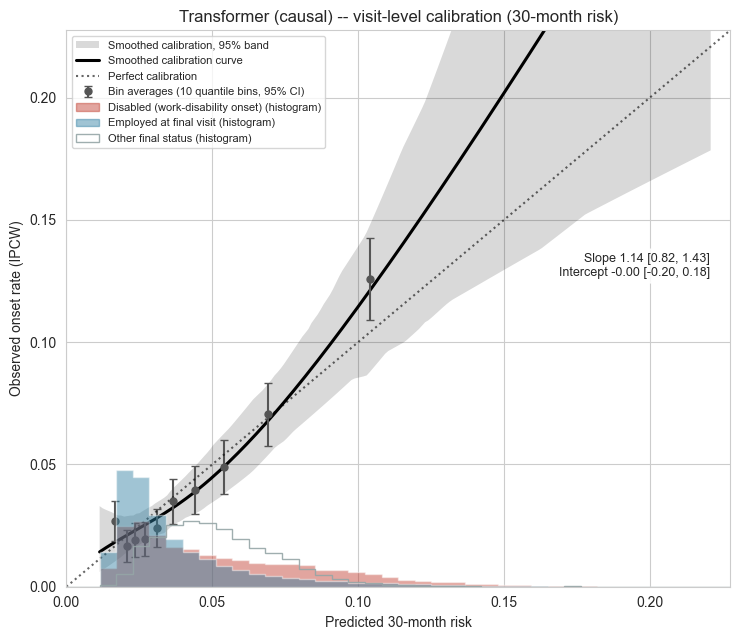


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits
Model,,,,,,
Transformer,5,0.555 (0.014),0.726 (0.004),0.688 (0.006),0.096 (0.002),47.077 (1.860)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Transformer,5,0.221 (0.031),0.327 (0.022),0.413 (0.021),0.484 (0.010),0.591 (0.018),0.943 (0.007),0.893 (0.011),0.841 (0.016),0.793 (0.013),0.694 (0.007)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Transformer,5,0.678 (0.008),0.695 (0.003),0.693 (0.005),0.688 (0.007),0.683 (0.006),0.679 (0.007),0.671 (0.007),0.664 (0.008)


Configuration chosen per fold (visit-level cross-fitted pAUROC): {'d32_pretrain': 25}
Early stopping, outer-fold fits: median 28 epochs (range 16-47)


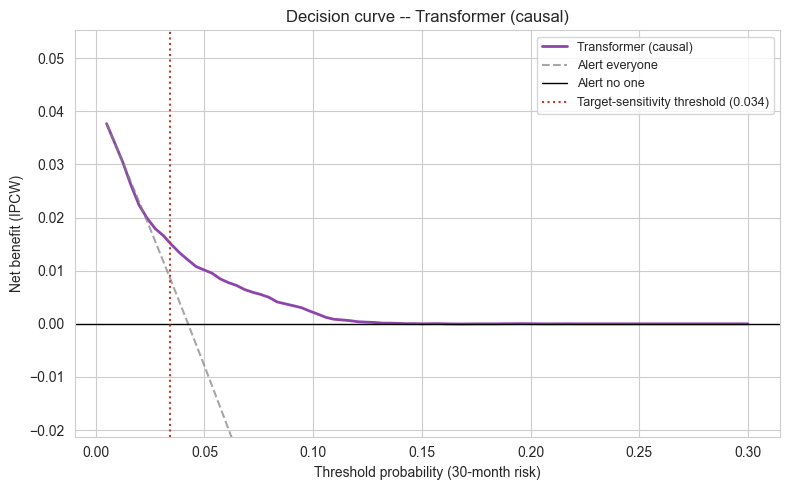

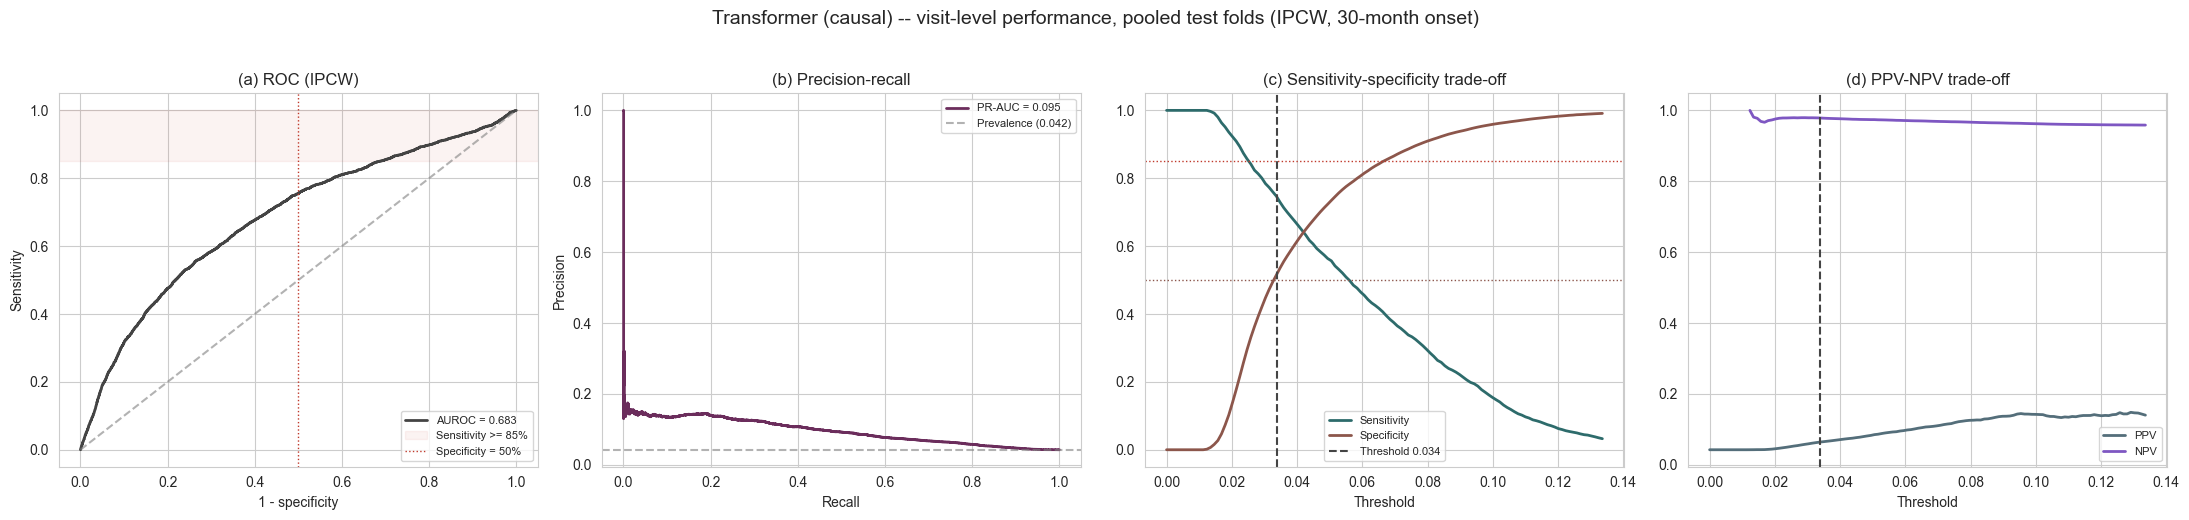

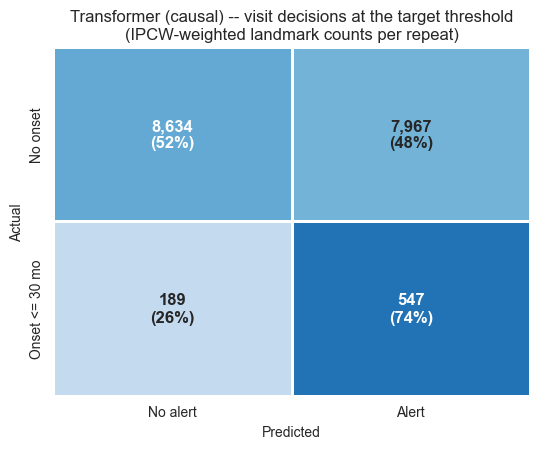

Transformer: final refit on all rows (config d32_pretrain, 21 features) in 62s


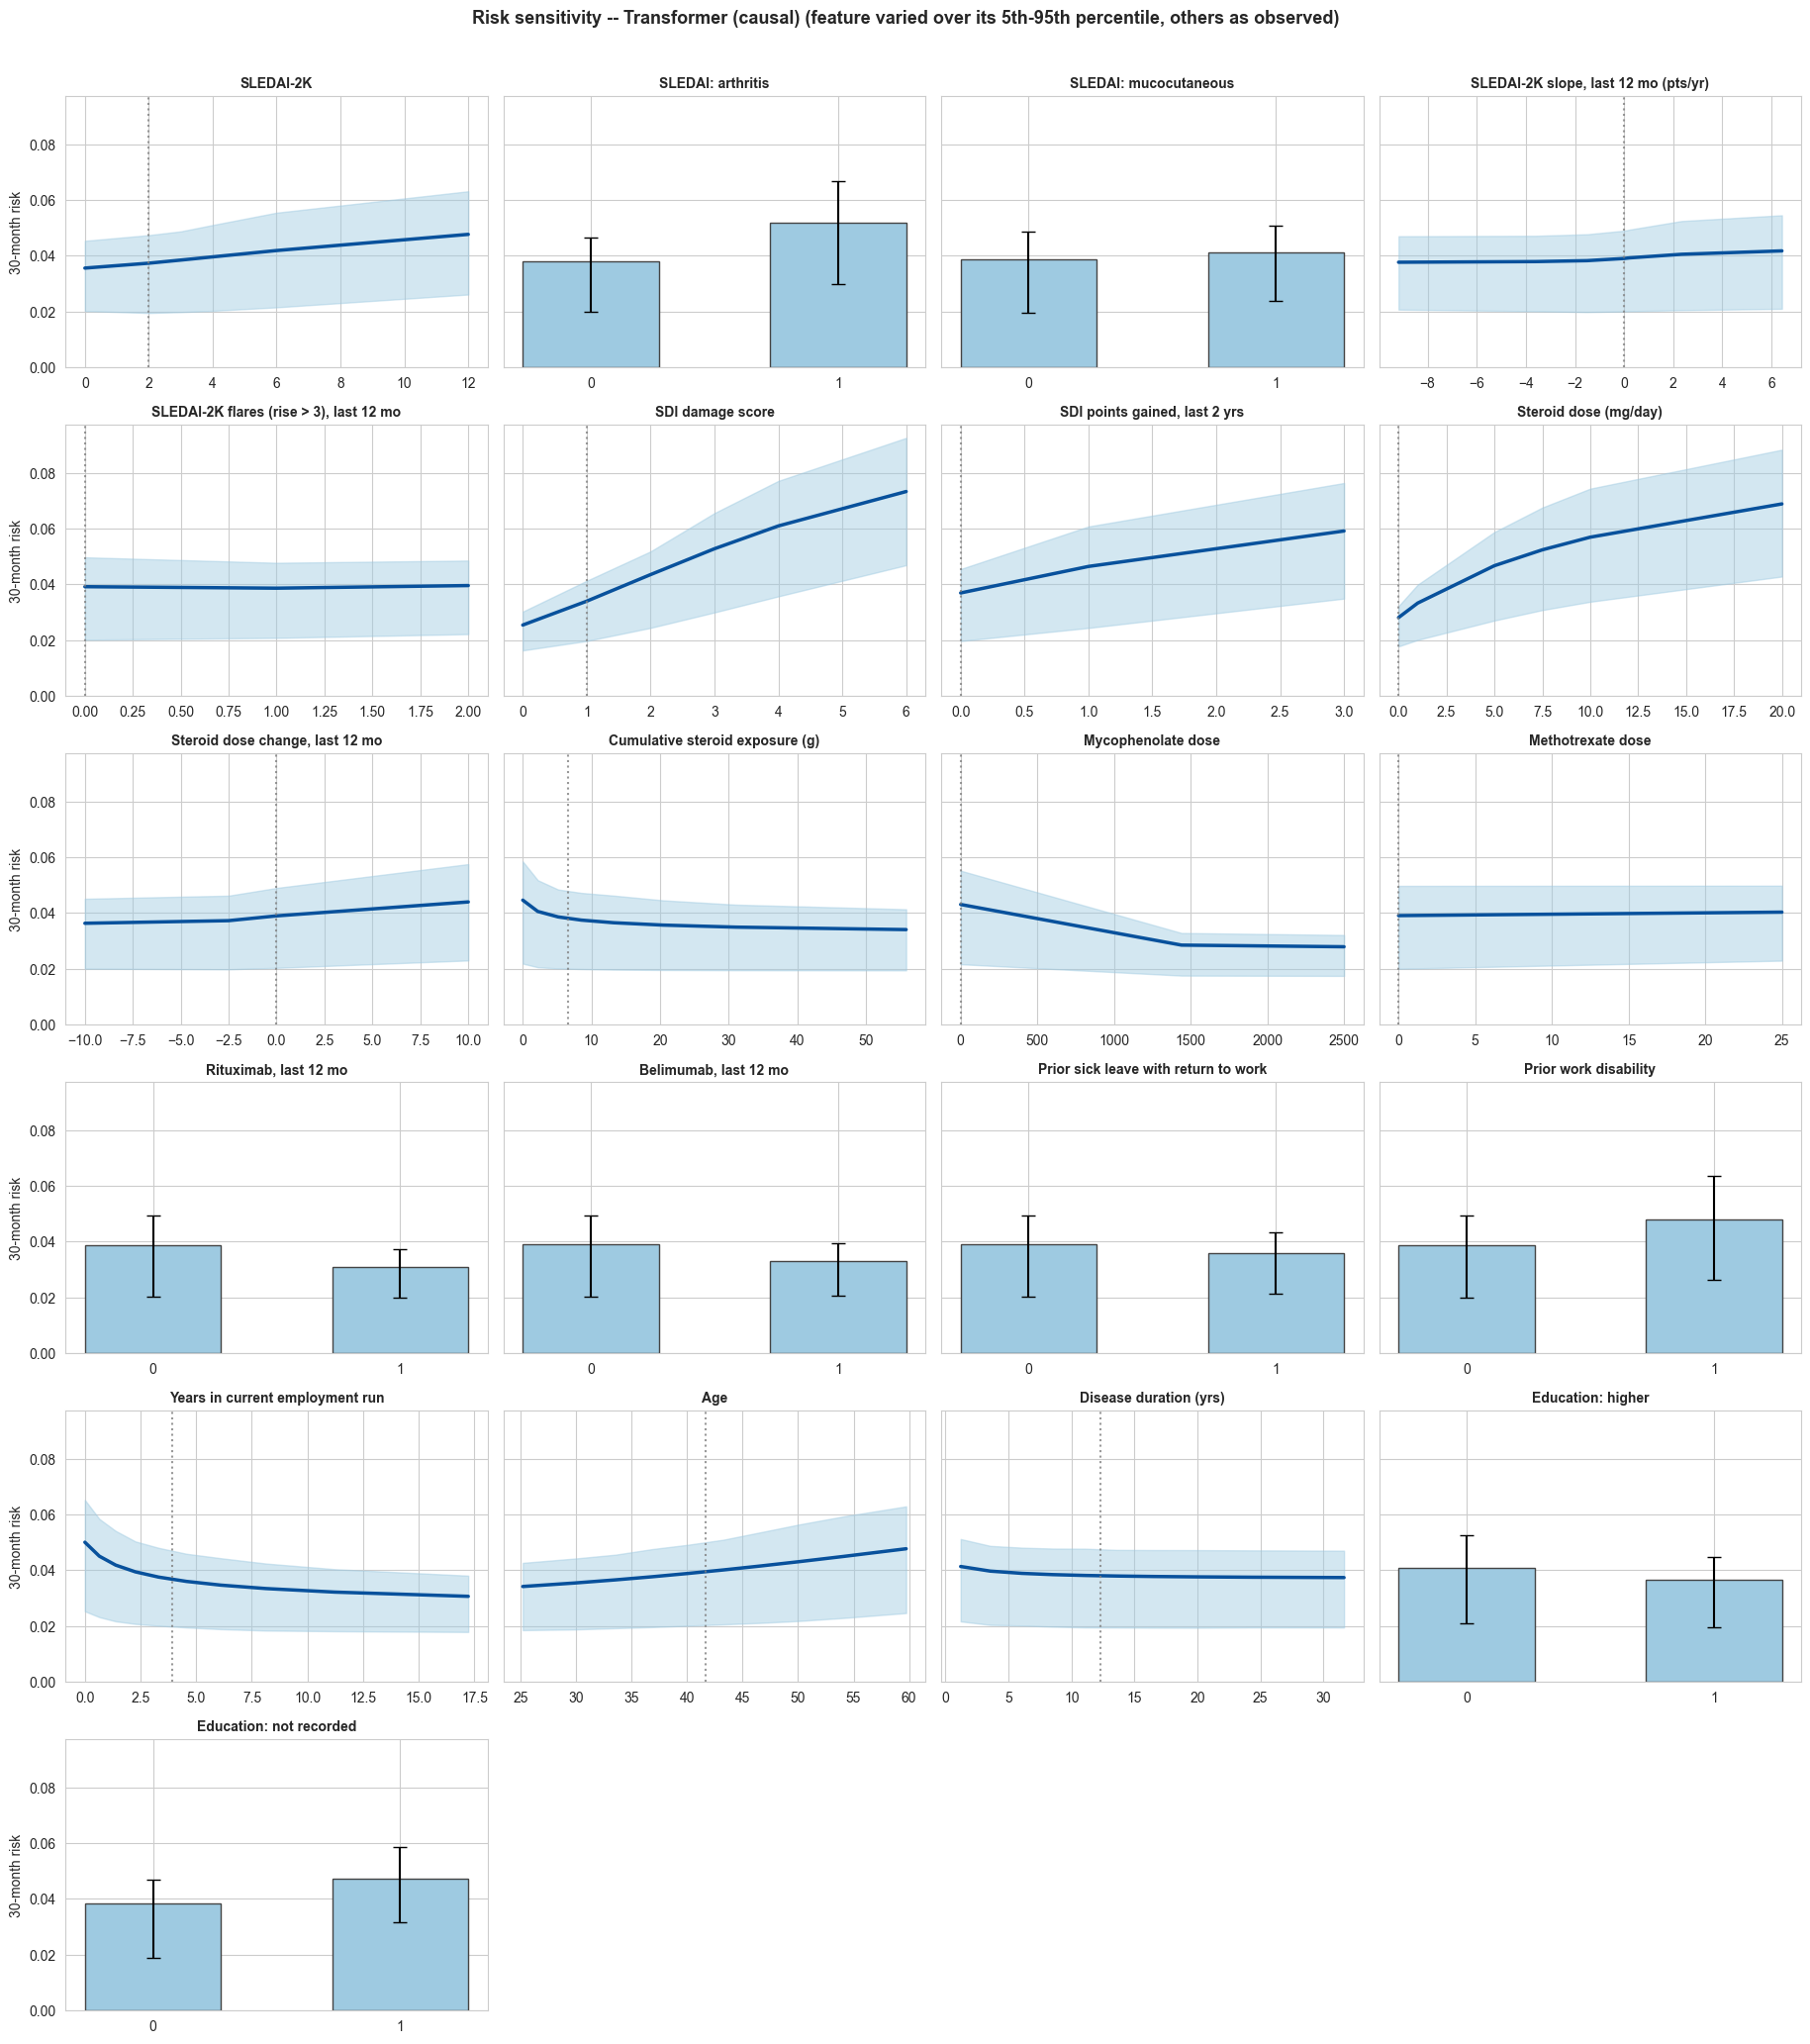


Risk-sensitivity summary -- Transformer (causal) (mean 30-month risk; ranked by swing)
                                Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                       SDI damage score      0.0255       0.0733                0.0478
                  Steroid dose (mg/day)      0.0281       0.0689                0.0407
          SDI points gained, last 2 yrs      0.0370       0.0592                0.0222
        Years in current employment run      0.0501       0.0307                0.0194
                     Mycophenolate dose      0.0431       0.0279                0.0152
                      SLEDAI: arthritis      0.0380       0.0518                0.0139
                                    Age      0.0342       0.0477                0.0135
                              SLEDAI-2K      0.0356       0.0477                0.0121
        Cumulative steroid exposure (g)      0.0446       0.0341                0.0106
                  Prior work disability   

In [17]:
"""Model 6/7 -- causal Transformer (the main model's recipe with a 1-layer causal Transformer encoder; elapsed time
since the first visit as an extra input)."""
res_transformer = run_analysis("Transformer", "Transformer (causal)")

## 11.15 Model 7/7 — Stacked LSTM + LogReg


Resuming from cv_state_model_v5.pkl: 175 model-fold fits already done.


CV for ['Stack']: 0.0 min this call; 175 model-fold fits in cv_state_model_v5.pkl.


Stack (LSTM + LogReg) -- VISIT LEVEL (30-month work-disability onset)
  17,338 landmark visits of 1,059 patients; resolved at 30 months: 14,893 (681 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (target sensitivity 85%, specificity floor 50%); mean threshold 0.031
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7050     | [0.655, 0.751]  Discrimination
Brier Score                    | 0.0396     | [0.033, 0.047]  Overall accuracy (lower=better)
Calibration Slope              | 0.9526     | [0.720, 1.165]  Ideal = 1.0
Calibration Intercept          | -0.0176    |

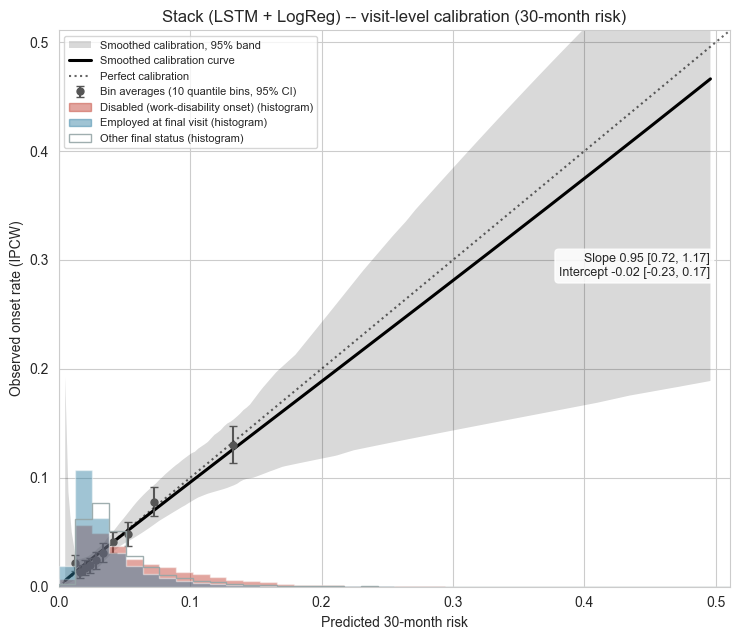


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits
Model,,,,,,
Stack,5,0.575 (0.008),0.744 (0.006),0.708 (0.003),0.103 (0.005),47.640 (0.980)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Stack,5,0.230 (0.019),0.357 (0.017),0.451 (0.010),0.516 (0.006),0.623 (0.016),0.942 (0.004),0.891 (0.006),0.842 (0.005),0.793 (0.005),0.697 (0.006)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Stack,5,0.705 (0.004),0.708 (0.003),0.709 (0.003),0.707 (0.004),0.705 (0.003),0.702 (0.004),0.696 (0.004),0.691 (0.004)


Configuration chosen per fold (visit-level cross-fitted pAUROC): {'LSTM+LogReg': 25}


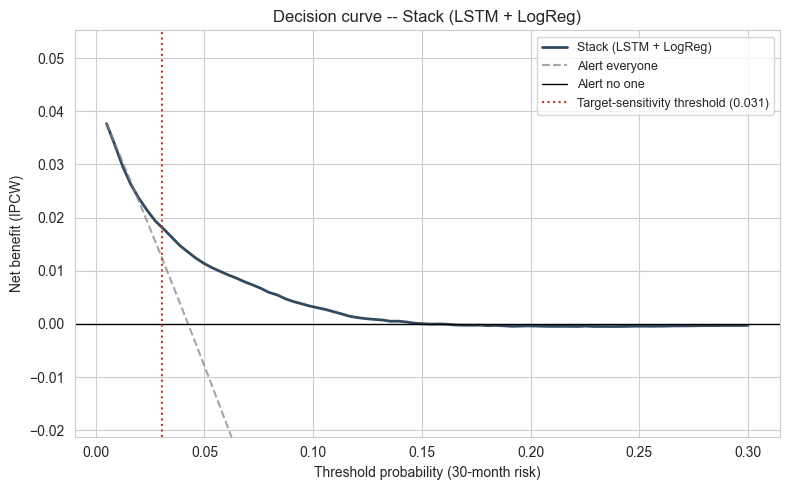

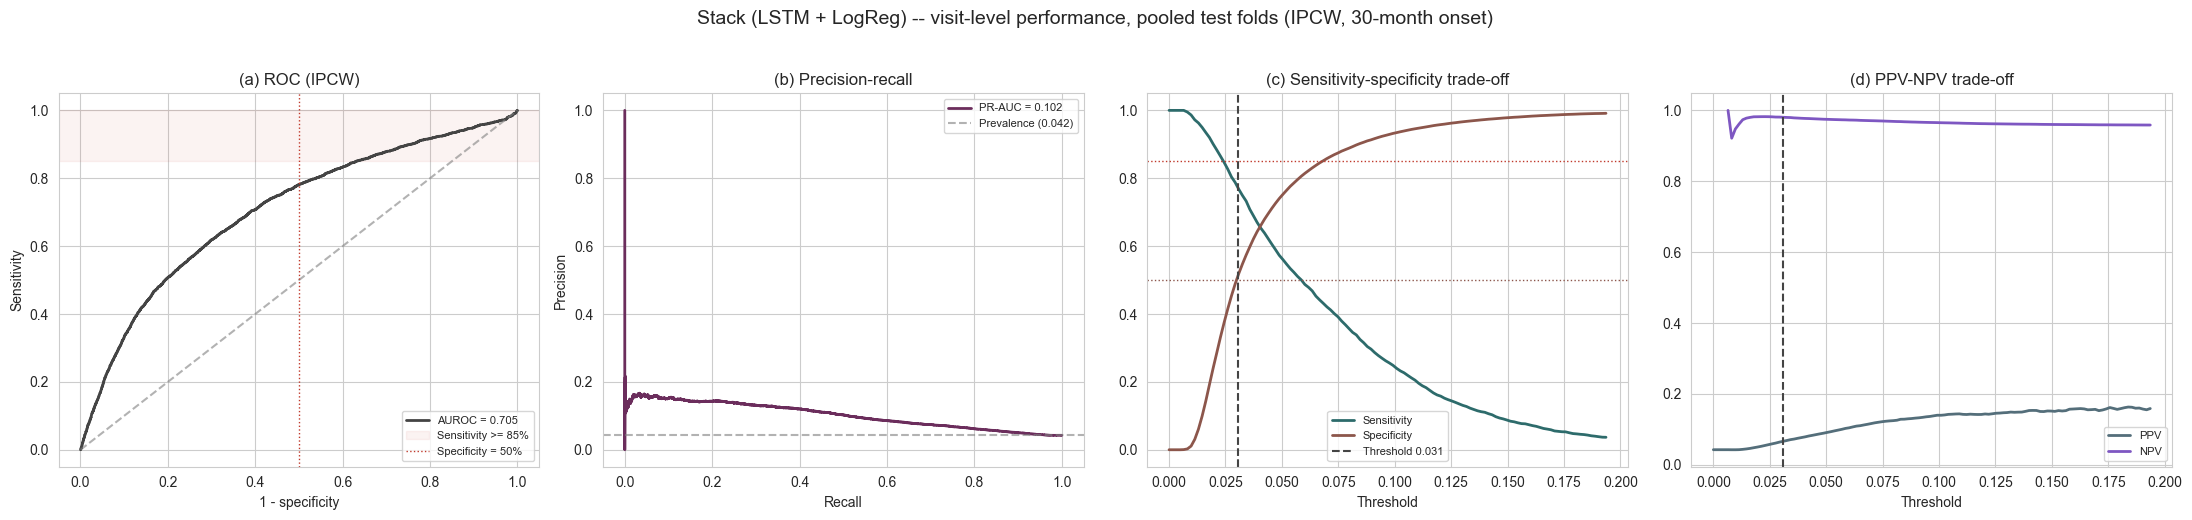

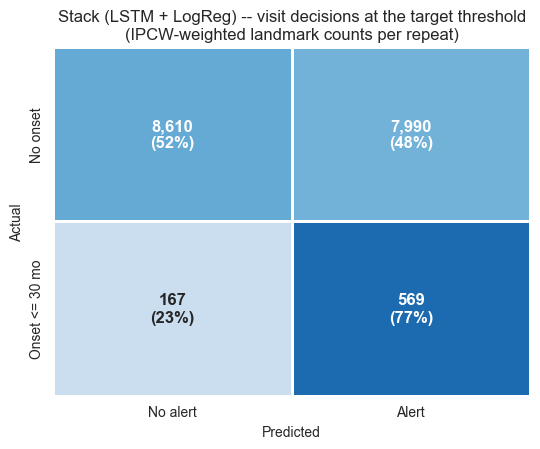

In [18]:
"""Model 7/7 -- stack of the LSTM and the competing-risk LogReg (Section 11.8, part 3). Nothing is refitted: in every
outer fold the two models' calibrated risks are averaged on the logit scale -- the training patients' cross-fitted OOF
risks and the test fold alike -- then recalibrated, and every threshold is learned on the stacked OOF risks. Both
members' sections must have run first."""
res_stack = run_analysis("Stack", "Stack (LSTM + LogReg)")


## 11.16 Visit-level summary — all models

Every metric of the per-model visit tables, value [95 % patient-bootstrap CI], with LaTeX rows for the manuscript.

In [19]:
"""
Visit-level summary for all models: every metric of the per-model tables, value [95% patient-bootstrap CI], one row per
model, with LaTeX rows for the manuscript. The per-repeat metrics go to cv_model_v5_pooled_metrics_by_repeat.csv.
"""
MODEL_RESULTS = {m: r for m, r in [("LogReg", res_logreg), ("RSF", res_rsf), ("CoxPH", res_cox), ("GRU", res_gru),
                                   ("LSTM", res_lstm), ("Transformer", res_transformer), ("Stack", res_stack)]
                 if r is not None}
res_all = pd.concat([r["res_df"] for r in MODEL_RESULTS.values()], ignore_index=True)
preds_all = {k: v for r in MODEL_RESULTS.values() for k, v in r["preds"].items()}
res_all.to_csv("cv_model_v5_pooled_metrics_by_repeat.csv", index=False)


def wide_table(key):
    """One row per model: 'value [CI low, CI high]' for every metric of table `key`."""
    cell = lambda row: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                        if np.isfinite(row["Value"]) else "n/a")
    return pd.DataFrame({m: {row["Metric"]: cell(row) for _, row in r[key].iterrows()}
                         for m, r in MODEL_RESULTS.items()}).T


def latex_table_rows(key):
    return [f"{m:<11} & " + " & ".join(f"{row['Value']:.3f} ({row['CI low']:.3f}--{row['CI high']:.3f})"
                                       if np.isfinite(row["Value"]) else "n/a"
                                       for _, row in r[key].iterrows()) + " \\\\"
            for m, r in MODEL_RESULTS.items()]


visit_summary = wide_table("visit_table")
print("VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test "
      "folds; 30-month onset, IPCW; alarms at each fold's visit threshold")
display(visit_summary)
print("\nLaTeX rows (" + " & ".join(visit_summary.columns) + "):")
print("\n".join(latex_table_rows("visit_table")))


VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test folds; 30-month onset, IPCW; alarms at each fold's visit threshold


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy
LogReg,"0.699 [0.648, 0.745]","0.040 [0.033, 0.047]","0.945 [0.701, 1.177]","0.007 [-0.194, 0.194]","0.754 [0.680, 0.813]","0.523 [0.496, 0.552]","0.066 [0.053, 0.079]","0.980 [0.973, 0.986]","0.639 [0.603, 0.670]"
RSF,"0.685 [0.641, 0.726]","0.040 [0.033, 0.047]","0.973 [0.728, 1.229]","0.010 [-0.191, 0.194]","0.738 [0.668, 0.801]","0.521 [0.495, 0.550]","0.064 [0.051, 0.078]","0.978 [0.972, 0.985]","0.629 [0.594, 0.662]"
CoxPH,"0.695 [0.645, 0.737]","0.040 [0.033, 0.047]","1.067 [0.795, 1.307]","0.018 [-0.180, 0.198]","0.768 [0.693, 0.830]","0.499 [0.472, 0.530]","0.064 [0.050, 0.077]","0.980 [0.973, 0.986]","0.633 [0.598, 0.668]"
GRU,"0.695 [0.641, 0.741]","0.040 [0.033, 0.047]","1.104 [0.812, 1.376]","-0.018 [-0.218, 0.165]","0.779 [0.707, 0.842]","0.488 [0.456, 0.520]","0.063 [0.051, 0.077]","0.980 [0.974, 0.986]","0.634 [0.600, 0.666]"
LSTM,"0.700 [0.652, 0.744]","0.040 [0.033, 0.047]","1.054 [0.820, 1.278]","-0.021 [-0.230, 0.164]","0.783 [0.714, 0.845]","0.502 [0.468, 0.535]","0.065 [0.052, 0.079]","0.981 [0.975, 0.987]","0.642 [0.608, 0.674]"
Transformer,"0.683 [0.629, 0.731]","0.040 [0.033, 0.047]","1.136 [0.822, 1.427]","-0.002 [-0.202, 0.179]","0.743 [0.669, 0.807]","0.520 [0.487, 0.553]","0.064 [0.051, 0.078]","0.979 [0.972, 0.985]","0.632 [0.595, 0.665]"
Stack,"0.705 [0.655, 0.751]","0.040 [0.033, 0.047]","0.953 [0.720, 1.165]","-0.018 [-0.226, 0.171]","0.773 [0.700, 0.834]","0.519 [0.489, 0.550]","0.066 [0.053, 0.080]","0.981 [0.975, 0.987]","0.646 [0.609, 0.678]"



LaTeX rows (Concordance Index & Brier Score & Calibration Slope & Calibration Intercept & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy):
LogReg      & 0.699 (0.648--0.745) & 0.040 (0.033--0.047) & 0.945 (0.701--1.177) & 0.007 (-0.194--0.194) & 0.754 (0.680--0.813) & 0.523 (0.496--0.552) & 0.066 (0.053--0.079) & 0.980 (0.973--0.986) & 0.639 (0.603--0.670) \\
RSF         & 0.685 (0.641--0.726) & 0.040 (0.033--0.047) & 0.973 (0.728--1.229) & 0.010 (-0.191--0.194) & 0.738 (0.668--0.801) & 0.521 (0.495--0.550) & 0.064 (0.051--0.078) & 0.978 (0.972--0.985) & 0.629 (0.594--0.662) \\
CoxPH       & 0.695 (0.645--0.737) & 0.040 (0.033--0.047) & 1.067 (0.795--1.307) & 0.018 (-0.180--0.198) & 0.768 (0.693--0.830) & 0.499 (0.472--0.530) & 0.064 (0.050--0.077) & 0.980 (0.973--0.986) & 0.633 (0.598--0.668) \\
GRU         & 0.695 (0.641--0.741) & 0.040 (0.033--0.047) & 1.104 (0.812--1.376) & -0.018 (-0.218--0.165) & 0.779 (0.707--0.842) & 0.488 (0.456--0.520) & 0.063 (0.051--0.077) & 0.9

## 11.17 Visit-level calibration — all models

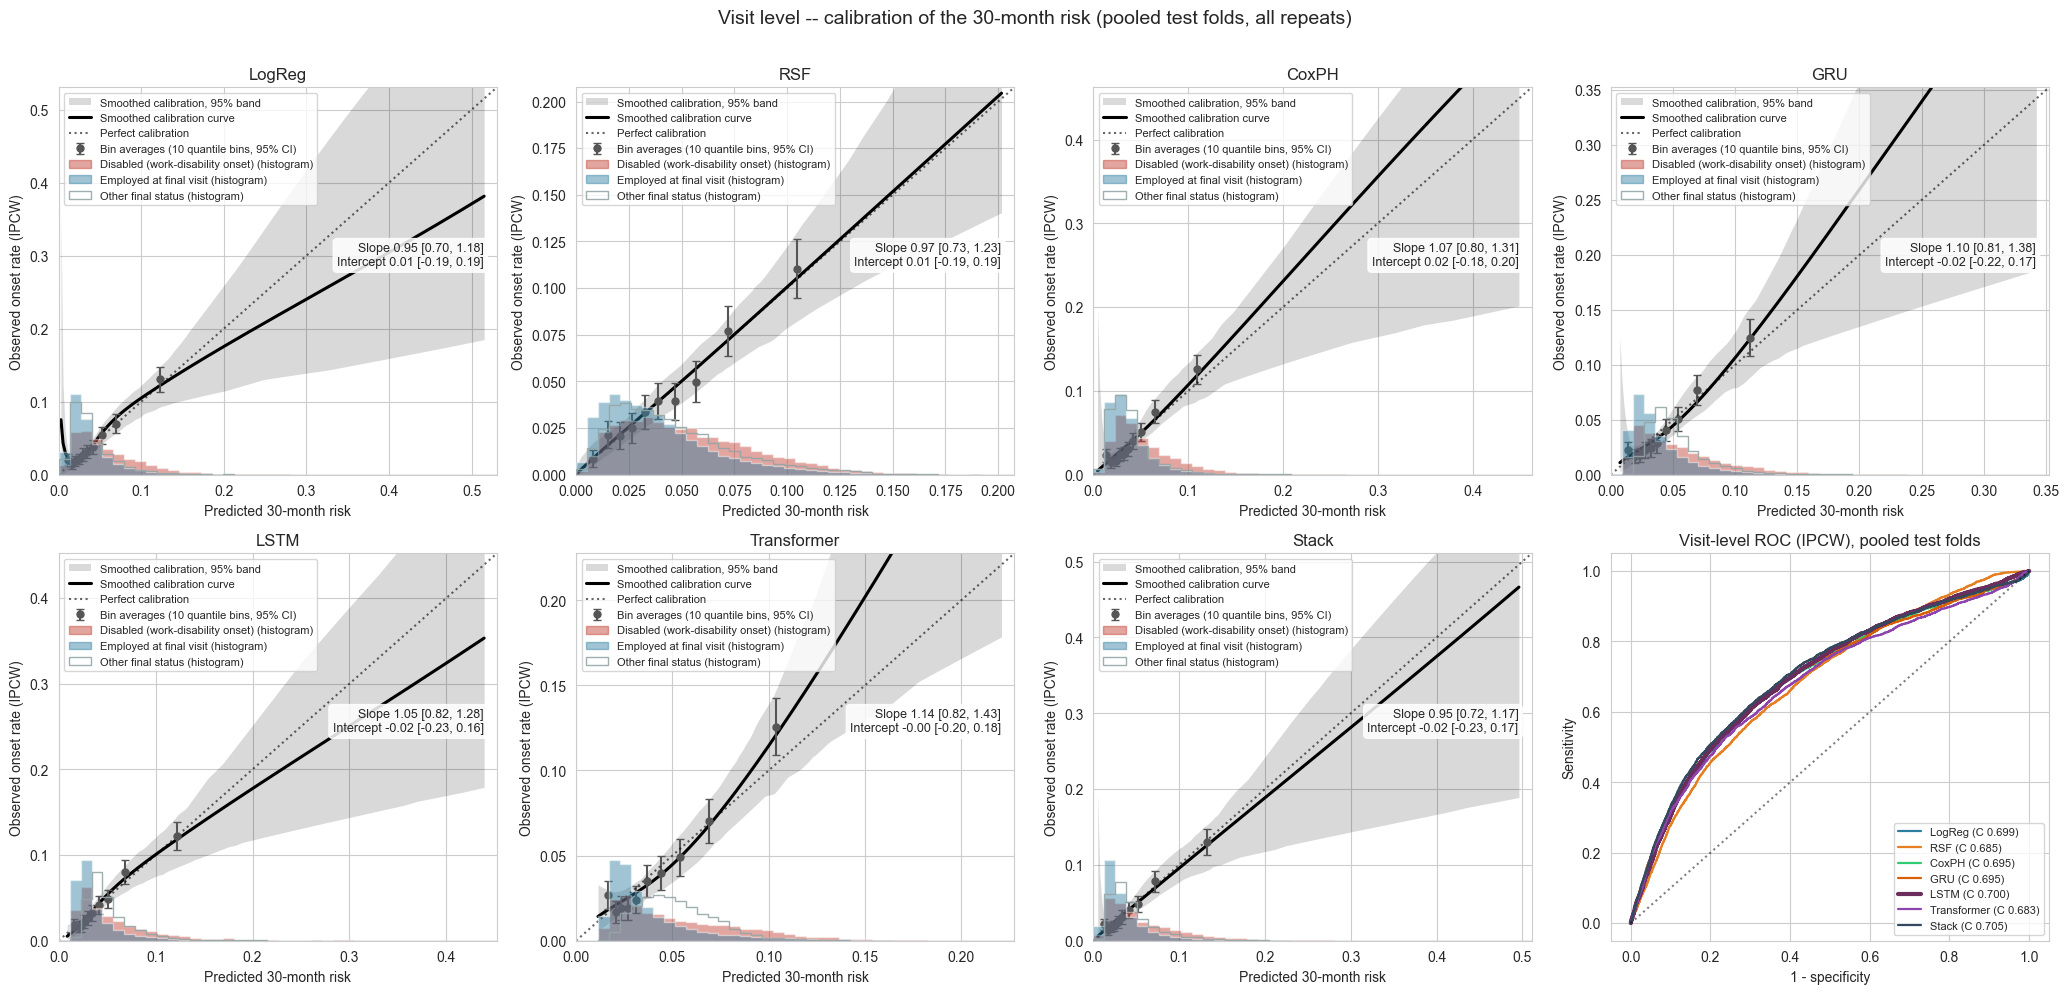

In [20]:
"""Visit-level calibration of every model (one panel each: IPCW deciles of the pooled out-of-fold 30-month risk, all
repeats stacked, with the slope and intercept of its table) and the IPCW ROC curves of all models."""
_ms = list(MODEL_RESULTS)
_ncols = 4
_nrows = int(np.ceil((len(_ms) + 1) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "visit", MODEL_RESULTS[m]["visit_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    p, y, w = r["p"], r["y"], r["w"]
    k = w > 0
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    ax.plot(fpr, tpr, color=CV_COLORS[m], lw=3 if m == "LSTM" else 1.6,
            label=f"{m} (C {r['visit_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("Visit-level ROC (IPCW), pooled test folds"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Visit level -- calibration of the 30-month risk (pooled test folds, all repeats)", y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_calibration_visit_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()


## 11.18 LSTM visit-level performance by horizon (6–48 months)

Discrimination and calibration at every horizon from the same cross-validation (the hazard head gives all horizons
from one fit). These are validated, out-of-fold numbers, unlike v1's per-horizon in-sample refits.

LSTM -- performance by horizon, pooled test folds (mean (SD) over repeats)


,Onset rate (IPCW),AUROC,Brier,Cal. slope,Cal. intercept
Horizon (mo),,,,,
6,0.008415,0.688 (0.008),0.008 (0.000),1.003 (0.088),-0.020 (0.013)
12,0.018214,0.703 (0.006),0.018 (0.000),1.087 (0.063),-0.013 (0.018)
18,0.027263,0.707 (0.005),0.026 (0.000),1.070 (0.086),-0.021 (0.019)
24,0.035252,0.703 (0.004),0.033 (0.000),1.055 (0.108),-0.019 (0.021)
30,0.042470,0.700 (0.004),0.040 (0.000),1.056 (0.118),-0.021 (0.024)
36,0.048641,0.698 (0.004),0.045 (0.000),1.065 (0.124),-0.023 (0.023)
42,0.055312,0.692 (0.004),0.051 (0.000),1.068 (0.130),-0.022 (0.022)
48,0.062073,0.686 (0.005),0.056 (0.000),1.076 (0.139),-0.020 (0.021)


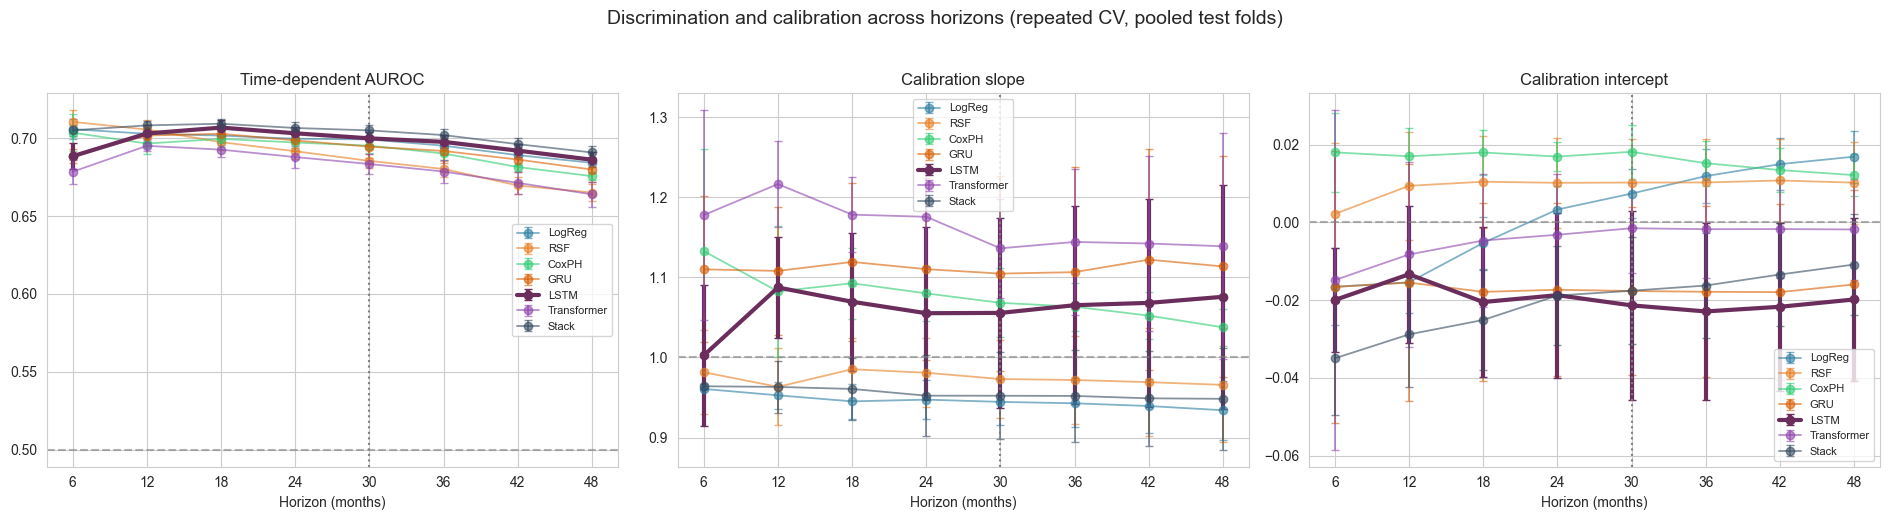

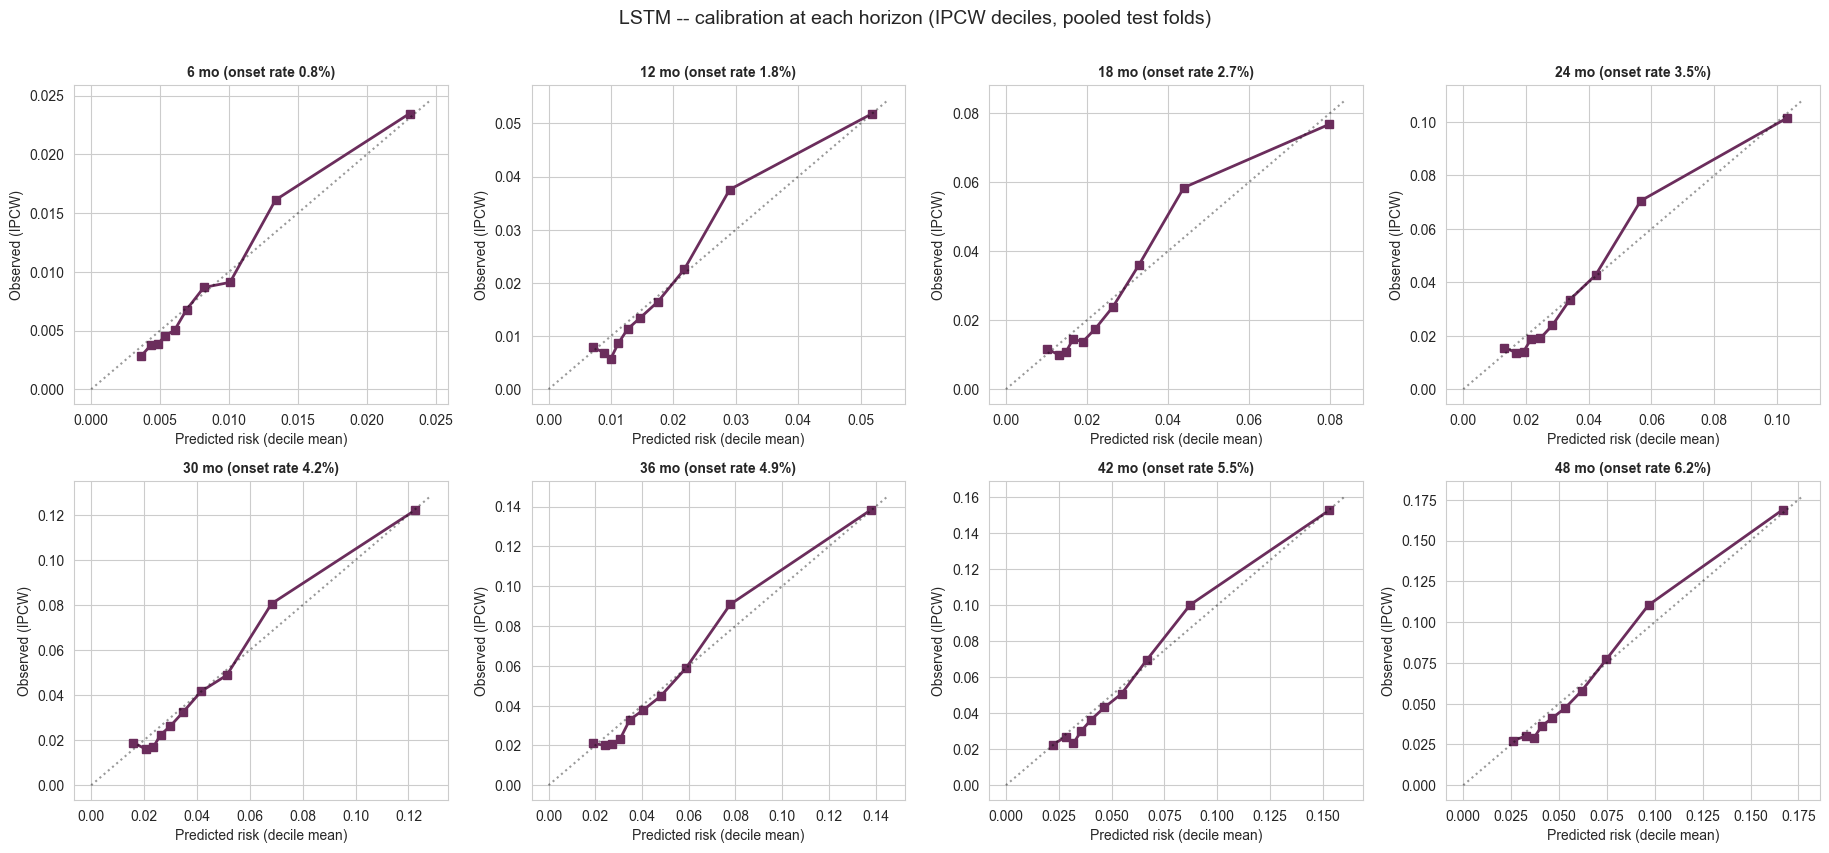

In [21]:
"""
LSTM multi-horizon performance (6-48 months) -- from the SAME repeated CV.

The discrete-time hazard head gives the risk of onset by every horizon from one fit, and each horizon has its own
recalibration learned inside the training folds. So, unlike v1 (a fresh in-sample LSTM per horizon, uncalibrated),
these are validated, out-of-fold numbers: time-dependent IPCW AUROC, Brier score, calibration slope and intercept per
horizon, mean (SD) over repeats, and a reliability plot per horizon.
"""
HZ_MODEL = "LSTM" if res_lstm is not None else next(iter(MODEL_RESULTS))
d = MODEL_RESULTS[HZ_MODEL]["res_df"]
rows = []
for h in EVAL_HORIZONS_MONTHS:
    yh, wh = IPCW[h]
    rows.append({"Horizon (mo)": h, "Onset rate (IPCW)": float(np.average(yh[wh > 0], weights=wh[wh > 0])),
                 **{lab: _fmt(d[f"{c}_{h}"]) for c, lab in [("td_auroc", "AUROC"), ("brier", "Brier"),
                                                            ("cal_slope", "Cal. slope"),
                                                            ("cal_intercept", "Cal. intercept")]}})
horizon_df = pd.DataFrame(rows).set_index("Horizon (mo)")
print(f"{HZ_MODEL} -- performance by horizon, pooled test folds (mean (SD) over repeats)")
display(horizon_df)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (c, lab, ideal) in zip(axes, [("td_auroc", "Time-dependent AUROC", 0.5), ("cal_slope", "Calibration slope", 1.0),
                                      ("cal_intercept", "Calibration intercept", 0.0)]):
    for m, r in MODEL_RESULTS.items():
        dd = r["res_df"]
        mu = [dd[f"{c}_{h}"].mean() for h in EVAL_HORIZONS_MONTHS]
        sd = [dd[f"{c}_{h}"].std() if len(dd) > 1 else 0 for h in EVAL_HORIZONS_MONTHS]
        ax.errorbar(EVAL_HORIZONS_MONTHS, mu, yerr=sd, color=CV_COLORS[m], marker="o", capsize=3,
                    lw=3 if m == HZ_MODEL else 1.3, alpha=1 if m == HZ_MODEL else 0.6, label=m)
    ax.axhline(ideal, color="gray", ls="--", alpha=0.6)
    ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
    ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)"); ax.set_title(lab)
    ax.legend(fontsize=8)
plt.suptitle("Discrimination and calibration across horizons (repeated CV, pooled test folds)", y=1.03, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_horizons.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()

ncols = 4
nrows = int(np.ceil(len(EVAL_HORIZONS_MONTHS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows))
for ax, (j, h) in zip(axes.ravel(), enumerate(EVAL_HORIZONS_MONTHS)):
    p, y, w, _, _ = stacked(HZ_MODEL, MODEL_RESULTS[HZ_MODEL]["preds"], col=j, horizon=h)
    k = w > 0
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    hi = float(max((cd["pw"] / cd["w"]).max(), (cd["yw"] / cd["w"]).max())) * 1.05
    ax.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color=CV_COLORS[HZ_MODEL], lw=2)
    ax.plot([0, hi], [0, hi], "k:", alpha=0.4)
    ax.set_title(f"{h} mo (onset rate {np.average(y[k], weights=w[k]):.1%})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted risk (decile mean)"); ax.set_ylabel("Observed (IPCW)")
for ax in axes.ravel()[len(EVAL_HORIZONS_MONTHS):]:
    ax.set_visible(False)
plt.suptitle(f"{HZ_MODEL} -- calibration at each horizon (IPCW deciles, pooled test folds)", y=1.01, fontsize=14)
plt.tight_layout(); plt.show(); plt.close()

## 11.19 LSTM history-length ablation (visit level)

Does the LSTM need each patient's whole history? One CV repeat of the main LSTM is run with each
landmark seeing only its last 1, 4, 8 or 12 visits, and with the whole history, and compared on the same pooled test
folds. If one visit does as well as the whole history, the engineered history features already carry the signal
and the recurrence adds nothing; if a window beats the whole history, set `SEQ_CONFIG["max_visits"]` to
it (a new CV state file is then needed). Off by default: about 20–40 min per length on a laptop CPU.


In [22]:
"""
LSTM history-length ablation. Each length is run on the outer folds of one repeat through the normal fold runner
(the pre-specified variables, cross-fitted calibration and thresholds), with SEQ_CONFIG's
max_visits set to the length. Results are checkpointed in SEQ_LEN_PATH (delete it after changing the configuration).
"""
RUN_SEQ_LEN_ABLATION = False
SEQ_LEN_GRID = [1, 4, 8, 12, None]               # None = whole history (the main model's setting)
SEQ_LEN_REPEAT = 0
SEQ_LEN_CONFIG = "h32_pretrain"
SEQ_LEN_PATH = "seq_len_ablation_v5_smoke.pkl" if SMOKE else "seq_len_ablation_v5.pkl"


def run_seq_len_ablation(lengths=SEQ_LEN_GRID, repeat=SEQ_LEN_REPEAT, base_cfg=SEQ_LEN_CONFIG, path=SEQ_LEN_PATH):
    state = {}
    if os.path.exists(path):
        with open(path, "rb") as f:
            state = pickle.load(f)
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    rows = []
    for L in lengths:
        model = f"LSTM[{L or 'all'}]"                  # registered as its own sequence model with a one-entry grid
        SEQ_GRIDS[model] = {base_cfg: {**SEQ_GRIDS["LSTM"][base_cfg], "max_visits": L}}
        SEQ_KIND[model] = "lstm"
        MODEL_FITTERS[model] = (make_seq_fitter(model), [base_cfg])
        RISK_IS_PROBABILITY[model] = True
        P, secs = np.full(len(land), np.nan), 0.0
        for r, k, tr, te in cv_make_folds():
            if r != repeat:
                continue
            key = (L, k, base_cfg)
            if key not in state:
                seed = CV_SEED + 1000 * r + 10 * k
                sel = FIXED_SELECTION
                res = run_fold(model, tr, te, seed, sel["features"], sel["freq"])
                state[key] = {"te": te, "P": res["P"][:, PRIMARY_COL],
                              "seconds": res["seconds"]}
                with open(path, "wb") as f:
                    pickle.dump(state, f)
                print(f"[{model}] fold {k + 1}/{CV_N_SPLITS} done in {res['seconds']:.0f}s")
            f_ = state[key]
            P[f_["te"]], secs = f_["P"], secs + f_["seconds"]
        rows.append({"History seen at each landmark": f"last {L} visit(s)" if L else "whole history",
                     "AUROC": w_auroc(y, P, w), f"pAUROC (sens>={SENS_PAUC_MIN_TPR:.0%})": w_pauc_high_sens(y, P, w),
                     "Minutes": secs / 60})
    return pd.DataFrame(rows).set_index("History seen at each landmark")


if RUN_SEQ_LEN_ABLATION:
    seq_len_table = run_seq_len_ablation()
    print(f"LSTM ({SEQ_LEN_CONFIG}) by history length -- pooled test folds of repeat {SEQ_LEN_REPEAT + 1}, 30-month onset")
    display(seq_len_table.round(3))
else:
    print("History-length ablation skipped (set RUN_SEQ_LEN_ABLATION = True to run it; ~20-40 min per length).")


History-length ablation skipped (set RUN_SEQ_LEN_ABLATION = True to run it; ~20-40 min per length).


## 11.20 SHAP explanations (LSTM)

SHAP attributions of the LSTM's calibrated 30-month risk to the current-visit features (its encoder inputs),
presented as a short constant employed trajectory, from the final all-data refit.

Computing SHAP values for the LSTM (200 landmarks, 100 background)...


PermutationExplainer explainer:   6%|▋         | 13/200 [00:00<?, ?it/s]

PermutationExplainer explainer:   8%|▊         | 15/200 [00:11<01:02,  2.97it/s]

PermutationExplainer explainer:   8%|▊         | 16/200 [00:11<01:18,  2.33it/s]

PermutationExplainer explainer:   8%|▊         | 17/200 [00:12<01:35,  1.91it/s]

...

PermutationExplainer explainer:  99%|█████████▉| 198/200 [02:26<00:01,  1.40it/s]

PermutationExplainer explainer: 100%|█████████▉| 199/200 [02:27<00:00,  1.25it/s]

PermutationExplainer explainer: 100%|██████████| 200/200 [02:28<00:00,  1.26it/s]

PermutationExplainer explainer: 201it [02:29,  1.32it/s]                         

PermutationExplainer explainer: 201it [02:29,  1.26it/s]

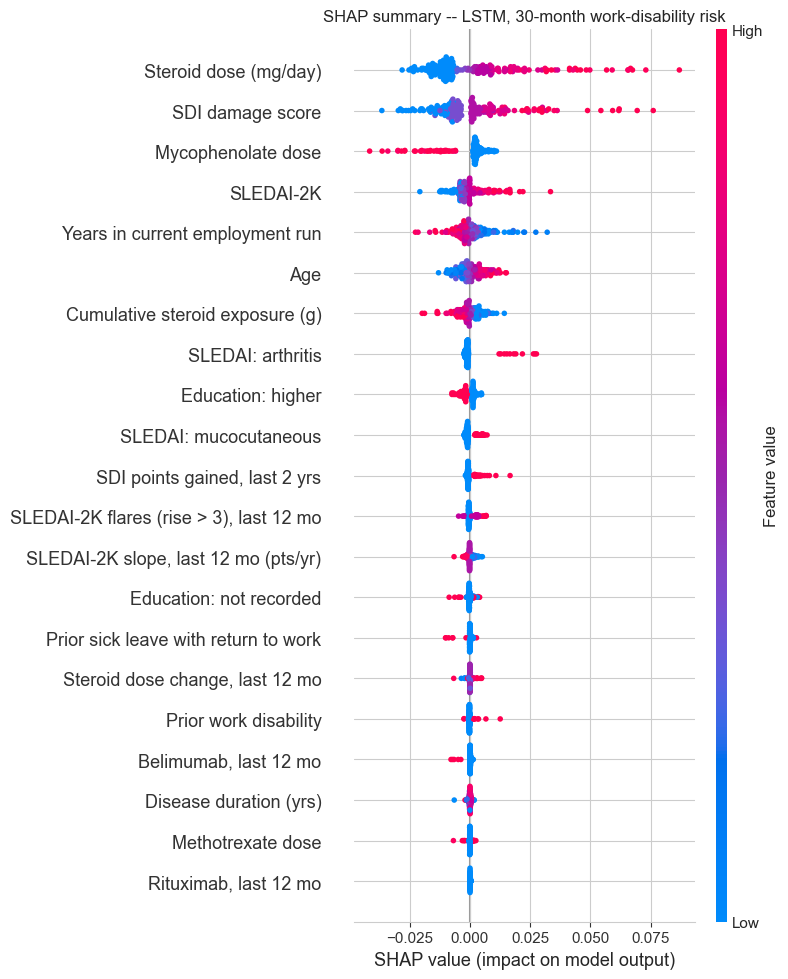

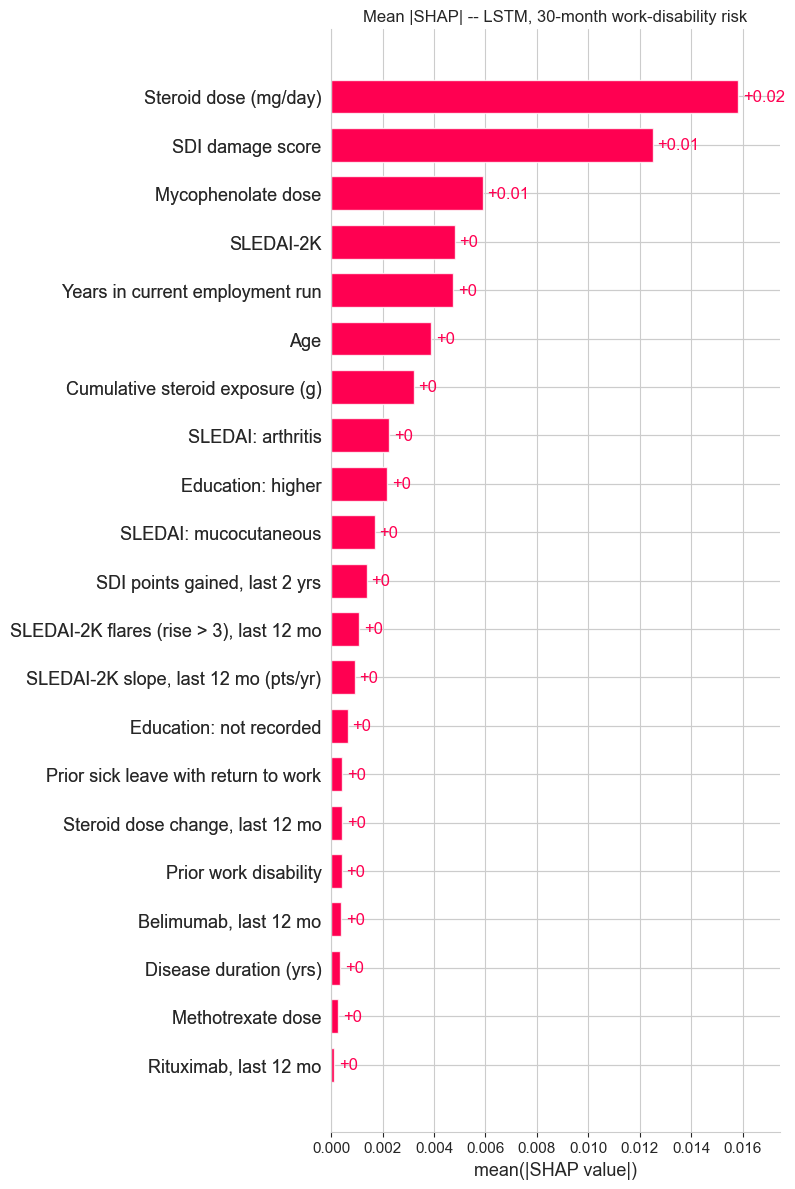

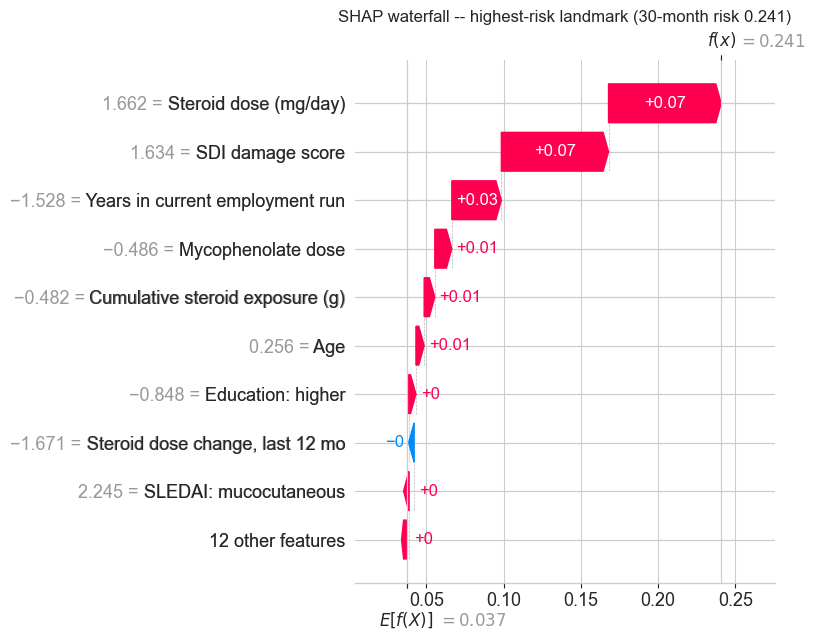

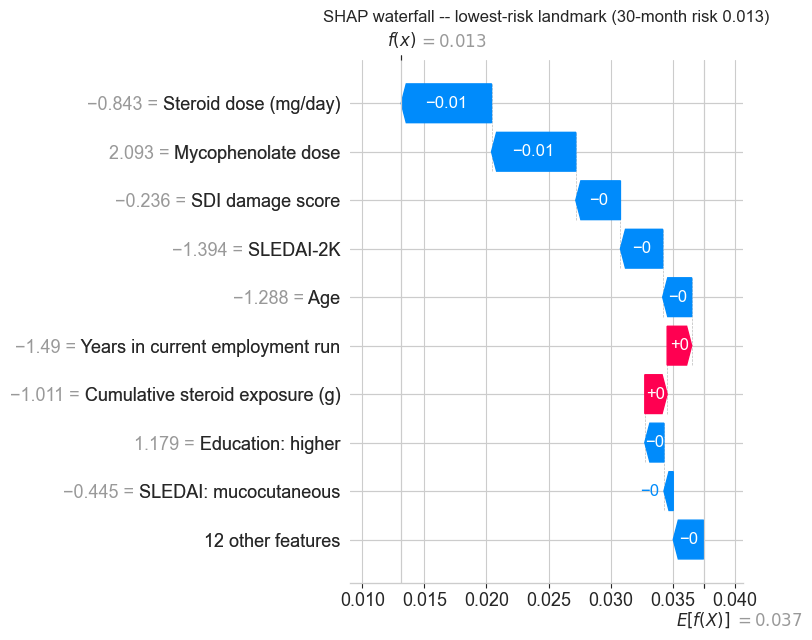

                                Feature  Mean |SHAP|
                  Steroid dose (mg/day)       0.0158
                       SDI damage score       0.0125
                     Mycophenolate dose       0.0059
                              SLEDAI-2K       0.0048
        Years in current employment run       0.0047
                                    Age       0.0039
        Cumulative steroid exposure (g)       0.0032
                      SLEDAI: arthritis       0.0023
                      Education: higher       0.0022
                  SLEDAI: mucocutaneous       0.0017
          SDI points gained, last 2 yrs       0.0014
SLEDAI-2K flares (rise > 3), last 12 mo       0.0011
   SLEDAI-2K slope, last 12 mo (pts/yr)       0.0009
                Education: not recorded       0.0006
   Prior sick leave with return to work       0.0004
        Steroid dose change, last 12 mo       0.0004
                  Prior work disability       0.0004
                  Belimumab, last 12 mo       

In [23]:
"""SHAP explanations for the LSTM (final all-data refit).

The LSTM reads a whole visit history, so SHAP attributes the 30-month risk to the CURRENT visit presented as a short,
constant trajectory: the visit's encoder features are repeated over SHAP_SEQ_LEN employed visits at the cohort's median
visit gap, and the risk is read at the last one. The features are the encoder's inputs; the gap and the employment
state are held fixed. This is the 'constant recent trajectory' simplification used
since v1; the risk-sensitivity curves show each feature's effect with the real histories held as observed. Values are
on the calibrated 30-month risk scale.
"""
import shap

SHAP_MODEL = "LSTM" if res_lstm is not None else next(m for m in ["GRU", "Transformer"] if m in MODEL_RESULTS)
SHAP_SEQ_LEN = 4
fr = MODEL_RESULTS[SHAP_MODEL]["final"]
data = fr["prep"]
cols = data.cols                                                # the encoder's inputs
feature_names = [DISPLAY_NAMES.get(c, c) for c in cols]
gap_log = float(np.median(V_GAP[V_GAP > 0]))
employed = torch.tensor([1.0, 0.0, 0.0, 0.0])


def shap_predict(Z):
    Z = np.asarray(Z, np.float32)
    n, L = len(Z), SHAP_SEQ_LEN
    gap = torch.full((n, L), gap_log); gap[:, 0] = 0.0
    b = dict(x=torch.from_numpy(np.repeat(Z[:, None, :], L, axis=1)), gap=gap,
             state=employed.expand(n, L, -1).contiguous(),
             elapsed=torch.cumsum(torch.expm1(gap), dim=1) / 10.0, lengths=torch.full((n,), L, dtype=torch.long))
    P = np.zeros((n, N_INTERVALS, N_CLASSES))
    with torch.no_grad():
        for net in fr["fitted"]:
            P += torch.softmax(net(b), dim=-1)[:, -1].numpy() / len(fr["fitted"])
    return fr["cal"].transform(cif_to_risk(cif_from_probs(P))[:, PRIMARY_COL])


rng = np.random.RandomState(SEED)
Z_all = data.VX[land["visit_row"].values]                        # scaled encoder features of every landmark
background = Z_all[rng.choice(len(Z_all), 50 if SMOKE else 100, replace=False)]
explain = Z_all[rng.choice(len(Z_all), 40 if SMOKE else 200, replace=False)]
print(f"Computing SHAP values for the {SHAP_MODEL} ({len(explain)} landmarks, {len(background)} background)...")
explainer = shap.Explainer(shap_predict, shap.maskers.Independent(background, max_samples=len(background)),
                           feature_names=feature_names)
shap_values = explainer(explain)

plt.figure()
shap.plots.beeswarm(shap_values, show=False, max_display=len(feature_names))
plt.title(f"SHAP summary -- {SHAP_MODEL}, 30-month work-disability risk")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
plt.figure()
shap.plots.bar(shap_values, show=False, max_display=len(feature_names))
plt.title(f"Mean |SHAP| -- {SHAP_MODEL}, 30-month work-disability risk")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_shap_bar.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
preds_ = shap_predict(explain)
for label, i in [("highest-risk", int(np.argmax(preds_))), ("lowest-risk", int(np.argmin(preds_)))]:
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False)
    plt.title(f"SHAP waterfall -- {label} landmark (30-month risk {preds_[i]:.3f})")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_shap_waterfall_{label.replace('-', '_')}.png", dpi=150,
                                    bbox_inches="tight"); plt.show(); plt.close()
shap_imp = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)}) \
    .sort_values("Mean |SHAP|", ascending=False)
print(shap_imp.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


---
# Part B — Patient-level results

## 11.21 Patient-level results per model

Each model's out-of-fold visit alarms (Part A, the visit threshold of each training fold) are **accumulated over each
patient's 30-month window** (Section 9.2). For each model: the table for all evaluable patients, one table per final
status (employed at the last visit; retired / homemaker at ≥ 60; other), the results by age band, and the patient-level
calibration plot.

LogReg (discrete-time, competing risks) -- PATIENT LEVEL, all evaluable patients
  145 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 598, Other final status 77, Retired / homemaker >= 60 17
  mean counts per repeat: TP 120.6, FN 24.4, TN 312.8, FP 379.2; flagged event patients were first flagged a median 21.1 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7485     | [0.

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,60,309,"0.753 [0.680, 0.819]","0.840 [0.742, 0.915]","0.406 [0.359, 0.458]"
40-49,32,162,"0.800 [0.703, 0.878]","0.875 [0.750, 0.972]","0.469 [0.397, 0.540]"
50-59,45,152,"0.715 [0.617, 0.802]","0.791 [0.677, 0.889]","0.521 [0.446, 0.595]"
>= 60,8,69,"0.766 [0.523, 0.951]","0.825 [0.550, 1.000]","0.464 [0.352, 0.572]"


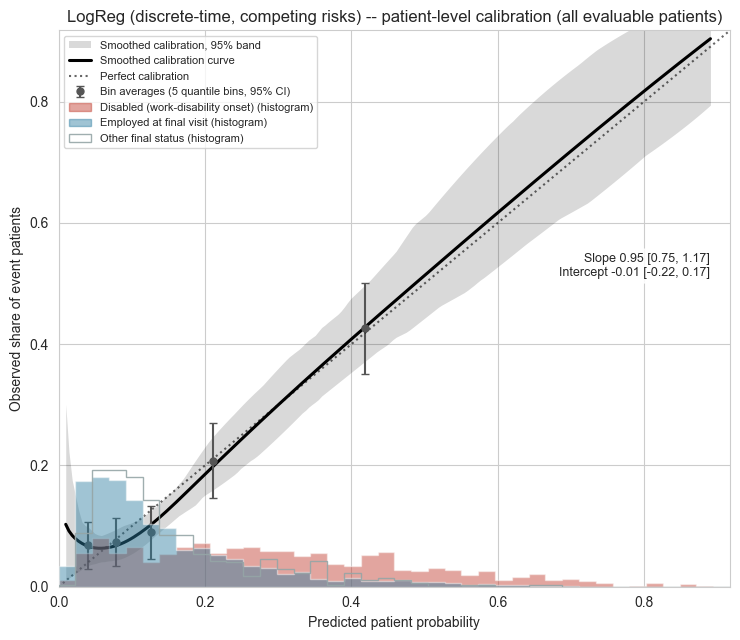

RSF -- PATIENT LEVEL, all evaluable patients
  145 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 598, Other final status 77, Retired / homemaker >= 60 17
  mean counts per repeat: TP 122.8, FN 22.2, TN 240.4, FP 451.6; flagged event patients were first flagged a median 20.5 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7052     | [0.657, 0.752]  Discrimination
Brier Sc

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,60,309,"0.719 [0.646, 0.787]","0.850 [0.755, 0.931]","0.380 [0.329, 0.429]"
40-49,32,162,"0.721 [0.614, 0.816]","0.825 [0.693, 0.941]","0.407 [0.339, 0.478]"
50-59,45,152,"0.686 [0.591, 0.771]","0.862 [0.752, 0.948]","0.325 [0.254, 0.392]"
>= 60,8,69,"0.686 [0.420, 0.929]","0.825 [0.550, 1.000]","0.110 [0.051, 0.176]"


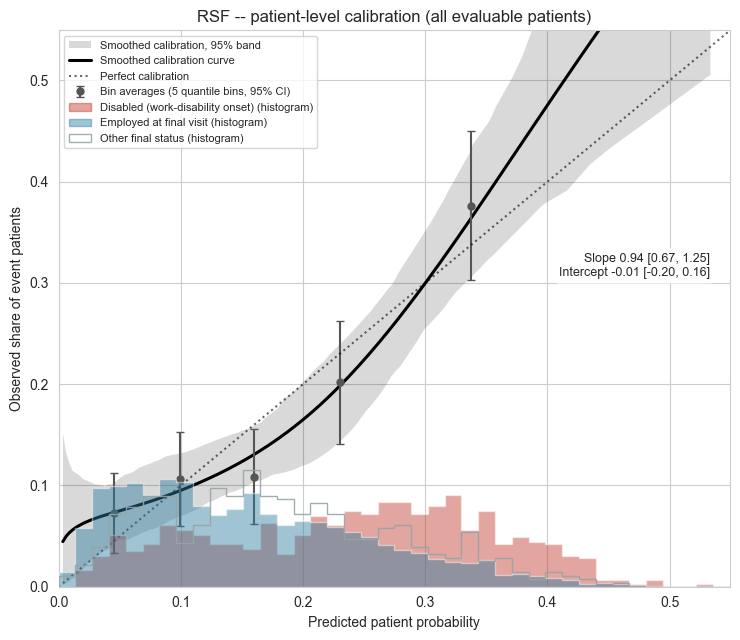

CoxPH (cause-specific) -- PATIENT LEVEL, all evaluable patients
  145 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 598, Other final status 77, Retired / homemaker >= 60 17
  mean counts per repeat: TP 122.4, FN 22.6, TN 284.4, FP 407.6; flagged event patients were first flagged a median 21.9 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7483     | [0.701, 0.792]  Disc

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,60,309,"0.755 [0.682, 0.820]","0.860 [0.773, 0.928]","0.412 [0.361, 0.462]"
40-49,32,162,"0.798 [0.701, 0.876]","0.875 [0.750, 0.972]","0.384 [0.316, 0.456]"
50-59,45,152,"0.711 [0.611, 0.797]","0.796 [0.671, 0.904]","0.434 [0.362, 0.504]"
>= 60,8,69,"0.750 [0.507, 0.939]","0.875 [0.600, 1.000]","0.417 [0.304, 0.523]"


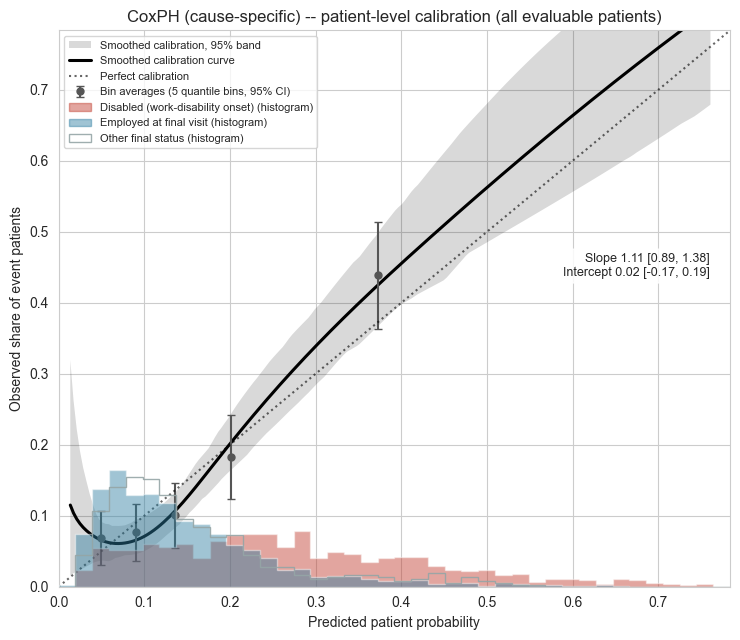

GRU -- PATIENT LEVEL, all evaluable patients
  145 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 598, Other final status 77, Retired / homemaker >= 60 17
  mean counts per repeat: TP 118.4, FN 26.6, TN 296.4, FP 395.6; flagged event patients were first flagged a median 21.9 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7335     | [0.686, 0.780]  Discrimination
Brier Sc

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,60,309,"0.727 [0.652, 0.792]","0.823 [0.729, 0.898]","0.423 [0.373, 0.474]"
40-49,32,162,"0.776 [0.676, 0.861]","0.844 [0.712, 0.956]","0.452 [0.384, 0.522]"
50-59,45,152,"0.714 [0.618, 0.797]","0.778 [0.660, 0.887]","0.457 [0.380, 0.534]"
>= 60,8,69,"0.776 [0.526, 0.950]","0.875 [0.600, 1.000]","0.333 [0.244, 0.431]"


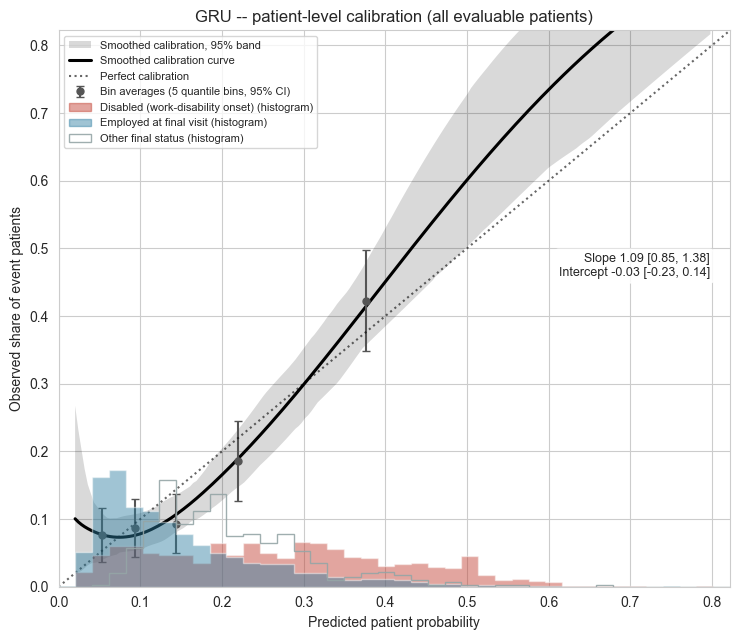

LSTM (main model, toy-sweep winner) -- PATIENT LEVEL, all evaluable patients
  145 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 598, Other final status 77, Retired / homemaker >= 60 17
  mean counts per repeat: TP 120.2, FN 24.8, TN 296.2, FP 395.8; flagged event patients were first flagged a median 21.9 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7347     | [0.687,

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,60,309,"0.733 [0.661, 0.795]","0.837 [0.742, 0.913]","0.432 [0.382, 0.483]"
40-49,32,162,"0.783 [0.688, 0.863]","0.844 [0.714, 0.953]","0.475 [0.411, 0.539]"
50-59,45,152,"0.712 [0.616, 0.795]","0.800 [0.690, 0.902]","0.436 [0.361, 0.511]"
>= 60,8,69,"0.751 [0.504, 0.937]","0.875 [0.600, 1.000]","0.281 [0.203, 0.370]"


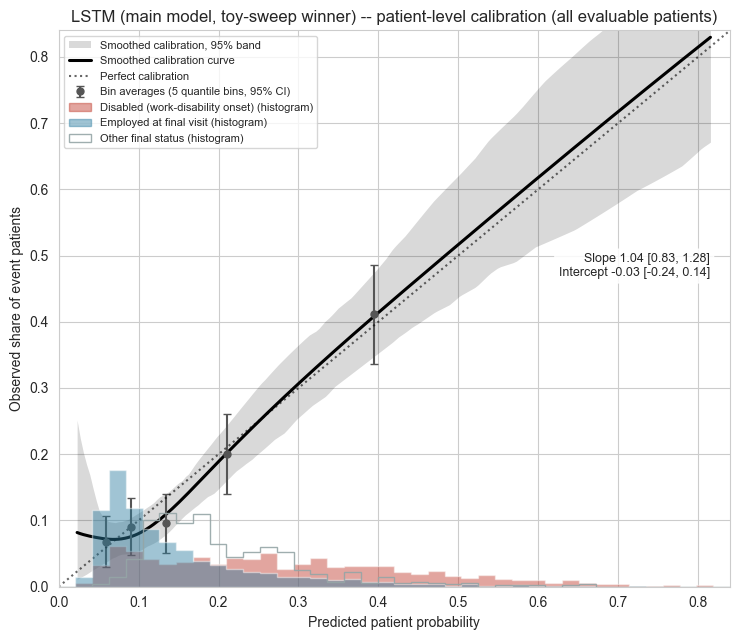

Transformer (causal) -- PATIENT LEVEL, all evaluable patients
  145 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 598, Other final status 77, Retired / homemaker >= 60 17
  mean counts per repeat: TP 116.2, FN 28.8, TN 337.0, FP 355.0; flagged event patients were first flagged a median 21.1 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7314     | [0.682, 0.778]  Discri

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,60,309,"0.728 [0.652, 0.794]","0.800 [0.698, 0.890]","0.503 [0.451, 0.554]"
40-49,32,162,"0.765 [0.668, 0.852]","0.800 [0.664, 0.926]","0.500 [0.433, 0.568]"
50-59,45,152,"0.713 [0.621, 0.800]","0.791 [0.684, 0.892]","0.508 [0.433, 0.582]"
>= 60,8,69,"0.785 [0.536, 0.945]","0.875 [0.600, 1.000]","0.339 [0.241, 0.442]"


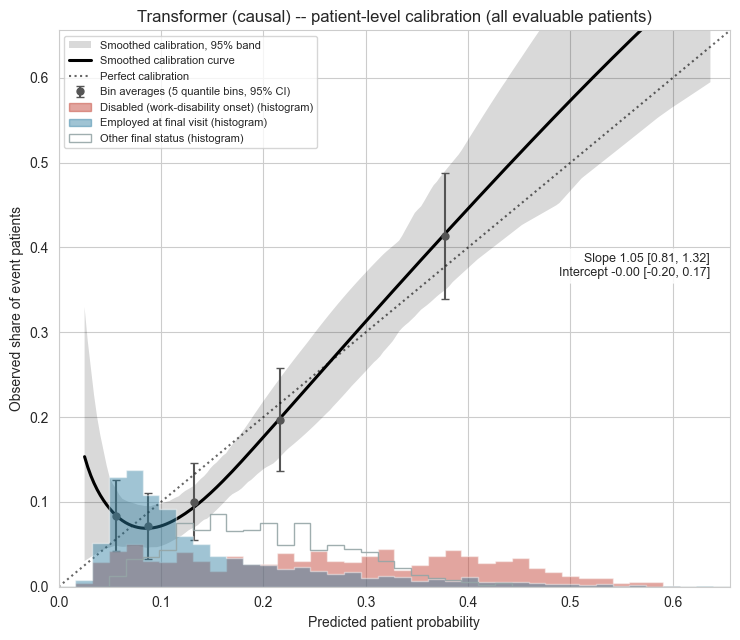

Stack (LSTM + LogReg) -- PATIENT LEVEL, all evaluable patients
  145 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 598, Other final status 77, Retired / homemaker >= 60 17
  mean counts per repeat: TP 120.8, FN 24.2, TN 305.2, FP 386.8; flagged event patients were first flagged a median 21.9 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7497     | [0.703, 0.794]  Discr

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,60,309,"0.751 [0.678, 0.815]","0.837 [0.743, 0.917]","0.419 [0.370, 0.474]"
40-49,32,162,"0.800 [0.705, 0.880]","0.869 [0.738, 0.968]","0.454 [0.384, 0.525]"
50-59,45,152,"0.718 [0.621, 0.805]","0.796 [0.677, 0.900]","0.489 [0.411, 0.567]"
>= 60,8,69,"0.769 [0.521, 0.952]","0.875 [0.600, 1.000]","0.400 [0.300, 0.503]"


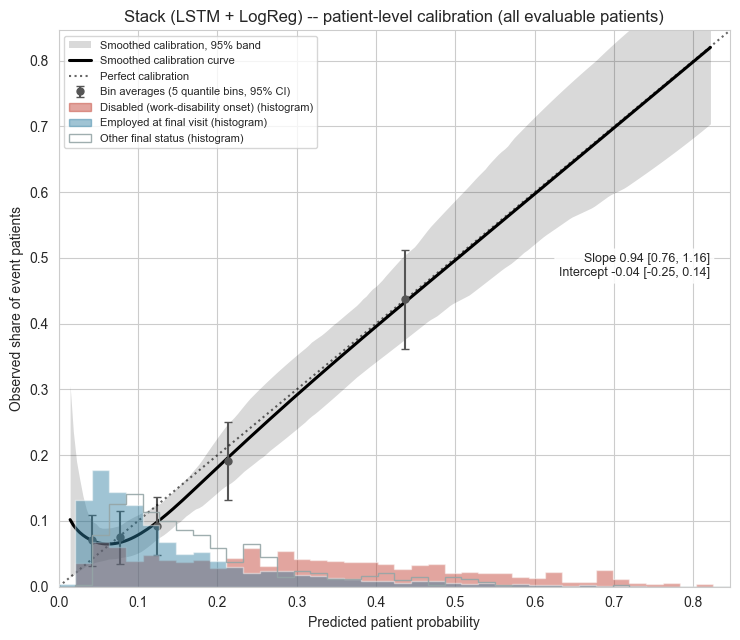

In [24]:
"""Patient-level results of every model, in the order of the model sections (visit risks accumulated per patient)."""
for m, r in MODEL_RESULTS.items():
    report_patient_level(r)


## 11.22 Patient-level summary — all models

Every metric of the per-model patient tables, value [95 % patient-bootstrap CI]: all evaluable patients, each final
status, specificity by age band, LaTeX rows, and all tables of both levels in `metric_tables_model_v5.csv`.

In [25]:
"""
Patient-level summary for all models (visit alarms accumulated per patient; Section 11.6): value [95% patient-bootstrap
CI] for all evaluable patients, then per final-status stratum, specificity by age band, LaTeX rows, and every table of
both levels in metric_tables_model_v5.csv.
"""
_f0 = next(iter(next(iter(MODEL_RESULTS.values()))["preds"].values()))["pt"]
patient_summary = wide_table("patient_table")
print(f"PATIENT LEVEL -- all models, all evaluable patients ({int(_f0.y.sum())} event vs {int((_f0.y == 0).sum())} "
      f"event-free): value [95% patient bootstrap CI], mean over CV repeats")
display(patient_summary)
for _st in STRATA:
    print(f"\nPATIENT LEVEL -- event patients vs event-free '{_st}' "
          f"({int(((_f0.y == 0) & (_f0.stratum == _st)).sum())} patients):")
    display(pd.DataFrame({m: {row["Metric"]: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                                              if np.isfinite(row["Value"]) else "n/a")
                               for _, row in r["stratum_tables"][_st].iterrows()}
                          for m, r in MODEL_RESULTS.items()}).T)
print("\nSpecificity by age at the end of the window (event-free patients in the band):")
display(pd.DataFrame({m: age_band_table(r)["Specificity"] for m, r in MODEL_RESULTS.items()}).T)
print("\nLaTeX rows, patient level, all evaluable patients (" + " & ".join(patient_summary.columns) + "):")
print("\n".join(latex_table_rows("patient_table")))
metric_tables_long = pd.concat(
    [r["visit_table"].assign(model=m, level="visit") for m, r in MODEL_RESULTS.items()]
    + [r["patient_table"].assign(model=m, level="patient: all evaluable") for m, r in MODEL_RESULTS.items()]
    + [r["stratum_tables"][st].assign(model=m, level=f"patient: {st}") for m, r in MODEL_RESULTS.items()
       for st in STRATA]
    + [r["age_tables"][lab].assign(model=m, level=f"patient: age {lab}") for m, r in MODEL_RESULTS.items()
       for _, _, lab in AGE_BANDS])
metric_tables_long.to_csv("metric_tables_model_v5.csv")


PATIENT LEVEL -- all models, all evaluable patients (145 event vs 692 event-free): value [95% patient bootstrap CI], mean over CV repeats


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LogReg,"0.748 [0.699, 0.794]","0.122 [0.107, 0.136]","0.952 [0.749, 1.175]","-0.013 [-0.217, 0.169]","0.832 [0.773, 0.884]","0.452 [0.419, 0.488]","0.241 [0.207, 0.276]","0.928 [0.901, 0.952]","0.642 [0.607, 0.674]","0.204 [0.188, 0.219]","0.941 [0.920, 0.958]"
RSF,"0.705 [0.657, 0.752]","0.131 [0.116, 0.146]","0.940 [0.674, 1.254]","-0.009 [-0.204, 0.161]","0.847 [0.791, 0.900]","0.347 [0.317, 0.381]","0.214 [0.183, 0.245]","0.915 [0.882, 0.946]","0.597 [0.564, 0.628]","0.180 [0.167, 0.192]","0.931 [0.905, 0.954]"
CoxPH,"0.748 [0.701, 0.792]","0.123 [0.108, 0.138]","1.113 [0.889, 1.378]","0.024 [-0.172, 0.194]","0.844 [0.786, 0.897]","0.411 [0.376, 0.446]","0.231 [0.198, 0.264]","0.926 [0.898, 0.953]","0.628 [0.594, 0.659]","0.195 [0.181, 0.209]","0.940 [0.918, 0.959]"
GRU,"0.733 [0.686, 0.780]","0.125 [0.110, 0.139]","1.094 [0.851, 1.379]","-0.029 [-0.228, 0.142]","0.817 [0.758, 0.872]","0.428 [0.394, 0.462]","0.231 [0.198, 0.265]","0.918 [0.888, 0.945]","0.622 [0.587, 0.655]","0.195 [0.180, 0.209]","0.933 [0.912, 0.952]"
LSTM,"0.735 [0.687, 0.779]","0.125 [0.110, 0.139]","1.045 [0.828, 1.282]","-0.035 [-0.238, 0.139]","0.829 [0.772, 0.885]","0.428 [0.396, 0.461]","0.233 [0.202, 0.269]","0.923 [0.895, 0.950]","0.629 [0.594, 0.661]","0.197 [0.183, 0.211]","0.937 [0.917, 0.957]"
Transformer,"0.731 [0.682, 0.778]","0.125 [0.110, 0.139]","1.054 [0.806, 1.317]","-0.004 [-0.200, 0.168]","0.801 [0.741, 0.859]","0.487 [0.454, 0.521]","0.247 [0.212, 0.284]","0.921 [0.896, 0.947]","0.644 [0.607, 0.678]","0.209 [0.192, 0.226]","0.936 [0.916, 0.954]"
Stack,"0.750 [0.703, 0.794]","0.122 [0.106, 0.135]","0.944 [0.756, 1.161]","-0.044 [-0.252, 0.137]","0.833 [0.774, 0.888]","0.441 [0.408, 0.477]","0.238 [0.206, 0.273]","0.927 [0.899, 0.953]","0.637 [0.604, 0.669]","0.201 [0.186, 0.216]","0.940 [0.920, 0.959]"



PATIENT LEVEL -- event patients vs event-free 'Employed at final visit' (598 patients):


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LogReg,"0.751 [0.702, 0.796]","0.133 [0.116, 0.150]","0.945 [0.740, 1.171]","0.140 [-0.063, 0.333]","0.832 [0.771, 0.885]","0.462 [0.427, 0.500]","0.273 [0.231, 0.314]","0.919 [0.887, 0.947]","0.647 [0.611, 0.681]","0.207 [0.191, 0.224]","0.942 [0.922, 0.961]"
RSF,"0.713 [0.663, 0.757]","0.143 [0.127, 0.160]","0.970 [0.684, 1.264]","0.157 [-0.037, 0.345]","0.847 [0.791, 0.900]","0.362 [0.324, 0.397]","0.244 [0.207, 0.281]","0.907 [0.870, 0.939]","0.605 [0.569, 0.636]","0.183 [0.170, 0.196]","0.933 [0.909, 0.955]"
CoxPH,"0.752 [0.703, 0.796]","0.134 [0.118, 0.152]","1.128 [0.877, 1.409]","0.177 [-0.021, 0.359]","0.844 [0.782, 0.896]","0.417 [0.380, 0.455]","0.260 [0.220, 0.300]","0.917 [0.884, 0.947]","0.631 [0.597, 0.664]","0.197 [0.182, 0.211]","0.941 [0.918, 0.960]"
GRU,"0.751 [0.701, 0.796]","0.134 [0.118, 0.151]","1.154 [0.901, 1.431]","0.168 [-0.029, 0.357]","0.817 [0.749, 0.872]","0.480 [0.444, 0.517]","0.276 [0.235, 0.316]","0.915 [0.883, 0.943]","0.648 [0.612, 0.683]","0.210 [0.194, 0.228]","0.939 [0.919, 0.958]"
LSTM,"0.754 [0.705, 0.798]","0.134 [0.118, 0.151]","1.107 [0.879, 1.352]","0.164 [-0.038, 0.354]","0.829 [0.765, 0.886]","0.484 [0.449, 0.522]","0.280 [0.237, 0.322]","0.921 [0.890, 0.948]","0.656 [0.620, 0.690]","0.214 [0.197, 0.231]","0.944 [0.923, 0.962]"
Transformer,"0.748 [0.697, 0.791]","0.135 [0.119, 0.153]","1.092 [0.851, 1.347]","0.191 [-0.004, 0.379]","0.801 [0.736, 0.860]","0.544 [0.510, 0.580]","0.299 [0.254, 0.345]","0.919 [0.890, 0.945]","0.673 [0.636, 0.707]","0.229 [0.210, 0.249]","0.942 [0.924, 0.958]"
Stack,"0.759 [0.711, 0.804]","0.131 [0.115, 0.148]","0.956 [0.758, 1.173]","0.134 [-0.072, 0.336]","0.833 [0.771, 0.889]","0.472 [0.438, 0.511]","0.277 [0.235, 0.319]","0.921 [0.889, 0.950]","0.653 [0.617, 0.687]","0.210 [0.194, 0.228]","0.944 [0.923, 0.962]"



PATIENT LEVEL -- event patients vs event-free 'Retired / homemaker >= 60' (17 patients):


...


PATIENT LEVEL -- event patients vs event-free 'Other final status' (77 patients):


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LogReg,"0.731 [0.666, 0.791]","0.358 [0.321, 0.404]","0.862 [0.642, 1.188]","2.151 [1.856, 2.483]","0.832 [0.773, 0.885]","0.371 [0.278, 0.469]","0.714 [0.647, 0.778]","0.539 [0.414, 0.662]","0.602 [0.545, 0.660]","0.183 [0.160, 0.212]","0.929 [0.893, 0.953]"
RSF,"0.654 [0.579, 0.724]","0.399 [0.363, 0.441]",n/a,"2.135 [1.835, 2.475]","0.847 [0.789, 0.899]","0.281 [0.187, 0.374]","0.689 [0.618, 0.756]","0.493 [0.344, 0.634]","0.564 [0.510, 0.619]","0.166 [0.148, 0.189]","0.915 [0.867, 0.947]"
CoxPH,"0.730 [0.661, 0.792]","0.374 [0.337, 0.417]","0.960 [0.692, 1.370]","2.156 [1.876, 2.479]","0.844 [0.787, 0.899]","0.348 [0.251, 0.449]","0.709 [0.641, 0.776]","0.543 [0.407, 0.676]","0.596 [0.540, 0.655]","0.180 [0.158, 0.208]","0.929 [0.894, 0.956]"
GRU,"0.622 [0.547, 0.686]","0.378 [0.341, 0.420]","0.424 [0.187, 0.782]","1.958 [1.662, 2.309]","0.817 [0.752, 0.870]","0.109 [0.057, 0.175]","0.633 [0.568, 0.704]","0.234 [0.123, 0.351]","0.463 [0.423, 0.502]","0.134 [0.123, 0.145]","0.767 [0.597, 0.852]"
LSTM,"0.612 [0.536, 0.676]","0.375 [0.339, 0.419]","0.438 [0.163, 0.773]","1.958 [1.662, 2.304]","0.829 [0.767, 0.881]","0.083 [0.042, 0.129]","0.630 [0.565, 0.701]","0.197 [0.100, 0.313]","0.456 [0.419, 0.492]","0.133 [0.123, 0.142]","0.708 [0.501, 0.813]"
Transformer,"0.631 [0.558, 0.696]","0.380 [0.343, 0.422]",n/a,"1.988 [1.694, 2.348]","0.801 [0.737, 0.861]","0.125 [0.067, 0.190]","0.633 [0.567, 0.701]","0.246 [0.132, 0.363]","0.463 [0.420, 0.503]","0.134 [0.122, 0.146]","0.781 [0.625, 0.855]"
Stack,"0.688 [0.615, 0.753]","0.353 [0.317, 0.398]","0.659 [0.486, 0.964]","2.033 [1.733, 2.383]","0.833 [0.771, 0.888]","0.236 [0.153, 0.324]","0.673 [0.605, 0.741]","0.428 [0.292, 0.573]","0.535 [0.482, 0.586]","0.156 [0.139, 0.174]","0.892 [0.828, 0.933]"



Specificity by age at the end of the window (event-free patients in the band):


Age at end of window,< 40,40-49,50-59,>= 60
LogReg,"0.406 [0.359, 0.458]","0.469 [0.397, 0.540]","0.521 [0.446, 0.595]","0.464 [0.352, 0.572]"
RSF,"0.380 [0.329, 0.429]","0.407 [0.339, 0.478]","0.325 [0.254, 0.392]","0.110 [0.051, 0.176]"
CoxPH,"0.412 [0.361, 0.462]","0.384 [0.316, 0.456]","0.434 [0.362, 0.504]","0.417 [0.304, 0.523]"
GRU,"0.423 [0.373, 0.474]","0.452 [0.384, 0.522]","0.457 [0.380, 0.534]","0.333 [0.244, 0.431]"
LSTM,"0.432 [0.382, 0.483]","0.475 [0.411, 0.539]","0.436 [0.361, 0.511]","0.281 [0.203, 0.370]"
Transformer,"0.503 [0.451, 0.554]","0.500 [0.433, 0.568]","0.508 [0.433, 0.582]","0.339 [0.241, 0.442]"
Stack,"0.419 [0.370, 0.474]","0.454 [0.384, 0.525]","0.489 [0.411, 0.567]","0.400 [0.300, 0.503]"



LaTeX rows, patient level, all evaluable patients (Concordance Index & Brier Score & Calibration Slope & Calibration Intercept & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy & PPV (cohort prevalence) & NPV (cohort prevalence)):
LogReg      & 0.748 (0.699--0.794) & 0.122 (0.107--0.136) & 0.952 (0.749--1.175) & -0.013 (-0.217--0.169) & 0.832 (0.773--0.884) & 0.452 (0.419--0.488) & 0.241 (0.207--0.276) & 0.928 (0.901--0.952) & 0.642 (0.607--0.674) & 0.204 (0.188--0.219) & 0.941 (0.920--0.958) \\
RSF         & 0.705 (0.657--0.752) & 0.131 (0.116--0.146) & 0.940 (0.674--1.254) & -0.009 (-0.204--0.161) & 0.847 (0.791--0.900) & 0.347 (0.317--0.381) & 0.214 (0.183--0.245) & 0.915 (0.882--0.946) & 0.597 (0.564--0.628) & 0.180 (0.167--0.192) & 0.931 (0.905--0.954) \\
CoxPH       & 0.748 (0.701--0.792) & 0.123 (0.108--0.138) & 1.113 (0.889--1.378) & 0.024 (-0.172--0.194) & 0.844 (0.786--0.897) & 0.411 (0.376--0.446) & 0.231 (0.198--0.264) & 0.926 (0.898--0.953) & 0.628 (0.594--0.659

## 11.23 Patient-level calibration — all models

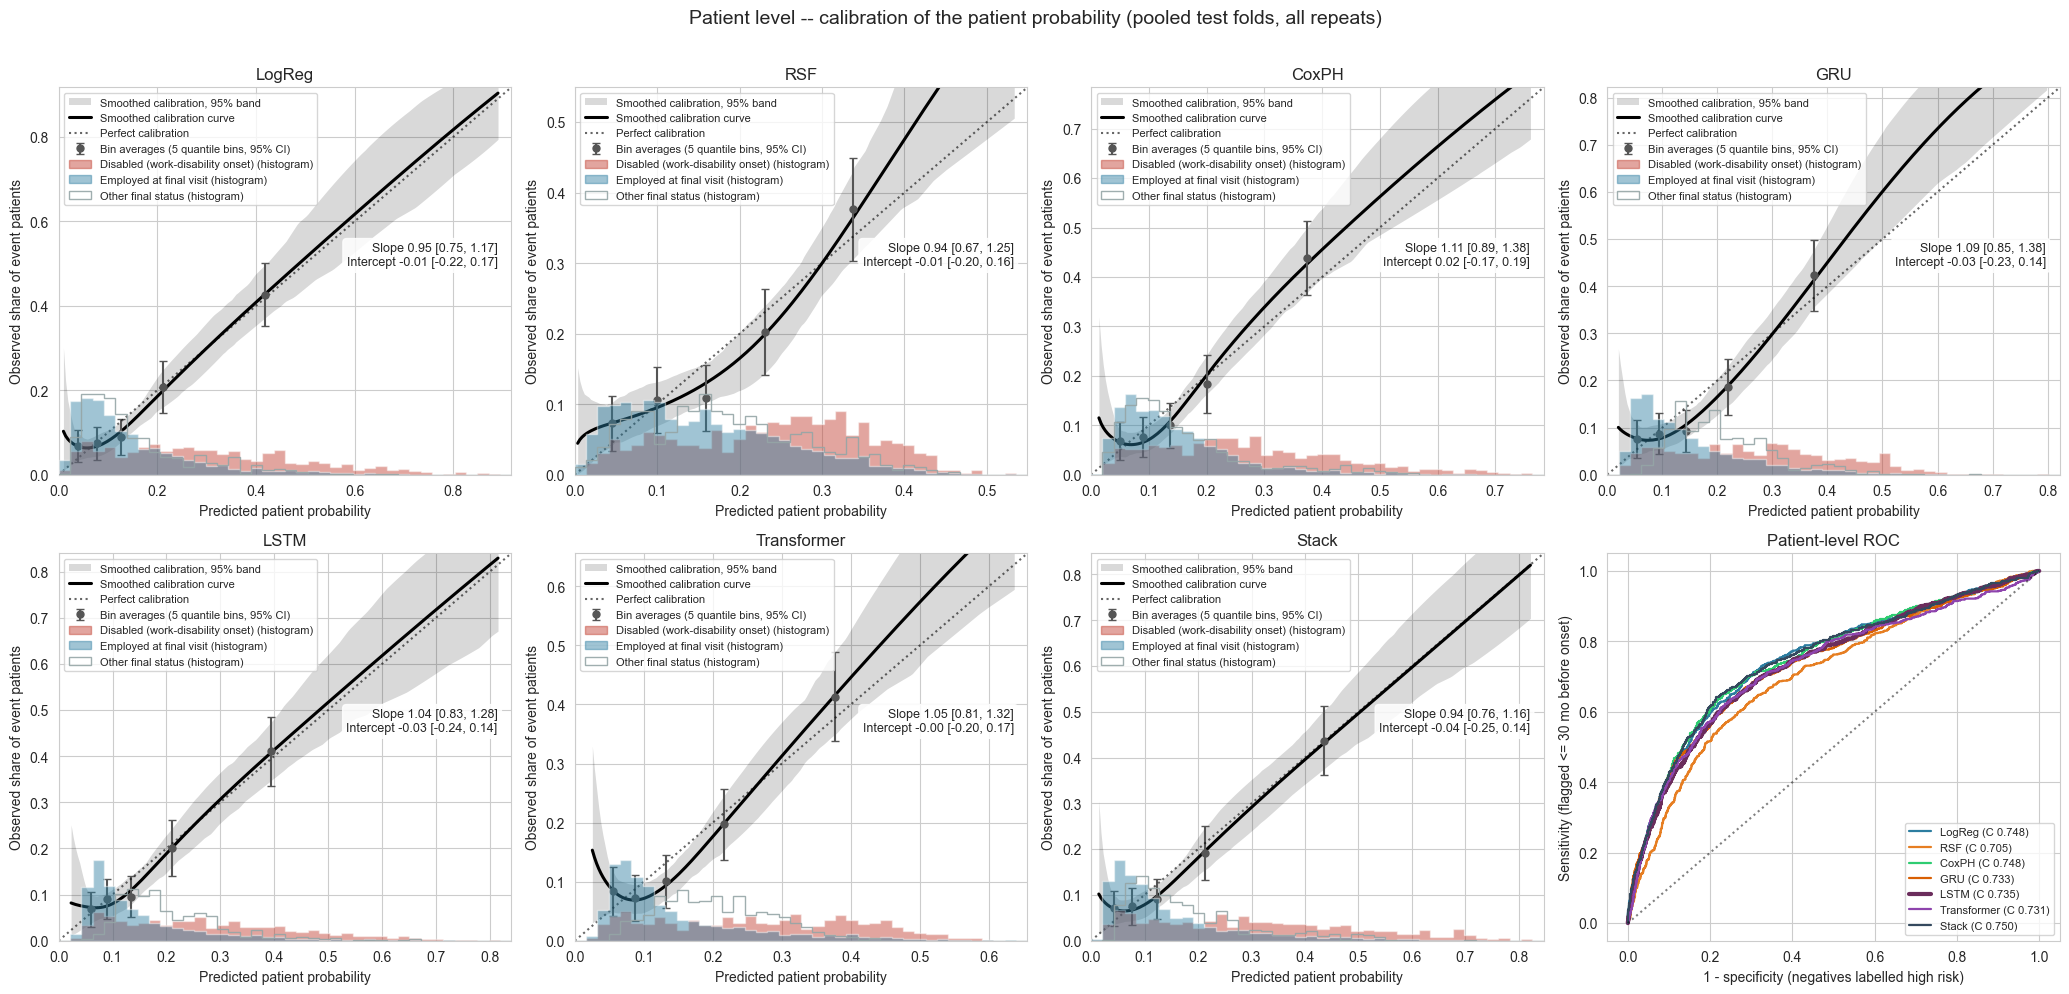

In [26]:
"""Patient-level calibration of every model (quintiles of the recalibrated patient probability, all repeats stacked,
with the slope and intercept of its table) and the patient-level ROC curves of all models."""
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "patient", MODEL_RESULTS[m]["patient_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    arrs = level_arrays(m, r["preds"], "patient")
    y, p = np.concatenate([a[0] for a in arrs]), np.concatenate([a[1] for a in arrs])
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, color=CV_COLORS[m], lw=3 if m == "LSTM" else 1.6,
            label=f"{m} (C {r['patient_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity (negatives labelled high risk)"); ax.set_ylabel("Sensitivity (flagged <= 30 mo before onset)")
ax.set_title("Patient-level ROC"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Patient level -- calibration of the patient probability (pooled test folds, all repeats)", y=1.01,
             fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_calibration_patient_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
